In [1]:
import os
for v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'
# then numpy / xso / ssh imports BELOW this line

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

sys.path.insert(0, os.path.abspath('results/'))

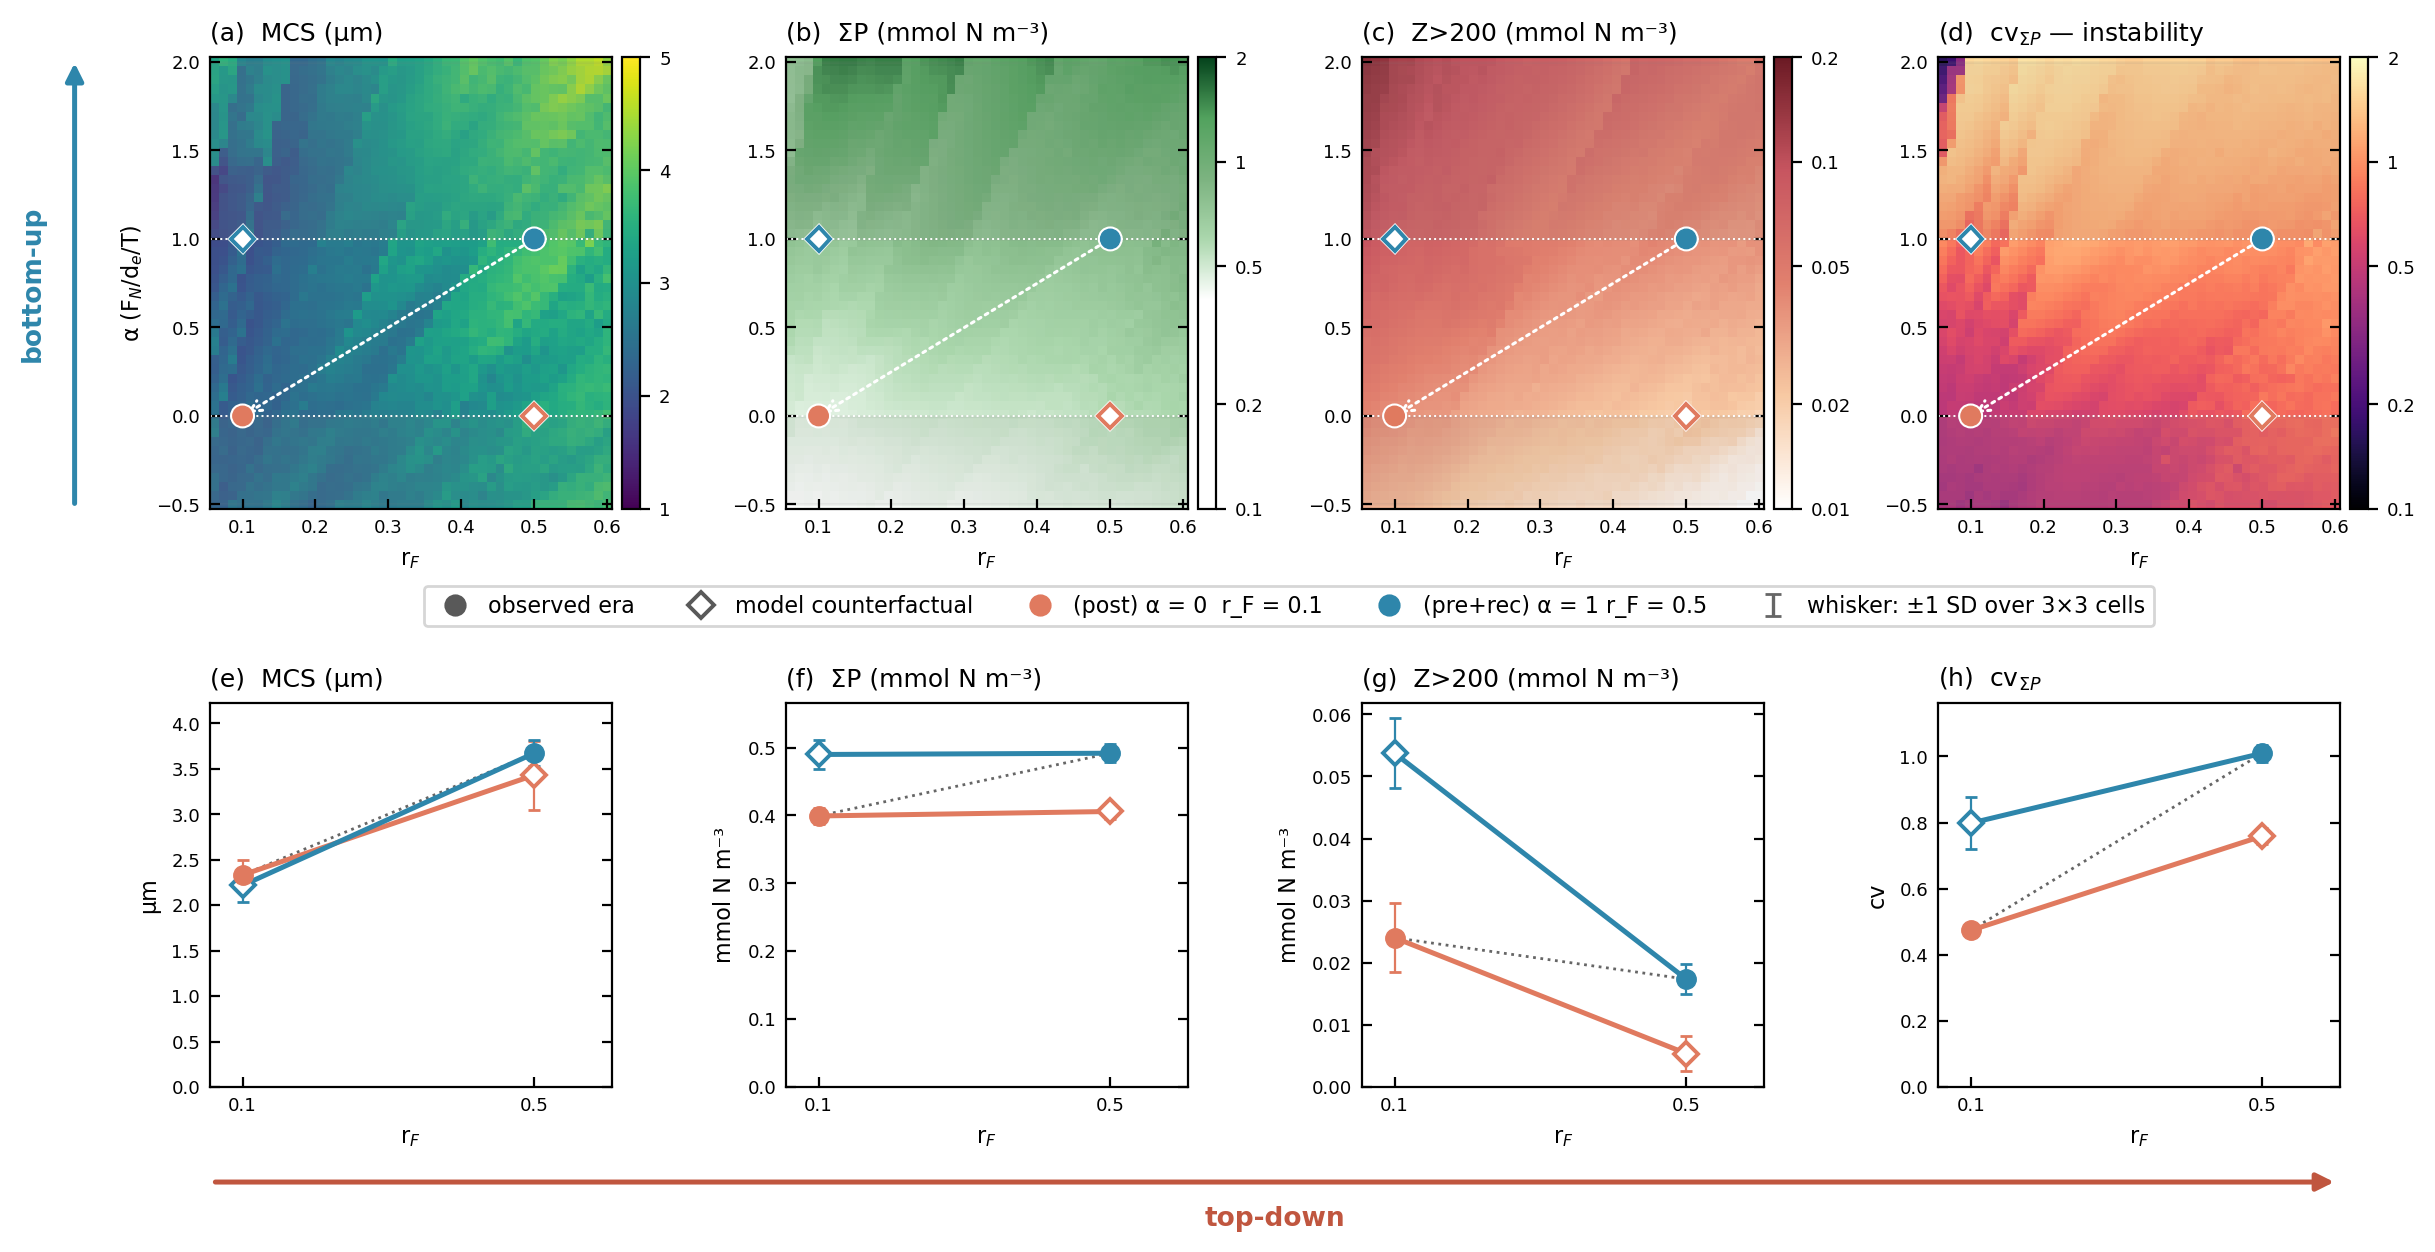

In [1]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import NullLocator
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import make_axes_locatable

ds = xr.open_dataset('results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc')
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
RF_MIN = 0.05; A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5; W = 1
C_POST, C_PRE = '#E07A5F', '#2E86AB'
BU_COL, TD_COL = '#2E86AB', '#C0563F'                 # framing arrows: blue = bottom-up, red = top-down
HALO = [pe.withStroke(linewidth=2.0, foreground='white')]
cmap_phiP = LinearSegmentedColormap.from_list('phiP', ['white','#ABD7AD','#7CB380','#52A25E','#04421C'])
cmap_phiZ = LinearSegmentedColormap.from_list('phiZ', ['white','#F7C9A3','#E1806E','#C75560','#6B1A24'])
def style(ax): ax.tick_params(top=False, right=True, direction='in', labelsize=6.5)

dsf = ds.sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = dsf[A_NAME].values, dsf[R_NAME].values
av, rv = ds[A_NAME].values, ds[R_NAME].values
dr = R_F[1] - R_F[0]; XLIM = (R_F[0] - dr/2, R_F[-1] + dr/2)
def surf(k): return dsf[k].transpose(A_NAME, R_NAME).values
def corner(key, a, rf, mode):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[key].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)})
    vals = (blk.median(D_NAME) if mode == 'traj' else blk).values
    return float(np.mean(vals)), float(np.std(vals))

def cell_marker(ax, x, y, col, era, zbase=6, halo=True):
    pe_ = HALO if halo else None
    if era:
        ax.plot(x, y, 'o', ms=7, color=col, mec=col, mew=0.5, zorder=zbase+2, path_effects=pe_)
    else:
        ax.plot(x, y, 'D', ms=6, mfc='white', mec=col, mew=1.4, zorder=zbase, path_effects=pe_)
CELLS = [(0.1, 0.0, C_POST, True), (0.5, 1.0, C_PRE, True),
         (0.1, 1.0, C_PRE, False), (0.5, 0.0, C_POST, False)]

HEAT = [('mcs_med','MCS (µm)','viridis',False, 1.0, 5.0, [1,2,3,4,5]),
        ('sumP','ΣP (mmol N m⁻³)',cmap_phiP,True, 0.4, 2.0, [0.1,0.2,0.5,1.0,2.0]),
        ('Z200','Z>200 (mmol N m⁻³)',cmap_phiZ,True, 0.01, 0.2, [0.01,0.02,0.05,0.1,0.2]),
        ('cv_sumP','cv$_{ΣP}$ — instability','magma',True, 0.1, 2.0, [0.1,0.2,0.5,1,2])]
PANELS = [('MCS (µm)','traj_mcs','µm','traj'), ('ΣP (mmol N m⁻³)','traj_sumP','mmol N m⁻³','traj'),
          ('Z>200 (mmol N m⁻³)','traj_Z200','mmol N m⁻³','traj'), ('cv$_{ΣP}$','cv_sumP','cv','scalar')]
def heat_overlay(ax):
    ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10); ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0,1): ax.axhline(y, color='white', lw=0.7, ls=':')
    ax.annotate('', xy=(0.1,0.0), xytext=(0.5,1.0),
                arrowprops=dict(arrowstyle='->', lw=1.1, color='white', ls=':'), zorder=6)
    for rf, a, col, era in CELLS: cell_marker(ax, rf, a, col, era)

fig = plt.figure(figsize=(13, 6.6))
gs = GridSpec(3, 4, figure=fig, height_ratios=[1.0, 0.05, 0.85],
              left=0.10, right=0.93, top=0.91, bottom=0.13, hspace=0.30, wspace=0.34)
heat0 = int0 = int3 = None
for ci, (key, label, cmap, logf, vmin, vmax, ticks) in enumerate(HEAT):
    ax = fig.add_subplot(gs[0, ci]); s = surf(key)
    if ci == 0: heat0 = ax
    norm = LogNorm(vmin=vmin, vmax=vmax) if logf else Normalize(vmin=vmin, vmax=vmax)
    pc = ax.pcolormesh(R_F, alpha, s, shading='nearest', cmap=cmap, norm=norm)
    heat_overlay(ax); ax.set_title(f'({"abcd"[ci]})  {label}', fontsize=9, loc='left')
    ax.set_xlabel('r$_F$', fontsize=8); ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    if ci == 0: ax.set_ylabel(r'α (F$_N$/d$_e$/T)', fontsize=8)
    style(ax)
    cax = make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05)
    cb = fig.colorbar(pc, cax=cax)
    cb.set_ticks(ticks); cb.ax.set_yticklabels([f'{v:g}' for v in ticks])
    cb.ax.yaxis.set_minor_locator(NullLocator()); cb.ax.tick_params(labelsize=6.5)

# ---- slim full-width legend between the rows ----
legax = fig.add_subplot(gs[1, :]); legax.axis('off')
eb = legax.errorbar([np.nan], [np.nan], yerr=[1.0], fmt='none', ecolor='0.4',
                    elinewidth=1.2, capsize=3, label='whisker: ±1 SD over 3×3 cells')
leg_handles = [
    Line2D([],[], marker='o', ls='', mfc='0.35',  mec='0.35', ms=7,            label='observed era'),
    Line2D([],[], marker='D', ls='', mfc='white', mec='0.35', mew=1.4, ms=6.5, label='model counterfactual'),
    Line2D([],[], marker='o', ls='', mfc=C_POST,  mec=C_POST, ms=7,            label='(post) α = 0  r_F = 0.1'),
    Line2D([],[], marker='o', ls='', mfc=C_PRE,   mec=C_PRE,  ms=7,            label='(pre+rec) α = 1 r_F = 0.5'),
    eb]
legax.legend(handles=leg_handles, loc='center', ncol=5, #mode='expand', frameon=False,
             fontsize=8, handletextpad=0.5, borderaxespad=0.0)

for ci, (label, key, unit, mode) in enumerate(PANELS):
    ax = fig.add_subplot(gs[2, ci])
    if ci == 0: int0 = ax
    if ci == 3: int3 = ax
    (M00,e00),(M10,e10),(M01,e01),(M11,e11) = (corner(key,A0,RL,mode), corner(key,A1,RL,mode),
                                               corner(key,A0,RH,mode), corner(key,A1,RH,mode))
    RF = [0.1, 0.5]
    ax.plot(RF, [M00,M01], '-', color=C_POST, lw=1.8, zorder=3)
    ax.plot(RF, [M10,M11], '-', color=C_PRE,  lw=1.8, zorder=3)
    ax.errorbar(RF, [M00,M01], yerr=[e00,e01], fmt='none', ecolor=C_POST, elinewidth=0.8, capsize=2, zorder=2)
    ax.errorbar(RF, [M10,M11], yerr=[e10,e11], fmt='none', ecolor=C_PRE,  elinewidth=0.8, capsize=2, zorder=2)
    ax.plot([0.1,0.5], [M00,M11], ls=':', color='0.4', lw=1.0, zorder=1)
    for x, val, col, era in [(0.1,M00,C_POST,True),(0.5,M11,C_PRE,True),(0.1,M10,C_PRE,False),(0.5,M01,C_POST,False)]:
        cell_marker(ax, x, val, col, era, halo=False)
    ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.5]); ax.set_ylim(0, 1.15*max(M00,M10,M01,M11))
    ax.set_xlabel('r$_F$', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(f'({"efgh"[ci]})  {label}', fontsize=9, loc='left'); style(ax)
    make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05).set_visible(False)

# ---- framing arrows: bottom-up (blue, vertical) + top-down (red, horizontal) ----
fig.canvas.draw()
ph, pi0, pi3 = heat0.get_position(), int0.get_position(), int3.get_position()
def fig_arrow(p0, p1, col):
    a = FancyArrowPatch(p0, p1, arrowstyle='-|>', mutation_scale=13, lw=1.8, color=col)
    a.set_transform(fig.transFigure); fig.add_artist(a)
xb = ph.x0 - 0.052                                    # bottom-up, up the left margin of the heatmap row
fig_arrow((xb, ph.y0), (xb, ph.y1), BU_COL)
fig.text(xb - 0.016, 0.5*(ph.y0+ph.y1), 'bottom-up', rotation=90, ha='center', va='center',
         fontsize=9.5, color=BU_COL, weight='bold')
yb = pi0.y0 - 0.072                                   # top-down, along the bottom under the data columns
fig_arrow((pi0.x0, yb), (pi3.x1, yb), TD_COL)
fig.text(0.5*(pi0.x0+pi3.x1), yb - 0.028, 'top-down', ha='center', va='center',
         fontsize=9.5, color=TD_COL, weight='bold')

#fig.suptitle('Figure 5 — bottom-up (α) × top-down (r$_F$): landscape (row 1) + 2×2 corner decomposition (row 2)  ·  construct D, idealised α-forcing',
#             fontsize=9.5, y=0.965)
#fig.savefig('results/Figure5_draft.pdf', bbox_inches='tight')
plt.show()

In [50]:
# ---- Functional-ANOVA / Sobol variance decomposition of each Fig 5 metric surface ----
# Reuses ds, A_NAME, R_NAME, D_NAME from the figure cell.
def _surface(key, mode):
    da = ds[key].median(D_NAME) if mode == 'traj' else ds[key]
    return da.transpose(A_NAME, R_NAME)
def _sobol(da, amin, amax, rmin, rmax):
    M = da.sel({A_NAME: slice(amin, amax), R_NAME: slice(rmin, rmax)}).values
    gm = M.mean(); fa = M.mean(1) - gm; fr = M.mean(0) - gm
    inter = M - gm - fa[:, None] - fr[None, :]; SStot = ((M - gm) ** 2).sum()
    if SStot == 0: return np.nan, np.nan, np.nan
    return ((fa**2).sum()*M.shape[1]/SStot, (fr**2).sum()*M.shape[0]/SStot, (inter**2).sum()/SStot)

SOBOL_METRICS = [('MCS','traj_mcs','traj'), ('ΣP','traj_sumP','traj'),
                 ('Z>200','traj_Z200','traj'), ('cv_ΣP','cv_sumP','scalar')]
WINDOWS = [('obs-anchored   (α 0–1,  r_F 0.1–0.5)', 0.0, 1.0, 0.1, 0.5),
           ('full plane     (α −0.5–2, r_F 0.05–0.6)', -0.5, 2.0, 0.05, 0.6)]

print("Functional-ANOVA / Sobol variance shares of each metric surface (% of total variance)")
print("  bottom-up = α main effect · top-down = r_F main effect · interaction = residual   (sum = 100)\n")
for wlabel, amin, amax, rmin, rmax in WINDOWS:
    print(wlabel)
    print(f"  {'metric':8s}{'bottom-up':>11}{'top-down':>10}{'interaction':>13}    dominant")
    for name, key, mode in SOBOL_METRICS:
        sa, sr, si = _sobol(_surface(key, mode), amin, amax, rmin, rmax)
        dom = max([('bottom-up', sa), ('top-down', sr), ('interaction', si)], key=lambda t: t[1])[0]
        print(f"  {name:8s}{sa*100:10.1f}{sr*100:10.1f}{si*100:12.1f}    {dom}")
    print()

Functional-ANOVA / Sobol variance shares of each metric surface (% of total variance)
  bottom-up = α main effect · top-down = r_F main effect · interaction = residual   (sum = 100)

obs-anchored   (α 0–1,  r_F 0.1–0.5)
  metric    bottom-up  top-down  interaction    dominant
  MCS            1.9      65.7        32.4    top-down
  ΣP            62.2      10.4        27.4    bottom-up
  Z>200         28.7      54.1        17.3    top-down
  cv_ΣP         71.3      17.0        11.7    bottom-up

full plane     (α −0.5–2, r_F 0.05–0.6)
  metric    bottom-up  top-down  interaction    dominant
  MCS            6.1      66.9        27.0    top-down
  ΣP            85.3       3.5        11.2    bottom-up
  Z>200         43.5      36.1        20.4    bottom-up
  cv_ΣP         83.2       5.2        11.5    bottom-up



In [52]:
def corner_W(key, a, rf, mode, Wn):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[key].isel({A_NAME: slice(max(i-Wn,0),i+Wn+1), R_NAME: slice(max(j-Wn,0),j+Wn+1)})
    v = (blk.median(D_NAME) if mode == 'traj' else blk).values
    return float(np.mean(v))

CORN = [('post',A0,RL), ('pre+rec',A1,RH), ('cf-A',A1,RL), ('cf-B',A0,RH)]
print("neighbourhood-size sensitivity of the corner value (W = 1 → 3×3, 2 → 5×5, 3 → 7×7)\n")
for name, key, mode in [('MCS','traj_mcs','traj'), ('ΣP','traj_sumP','traj'),
                        ('Z>200','traj_Z200','traj'), ('cv','cv_sumP','scalar')]:
    print(f"{name}:")
    for cn, a, rf in CORN:
        w1, w2, w3 = (corner_W(key,a,rf,mode,n) for n in (1,2,3))
        print(f"  {cn:8s} W1 {w1:.4g}   W2 {w2:.4g}   W3 {w3:.4g}    Δ(W1→W3) {w3-w1:+.4g}")
    print()

neighbourhood-size sensitivity of the corner value (W = 1 → 3×3, 2 → 5×5, 3 → 7×7)

MCS:
  post     W1 2.332   W2 2.282   W3 2.323    Δ(W1→W3) -0.009618
  pre+rec  W1 3.672   W2 3.649   W3 3.669    Δ(W1→W3) -0.0034
  cf-A     W1 2.218   W2 2.134   W3 2.086    Δ(W1→W3) -0.1324
  cf-B     W1 3.432   W2 3.38   W3 3.337    Δ(W1→W3) -0.09466

ΣP:
  post     W1 0.3992   W2 0.3948   W3 0.3965    Δ(W1→W3) -0.002699
  pre+rec  W1 0.4916   W2 0.496   W3 0.4964    Δ(W1→W3) +0.004782
  cf-A     W1 0.4898   W2 0.4811   W3 0.4741    Δ(W1→W3) -0.01565
  cf-B     W1 0.4058   W2 0.4115   W3 0.4093    Δ(W1→W3) +0.003465

Z>200:
  post     W1 0.02402   W2 0.02397   W3 0.0234    Δ(W1→W3) -0.0006259
  pre+rec  W1 0.01737   W2 0.01824   W3 0.01737    Δ(W1→W3) +5.961e-07
  cf-A     W1 0.05373   W2 0.05212   W3 0.05134    Δ(W1→W3) -0.002389
  cf-B     W1 0.00539   W2 0.004452   W3 0.005152    Δ(W1→W3) -0.0002377

cv:
  post     W1 0.4738   W2 0.4739   W3 0.4722    Δ(W1→W3) -0.0016
  pre+rec  W1 1.01   W2 1.00

data_vars: ['traj_mcs', 'traj_pico', 'traj_nano', 'traj_micro', 'traj_sumP', 'traj_sumZ', 'traj_Z200', 'traj_Z500', 'traj_N', 'traj_PP', 'clim_mcs', 'clim_pico', 'clim_nano', 'clim_micro', 'clim_sumP', 'clim_Z200', 'clim_Z500', 'clim_N', 'clim_PP', 'mcs', 'mcs_med', 'pico', 'nano', 'micro', 'sumP', 'sumZ', 'Z200', 'Z500', 'Z200_peak', 'N', 'PP', 'Export', 'cv_sumP', 'cv_sumZ', 'mcs_conv', 'minP', 'minZ', 'nan_frac', 'has_nan']
coords: {'day': (1000,), 'alpha': (50,), 'rF': (50,), 'month': (12,)}
clim_sumP dims/shape: ('alpha', 'rF', 'month') (50, 50, 12)


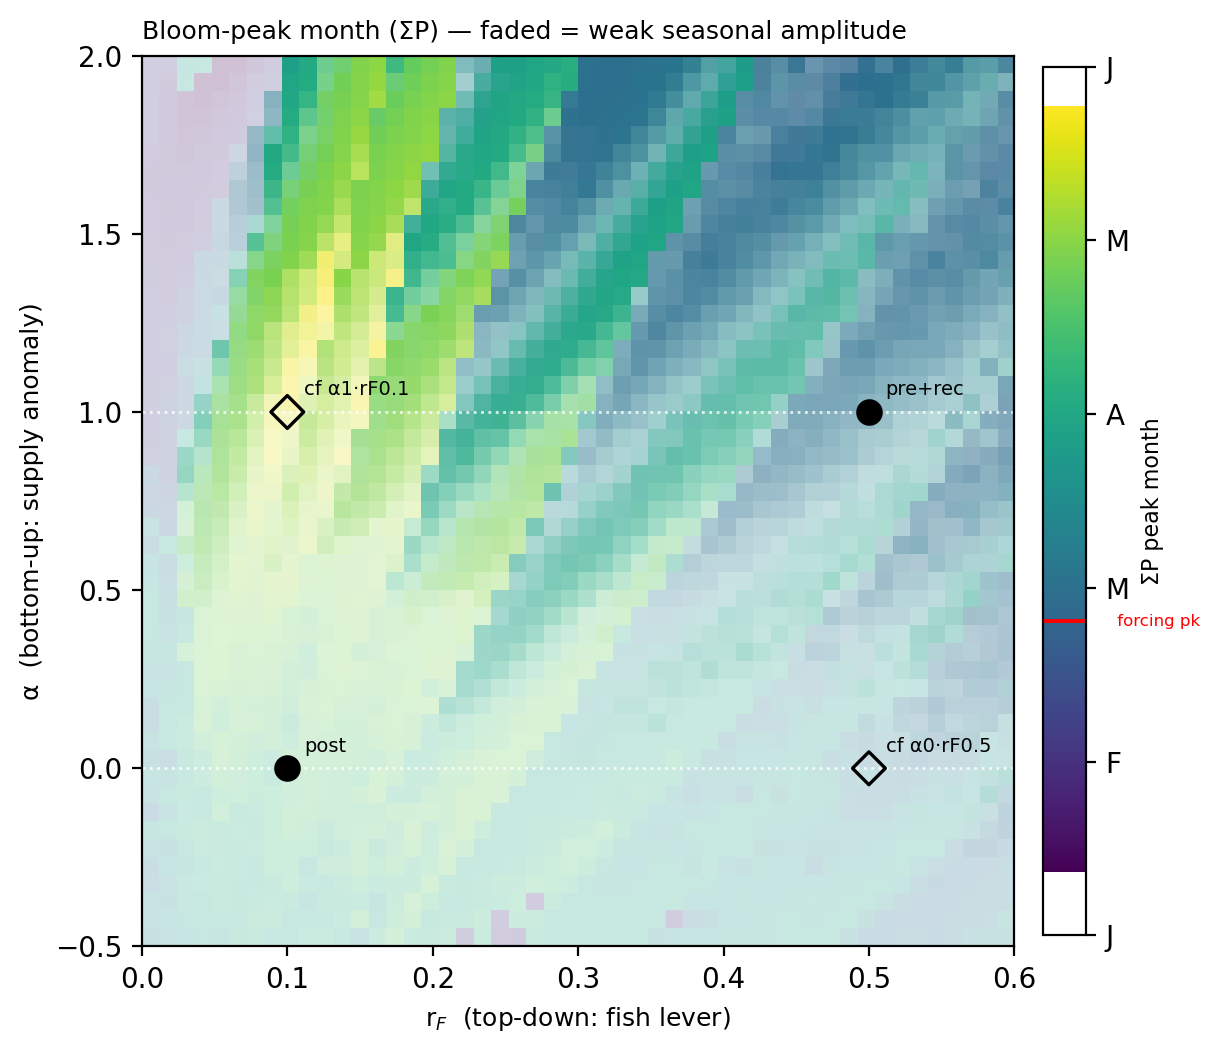


forcing peak ≈ month-index 1.81 (M, day 55)
cell                  α   r_F     peak_mo  lag_mo    amp
post                0.0  0.10      M(3.6)    1.76   1.33
pre+rec             1.0  0.50      M(2.1)    0.31   2.83
cf α1·rF0.1         1.0  0.10      J(4.5)    2.69   1.83
cf α0·rF0.5         0.0  0.50      M(2.1)    0.26   1.84

mean ∂peak/∂α = -0.01 mo per α-unit   |   mean ∂peak/∂r_F = -0.16 mo per r_F-unit
→ larger |∂/∂r_F| ⇒ timing is top-down controlled; larger |∂/∂α| ⇒ bottom-up


In [55]:
# ── Fig 5 scan: bloom-peak-month (ΣP) across α × r_F ──
%config InlineBackend.figure_format = 'retina'
import numpy as np, xarray as xr, matplotlib.pyplot as plt

NC = 'results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc'
ds = xr.open_dataset(NC)
print("data_vars:", list(ds.data_vars)); print("coords:", {k: ds[k].shape for k in ds.coords})
print("clim_sumP dims/shape:", ds['clim_sumP'].dims, ds['clim_sumP'].shape)

alpha = ds['alpha'].values; rF = ds['rF'].values
clim = ds['clim_sumP'].transpose('alpha', 'rF', 'month').values     # (nα, nrF, 12)
MO_LABELS = ['J','F','M','A','M','J','J','A','S','O','N','D']
FORC_PK = 55/30.44                                                   # F_N peak day 55 → month-index (~1.8, late Feb)

def peak_month(a):                                                   # parabolic-refined circular argmax → 0–12
    a = np.asarray(a, float); i = np.argmax(a, axis=-1)
    g = lambda idx: np.take_along_axis(a, (idx % 12)[..., None], -1)[..., 0]
    y0, y1, y2 = g(i-1), g(i), g(i+1); den = y0 - 2*y1 + y2
    d = np.clip(np.where(den != 0, 0.5*(y0 - y2)/den, 0.0), -0.5, 0.5)
    return (i + d) % 12

pk = peak_month(clim)                                                # (nα, nrF), month-index 0–11(.9)
amp = (np.nanmax(clim, -1) - np.nanmin(clim, -1)) / np.nanmean(clim, -1)   # seasonal amplitude
finite = np.isfinite(clim).all(-1)
pk = np.where(finite, pk, np.nan)
alpha_arr = np.clip((amp - np.nanpercentile(amp, 5)) / (np.nanpercentile(amp, 95) - np.nanpercentile(amp, 5)), 0.25, 1.0)
alpha_arr = np.where(finite, alpha_arr, 0.0)

fig, ax = plt.subplots(figsize=(6.2, 5.4))
ext = [rF.min(), rF.max(), alpha.min(), alpha.max()]
im = ax.imshow(pk, origin='lower', extent=ext, aspect='auto', cmap='viridis',
               vmin=np.nanmin(pk), vmax=np.nanmax(pk), alpha=alpha_arr)
for a0 in (0.0, 1.0):                                                # obs-anchored band
    ax.axhline(a0, color='w', ls=':', lw=1.0, alpha=0.8)
MK = [(0.1, 0.0, 'post', 'o', True), (0.5, 1.0, 'pre+rec', 'o', True),
      (0.1, 1.0, 'cf α1·rF0.1', 'D', False), (0.5, 0.0, 'cf α0·rF0.5', 'D', False)]
for x, y, lab, mk, filled in MK:
    ax.scatter(x, y, s=70, marker=mk, zorder=5, edgecolors='k', linewidths=1.2,
               facecolors='k' if filled else 'none', c=None)
    ax.annotate(lab, (x, y), textcoords='offset points', xytext=(6, 6), fontsize=7,
                color='k', path_effects=None)
ax.set_xlabel('r$_F$  (top-down: fish lever)', fontsize=9)
ax.set_ylabel('α  (bottom-up: supply anomaly)', fontsize=9)
ax.set_title('Bloom-peak month (ΣP) — faded = weak seasonal amplitude', fontsize=9, loc='left')
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cb.set_label('ΣP peak month', fontsize=8)
tk = np.arange(np.floor(np.nanmin(pk)), np.ceil(np.nanmax(pk)) + 1)
cb.set_ticks(tk); cb.set_ticklabels([MO_LABELS[int(t) % 12] for t in tk])
cb.ax.axhline(FORC_PK, color='r', lw=1.4); cb.ax.text(1.6, FORC_PK, ' forcing pk', color='r', fontsize=6, va='center')
plt.tight_layout(); plt.show()

# ── diagnostics ──
ai = lambda a: int(np.argmin(np.abs(alpha - a))); ri = lambda r: int(np.argmin(np.abs(rF - r)))
def mo(v): return f"{MO_LABELS[int(round(v)) % 12]}({v:.1f})"
print(f"\nforcing peak ≈ month-index {FORC_PK:.2f} ({MO_LABELS[int(round(FORC_PK))%12]}, day 55)")
print(f"{'cell':<18}{'α':>5}{'r_F':>6}{'peak_mo':>12}{'lag_mo':>8}{'amp':>7}")
for x, y, lab, *_ in MK:
    i, j = ai(y), ri(x); p = pk[i, j]
    print(f"{lab:<18}{y:>5.1f}{x:>6.2f}{mo(p):>12}{(p-FORC_PK):>8.2f}{amp[i, j]:>7.2f}")
band = (alpha >= 0) & (alpha <= 1)                                   # gradient over obs-anchored band
gA = np.nanmean(np.gradient(pk[band, :], alpha[band], axis=0))
gR = np.nanmean(np.gradient(pk[band, :], rF, axis=1))
print(f"\nmean ∂peak/∂α = {gA:+.2f} mo per α-unit   |   mean ∂peak/∂r_F = {gR:+.2f} mo per r_F-unit")
print("→ larger |∂/∂r_F| ⇒ timing is top-down controlled; larger |∂/∂α| ⇒ bottom-up")

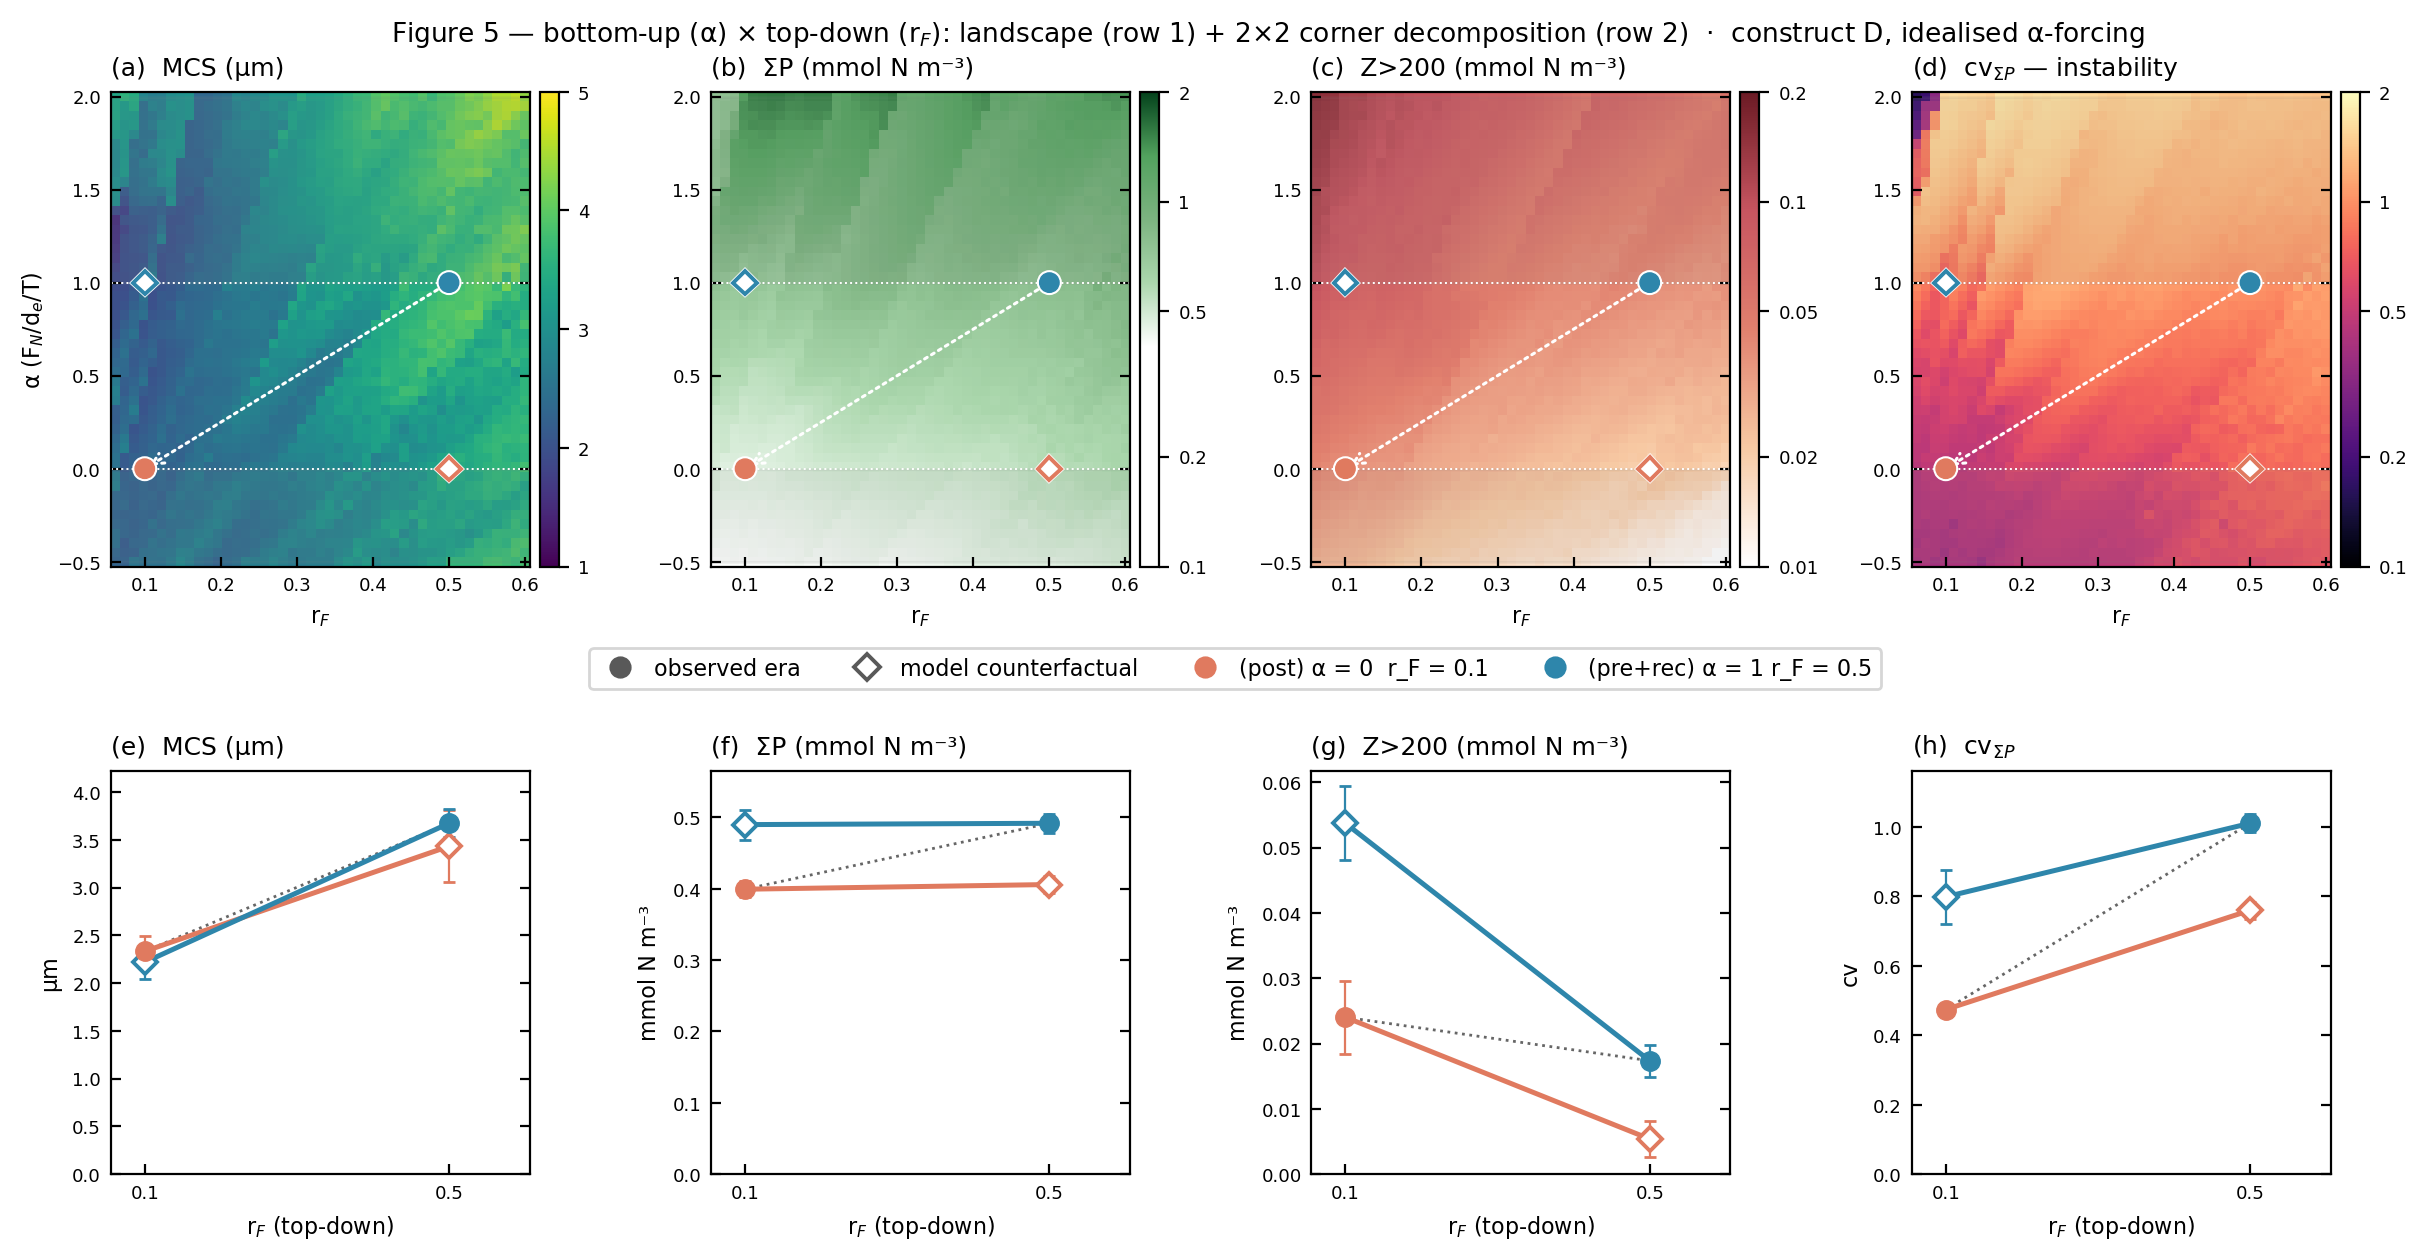

In [47]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import NullLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable

ds = xr.open_dataset('results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc')
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
RF_MIN = 0.05; A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5; W = 1
C_POST, C_PRE = '#E07A5F', '#2E86AB'
HALO = [pe.withStroke(linewidth=2.0, foreground='white')]
cmap_phiP = LinearSegmentedColormap.from_list('phiP', ['white','#ABD7AD','#7CB380','#52A25E','#04421C'])
cmap_phiZ = LinearSegmentedColormap.from_list('phiZ', ['white','#F7C9A3','#E1806E','#C75560','#6B1A24'])
def style(ax): ax.tick_params(top=False, right=True, direction='in', labelsize=6.5)

dsf = ds.sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = dsf[A_NAME].values, dsf[R_NAME].values
av, rv = ds[A_NAME].values, ds[R_NAME].values
dr = R_F[1] - R_F[0]; XLIM = (R_F[0] - dr/2, R_F[-1] + dr/2)
def surf(k): return dsf[k].transpose(A_NAME, R_NAME).values
def corner(key, a, rf, mode):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[key].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)})
    vals = (blk.median(D_NAME) if mode == 'traj' else blk).values
    return float(np.mean(vals)), float(np.std(vals))

def cell_marker(ax, x, y, col, era, zbase=6, halo=True):
    pe_ = HALO if halo else None
    if era:
        ax.plot(x, y, 'o', ms=7, color=col, mec=col, mew=0.5, zorder=zbase+2, path_effects=pe_)
    else:
        ax.plot(x, y, 'D', ms=6, mfc='white', mec=col, mew=1.4, zorder=zbase, path_effects=pe_)
CELLS = [(0.1, 0.0, C_POST, True), (0.5, 1.0, C_PRE, True),
         (0.1, 1.0, C_PRE, False), (0.5, 0.0, C_POST, False)]

HEAT = [('mcs_med','MCS (µm)','viridis',False, 1.0, 5.0, [1,2,3,4,5]),
        ('sumP','ΣP (mmol N m⁻³)',cmap_phiP,True, 0.4, 2.0, [0.1,0.2,0.5,1.0,2.0]),
        ('Z200','Z>200 (mmol N m⁻³)',cmap_phiZ,True, 0.01, 0.2, [0.01,0.02,0.05,0.1,0.2]),
        ('cv_sumP','cv$_{ΣP}$ — instability','magma',True, 0.1, 2.0, [0.1,0.2,0.5,1,2])]
PANELS = [('MCS (µm)','traj_mcs','µm','traj'), ('ΣP (mmol N m⁻³)','traj_sumP','mmol N m⁻³','traj'),
          ('Z>200 (mmol N m⁻³)','traj_Z200','mmol N m⁻³','traj'), ('cv$_{ΣP}$','cv_sumP','cv','scalar')]
def heat_overlay(ax):
    ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10); ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0,1): ax.axhline(y, color='white', lw=0.7, ls=':')
    ax.annotate('', xy=(0.1,0.0), xytext=(0.5,1.0),
                arrowprops=dict(arrowstyle='->', lw=1.1, color='white', ls=':'), zorder=6)
    for rf, a, col, era in CELLS: cell_marker(ax, rf, a, col, era)

fig = plt.figure(figsize=(13, 6.6))
gs = GridSpec(3, 4, figure=fig, height_ratios=[1.0, 0.05, 0.85],
              left=0.055, right=0.92, top=0.91, bottom=0.09, hspace=0.30, wspace=0.34)
for ci, (key, label, cmap, logf, vmin, vmax, ticks) in enumerate(HEAT):
    ax = fig.add_subplot(gs[0, ci]); s = surf(key)
    norm = LogNorm(vmin=vmin, vmax=vmax) if logf else Normalize(vmin=vmin, vmax=vmax)
    pc = ax.pcolormesh(R_F, alpha, s, shading='nearest', cmap=cmap, norm=norm)
    heat_overlay(ax); ax.set_title(f'({"abcd"[ci]})  {label}', fontsize=9, loc='left')
    ax.set_xlabel('r$_F$', fontsize=8); ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    if ci == 0: ax.set_ylabel(r'α (F$_N$/d$_e$/T)', fontsize=8)
    style(ax)
    cax = make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05)
    cb = fig.colorbar(pc, cax=cax)
    cb.set_ticks(ticks); cb.ax.set_yticklabels([f'{v:g}' for v in ticks])
    cb.ax.yaxis.set_minor_locator(NullLocator()); cb.ax.tick_params(labelsize=6.5)

# ---- slim full-width legend between the rows ----
legax = fig.add_subplot(gs[1, :]); legax.axis('off')
leg_handles = [
    Line2D([],[], marker='o', ls='', mfc='0.35',  mec='0.35', ms=7,            label='observed era'),
    Line2D([],[], marker='D', ls='', mfc='white', mec='0.35', mew=1.4, ms=6.5, label='model counterfactual'),
    Line2D([],[], marker='o', ls='', mfc=C_POST,  mec=C_POST, ms=7,            label='(post) α = 0  r_F = 0.1'),
    Line2D([],[], marker='o', ls='', mfc=C_PRE,   mec=C_PRE,  ms=7,            label='(pre+rec) α = 1 r_F = 0.5')]
legax.legend(handles=leg_handles, loc='center', ncol=4, #mode='expand', frameon=False,
             fontsize=8, handletextpad=0.5, borderaxespad=0.0)

for ci, (label, key, unit, mode) in enumerate(PANELS):
    ax = fig.add_subplot(gs[2, ci])
    (M00,e00),(M10,e10),(M01,e01),(M11,e11) = (corner(key,A0,RL,mode), corner(key,A1,RL,mode),
                                               corner(key,A0,RH,mode), corner(key,A1,RH,mode))
    RF = [0.1, 0.5]
    ax.plot(RF, [M00,M01], '-', color=C_POST, lw=1.8, zorder=3)
    ax.plot(RF, [M10,M11], '-', color=C_PRE,  lw=1.8, zorder=3)
    ax.errorbar(RF, [M00,M01], yerr=[e00,e01], fmt='none', ecolor=C_POST, elinewidth=0.8, capsize=2, zorder=2)
    ax.errorbar(RF, [M10,M11], yerr=[e10,e11], fmt='none', ecolor=C_PRE,  elinewidth=0.8, capsize=2, zorder=2)
    ax.plot([0.1,0.5], [M00,M11], ls=':', color='0.4', lw=1.0, zorder=1)
    for x, val, col, era in [(0.1,M00,C_POST,True),(0.5,M11,C_PRE,True),(0.1,M10,C_PRE,False),(0.5,M01,C_POST,False)]:
        cell_marker(ax, x, val, col, era, halo=False)
    ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.5]); ax.set_ylim(0, 1.15*max(M00,M10,M01,M11))
    ax.set_xlabel('r$_F$ (top-down)', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(f'({"efgh"[ci]})  {label}', fontsize=9, loc='left'); style(ax)
    make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05).set_visible(False)

fig.suptitle('Figure 5 — bottom-up (α) × top-down (r$_F$): landscape (row 1) + 2×2 corner decomposition (row 2)  ·  construct D, idealised α-forcing',
             fontsize=9.5, y=0.965)
# fig.savefig('results/Figure5_draft.pdf', bbox_inches='tight')
plt.show()

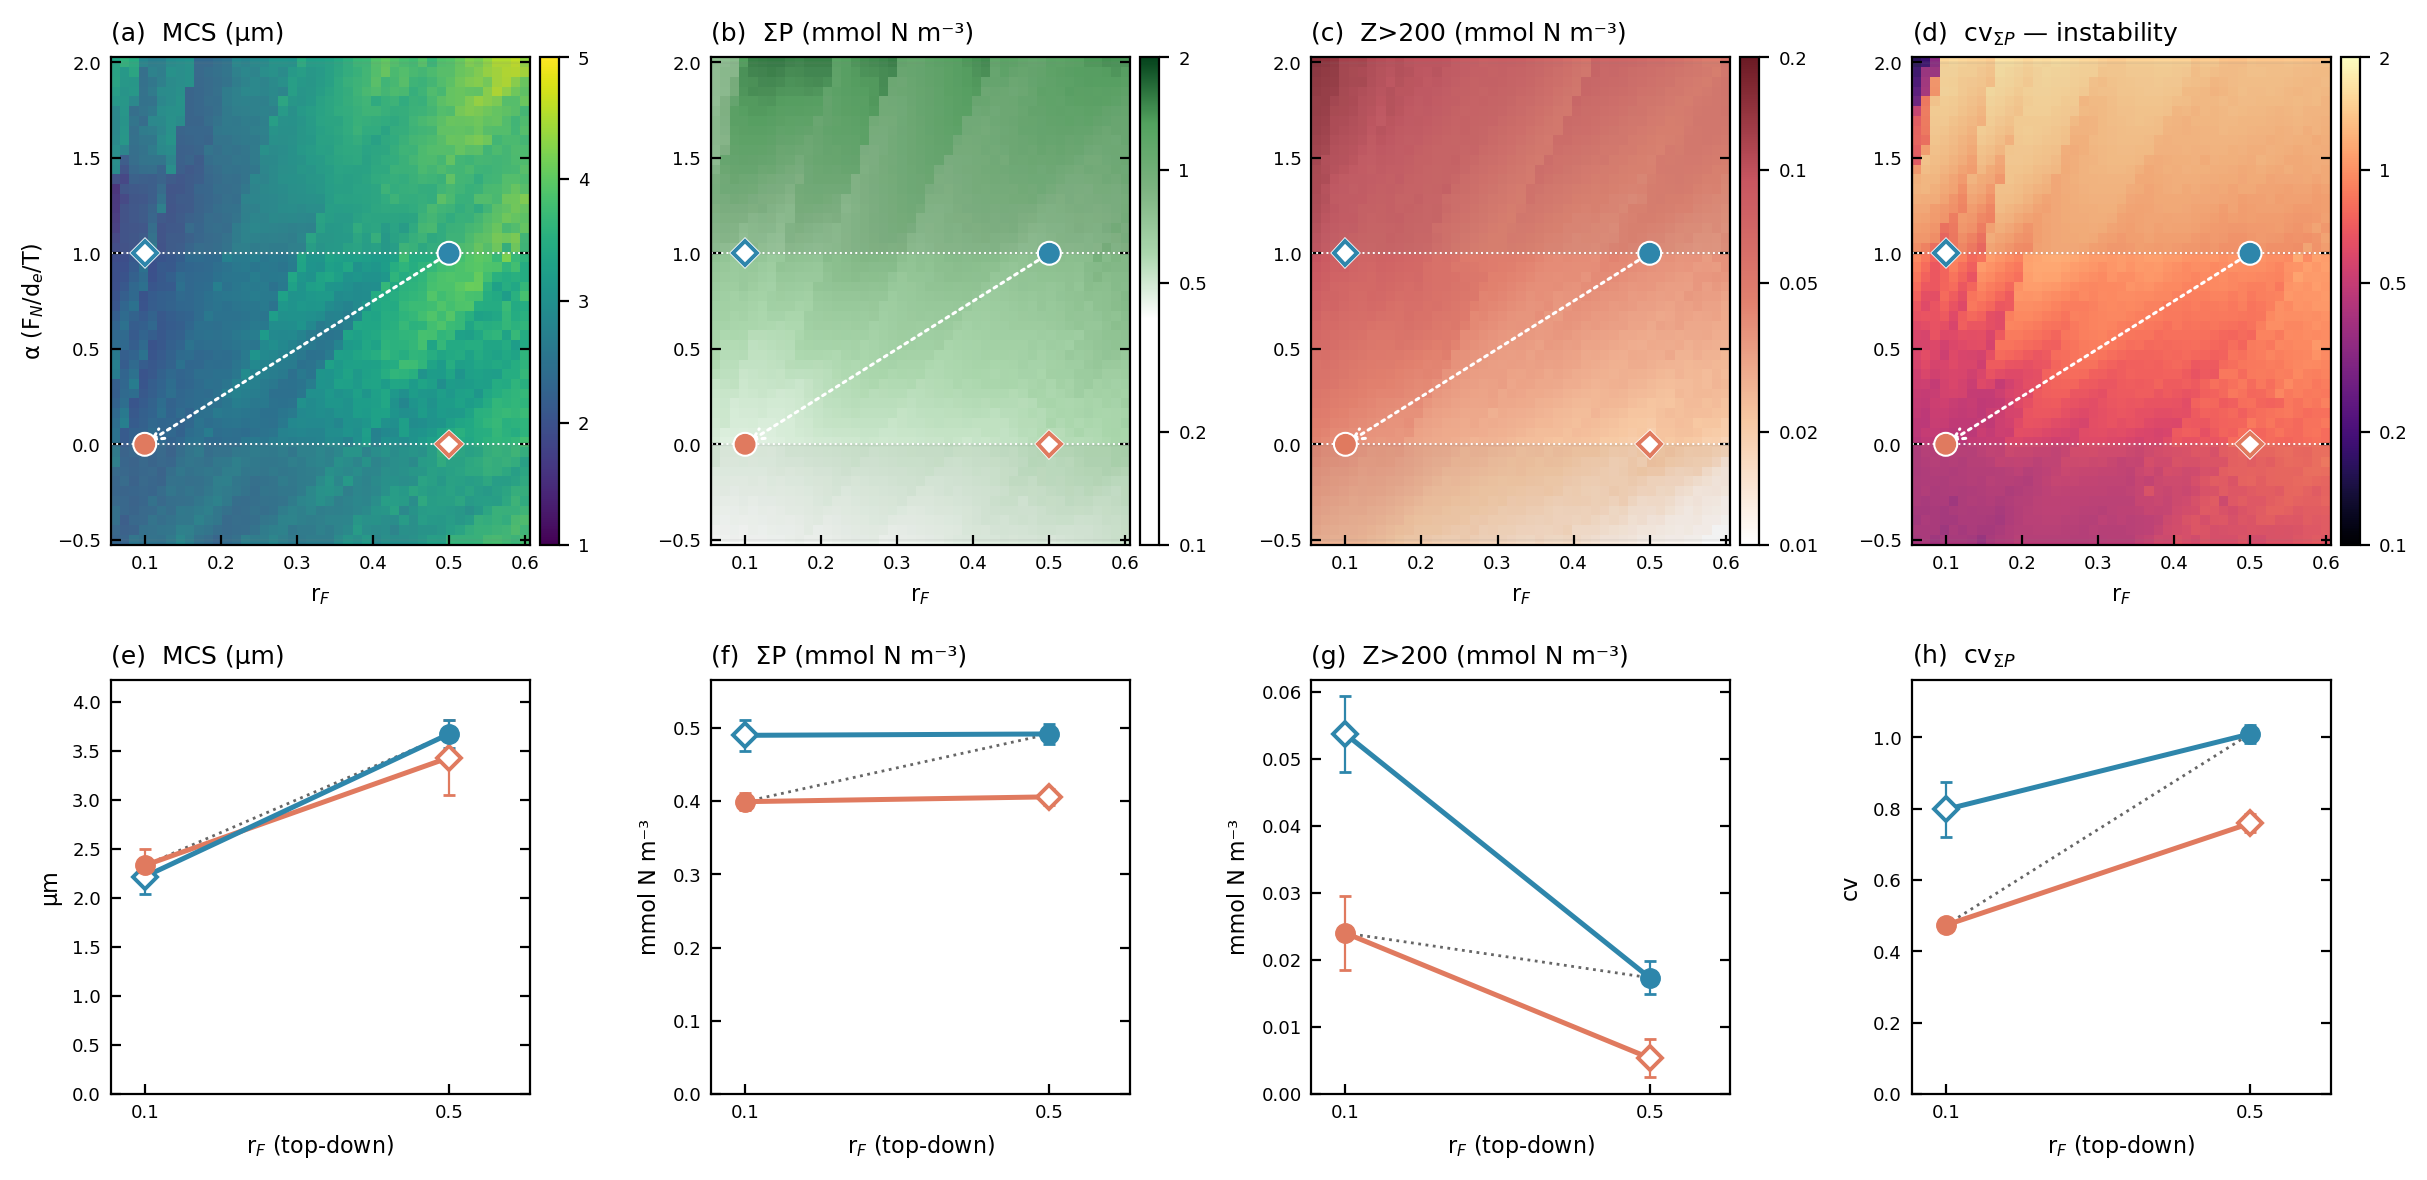

In [44]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import NullLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

ds = xr.open_dataset('results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc')
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
RF_MIN = 0.05; A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5; W = 1
C_POST, C_PRE = '#E07A5F', '#2E86AB'
HALO = [pe.withStroke(linewidth=2.0, foreground='white')]
cmap_phiP = LinearSegmentedColormap.from_list('phiP', ['white','#ABD7AD','#7CB380','#52A25E','#04421C'])
cmap_phiZ = LinearSegmentedColormap.from_list('phiZ', ['white','#F7C9A3','#E1806E','#C75560','#6B1A24'])
def style(ax): ax.tick_params(top=False, right=True, direction='in', labelsize=6.5)   # tick labels = colorbar size

dsf = ds.sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = dsf[A_NAME].values, dsf[R_NAME].values
av, rv = ds[A_NAME].values, ds[R_NAME].values
dr = R_F[1] - R_F[0]; XLIM = (R_F[0] - dr/2, R_F[-1] + dr/2)
def surf(k): return dsf[k].transpose(A_NAME, R_NAME).values
def corner(key, a, rf, mode):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[key].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)})
    vals = (blk.median(D_NAME) if mode == 'traj' else blk).values
    return float(np.mean(vals)), float(np.std(vals))

def cell_marker(ax, x, y, col, era, zbase=6, halo=True):
    pe_ = HALO if halo else None
    if era:   # obs era → solid filled circle
        ax.plot(x, y, 'o', ms=7, color=col, mec=col, mew=0.5, zorder=zbase+2, path_effects=pe_)
    else:     # counterfactual → white diamond, coloured edge
        ax.plot(x, y, 'D', ms=6, mfc='white', mec=col, mew=1.4, zorder=zbase, path_effects=pe_)
CELLS = [(0.1, 0.0, C_POST, True), (0.5, 1.0, C_PRE, True),
         (0.1, 1.0, C_PRE, False), (0.5, 0.0, C_POST, False)]

HEAT = [('mcs_med','MCS (µm)','viridis',False, 1.0, 5.0, [1,2,3,4,5]),
        ('sumP','ΣP (mmol N m⁻³)',cmap_phiP,True, 0.4, 2.0, [0.1,0.2,0.5,1.0,2.0]),
        ('Z200','Z>200 (mmol N m⁻³)',cmap_phiZ,True, 0.01, 0.2, [0.01,0.02,0.05,0.1,0.2]),
        ('cv_sumP','cv$_{ΣP}$ — instability','magma',True, 0.1, 2.0, [0.1,0.2,0.5,1,2])]
PANELS = [('MCS (µm)','traj_mcs','µm','traj'), ('ΣP (mmol N m⁻³)','traj_sumP','mmol N m⁻³','traj'),
          ('Z>200 (mmol N m⁻³)','traj_Z200','mmol N m⁻³','traj'), ('cv$_{ΣP}$','cv_sumP','cv','scalar')]
def heat_overlay(ax):
    ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10); ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0,1): ax.axhline(y, color='white', lw=0.7, ls=':')
    ax.annotate('', xy=(0.1,0.0), xytext=(0.5,1.0),
                arrowprops=dict(arrowstyle='->', lw=1.1, color='white', ls=':'), zorder=6)
    for rf, a, col, era in CELLS: cell_marker(ax, rf, a, col, era)

fig = plt.figure(figsize=(13, 6.4))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1.0, 0.85],
              left=0.055, right=0.92, top=0.91, bottom=0.10, hspace=0.30, wspace=0.34)
for ci, (key, label, cmap, logf, vmin, vmax, ticks) in enumerate(HEAT):
    ax = fig.add_subplot(gs[0, ci]); s = surf(key)
    norm = LogNorm(vmin=vmin, vmax=vmax) if logf else Normalize(vmin=vmin, vmax=vmax)
    pc = ax.pcolormesh(R_F, alpha, s, shading='nearest', cmap=cmap, norm=norm)
    heat_overlay(ax); ax.set_title(f'({"abcd"[ci]})  {label}', fontsize=9, loc='left')
    ax.set_xlabel('r$_F$', fontsize=8); ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    if ci == 0: ax.set_ylabel(r'α (F$_N$/d$_e$/T)', fontsize=8)
    style(ax)
    cax = make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05)
    cb = fig.colorbar(pc, cax=cax)
    cb.set_ticks(ticks); cb.ax.set_yticklabels([f'{v:g}' for v in ticks])
    cb.ax.yaxis.set_minor_locator(NullLocator()); cb.ax.tick_params(labelsize=6.5)

for ci, (label, key, unit, mode) in enumerate(PANELS):
    ax = fig.add_subplot(gs[1, ci])
    (M00,e00),(M10,e10),(M01,e01),(M11,e11) = (corner(key,A0,RL,mode), corner(key,A1,RL,mode),
                                               corner(key,A0,RH,mode), corner(key,A1,RH,mode))
    RF = [0.1, 0.5]
    ax.plot(RF, [M00,M01], '-', color=C_POST, lw=1.8, zorder=3)
    ax.plot(RF, [M10,M11], '-', color=C_PRE,  lw=1.8, zorder=3)
    ax.errorbar(RF, [M00,M01], yerr=[e00,e01], fmt='none', ecolor=C_POST, elinewidth=0.8, capsize=2, zorder=2)
    ax.errorbar(RF, [M10,M11], yerr=[e10,e11], fmt='none', ecolor=C_PRE,  elinewidth=0.8, capsize=2, zorder=2)
    ax.plot([0.1,0.5], [M00,M11], ls=':', color='0.4', lw=1.0, zorder=1)
    for x, val, col, era in [(0.1,M00,C_POST,True),(0.5,M11,C_PRE,True),(0.1,M10,C_PRE,False),(0.5,M01,C_POST,False)]:
        cell_marker(ax, x, val, col, era, halo=False)
    ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.5]); ax.set_ylim(0, 1.15*max(M00,M10,M01,M11))
    ax.set_xlabel('r$_F$ (top-down)', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(f'({"efgh"[ci]})  {label}', fontsize=9, loc='left'); style(ax)
    make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05).set_visible(False)

#fig.suptitle('Figure 5 — bottom-up (α) × top-down (r$_F$): landscape (row 1) + 2×2 corner decomposition (row 2)  ·  construct D, idealised α-forcing',
#             fontsize=9.5, y=0.965)
# fig.savefig('results/Figure5_draft.pdf', bbox_inches='tight')
plt.show()

/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_8491/1120545641.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0,0,1,0.95))


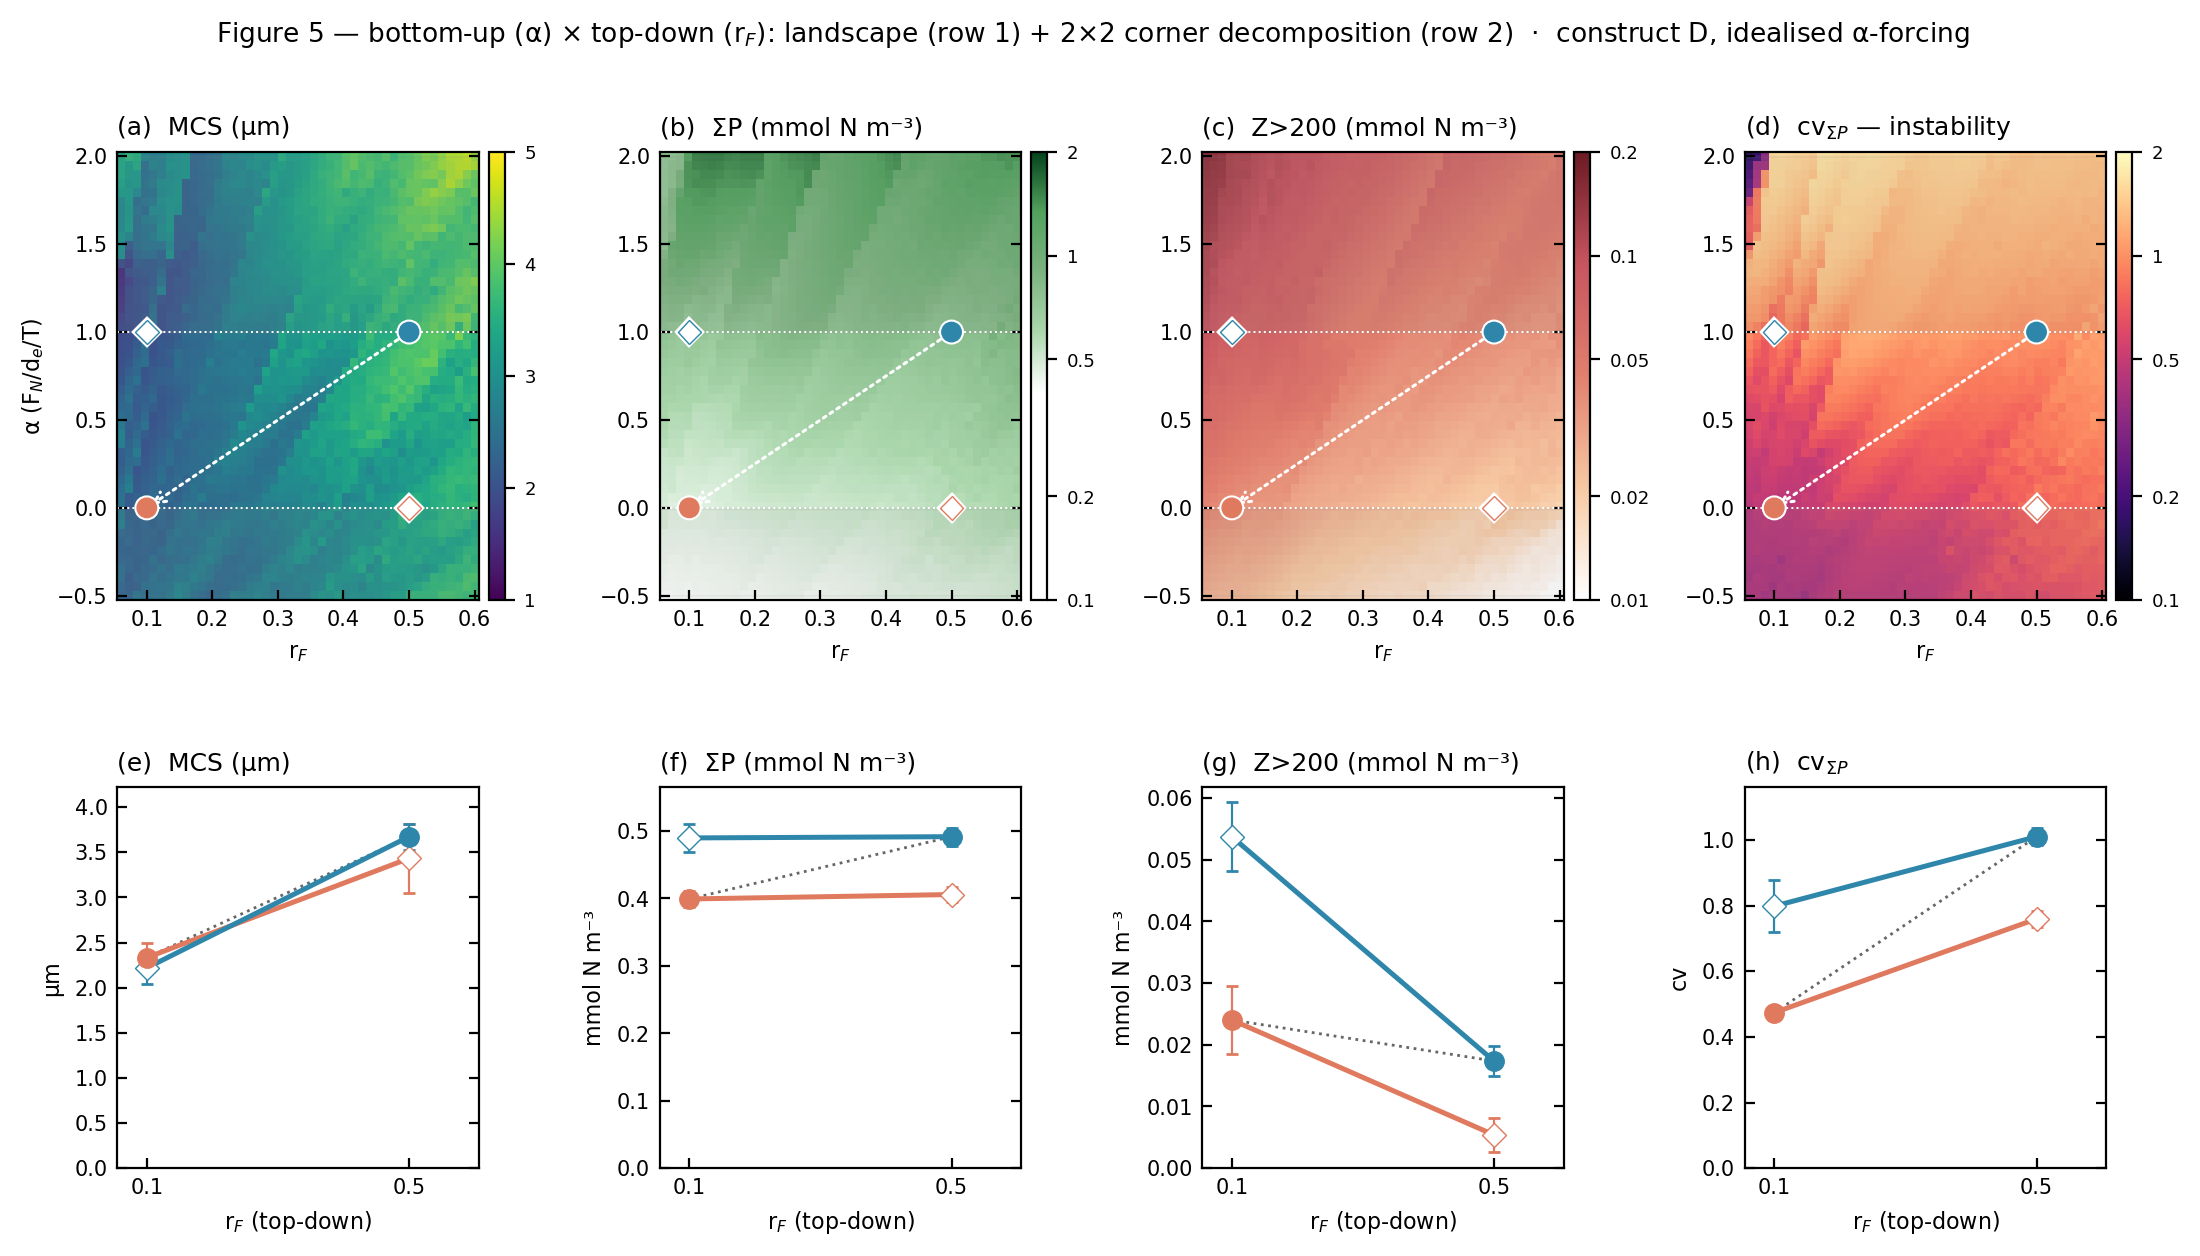

In [40]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import NullLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

ds = xr.open_dataset('results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc')
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
RF_MIN = 0.05; A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5; W = 1
C_POST, C_PRE = '#E07A5F', '#2E86AB'
HALO = [pe.withStroke(linewidth=2.0, foreground='white')]
cmap_phiP = LinearSegmentedColormap.from_list('phiP', ['white','#ABD7AD','#7CB380','#52A25E','#04421C'])
cmap_phiZ = LinearSegmentedColormap.from_list('phiZ', ['white','#F7C9A3','#E1806E','#C75560','#6B1A24'])
def style(ax): ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)

dsf = ds.sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = dsf[A_NAME].values, dsf[R_NAME].values
av, rv = ds[A_NAME].values, ds[R_NAME].values
dr = R_F[1] - R_F[0]; XLIM = (R_F[0] - dr/2, R_F[-1] + dr/2)
def surf(k): return dsf[k].transpose(A_NAME, R_NAME).values
def corner(key, a, rf, mode):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[key].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)})
    vals = (blk.median(D_NAME) if mode == 'traj' else blk).values
    return float(np.mean(vals)), float(np.std(vals))

# marker scheme (identical in both rows): colour = α-era · shape = dot(obs era) / X(counterfactual)
def cell_marker(ax, x, y, col, era, zbase=6, halo=True):
    pe_ = HALO if halo else None
    if era:
        ax.plot(x, y, 'o', ms=7,   color=col, mec=col, mew=0.5, zorder=zbase+2, path_effects=pe_)
    else:
        ax.plot(x, y, 'D', ms=6, color=col, mec=col, mfc="white", mew=0.5, zorder=zbase,   path_effects=pe_)
        
CELLS = [(0.1, 0.0, C_POST, True), (0.5, 1.0, C_PRE, True),      # post, pre+rec (eras → dot)
         (0.1, 1.0, C_PRE, False), (0.5, 0.0, C_POST, False)]    # cf-A, cf-B (counterfactuals → X)

HEAT = [('mcs_med','MCS (µm)','viridis',False, 1.0, 5.0, [1,2,3,4,5]),
        ('sumP','ΣP (mmol N m⁻³)',cmap_phiP,True, 0.4, 2.0, [0.1,0.2,0.5,1.0,2.0]),
        ('Z200','Z>200 (mmol N m⁻³)',cmap_phiZ,True, 0.01, 0.2, [0.01,0.02,0.05,0.1,0.2]),
        ('cv_sumP','cv$_{ΣP}$ — instability','magma',True, 0.1, 2.0, [0.1,0.2,0.5,1,2])]
PANELS = [('MCS (µm)','traj_mcs','µm','traj'), ('ΣP (mmol N m⁻³)','traj_sumP','mmol N m⁻³','traj'),
          ('Z>200 (mmol N m⁻³)','traj_Z200','mmol N m⁻³','traj'), ('cv$_{ΣP}$','cv_sumP','cv','scalar')]
def heat_overlay(ax):
    ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10); ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0,1): ax.axhline(y, color='white', lw=0.7, ls=':')
    ax.annotate('', xy=(0.1,0.0), xytext=(0.5,1.0),
            arrowprops=dict(arrowstyle='->', lw=1.1, color='white', ls=':'), zorder=6)
    for rf, a, col, era in CELLS: cell_marker(ax, rf, a, col, era)

fig = plt.figure(figsize=(13, 6.6))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1.0, 0.85], hspace=0.45, wspace=0.40)
for ci, (key, label, cmap, logf, vmin, vmax, ticks) in enumerate(HEAT):
    ax = fig.add_subplot(gs[0, ci]); s = surf(key)
    norm = LogNorm(vmin=vmin, vmax=vmax) if logf else Normalize(vmin=vmin, vmax=vmax)
    pc = ax.pcolormesh(R_F, alpha, s, shading='nearest', cmap=cmap, norm=norm)
    heat_overlay(ax); ax.set_title(f'({"abcd"[ci]})  {label}', fontsize=9, loc='left')
    ax.set_xlabel('r$_F$', fontsize=8); ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    if ci == 0: ax.set_ylabel(r'α (F$_N$/d$_e$/T)', fontsize=8)
    style(ax)
    cax = make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05)
    cb = fig.colorbar(pc, cax=cax)
    cb.set_ticks(ticks); cb.ax.set_yticklabels([f'{v:g}' for v in ticks])
    cb.ax.yaxis.set_minor_locator(NullLocator()); cb.ax.tick_params(labelsize=6.5)

for ci, (label, key, unit, mode) in enumerate(PANELS):
    ax = fig.add_subplot(gs[1, ci])
    (M00,e00),(M10,e10),(M01,e01),(M11,e11) = (corner(key,A0,RL,mode), corner(key,A1,RL,mode),
                                               corner(key,A0,RH,mode), corner(key,A1,RH,mode))
    RF = [0.1, 0.5]
    ax.plot(RF, [M00,M01], '-', color=C_POST, lw=1.8, zorder=3)   # α=0: post → cf-B
    ax.plot(RF, [M10,M11], '-', color=C_PRE,  lw=1.8, zorder=3)   # α=1: cf-A → pre+rec
    ax.errorbar(RF, [M00,M01], yerr=[e00,e01], fmt='none', ecolor=C_POST, elinewidth=0.8, capsize=2, zorder=2)
    ax.errorbar(RF, [M10,M11], yerr=[e10,e11], fmt='none', ecolor=C_PRE,  elinewidth=0.8, capsize=2, zorder=2)
    ax.plot([0.1,0.5], [M00,M11], ls=':', color='0.4', lw=1.0, zorder=1)
    for x, val, col, era in [(0.1,M00,C_POST,True),(0.5,M11,C_PRE,True),(0.1,M10,C_PRE,False),(0.5,M01,C_POST,False)]:
        cell_marker(ax, x, val, col, era, halo=False)
    ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.5]); ax.set_ylim(0, 1.15*max(M00,M10,M01,M11))
    ax.set_xlabel('r$_F$ (top-down)', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(f'({"efgh"[ci]})  {label}', fontsize=9, loc='left'); style(ax)
    make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05).set_visible(False)  # width spacer → aligns with colorbars

fig.suptitle('Figure 5 — bottom-up (α) × top-down (r$_F$): landscape (row 1) + 2×2 corner decomposition (row 2)  ·  construct D, idealised α-forcing', fontsize=9.5)
fig.tight_layout(rect=(0,0,1,0.95))
# fig.savefig('results/Figure5_draft.pdf', bbox_inches='tight')
plt.show()

/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_8491/1714790819.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0,0,1,0.95))


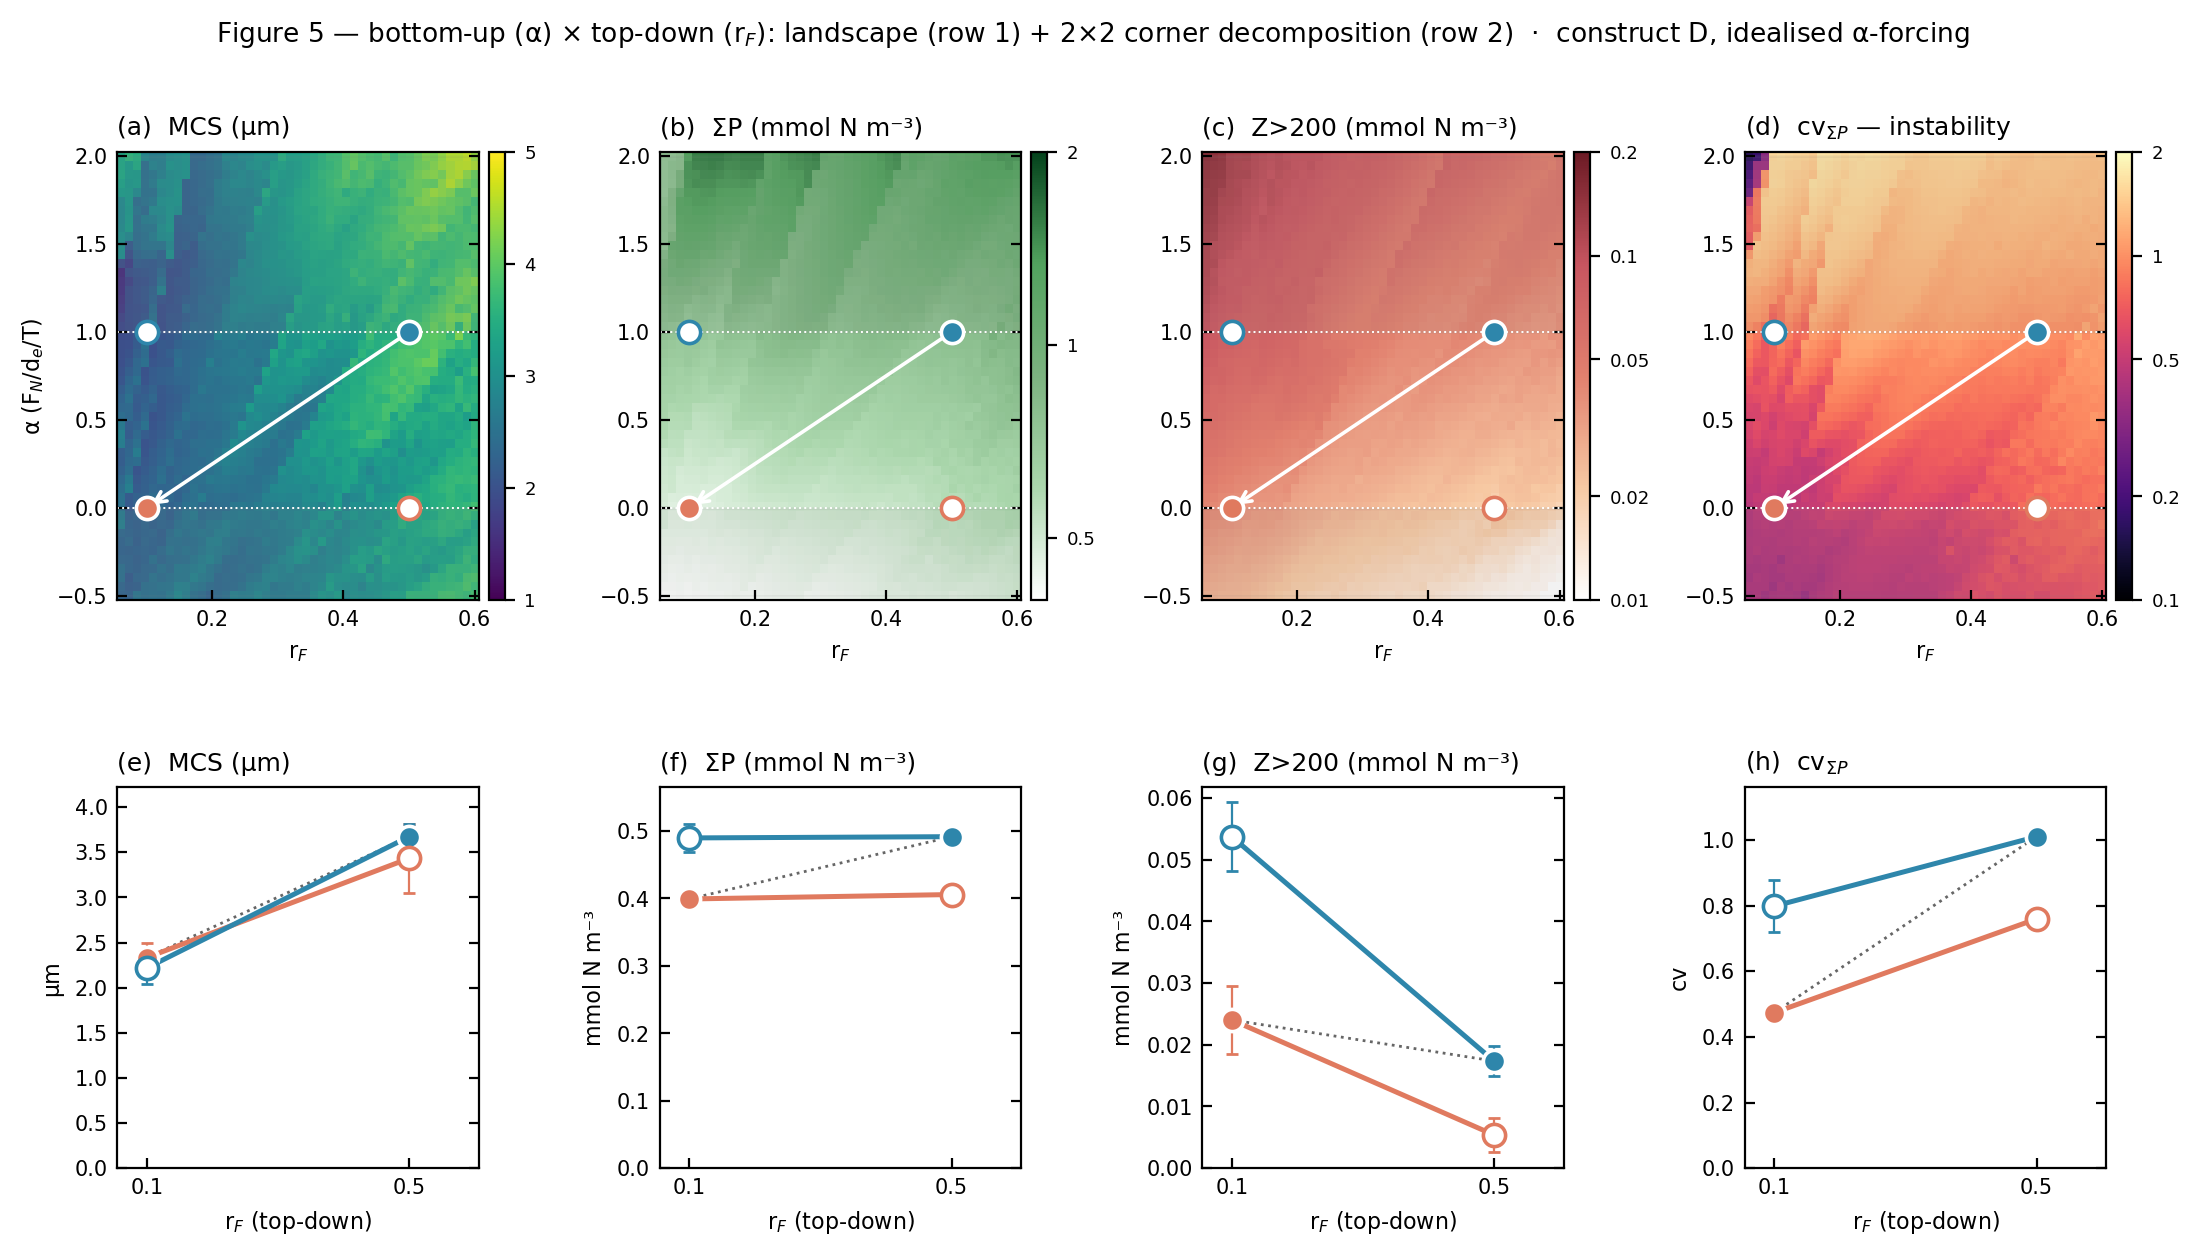

In [21]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import NullLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

ds = xr.open_dataset('results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc')
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
RF_MIN = 0.05; A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5; W = 1
C_POST, C_PRE = '#E07A5F', '#2E86AB'
cmap_phiP = LinearSegmentedColormap.from_list('phiP', ['white','#ABD7AD','#7CB380','#52A25E','#04421C'])
cmap_phiZ = LinearSegmentedColormap.from_list('phiZ', ['white','#F7C9A3','#E1806E','#C75560','#6B1A24'])
def style(ax): ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)

dsf = ds.sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = dsf[A_NAME].values, dsf[R_NAME].values
av, rv = ds[A_NAME].values, ds[R_NAME].values
dr = R_F[1] - R_F[0]; XLIM = (R_F[0] - dr/2, R_F[-1] + dr/2)   # shared x-extent for both rows
def surf(k): return dsf[k].transpose(A_NAME, R_NAME).values
def corner(key, a, rf, mode):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[key].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)})
    vals = (blk.median(D_NAME) if mode == 'traj' else blk).values
    return float(np.mean(vals)), float(np.std(vals))

# one marker scheme, used in both rows: colour = α-era, fill = obs-era (filled) vs counterfactual (open)
MS, MEW = 8, 1.3
def cell_marker(ax, x, y, col, filled):
    ax.plot(x, y, 'o', ms=MS, color=col, mfc=(col if filled else 'white'),
            mec=('white' if filled else col), mew=MEW, zorder=7)
CELLS = [(0.1, 0.0, C_POST, True), (0.5, 1.0, C_PRE, True),      # post, pre+rec (eras)
         (0.1, 1.0, C_PRE, False), (0.5, 0.0, C_POST, False)]    # cf-A, cf-B (counterfactuals)

HEAT = [('mcs_med','MCS (µm)','viridis',False, 1.0, 5.0, [1,2,3,4,5]),
        ('sumP','ΣP (mmol N m⁻³)',cmap_phiP,True, 0.4, 2.0, [0.1,0.2,0.5,1.0,2.0]),
        ('Z200','Z>200 (mmol N m⁻³)',cmap_phiZ,True, 0.01, 0.2, [0.01,0.02,0.05,0.1,0.2]),
        ('cv_sumP','cv$_{ΣP}$ — instability','magma',True, 0.1, 2.0, [0.1,0.2,0.5,1,2])]
PANELS = [('MCS (µm)','traj_mcs','µm','traj'), ('ΣP (mmol N m⁻³)','traj_sumP','mmol N m⁻³','traj'),
          ('Z>200 (mmol N m⁻³)','traj_Z200','mmol N m⁻³','traj'), ('cv$_{ΣP}$','cv_sumP','cv','scalar')]
def heat_overlay(ax):
    ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10); ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0,1): ax.axhline(y, color='white', lw=0.7, ls=':')
    ax.annotate('', xy=(0.1,0.0), xytext=(0.5,1.0), arrowprops=dict(arrowstyle='->', lw=1.3, color='white'), zorder=6)
    for rf, a, col, filled in CELLS: cell_marker(ax, rf, a, col, filled)

fig = plt.figure(figsize=(13, 6.6))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1.0, 0.85], hspace=0.45, wspace=0.40)
for ci, (key, label, cmap, logf, vmin, vmax, ticks) in enumerate(HEAT):
    ax = fig.add_subplot(gs[0, ci]); s = surf(key)
    norm = LogNorm(vmin=vmin, vmax=vmax) if logf else Normalize(vmin=vmin, vmax=vmax)
    pc = ax.pcolormesh(R_F, alpha, s, shading='nearest', cmap=cmap, norm=norm)
    heat_overlay(ax); ax.set_title(f'({"abcd"[ci]})  {label}', fontsize=9, loc='left')
    ax.set_xlabel('r$_F$', fontsize=8); ax.set_xlim(XLIM)
    if ci == 0: ax.set_ylabel(r'α (F$_N$/d$_e$/T)', fontsize=8)
    style(ax)
    cax = make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05)
    cb = fig.colorbar(pc, cax=cax)
    tk = [t for t in ticks if vmin <= t <= vmax]                 # drop ticks outside the colour range
    cb.set_ticks(tk); cb.ax.set_yticklabels([f'{v:g}' for v in tk])
    cb.ax.yaxis.set_minor_locator(NullLocator()); cb.ax.tick_params(labelsize=6.5)

for ci, (label, key, unit, mode) in enumerate(PANELS):
    ax = fig.add_subplot(gs[1, ci])
    (M00,e00),(M10,e10),(M01,e01),(M11,e11) = (corner(key,A0,RL,mode), corner(key,A1,RL,mode),
                                               corner(key,A0,RH,mode), corner(key,A1,RH,mode))
    RF = [0.1, 0.5]
    ax.plot(RF, [M00,M01], '-', color=C_POST, lw=1.8, zorder=3)   # α=0: post → cf-B
    ax.plot(RF, [M10,M11], '-', color=C_PRE,  lw=1.8, zorder=3)   # α=1: cf-A → pre+rec
    ax.errorbar(RF, [M00,M01], yerr=[e00,e01], fmt='none', ecolor=C_POST, elinewidth=0.8, capsize=2, zorder=2)
    ax.errorbar(RF, [M10,M11], yerr=[e10,e11], fmt='none', ecolor=C_PRE,  elinewidth=0.8, capsize=2, zorder=2)
    ax.plot([0.1,0.5], [M00,M11], ls=':', color='0.4', lw=1.0, zorder=1)
    for x, val, col, filled in [(0.1,M00,C_POST,True),(0.5,M11,C_PRE,True),(0.1,M10,C_PRE,False),(0.5,M01,C_POST,False)]:
        cell_marker(ax, x, val, col, filled)                     # same scheme as the heatmaps; no black ring
    ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.5]); ax.set_ylim(0, 1.15*max(M00,M10,M01,M11))
    ax.set_xlabel('r$_F$ (top-down)', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(f'({"efgh"[ci]})  {label}', fontsize=9, loc='left'); style(ax)
    make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05).set_visible(False)  # width spacer → aligns with colorbars

fig.suptitle('Figure 5 — bottom-up (α) × top-down (r$_F$): landscape (row 1) + 2×2 corner decomposition (row 2)  ·  construct D, idealised α-forcing', fontsize=9.5)
fig.tight_layout(rect=(0,0,1,0.95))
# fig.savefig('results/Figure5_draft.pdf', bbox_inches='tight')
plt.show()

/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_8491/2196727259.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0,0,1,0.95))


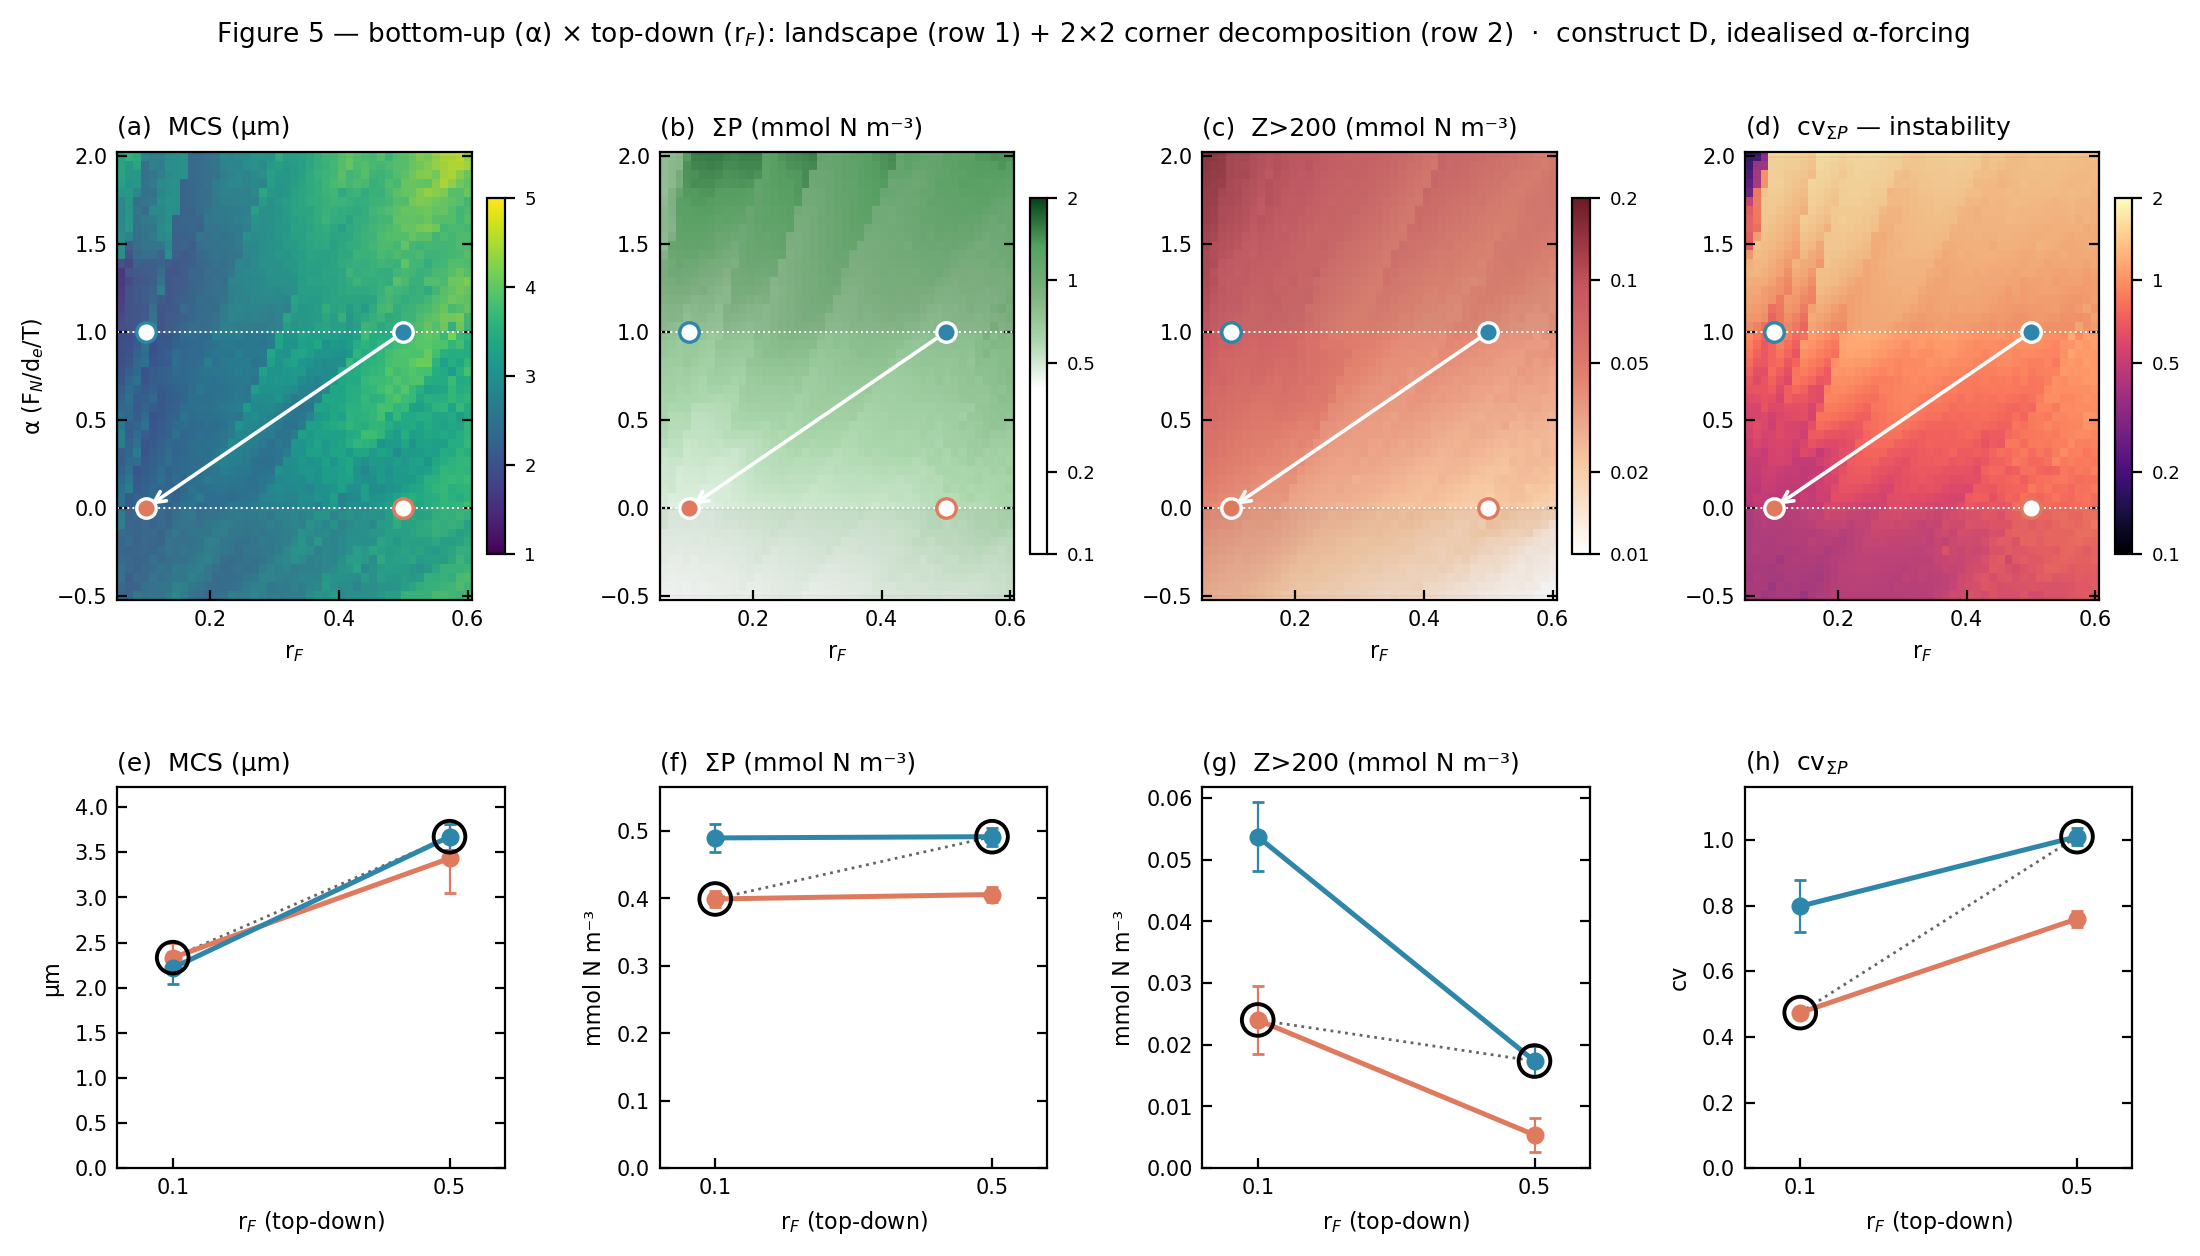

displayed region: r_F ≥ 0.05, α full
metric                        min       p5   median      p95      max    set [vmin, vmax]
MCS (µm)                    1.529    2.166    3.018    3.927    4.615    [1.0, 5.0]
ΣP (mmol N m⁻³)            0.4049   0.4448   0.7034    1.291    1.573    [0.4, 2.0]
Z>200 (mmol N m⁻³)       0.008908   0.0166  0.04181  0.09708   0.1556    [0.01, 0.2]
cv$_{ΣP}$ — instability    0.1613   0.4635    0.898    1.492    1.696    [0.1, 2.0]


In [16]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import NullLocator

ds = xr.open_dataset('results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc')
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
RF_MIN = 0.05; A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5; W = 1
C_POST, C_PRE = '#E07A5F', '#2E86AB'
# ---- Fig 2b palettes (reuse the manuscript P=green / Z=red identity) ----
cmap_phiP = LinearSegmentedColormap.from_list('phiP', ['white','#ABD7AD','#7CB380','#52A25E','#04421C'])
cmap_phiZ = LinearSegmentedColormap.from_list('phiZ', ['white','#F7C9A3','#E1806E','#C75560','#6B1A24'])
def style(ax): ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)   # Fig 2b tick style

dsf = ds.sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = dsf[A_NAME].values, dsf[R_NAME].values
av, rv = ds[A_NAME].values, ds[R_NAME].values
def surf(k): return dsf[k].transpose(A_NAME, R_NAME).values
def corner(key, a, rf, mode):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[key].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)})
    vals = (blk.median(D_NAME) if mode == 'traj' else blk).values
    return float(np.mean(vals)), float(np.std(vals))
    
HEAT = [('mcs_med','MCS (µm)','viridis',False, 1.0, 5.0, [1,2,3,4,5]),
        ('sumP','ΣP (mmol N m⁻³)',cmap_phiP,True, 0.4, 2.0, [0.1,0.2,0.5,1.0,2.0]),
        ('Z200','Z>200 (mmol N m⁻³)',cmap_phiZ,True, 0.01, 0.2, [0.01,0.02,0.05,0.1,0.2]),
        ('cv_sumP','cv$_{ΣP}$ — instability','magma',True, 0.1, 2.0, [0.1,0.2,0.5,1,2])]
PANELS = [('MCS (µm)','traj_mcs','µm','traj'), ('ΣP (mmol N m⁻³)','traj_sumP','mmol N m⁻³','traj'),
          ('Z>200 (mmol N m⁻³)','traj_Z200','mmol N m⁻³','traj'), ('cv$_{ΣP}$','cv_sumP','cv','scalar')]

OPS = [(1.0,0.5,C_PRE,True), (0.0,0.1,C_POST,True), (1.0,0.1,C_PRE,False), (0.0,0.5,C_POST,False)]

def heat_overlay(ax):
    ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10); ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0,1): ax.axhline(y, color='white', lw=0.7, ls=':')
    ax.annotate('', xy=(0.1,0.0), xytext=(0.5,1.0), arrowprops=dict(arrowstyle='->', lw=1.3, color='white'), zorder=6)
    for a, rf, col, filled in OPS:
        ax.plot(rf, a, 'o', ms=7, color=col, mfc=(col if filled else 'white'), mec=('white' if filled else col), mew=1.2, zorder=7)

fig = plt.figure(figsize=(13, 6.6))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1.0, 0.85], hspace=0.45, wspace=0.40)
for ci, (key, label, cmap, logf, vmin, vmax, ticks) in enumerate(HEAT):
    ax = fig.add_subplot(gs[0, ci]); s = surf(key)
    norm = LogNorm(vmin=vmin, vmax=vmax) if logf else Normalize(vmin=vmin, vmax=vmax)
    pc = ax.pcolormesh(R_F, alpha, s, shading='nearest', cmap=cmap, norm=norm)
    heat_overlay(ax); ax.set_title(f'({"abcd"[ci]})  {label}', fontsize=9, loc='left'); ax.set_xlabel('r$_F$', fontsize=8)
    if ci == 0: ax.set_ylabel(r'α (F$_N$/d$_e$/T)', fontsize=8)
    style(ax)
    cb = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_ticks(ticks); cb.ax.set_yticklabels([f'{v:g}' for v in ticks])
    cb.ax.yaxis.set_minor_locator(NullLocator()); cb.ax.tick_params(labelsize=6.5)

for ci, (label, key, unit, mode) in enumerate(PANELS):
    ax = fig.add_subplot(gs[1, ci])
    (M00,e00),(M10,e10),(M01,e01),(M11,e11) = (corner(key,A0,RL,mode), corner(key,A1,RL,mode),
                                               corner(key,A0,RH,mode), corner(key,A1,RH,mode))
    RF = [0.1, 0.5]
    ax.plot(RF, [M00,M01], '-o', color=C_POST, lw=1.8, ms=5.5, zorder=3)
    ax.plot(RF, [M10,M11], '-o', color=C_PRE,  lw=1.8, ms=5.5, zorder=3)
    ax.errorbar(RF, [M00,M01], yerr=[e00,e01], fmt='none', ecolor=C_POST, elinewidth=0.8, capsize=2, zorder=2)
    ax.errorbar(RF, [M10,M11], yerr=[e10,e11], fmt='none', ecolor=C_PRE,  elinewidth=0.8, capsize=2, zorder=2)
    ax.scatter([0.1],[M00], s=130, facecolor='none', edgecolor='k', lw=1.4, zorder=5)
    ax.scatter([0.5],[M11], s=130, facecolor='none', edgecolor='k', lw=1.4, zorder=5)
    ax.plot([0.1,0.5], [M00,M11], ls=':', color='0.4', lw=1.0, zorder=1)
    ax.set_xticks(RF); ax.set_xlim(0.02,0.58); ax.set_ylim(0, 1.15*max(M00,M10,M01,M11))
    ax.set_xlabel('r$_F$ (top-down)', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(f'({"efgh"[ci]})  {label}', fontsize=9, loc='left'); style(ax)

fig.suptitle('Figure 5 — bottom-up (α) × top-down (r$_F$): landscape (row 1) + 2×2 corner decomposition (row 2)  ·  construct D, idealised α-forcing', fontsize=9.5)
fig.tight_layout(rect=(0,0,1,0.95))
#fig.savefig('results/Figure5_draft.pdf', bbox_inches='tight')
plt.show()

print(f"displayed region: r_F ≥ {RF_MIN}, α full\n"
      f"{'metric':24s}{'min':>9}{'p5':>9}{'median':>9}{'p95':>9}{'max':>9}    set [vmin, vmax]")
for key, label, cmap, logf, vmin, vmax, ticks in HEAT:
    s = surf(key)
    print(f"{label:24s}{np.nanmin(s):9.4g}{np.nanpercentile(s,5):9.4g}{np.nanmedian(s):9.4g}"
          f"{np.nanpercentile(s,95):9.4g}{np.nanmax(s):9.4g}    [{vmin}, {vmax}]")

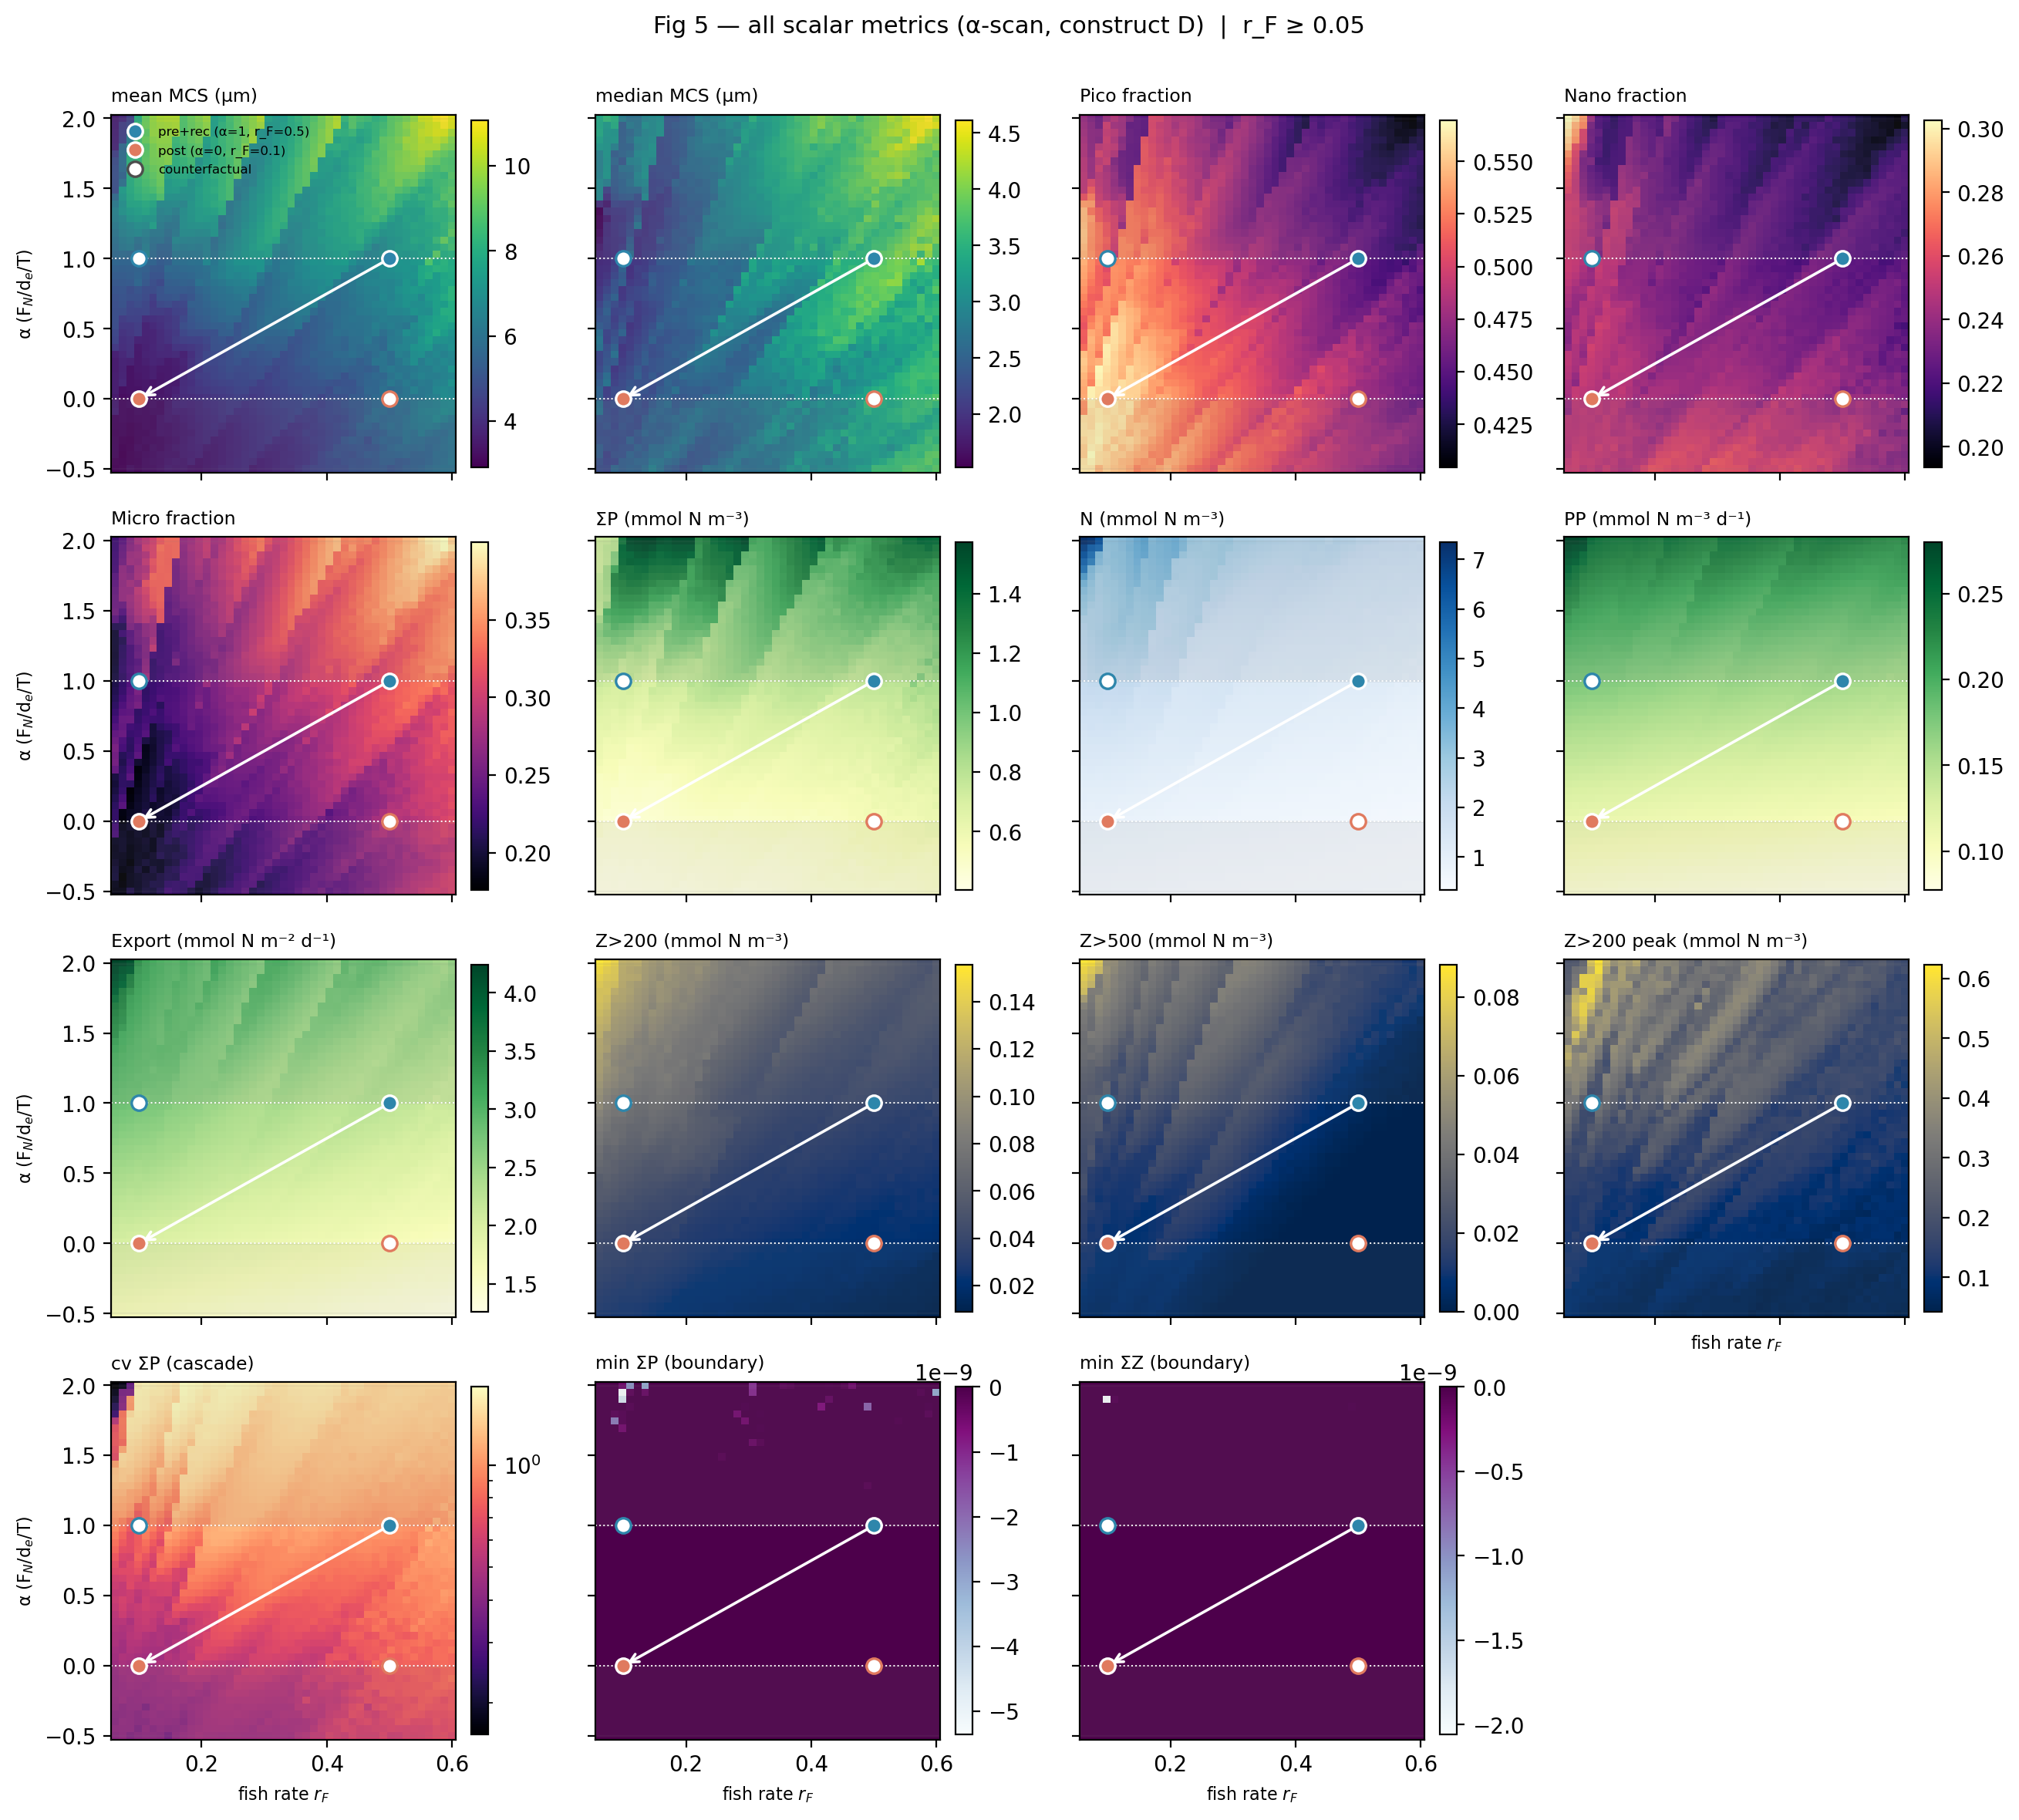

r_F range after cut: [0.061, 0.600]  (RF_MIN=0.05)
skipped: none

=== operating-point values (nearest grid) ===
  snapped: pre+rec α+0.98 rF0.50 | post α+0.01 rF0.10 | cf pre-for α+0.98 rF0.10 | cf post-fo α+0.01 rF0.50

metric             pre+rec           post cf pre-forcing cf post-forcin
mcs                 6.9234         3.3194         5.4597         5.6389
mcs_med             3.7355         2.2721         2.3137         3.5651
pico                0.4552         0.5577         0.5108         0.4770
nano                0.2263         0.2492         0.2426         0.2354
micro               0.3186         0.1930         0.2466         0.2876
sumP                0.7816         0.4707         0.7030         0.5554
N                   1.1811         0.8621         2.1365         0.5808
PP                  0.1576         0.1150         0.1739         0.1041
Export              2.2324         2.0048         2.7493         1.6512
Z200                0.0386         0.0389         0.0790   

In [5]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib, matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import LogNorm

# ---- flags -----------------------------------------------------------------
NC          = 'results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc'
RF_MIN      = 0.05     # fish-rate lower bound (fish always present; r_F=0 = anomalous end-member)
SHOW_EXTRAP = True     # grey shade for α∉[0,1] (counterfactual extrapolation)
NCOLS       = 4
A_NAME, R_NAME = 'alpha', 'rF'

ds = xr.open_dataset(NC).sel({R_NAME: slice(RF_MIN, None)})   # apply r_F lower bound
alpha, R_F = ds[A_NAME].values, ds[R_NAME].values
def surf(key): return ds[key].transpose(A_NAME, R_NAME).values
def _cmap(n):
    try: return matplotlib.colormaps[n]
    except Exception: return matplotlib.colormaps['magma']

# ---- operating points (filled = obs-anchored) + counterfactuals (open) -----
OPS = [('pre+rec',                1.0, 0.5, '#2E86AB', True),
       ('post',                   0.0, 0.1, '#E07A5F', True),
       ('cf pre-forcing post r_F',1.0, 0.1, '#2E86AB', False),
       ('cf post-forcing pre r_F',0.0, 0.5, '#E07A5F', False)]

def _overlay(ax):
    if SHOW_EXTRAP:
        ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10)
        ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0, 1): ax.axhline(y, color='white', lw=0.7, ls=':')   # α=0/1 lines (kept)
    ax.annotate('', xy=(0.1, 0.0), xytext=(0.5, 1.0),
                arrowprops=dict(arrowstyle='->', lw=1.3, color='white'), zorder=6)
    for lbl, a, rf, col, filled in OPS:
        ax.plot(rf, a, 'o', ms=7, color=col, mfc=(col if filled else 'white'),
                mec=('white' if filled else col), mew=1.2, zorder=7)

# ---- metric spec: (key, label, cmap, log?)  — all-NaN fields auto-skipped ---
SPEC = [('mcs','mean MCS (µm)','viridis',False), ('mcs_med','median MCS (µm)','viridis',False),
        ('pico','Pico fraction','magma',False),  ('nano','Nano fraction','magma',False),
        ('micro','Micro fraction','magma',False),('sumP','ΣP (mmol N m⁻³)','YlGn',False),
        ('N','N (mmol N m⁻³)','Blues',False),     ('PP','PP (mmol N m⁻³ d⁻¹)','YlGn',False),
        ('Export','Export (mmol N m⁻² d⁻¹)','YlGn',False),
        ('Z200','Z>200 (mmol N m⁻³)','cividis',False), ('Z500','Z>500 (mmol N m⁻³)','cividis',False),
        ('Z200_peak','Z>200 peak (mmol N m⁻³)','cividis',False),
        ('cv_sumP','cv ΣP (cascade)','magma',True),
        ('minP','min ΣP (boundary)','BuPu',False), ('minZ','min ΣZ (boundary)','BuPu',False)]

panels, skipped = [], []
for key, lab, cmap, logf in SPEC:
    if key not in ds: skipped.append(f"{key} (missing)"); continue
    s = surf(key)
    if not np.isfinite(s).any(): skipped.append(f"{key} (all-NaN)"); continue
    panels.append((key, lab, cmap, logf, s))

# ---- grid ------------------------------------------------------------------
n, ncol = len(panels), NCOLS; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.3*ncol, 3.0*nrow), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for k, (ax, (key, lab, cmap, logf, s)) in enumerate(zip(axes, panels)):
    norm = LogNorm(vmin=max(float(np.nanmin(s)), 1e-3), vmax=float(np.nanmax(s))) if logf else None
    pc = ax.pcolormesh(R_F, alpha, s, shading='nearest', cmap=_cmap(cmap), norm=norm)
    # ax.contour(...) / clabel intentionally removed (visually noisy)
    _overlay(ax); ax.set_title(lab, fontsize=8.5, loc='left')
    fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
    r, c = divmod(k, ncol)
    if c == 0:            ax.set_ylabel(r'α (F$_N$/d$_e$/T)', fontsize=8)
    if k + ncol >= n:     ax.set_xlabel('fish rate $r_F$', fontsize=8)
for ax in axes[n:]: ax.axis('off')

axes[0].legend(handles=[
    plt.Line2D([0],[0], marker='o', ms=7, color='#2E86AB', mfc='#2E86AB', mec='white', mew=1.2, ls='',
               label='pre+rec (α=1, r_F=0.5)'),
    plt.Line2D([0],[0], marker='o', ms=7, color='#E07A5F', mfc='#E07A5F', mec='white', mew=1.2, ls='',
               label='post (α=0, r_F=0.1)'),
    plt.Line2D([0],[0], marker='o', ms=7, color='0.3', mfc='white', mec='0.3', mew=1.2, ls='',
               label='counterfactual'),
], fontsize=6, frameon=False, loc='upper left')
fig.suptitle(f'Fig 5 — all scalar metrics (α-scan, construct D)  |  r_F ≥ {RF_MIN}', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.98)); plt.show()

# === diagnostics ============================================================
def _near(a, v): return int(np.argmin(np.abs(a - v)))
keys = [p[0] for p in panels]
idx  = [(_near(alpha, a), _near(R_F, rf)) for _, a, rf, _, _ in OPS]
print(f"r_F range after cut: [{R_F.min():.3f}, {R_F.max():.3f}]  (RF_MIN={RF_MIN})")
print("skipped:", ", ".join(skipped) if skipped else "none")
print("\n=== operating-point values (nearest grid) ===")
print(f"  snapped: " + " | ".join(f"{lbl[:10]} α{alpha[i]:+.2f} rF{R_F[j]:.2f}"
                                   for (lbl,*_), (i,j) in zip(OPS, idx)))
print(f"\n{'metric':11s}" + "".join(f"{lbl[:14]:>15s}" for lbl,*_ in OPS))
for k in keys:
    print(f"{k:11s}" + "".join(f"{float(surf(k)[i,j]):15.4f}" for (i,j) in idx))
print("\n=== surface ranges (after cut) ===")
for k in keys:
    s = surf(k); print(f"  {k:10s} [{np.nanmin(s):.4g}, {np.nanmax(s):.4g}]")
print(f"\nmax nan_frac: {float(ds['nan_frac'].max()):.3g}   "
      f"cells |conv-1|>0.10: {int((np.abs(surf('mcs_conv')-1)>0.10).sum())}/{surf('mcs_conv').size}")

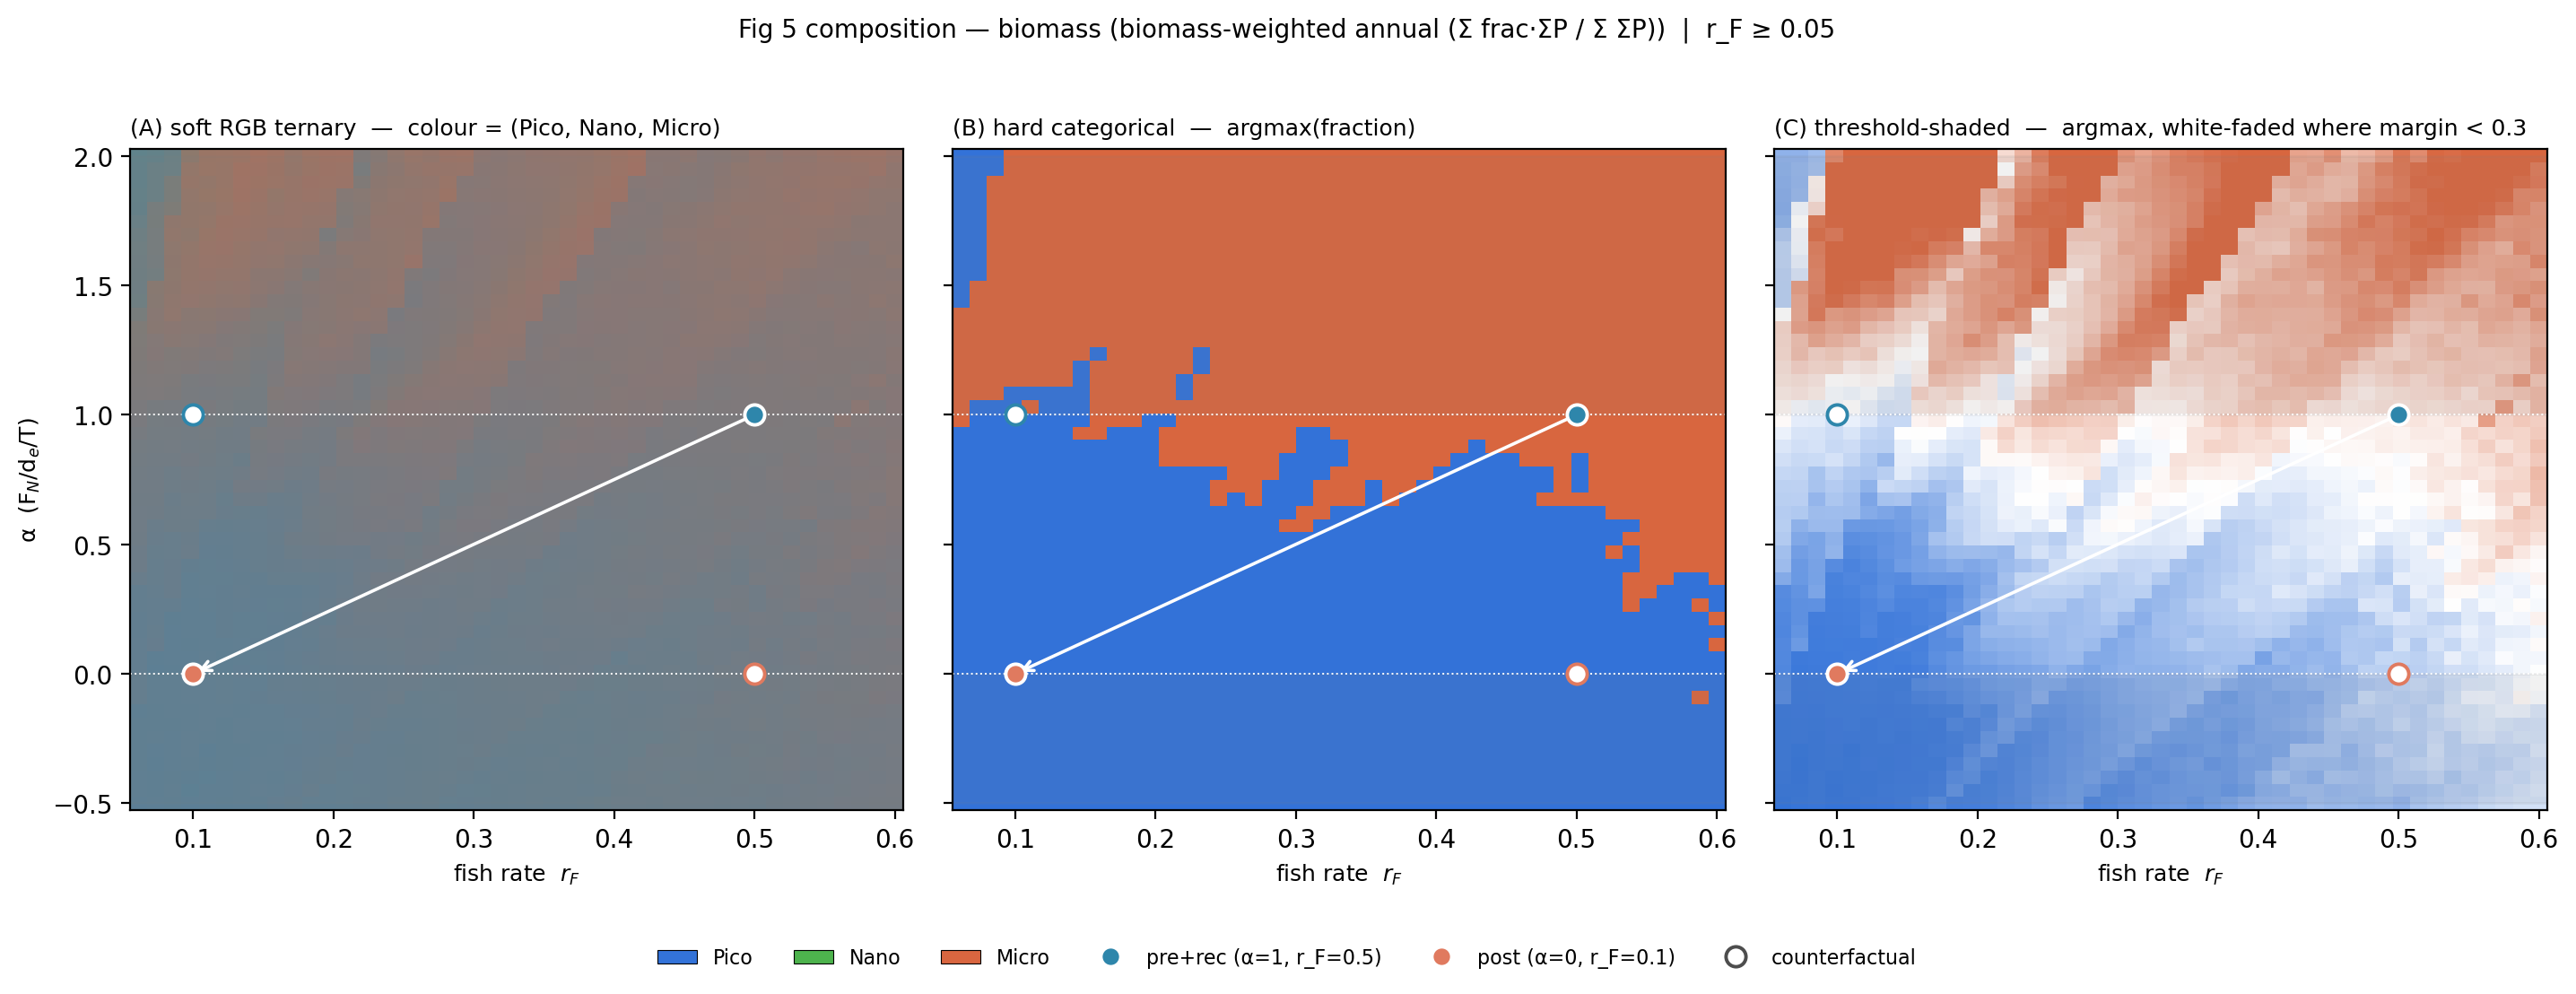

mode: biomass  (biomass-weighted annual (Σ frac·ΣP / Σ ΣP))
sum pre-normalise, mean over valid cells: 1.000

per-class fraction across the plane:
  Pico  mean 0.398  max 0.548
  Nano  mean 0.203  max 0.303
  Micro mean 0.399  max 0.667

argmax (which class dominates each cell):
  Pico : 1174/2250  (52.2%)
  Nano :    0/2250  (0.0%)
  Micro: 1076/2250  (47.8%)

dominance margin (max-2nd): min 0.000  median 0.142  max 0.457
  cells margin > 0.10: 1457/2250
  cells margin > 0.20: 713/2250
  cells margin > 0.30: 140/2250

composition at operating points:
  pre+rec                    (α+0.98, rF0.50): pico 0.38  nano 0.20  micro 0.42  -> Micro
  post                       (α+0.01, rF0.10): pico 0.53  nano 0.24  micro 0.23  -> Pico
  cf pre-forcing post r_F    (α+0.98, rF0.10): pico 0.42  nano 0.22  micro 0.36  -> Pico
  cf post-forcing pre r_F    (α+0.01, rF0.50): pico 0.45  nano 0.22  micro 0.34  -> Pico


In [8]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import xarray as xr
from matplotlib.patches import Patch

# ---- flags -----------------------------------------------------------------
NC          = 'results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc'
RF_MIN      = 0.05
COMPOSITION = 'biomass'    # 'bloom' | 'annual' | 'biomass'
PEAK_SRC    = 'clim_sumP'  # bloom-mode only: peak month = argmax of this clim field ('clim_mcs' for size-peak)
M_REF       = 0.30         # margin at which the threshold-shaded encoding reaches full saturation
SHOW_EXTRAP = True
A_NAME, R_NAME, M_NAME = 'alpha', 'rF', 'month'

ds = xr.open_dataset(NC).sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = ds[A_NAME].values, ds[R_NAME].values

# ---- composition fractions over the (α, r_F) plane -------------------------
def _annual():                                              # plain annual mean of monthly fractions
    g = lambda k: ds[k].transpose(A_NAME, R_NAME).values
    return g('pico'), g('nano'), g('micro')

def _bloom():                                               # fractions at each cell's peak-bloom month
    peak = ds[PEAK_SRC].argmax(M_NAME)
    g = lambda k: ds[k].isel({M_NAME: peak}).transpose(A_NAME, R_NAME).values
    return g('clim_pico'), g('clim_nano'), g('clim_micro')

def _biomass():                                            # biomass-weighted annual: Σ_m(frac_m·ΣP_m)/Σ_m ΣP_m
    w = ds['clim_sumP']
    g = lambda k: ((ds[k] * w).sum(M_NAME) / w.sum(M_NAME)).transpose(A_NAME, R_NAME).values
    return g('clim_pico'), g('clim_nano'), g('clim_micro')

pico, nano, micro = {'bloom': _bloom, 'annual': _annual, 'biomass': _biomass}[COMPOSITION]()
fr = np.stack([pico, nano, micro], -1)
ssum = fr.sum(-1, keepdims=True)
fr = np.where(ssum > 0, fr / ssum, np.nan)                 # defensive normalise
valid = np.isfinite(fr).all(-1)
argmax_cls = np.argmax(np.where(np.isfinite(fr), fr, -np.inf), -1)

ORDER   = ['Pico', 'Nano', 'Micro']
COLOURS = {'Pico': np.array([0.20, 0.45, 0.85]),
           'Nano': np.array([0.30, 0.70, 0.30]),
           'Micro':np.array([0.85, 0.40, 0.25])}
C = np.stack([COLOURS[c] for c in ORDER])

# ---- encodings -------------------------------------------------------------
soft = np.clip(np.tensordot(np.nan_to_num(fr), C, axes=([2], [0])), 0, 1)
soft[~valid] = 1.0
hard = np.ones(fr.shape); hard[valid] = C[argmax_cls[valid]]
srt    = np.sort(np.where(np.isfinite(fr), fr, np.nan), -1)[..., ::-1]
margin = srt[..., 0] - srt[..., 1]
blend  = np.clip(margin / M_REF, 0, 1)[..., None]
thr = np.ones(fr.shape)
thr[valid] = (C[argmax_cls] * blend + 1.0 * (1 - blend))[valid]

# ---- markers ---------------------------------------------------------------
OPS = [('pre+rec', 1.0, 0.5, '#2E86AB', True), ('post', 0.0, 0.1, '#E07A5F', True),
       ('cf pre-forcing post r_F', 1.0, 0.1, '#2E86AB', False),
       ('cf post-forcing pre r_F', 0.0, 0.5, '#E07A5F', False)]
def _overlay(ax):
    if SHOW_EXTRAP:
        ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10)
        ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0, 1): ax.axhline(y, color='white', lw=0.7, ls=':')
    ax.annotate('', xy=(0.1, 0.0), xytext=(0.5, 1.0),
                arrowprops=dict(arrowstyle='->', lw=1.3, color='white'), zorder=6)
    for lbl, a, rf, col, filled in OPS:
        ax.plot(rf, a, 'o', ms=8, color=col, mfc=(col if filled else 'white'),
                mec=('white' if filled else col), mew=1.4, zorder=7)

def _extent(x, y):
    dx, dy = (x[1]-x[0])/2, (y[1]-y[0])/2
    return (x[0]-dx, x[-1]+dx, y[0]-dy, y[-1]+dy)
ext = _extent(R_F, alpha)

# ---- plot ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14.5, 5.4), sharey=True)
for ax, img, title in [
    (axes[0], soft, '(A) soft RGB ternary  —  colour = (Pico, Nano, Micro)'),
    (axes[1], hard, '(B) hard categorical  —  argmax(fraction)'),
    (axes[2], thr,  f'(C) threshold-shaded  —  argmax, white-faded where margin < {M_REF}')]:
    ax.imshow(img, origin='lower', extent=ext, aspect='auto', interpolation='nearest')
    _overlay(ax)
    ax.set_xlabel('fish rate  $r_F$', fontsize=9); ax.set_title(title, fontsize=9, loc='left')
axes[0].set_ylabel(r'α  (F$_N$/d$_e$/T)', fontsize=9)

handles = [Patch(facecolor=COLOURS[c], edgecolor='k', lw=0.4, label=c) for c in ORDER] + [
    plt.Line2D([], [], marker='o', color='#2E86AB', mfc='#2E86AB', mec='white', mew=1.4, ms=8, ls='',
               label='pre+rec (α=1, r_F=0.5)'),
    plt.Line2D([], [], marker='o', color='#E07A5F', mfc='#E07A5F', mec='white', mew=1.4, ms=8, ls='',
               label='post (α=0, r_F=0.1)'),
    plt.Line2D([], [], marker='o', color='0.3', mfc='white', mec='0.3', mew=1.4, ms=8, ls='',
               label='counterfactual')]
fig.legend(handles=handles, fontsize=8, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
_sub = {'bloom': f'peak month from {PEAK_SRC}', 'annual': 'annual mean of fractions',
        'biomass': 'biomass-weighted annual (Σ frac·ΣP / Σ ΣP)'}[COMPOSITION]
fig.suptitle(f'Fig 5 composition — {COMPOSITION} ({_sub})  |  r_F ≥ {RF_MIN}', fontsize=10)
fig.tight_layout(rect=(0, 0.05, 1, 0.96)); plt.show()

# === diagnostics ============================================================
print(f"mode: {COMPOSITION}  ({_sub})")
print(f"sum pre-normalise, mean over valid cells: {np.nanmean(ssum):.3f}")
print("\nper-class fraction across the plane:")
for k, name in enumerate(ORDER):
    arr = fr[..., k]; print(f"  {name:5s} mean {np.nanmean(arr):.3f}  max {np.nanmax(arr):.3f}")
print("\nargmax (which class dominates each cell):")
for k, name in enumerate(ORDER):
    nsel = int((valid & (argmax_cls == k)).sum())
    print(f"  {name:5s}: {nsel:4d}/{int(valid.sum())}  ({100*nsel/max(int(valid.sum()),1):.1f}%)")
print(f"\ndominance margin (max-2nd): min {np.nanmin(margin):.3f}  "
      f"median {np.nanmedian(margin):.3f}  max {np.nanmax(margin):.3f}")
for t in (0.10, 0.20, 0.30):
    print(f"  cells margin > {t:.2f}: {int(np.nansum(margin>t))}/{margin.size}")

def _near(a, v): return int(np.argmin(np.abs(a - v)))
print("\ncomposition at operating points:")
for lbl, a, rf, col, filled in OPS:
    i, j = _near(alpha, a), _near(R_F, rf)
    p, nn, m = fr[i, j]
    dom = ORDER[argmax_cls[i, j]] if valid[i, j] else 'na'
    print(f"  {lbl:26s} (α{alpha[i]:+.2f}, rF{R_F[j]:.2f}): "
          f"pico {p:.2f}  nano {nn:.2f}  micro {m:.2f}  -> {dom}")

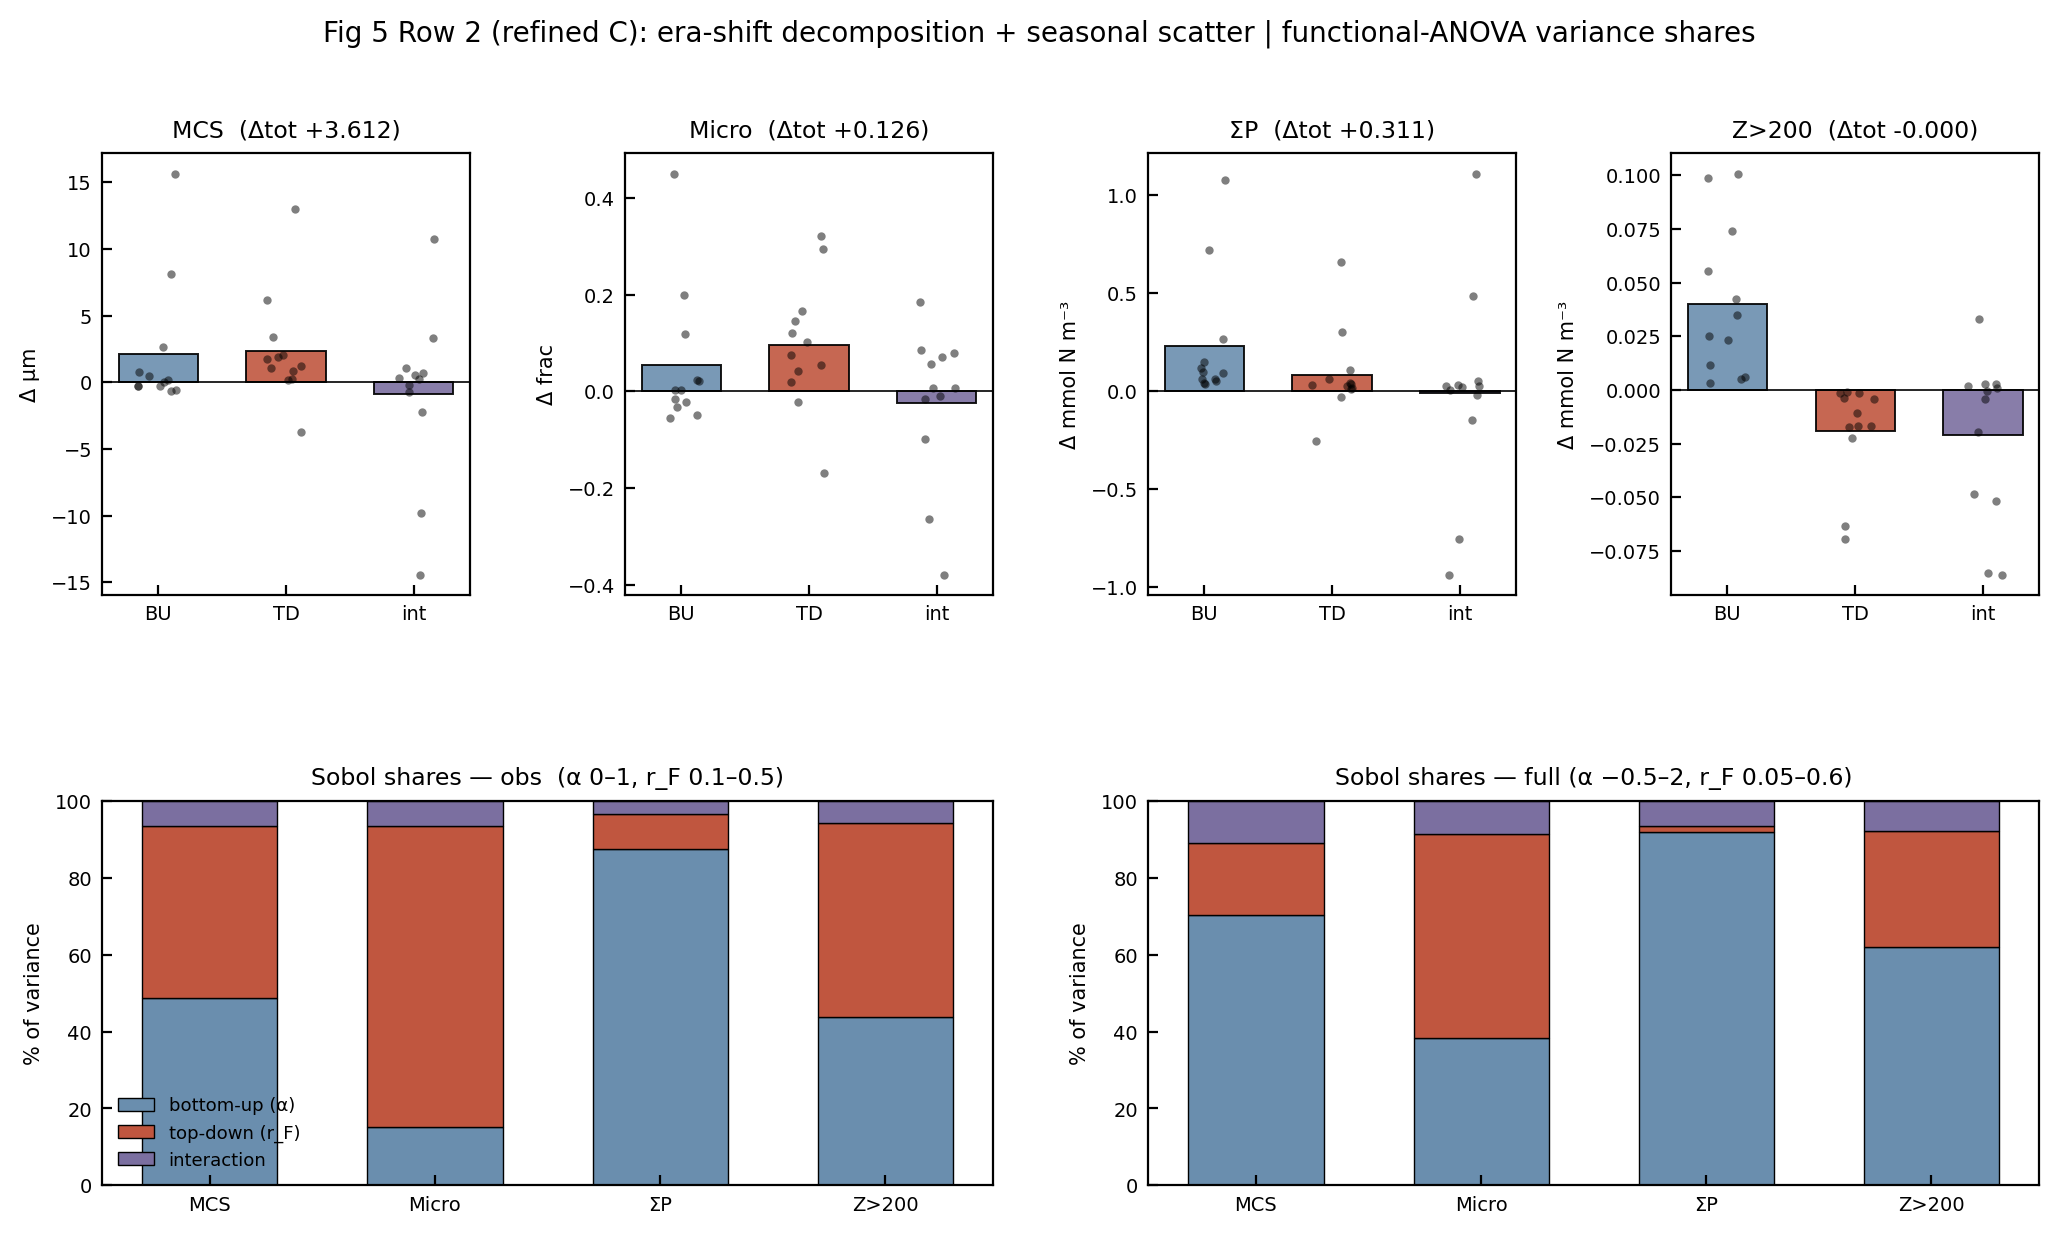

=== endpoint decomposition (BU/TD anchored at post; seasonal mean [min,max over months]) ===

MCS (Δtot +3.612 µm):
  bottom-up   +2.1435  [-0.6324, +15.6591]
  top-down    +2.3422  [-3.7045, +13.0314]
  interaction -0.8742  [-14.4496, +10.7630]

Micro (Δtot +0.126 frac):
  bottom-up   +0.0537  [-0.0551, +0.4502]
  top-down    +0.0957  [-0.1678, +0.3203]
  interaction -0.0230  [-0.3792, +0.1843]

ΣP (Δtot +0.311 mmol N m⁻³):
  bottom-up   +0.2322  [+0.0367, +1.0789]
  top-down    +0.0859  [-0.2507, +0.6621]
  interaction -0.0070  [-0.9361, +1.1115]

Z>200 (Δtot -0.000 mmol N m⁻³):
  bottom-up   +0.0401  [+0.0034, +0.1009]
  top-down    -0.0190  [-0.0693, -0.0008]
  interaction -0.0212  [-0.0862, +0.0329]

=== functional-ANOVA / Sobol variance shares (%) ===

obs  (α 0–1, r_F 0.1–0.5):
  metric      BU%    TD%   int%
  MCS        48.9   44.7    6.5
  Micro      15.2   78.3    6.5
  ΣP         87.5    9.3    3.2
  Z>200      43.8   50.6    5.6

full (α −0.5–2, r_F 0.05–0.6):
  metric    

In [19]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import xarray as xr

NC = 'results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc'
A_NAME, R_NAME, M_NAME = 'alpha', 'rF', 'month'
ds = xr.open_dataset(NC)

# metric: (label, clim key, unit). All decomposition + Sobol use the clim arrays (consistent).
METRICS = [('MCS', 'clim_mcs', 'µm'), ('Micro', 'clim_micro', 'frac'),
           ('ΣP', 'clim_sumP', 'mmol N m⁻³'), ('Z>200', 'clim_Z200', 'mmol N m⁻³')]
A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5                    # 2x2 corner coordinates
COL = {'bottom-up': '#6A8EAE', 'top-down': '#C0563F', 'interaction': '#7B6FA0'}
RNG = np.random.default_rng(0)
WINDOWS = {'obs  (α 0–1, r_F 0.1–0.5)': (0.0, 1.0, 0.1, 0.5),
           'full (α −0.5–2, r_F 0.05–0.6)': (-0.5, 2.0, 0.05, 0.6)}

def clim_corner(ckey, a, rf):                          # monthly values at one corner -> (12,)
    return ds[ckey].sel({A_NAME: a, R_NAME: rf}, method='nearest').values

def sobol(ckey, amin, amax, rmin, rmax):               # functional-ANOVA on the annual-mean surface
    M = (ds[ckey].mean(M_NAME).transpose(A_NAME, R_NAME)
         .sel({A_NAME: slice(amin, amax), R_NAME: slice(rmin, rmax)}).values)
    gm = M.mean(); fa = M.mean(1) - gm; fr = M.mean(0) - gm
    inter = M - gm - fa[:, None] - fr[None, :]; SStot = ((M - gm) ** 2).sum()
    if SStot == 0: return np.nan, np.nan, np.nan
    return ((fa**2).sum()*M.shape[1]/SStot, (fr**2).sum()*M.shape[0]/SStot, (inter**2).sum()/SStot)

# ---- figure ----
fig = plt.figure(figsize=(12.5, 6.7))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1.15, 1.0], hspace=0.50, wspace=0.42)
axd = [fig.add_subplot(gs[0, j]) for j in range(4)]
decomp = {}
for ax, (label, ckey, unit) in zip(axd, METRICS):
    M00, M10 = clim_corner(ckey, A0, RL), clim_corner(ckey, A1, RL)
    M01, M11 = clim_corner(ckey, A0, RH), clim_corner(ckey, A1, RH)
    terms = {'bottom-up': M10 - M00, 'top-down': M01 - M00,
             'interaction': M11 - M10 - M01 + M00}                  # each (12,)
    decomp[label] = (terms, (M11 - M00).mean())
    for x, (nm, v) in enumerate(terms.items()):
        ax.bar(x, v.mean(), 0.62, color=COL[nm], edgecolor='k', lw=0.7, alpha=0.9, zorder=2)
        ax.scatter(x + RNG.uniform(-0.16, 0.16, 12), v, s=9, color='k', alpha=0.5, lw=0, zorder=4)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_xticks(range(3)); ax.set_xticklabels(['BU', 'TD', 'int'], fontsize=8)
    ax.set_title(f"{label}  (Δtot {(M11-M00).mean():+.3f})", fontsize=8.5)
    ax.set_ylabel(f'Δ {unit}', fontsize=7.5); ax.tick_params(direction='in', labelsize=7)

axs = [fig.add_subplot(gs[1, 0:2]), fig.add_subplot(gs[1, 2:4])]
sob = {}
for ax, (wlab, (amin, amax, rmin, rmax)) in zip(axs, WINDOWS.items()):
    labels = [m[0] for m in METRICS]; x = np.arange(len(labels))
    S = np.array([sobol(ck, amin, amax, rmin, rmax) for _, ck, _ in METRICS]) * 100   # (nmetric, 3)
    sob[wlab] = S
    ax.bar(x, S[:, 0], 0.6, color=COL['bottom-up'], label='bottom-up (α)', edgecolor='k', lw=0.5)
    ax.bar(x, S[:, 1], 0.6, bottom=S[:, 0], color=COL['top-down'], label='top-down (r_F)', edgecolor='k', lw=0.5)
    ax.bar(x, S[:, 2], 0.6, bottom=S[:, 0]+S[:, 1], color=COL['interaction'], label='interaction', edgecolor='k', lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8); ax.set_ylim(0, 100)
    ax.set_ylabel('% of variance', fontsize=7.5); ax.set_title(f'Sobol shares — {wlab}', fontsize=8.5)
    ax.tick_params(direction='in', labelsize=7)
axs[0].legend(fontsize=6.5, frameon=False, loc='lower left')
fig.suptitle('Fig 5 Row 2 (refined C): era-shift decomposition + seasonal scatter | functional-ANOVA variance shares', fontsize=10)
plt.show()

# ---- diagnostics ----
print("=== endpoint decomposition (BU/TD anchored at post; seasonal mean [min,max over months]) ===")
for label, _, unit in METRICS:
    terms, tot = decomp[label]
    print(f"\n{label} (Δtot {tot:+.3f} {unit}):")
    for nm in ('bottom-up', 'top-down', 'interaction'):
        v = terms[nm]; print(f"  {nm:11s} {v.mean():+.4f}  [{v.min():+.4f}, {v.max():+.4f}]")
print("\n=== functional-ANOVA / Sobol variance shares (%) ===")
for wlab, S in sob.items():
    print(f"\n{wlab}:\n  {'metric':8s} {'BU%':>6} {'TD%':>6} {'int%':>6}")
    for i, (label, _, _) in enumerate(METRICS):
        print(f"  {label:8s} {S[i,0]:6.1f} {S[i,1]:6.1f} {S[i,2]:6.1f}")

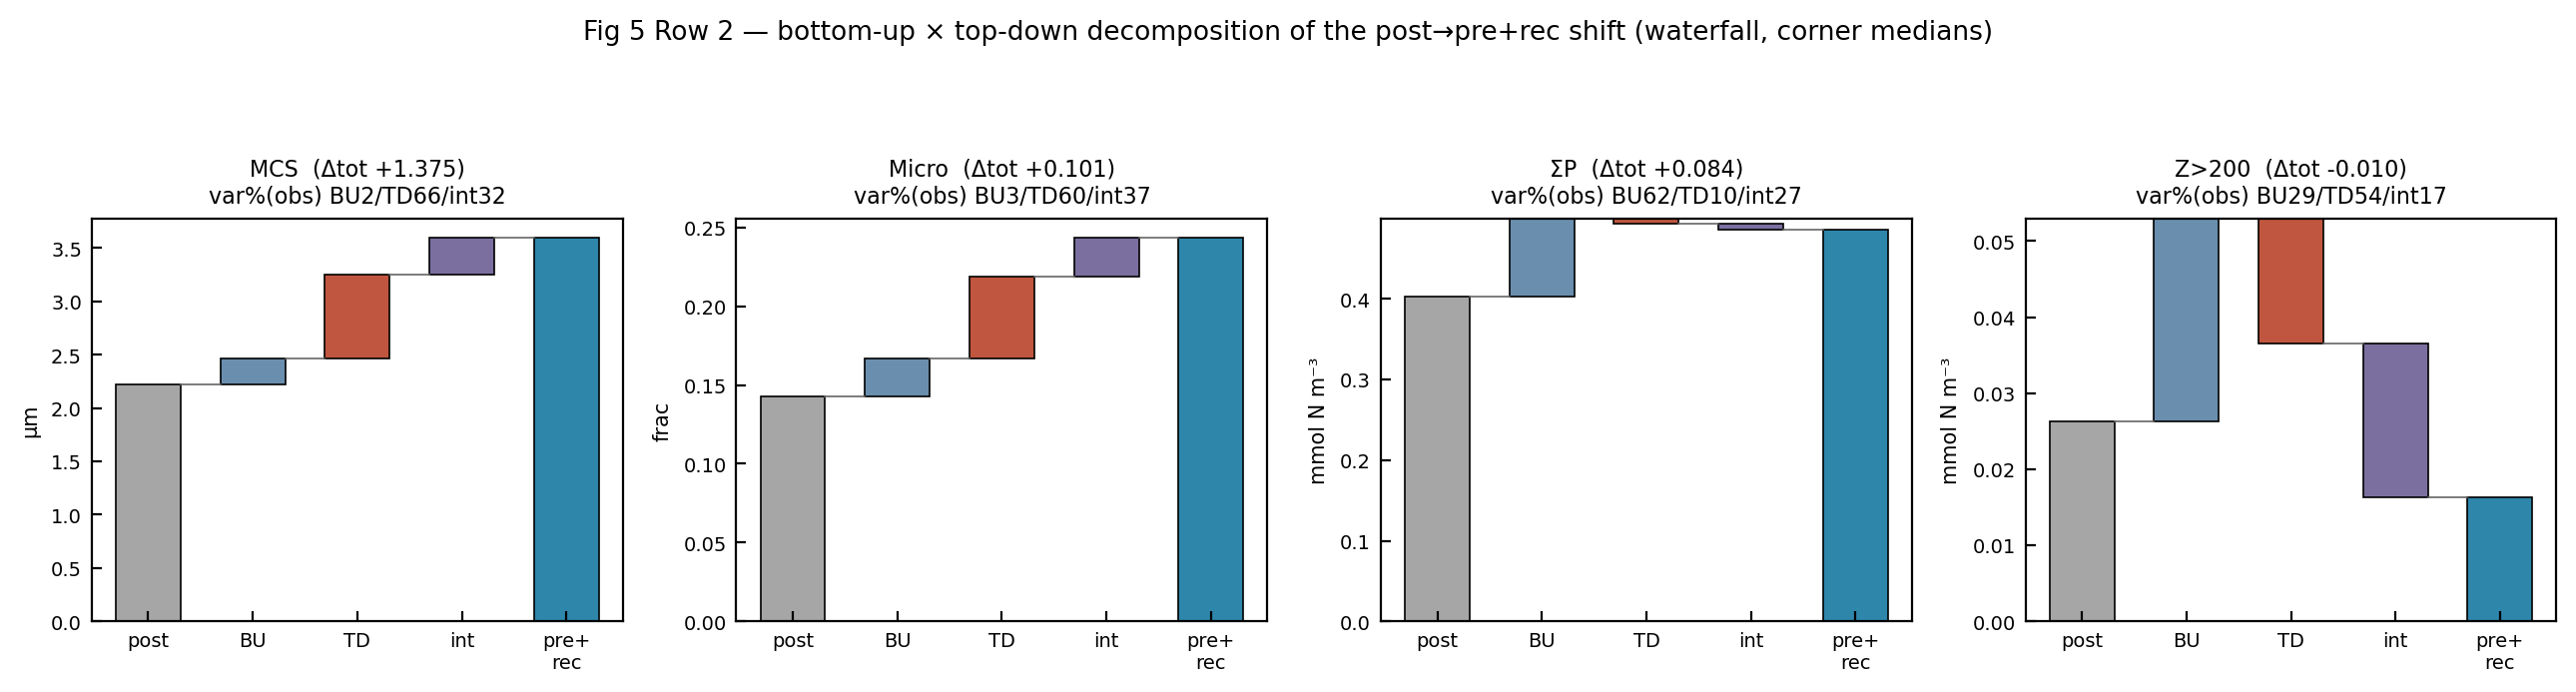

=== endpoint decomposition (corner medians) + block-bootstrap 90% CI  (* = CI excludes 0) ===

MCS (Δtot +1.375 µm):
  bottom-up   +0.2485  90%CI [-0.2334, +0.7874]
  top-down    +0.7801  90%CI [+0.5673, +1.3227]  *
  interaction +0.3466  90%CI [-0.4117, +0.9677]

Micro (Δtot +0.101 frac):
  bottom-up   +0.0244  90%CI [-0.0321, +0.0806]
  top-down    +0.0517  90%CI [+0.0339, +0.1243]  *
  interaction +0.0247  90%CI [-0.0520, +0.1040]

ΣP (Δtot +0.084 mmol N m⁻³):
  bottom-up   +0.0971  90%CI [-0.0499, +0.2952]
  top-down    -0.0066  90%CI [-0.1190, +0.1174]
  interaction -0.0065  90%CI [-0.2283, +0.1771]

Z>200 (Δtot -0.010 mmol N m⁻³):
  bottom-up   +0.0266  90%CI [-0.0097, +0.0701]
  top-down    -0.0163  90%CI [-0.0397, +0.0111]
  interaction -0.0202  90%CI [-0.0696, +0.0190]

=== Sobol variance shares (%) — median surface ===

obs (α0–1, r_F0.1–0.5):
  metric      BU%    TD%   int%
  MCS         1.9   65.7   32.4
  Micro       3.3   59.5   37.2
  ΣP         62.2   10.4   27.4
  Z>20

In [20]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import xarray as xr

NC = 'results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc'
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
ds = xr.open_dataset(NC)

METRICS = [('MCS','traj_mcs','µm'), ('Micro','traj_micro','frac'),
           ('ΣP','traj_sumP','mmol N m⁻³'), ('Z>200','traj_Z200','mmol N m⁻³')]
A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5
COL = {'BU':'#6A8EAE','TD':'#C0563F','int':'#7B6FA0'}; ERA = '#2E86AB'
RNG = np.random.default_rng(0)
WINDOWS = {'obs (α0–1, r_F0.1–0.5)':(0.0,1.0,0.1,0.5), 'full (α−0.5–2, r_F0.05–0.6)':(-0.5,2.0,0.05,0.6)}
MEDSURF = {lab: ds[tk].median(D_NAME).transpose(A_NAME, R_NAME) for lab, tk, _ in METRICS}

def cmed(tk, a, rf):
    v = ds[tk].sel({A_NAME:a, R_NAME:rf}, method='nearest').values; return np.median(v[np.isfinite(v)])

def sobol(surf, amin, amax, rmin, rmax):
    M = surf.sel({A_NAME:slice(amin,amax), R_NAME:slice(rmin,rmax)}).values
    gm = M.mean(); fa = M.mean(1)-gm; fr = M.mean(0)-gm; it = M-gm-fa[:,None]-fr[None,:]
    tot = ((M-gm)**2).sum()
    return (np.nan,)*3 if tot == 0 else ((fa**2).sum()*M.shape[1]/tot, (fr**2).sum()*M.shape[0]/tot, (it**2).sum()/tot)

def block_boot(tk, nboot=400, block=120):
    A = {k: ds[tk].sel({A_NAME:a, R_NAME:rf}, method='nearest').values
         for k,(a,rf) in [('00',(A0,RL)),('10',(A1,RL)),('01',(A0,RH)),('11',(A1,RH))]}
    A = {k: v[np.isfinite(v)] for k, v in A.items()}
    def rs(v):
        n = len(v); st = RNG.integers(0, n-block+1, int(np.ceil(n/block)))
        return np.median(np.concatenate([v[s:s+block] for s in st])[:n])
    o = {'BU':[], 'TD':[], 'int':[]}
    for _ in range(nboot):
        m00, m10, m01, m11 = rs(A['00']), rs(A['10']), rs(A['01']), rs(A['11'])
        o['BU'].append(m10-m00); o['TD'].append(m01-m00); o['int'].append(m11-m10-m01+m00)
    return {k: (np.percentile(v,5), np.percentile(v,95)) for k, v in o.items()}

# ---- one row of waterfalls ----
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5)); res = {}
for ax, (label, tk, unit) in zip(axes, METRICS):
    M00, M10, M01, M11 = cmed(tk,A0,RL), cmed(tk,A1,RL), cmed(tk,A0,RH), cmed(tk,A1,RH)
    dBU, dTD, dINT = M10-M00, M01-M00, M11-M10-M01+M00
    res[label] = dict(M00=M00, M11=M11, dBU=dBU, dTD=dTD, dINT=dINT)
    ax.bar(0, M00, 0.62, color='0.65', edgecolor='k', lw=0.6)
    ax.bar(4, M11, 0.62, color=ERA, edgecolor='k', lw=0.6)
    for x, base, step, c in [(1,M00,dBU,COL['BU']), (2,M00+dBU,dTD,COL['TD']), (3,M00+dBU+dTD,dINT,COL['int'])]:
        ax.bar(x, step, 0.62, bottom=base, color=c, edgecolor='k', lw=0.6)
    for x, c in zip(range(4), [M00, M00+dBU, M00+dBU+dTD, M11]):
        ax.plot([x+0.31, x+0.69], [c, c], color='0.4', lw=0.6)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xticks(range(5)); ax.set_xticklabels(['post','BU','TD','int','pre+\nrec'], fontsize=7)
    ax.set_ylabel(unit, fontsize=7.5); ax.tick_params(direction='in', labelsize=7)
    sa, sr, si = sobol(MEDSURF[label], *WINDOWS['obs (α0–1, r_F0.1–0.5)'])
    ax.set_title(f"{label}  (Δtot {M11-M00:+.3f})\nvar%(obs) BU{sa*100:.0f}/TD{sr*100:.0f}/int{si*100:.0f}", fontsize=8)
fig.suptitle('Fig 5 Row 2 — bottom-up × top-down decomposition of the post→pre+rec shift (waterfall, corner medians)', fontsize=9.5)
fig.tight_layout(rect=(0,0,1,0.90)); plt.show()

# ---- diagnostics ----
print("=== endpoint decomposition (corner medians) + block-bootstrap 90% CI  (* = CI excludes 0) ===")
for label, tk, unit in METRICS:
    r = res[label]; ci = block_boot(tk)
    print(f"\n{label} (Δtot {r['M11']-r['M00']:+.3f} {unit}):")
    for nm, key, ck in [('bottom-up','dBU','BU'), ('top-down','dTD','TD'), ('interaction','dINT','int')]:
        lo, hi = ci[ck]; sig = '' if lo < 0 < hi else '  *'
        print(f"  {nm:11s} {r[key]:+.4f}  90%CI [{lo:+.4f}, {hi:+.4f}]{sig}")
print("\n=== Sobol variance shares (%) — median surface ===")
for wlab, win in WINDOWS.items():
    print(f"\n{wlab}:\n  {'metric':8s}{'BU%':>7}{'TD%':>7}{'int%':>7}")
    for label, tk, _ in METRICS:
        sa, sr, si = sobol(MEDSURF[label], *win)
        print(f"  {label:8s}{sa*100:7.1f}{sr*100:7.1f}{si*100:7.1f}")

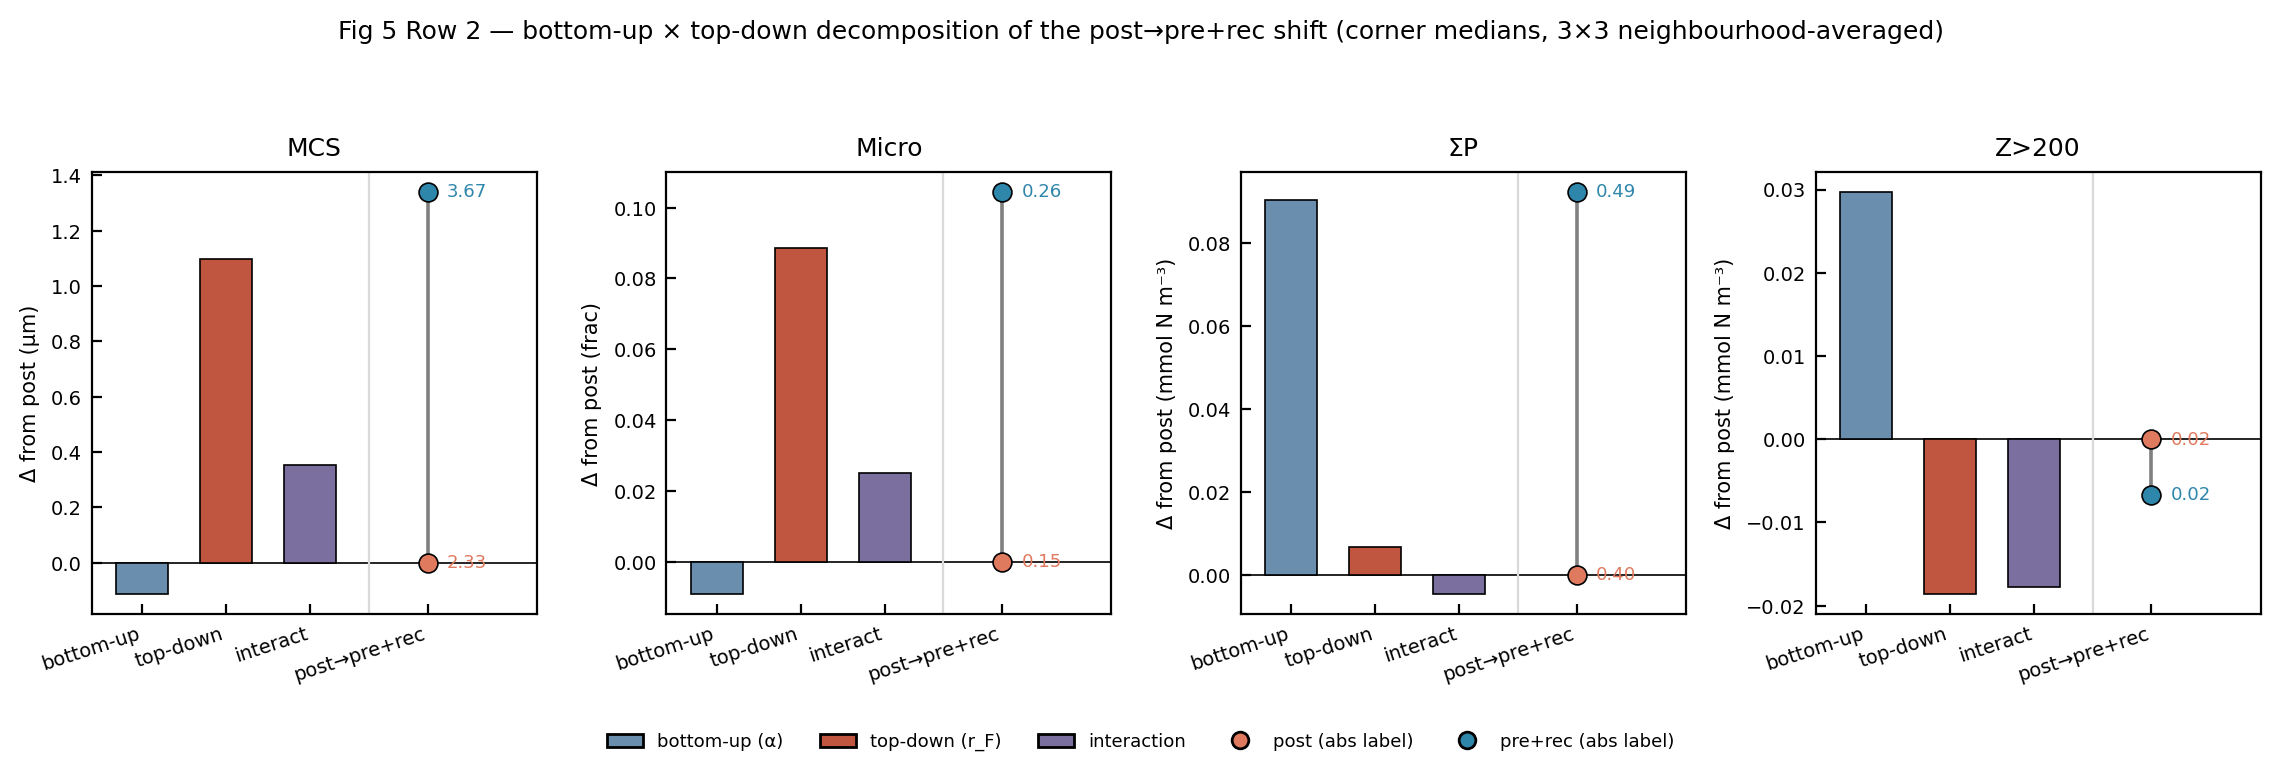

=== 2x2 decomposition (neighbourhood-averaged corner medians; sd across the 3x3 cells) ===

MCS: post 2.332 -> pre+rec 3.672 µm  (Δtot +1.340; BU+TD+int = +1.340)
  bottom-up -0.1141   top-down +1.0995   interaction +0.3548
  corner sd: post 0.165  cf-A 0.181  cf-B 0.379  pre+rec 0.145

Micro: post 0.151 -> pre+rec 0.255 frac  (Δtot +0.104; BU+TD+int = +0.104)
  bottom-up -0.0092   top-down +0.0886   interaction +0.0251
  corner sd: post 0.019  cf-A 0.017  cf-B 0.027  pre+rec 0.012

ΣP: post 0.399 -> pre+rec 0.492 mmol N m⁻³  (Δtot +0.092; BU+TD+int = +0.092)
  bottom-up +0.0905   top-down +0.0066   interaction -0.0047
  corner sd: post 0.011  cf-A 0.021  cf-B 0.011  pre+rec 0.013

Z>200: post 0.024 -> pre+rec 0.017 mmol N m⁻³  (Δtot -0.007; BU+TD+int = -0.007)
  bottom-up +0.0297   top-down -0.0186   interaction -0.0177
  corner sd: post 0.006  cf-A 0.006  cf-B 0.003  pre+rec 0.002

=== supporting Sobol shares (%) [print only] ===

obs (α0–1, r_F0.1–0.5):
  metric      BU%    TD%   in

In [24]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

NC = 'results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc'
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
ds = xr.open_dataset(NC)

METRICS = [('MCS','traj_mcs','µm'), ('Micro','traj_micro','frac'),
           ('ΣP','traj_sumP','mmol N m⁻³'), ('Z>200','traj_Z200','mmol N m⁻³')]
A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5
COL = {'BU':'#6A8EAE','TD':'#C0563F','int':'#7B6FA0'}
C_POST, C_PRE = '#E07A5F', '#2E86AB'
W = 1
av, rv = ds[A_NAME].values, ds[R_NAME].values

def corner(tk, a, rf):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[tk].isel({A_NAME: slice(max(i-W,0), i+W+1),
                       R_NAME: slice(max(j-W,0), j+W+1)}).median(D_NAME).values
    return float(np.mean(blk)), float(np.std(blk))

def sobol(tk, amin, amax, rmin, rmax):
    M = ds[tk].median(D_NAME).transpose(A_NAME, R_NAME).sel(
        {A_NAME: slice(amin, amax), R_NAME: slice(rmin, rmax)}).values
    gm = M.mean(); fa = M.mean(1)-gm; fr = M.mean(0)-gm; it = M-gm-fa[:,None]-fr[None,:]
    tot = ((M-gm)**2).sum()
    return (np.nan,)*3 if tot == 0 else ((fa**2).sum()*M.shape[1]/tot, (fr**2).sum()*M.shape[0]/tot, (it**2).sum()/tot)

fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.7)); DEC = {}
for ax, (label, tk, unit) in zip(axes, METRICS):
    (M00,s00),(M10,s10),(M01,s01),(M11,s11) = corner(tk,A0,RL), corner(tk,A1,RL), corner(tk,A0,RH), corner(tk,A1,RH)
    dBU, dTD, dINT, tot = M10-M00, M01-M00, M11-M10-M01+M00, M11-M00
    DEC[label] = dict(M00=M00, M11=M11, dBU=dBU, dTD=dTD, dINT=dINT, tot=tot, sd=(s00,s10,s01,s11))
    for x, v, c in [(0,dBU,COL['BU']), (1,dTD,COL['TD']), (2,dINT,COL['int'])]:
        ax.bar(x, v, 0.62, color=c, edgecolor='k', lw=0.6, zorder=3)
    ax.axhline(0, color='k', lw=0.6); ax.axvline(2.7, color='0.85', lw=0.8)
    # dumbbell on the SAME Δ axis: post at 0, pre+rec at Δtot -> gap = net = sum of the bars
    ax.plot([3.4,3.4], [0,tot], color='0.5', lw=1.3, zorder=2)
    ax.scatter([3.4],[0],   s=46, color=C_POST, edgecolor='k', lw=0.6, zorder=4)
    ax.scatter([3.4],[tot], s=46, color=C_PRE,  edgecolor='k', lw=0.6, zorder=4)
    ax.annotate(f'{M00:.2f}', (3.4,0),   xytext=(7,0), textcoords='offset points', va='center', fontsize=6.5, color=C_POST)
    ax.annotate(f'{M11:.2f}', (3.4,tot), xytext=(7,0), textcoords='offset points', va='center', fontsize=6.5, color=C_PRE)
    ax.set_xticks([0,1,2,3.4])
    ax.set_xticklabels(['bottom-up','top-down','interact','post→pre+rec'], fontsize=6.5, rotation=18, ha='right')
    ax.set_ylabel(f'Δ from post ({unit})', fontsize=7.5); ax.set_xlim(-0.6, 4.7)
    ax.tick_params(direction='in', labelsize=7); ax.set_title(label, fontsize=9)

fig.legend(handles=[Patch(fc=COL['BU'],ec='k',label='bottom-up (α)'),
                    Patch(fc=COL['TD'],ec='k',label='top-down (r_F)'),
                    Patch(fc=COL['int'],ec='k',label='interaction'),
                    Line2D([],[],marker='o',ls='',mfc=C_POST,mec='k',label='post (abs label)'),
                    Line2D([],[],marker='o',ls='',mfc=C_PRE,mec='k',label='pre+rec (abs label)')],
           loc='lower center', ncol=5, fontsize=6.5, frameon=False, bbox_to_anchor=(0.5,-0.03))
fig.suptitle('Fig 5 Row 2 — bottom-up × top-down decomposition of the post→pre+rec shift (corner medians, 3×3 neighbourhood-averaged)', fontsize=9)
fig.tight_layout(rect=(0,0.04,1,0.94)); plt.show()

# ---- diagnostics ----
print("=== 2x2 decomposition (neighbourhood-averaged corner medians; sd across the 3x3 cells) ===")
for label, tk, unit in METRICS:
    d = DEC[label]
    print(f"\n{label}: post {d['M00']:.3f} -> pre+rec {d['M11']:.3f} {unit}  (Δtot {d['tot']:+.3f}; "
          f"BU+TD+int = {d['dBU']+d['dTD']+d['dINT']:+.3f})")
    print(f"  bottom-up {d['dBU']:+.4f}   top-down {d['dTD']:+.4f}   interaction {d['dINT']:+.4f}")
    print(f"  corner sd: post {d['sd'][0]:.3f}  cf-A {d['sd'][1]:.3f}  cf-B {d['sd'][2]:.3f}  pre+rec {d['sd'][3]:.3f}")
print("\n=== supporting Sobol shares (%) [print only] ===")
for wlab, win in [('obs (α0–1, r_F0.1–0.5)',(0.0,1.0,0.1,0.5)), ('full (α−0.5–2, r_F0.05–0.6)',(-0.5,2.0,0.05,0.6))]:
    print(f"\n{wlab}:\n  {'metric':8s}{'BU%':>7}{'TD%':>7}{'int%':>7}")
    for label, tk, _ in METRICS:
        sa, sr, si = sobol(tk, *win); print(f"  {label:8s}{sa*100:7.1f}{sr*100:7.1f}{si*100:7.1f}")

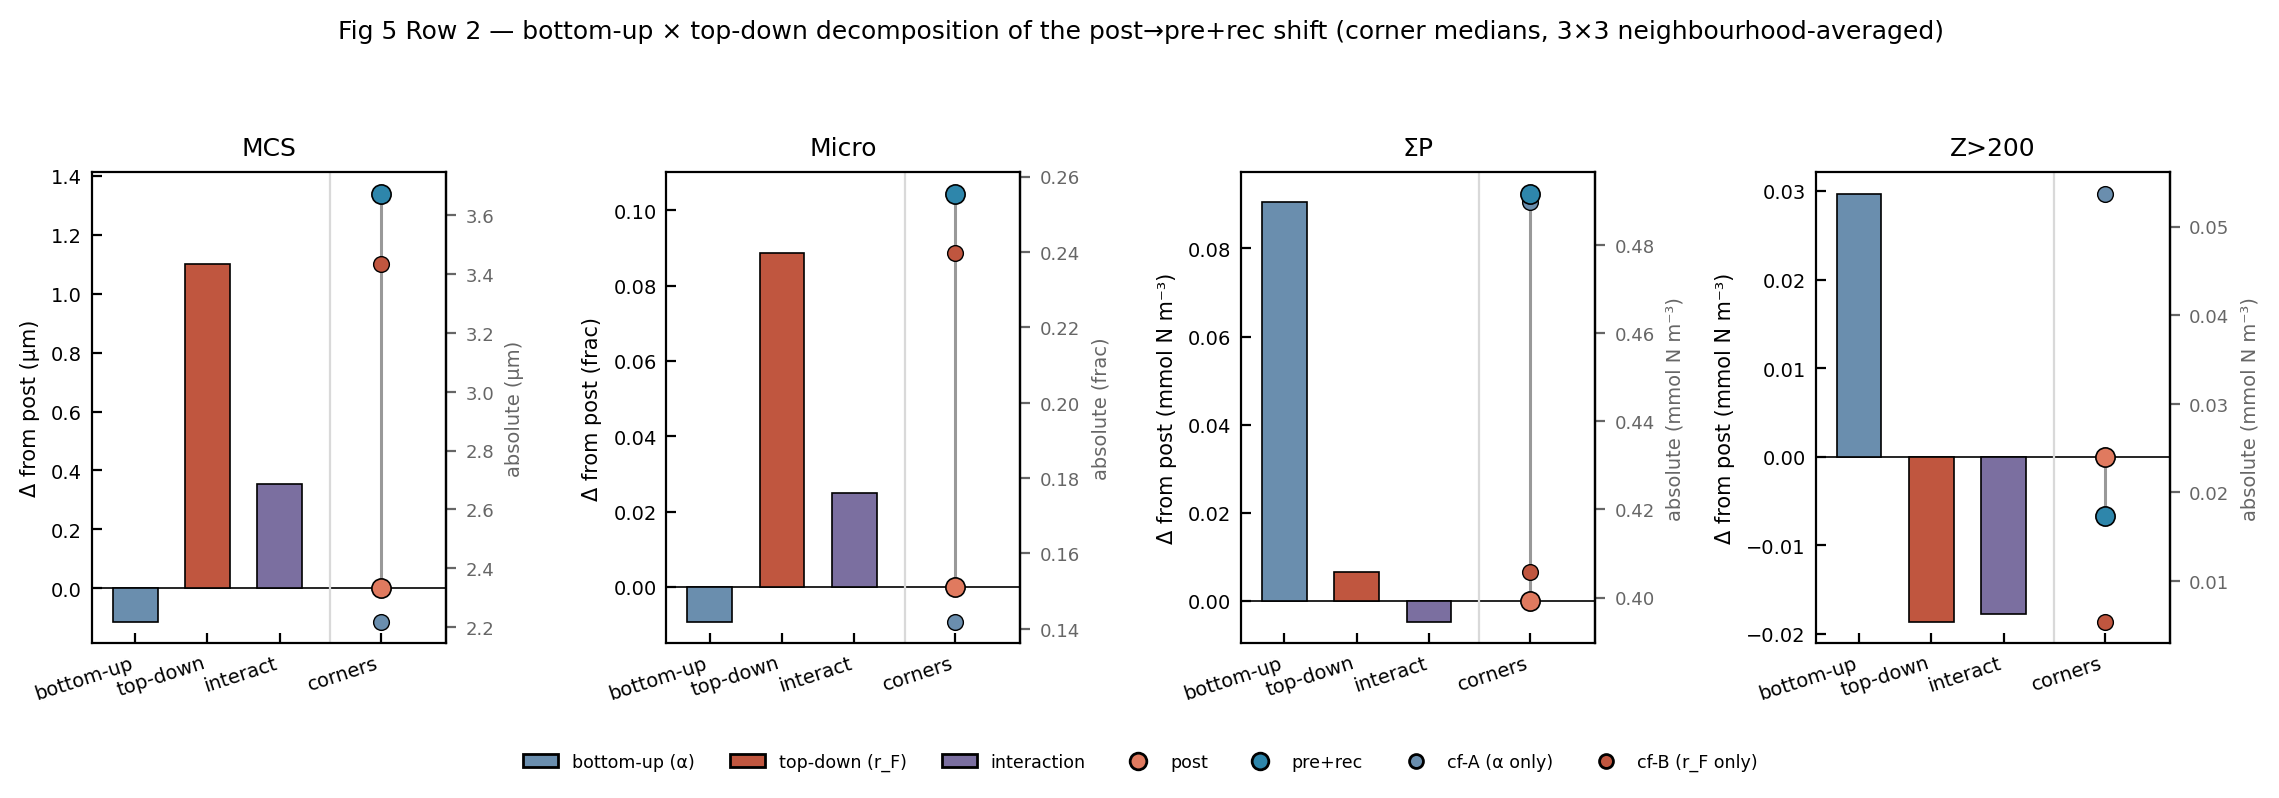

=== 2x2 decomposition (neighbourhood-averaged corner medians; sd across the 3x3 cells) ===

MCS: post 2.332 -> pre+rec 3.672 µm  (Δtot +1.340; BU+TD+int = +1.340)
  bottom-up -0.1141   top-down +1.0995   interaction +0.3548
  corner sd: post 0.165  cf-A 0.181  cf-B 0.379  pre+rec 0.145

Micro: post 0.151 -> pre+rec 0.255 frac  (Δtot +0.104; BU+TD+int = +0.104)
  bottom-up -0.0092   top-down +0.0886   interaction +0.0251
  corner sd: post 0.019  cf-A 0.017  cf-B 0.027  pre+rec 0.012

ΣP: post 0.399 -> pre+rec 0.492 mmol N m⁻³  (Δtot +0.092; BU+TD+int = +0.092)
  bottom-up +0.0905   top-down +0.0066   interaction -0.0047
  corner sd: post 0.011  cf-A 0.021  cf-B 0.011  pre+rec 0.013

Z>200: post 0.024 -> pre+rec 0.017 mmol N m⁻³  (Δtot -0.007; BU+TD+int = -0.007)
  bottom-up +0.0297   top-down -0.0186   interaction -0.0177
  corner sd: post 0.006  cf-A 0.006  cf-B 0.003  pre+rec 0.002

=== supporting Sobol shares (%) [print only] ===

obs (α0–1, r_F0.1–0.5):
  metric      BU%    TD%   in

In [25]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

NC = 'results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc'
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
ds = xr.open_dataset(NC)

METRICS = [('MCS','traj_mcs','µm'), ('Micro','traj_micro','frac'),
           ('ΣP','traj_sumP','mmol N m⁻³'), ('Z>200','traj_Z200','mmol N m⁻³')]
A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5
COL = {'BU':'#6A8EAE','TD':'#C0563F','int':'#7B6FA0'}
C_POST, C_PRE = '#E07A5F', '#2E86AB'
W = 1; SHOW_CF = True                              # show cf-A / cf-B corner dots
av, rv = ds[A_NAME].values, ds[R_NAME].values

def corner(tk, a, rf):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[tk].isel({A_NAME: slice(max(i-W,0), i+W+1),
                       R_NAME: slice(max(j-W,0), j+W+1)}).median(D_NAME).values
    return float(np.mean(blk)), float(np.std(blk))

def sobol(tk, amin, amax, rmin, rmax):
    M = ds[tk].median(D_NAME).transpose(A_NAME, R_NAME).sel(
        {A_NAME: slice(amin, amax), R_NAME: slice(rmin, rmax)}).values
    gm = M.mean(); fa = M.mean(1)-gm; fr = M.mean(0)-gm; it = M-gm-fa[:,None]-fr[None,:]
    tot = ((M-gm)**2).sum()
    return (np.nan,)*3 if tot == 0 else ((fa**2).sum()*M.shape[1]/tot, (fr**2).sum()*M.shape[0]/tot, (it**2).sum()/tot)

fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.8)); DEC = {}
for ax, (label, tk, unit) in zip(axes, METRICS):
    (M00,s00),(M10,s10),(M01,s01),(M11,s11) = corner(tk,A0,RL), corner(tk,A1,RL), corner(tk,A0,RH), corner(tk,A1,RH)
    dBU, dTD, dINT, tot = M10-M00, M01-M00, M11-M10-M01+M00, M11-M00
    DEC[label] = dict(M00=M00, M11=M11, dBU=dBU, dTD=dTD, dINT=dINT, tot=tot, sd=(s00,s10,s01,s11))
    for x, v, c in [(0,dBU,COL['BU']), (1,dTD,COL['TD']), (2,dINT,COL['int'])]:
        ax.bar(x, v, 0.62, color=c, edgecolor='k', lw=0.6, zorder=3)
    ax.axhline(0, color='k', lw=0.6); ax.axvline(2.7, color='0.85', lw=0.8)
    ax.plot([3.4,3.4], [0,tot], color='0.6', lw=1.1, zorder=2)                    # net span
    ax.scatter([3.4],[0],   s=48, color=C_POST, edgecolor='k', lw=0.6, zorder=5)  # post
    ax.scatter([3.4],[tot], s=48, color=C_PRE,  edgecolor='k', lw=0.6, zorder=5)  # pre+rec
    if SHOW_CF:
        ax.scatter([3.4],[dBU], s=32, color=COL['BU'], edgecolor='k', lw=0.5, zorder=4)  # cf-A (α only)
        ax.scatter([3.4],[dTD], s=32, color=COL['TD'], edgecolor='k', lw=0.5, zorder=4)  # cf-B (r_F only)
    ax.set_xticks([0,1,2,3.4])
    ax.set_xticklabels(['bottom-up','top-down','interact','corners'], fontsize=6.5, rotation=18, ha='right')
    ax.set_ylabel(f'Δ from post ({unit})', fontsize=7.5); ax.set_xlim(-0.6, 4.3)
    ax.tick_params(direction='in', labelsize=7); ax.set_title(label, fontsize=9)
    secax = ax.secondary_yaxis('right', functions=(lambda d, m=M00: d+m, lambda a, m=M00: a-m))  # absolute = Δ + post
    secax.set_ylabel(f'absolute ({unit})', fontsize=7, color='0.4'); secax.tick_params(labelsize=6.5, colors='0.4')

handles = [Patch(fc=COL['BU'],ec='k',label='bottom-up (α)'), Patch(fc=COL['TD'],ec='k',label='top-down (r_F)'),
           Patch(fc=COL['int'],ec='k',label='interaction'),
           Line2D([],[],marker='o',ls='',mfc=C_POST,mec='k',label='post'), Line2D([],[],marker='o',ls='',mfc=C_PRE,mec='k',label='pre+rec')]
if SHOW_CF:
    handles += [Line2D([],[],marker='o',ls='',mfc=COL['BU'],mec='k',ms=5,label='cf-A (α only)'),
                Line2D([],[],marker='o',ls='',mfc=COL['TD'],mec='k',ms=5,label='cf-B (r_F only)')]
fig.legend(handles=handles, loc='lower center', ncol=7, fontsize=6.3, frameon=False, bbox_to_anchor=(0.5,-0.03))
fig.suptitle('Fig 5 Row 2 — bottom-up × top-down decomposition of the post→pre+rec shift (corner medians, 3×3 neighbourhood-averaged)', fontsize=9)
fig.tight_layout(rect=(0,0.04,1,0.94)); plt.show()

# ---- diagnostics ----
print("=== 2x2 decomposition (neighbourhood-averaged corner medians; sd across the 3x3 cells) ===")
for label, tk, unit in METRICS:
    d = DEC[label]
    print(f"\n{label}: post {d['M00']:.3f} -> pre+rec {d['M11']:.3f} {unit}  (Δtot {d['tot']:+.3f}; BU+TD+int = {d['dBU']+d['dTD']+d['dINT']:+.3f})")
    print(f"  bottom-up {d['dBU']:+.4f}   top-down {d['dTD']:+.4f}   interaction {d['dINT']:+.4f}")
    print(f"  corner sd: post {d['sd'][0]:.3f}  cf-A {d['sd'][1]:.3f}  cf-B {d['sd'][2]:.3f}  pre+rec {d['sd'][3]:.3f}")
print("\n=== supporting Sobol shares (%) [print only] ===")
for wlab, win in [('obs (α0–1, r_F0.1–0.5)',(0.0,1.0,0.1,0.5)), ('full (α−0.5–2, r_F0.05–0.6)',(-0.5,2.0,0.05,0.6))]:
    print(f"\n{wlab}:\n  {'metric':8s}{'BU%':>7}{'TD%':>7}{'int%':>7}")
    for label, tk, _ in METRICS:
        sa, sr, si = sobol(tk, *win); print(f"  {label:8s}{sa*100:7.1f}{sr*100:7.1f}{si*100:7.1f}")

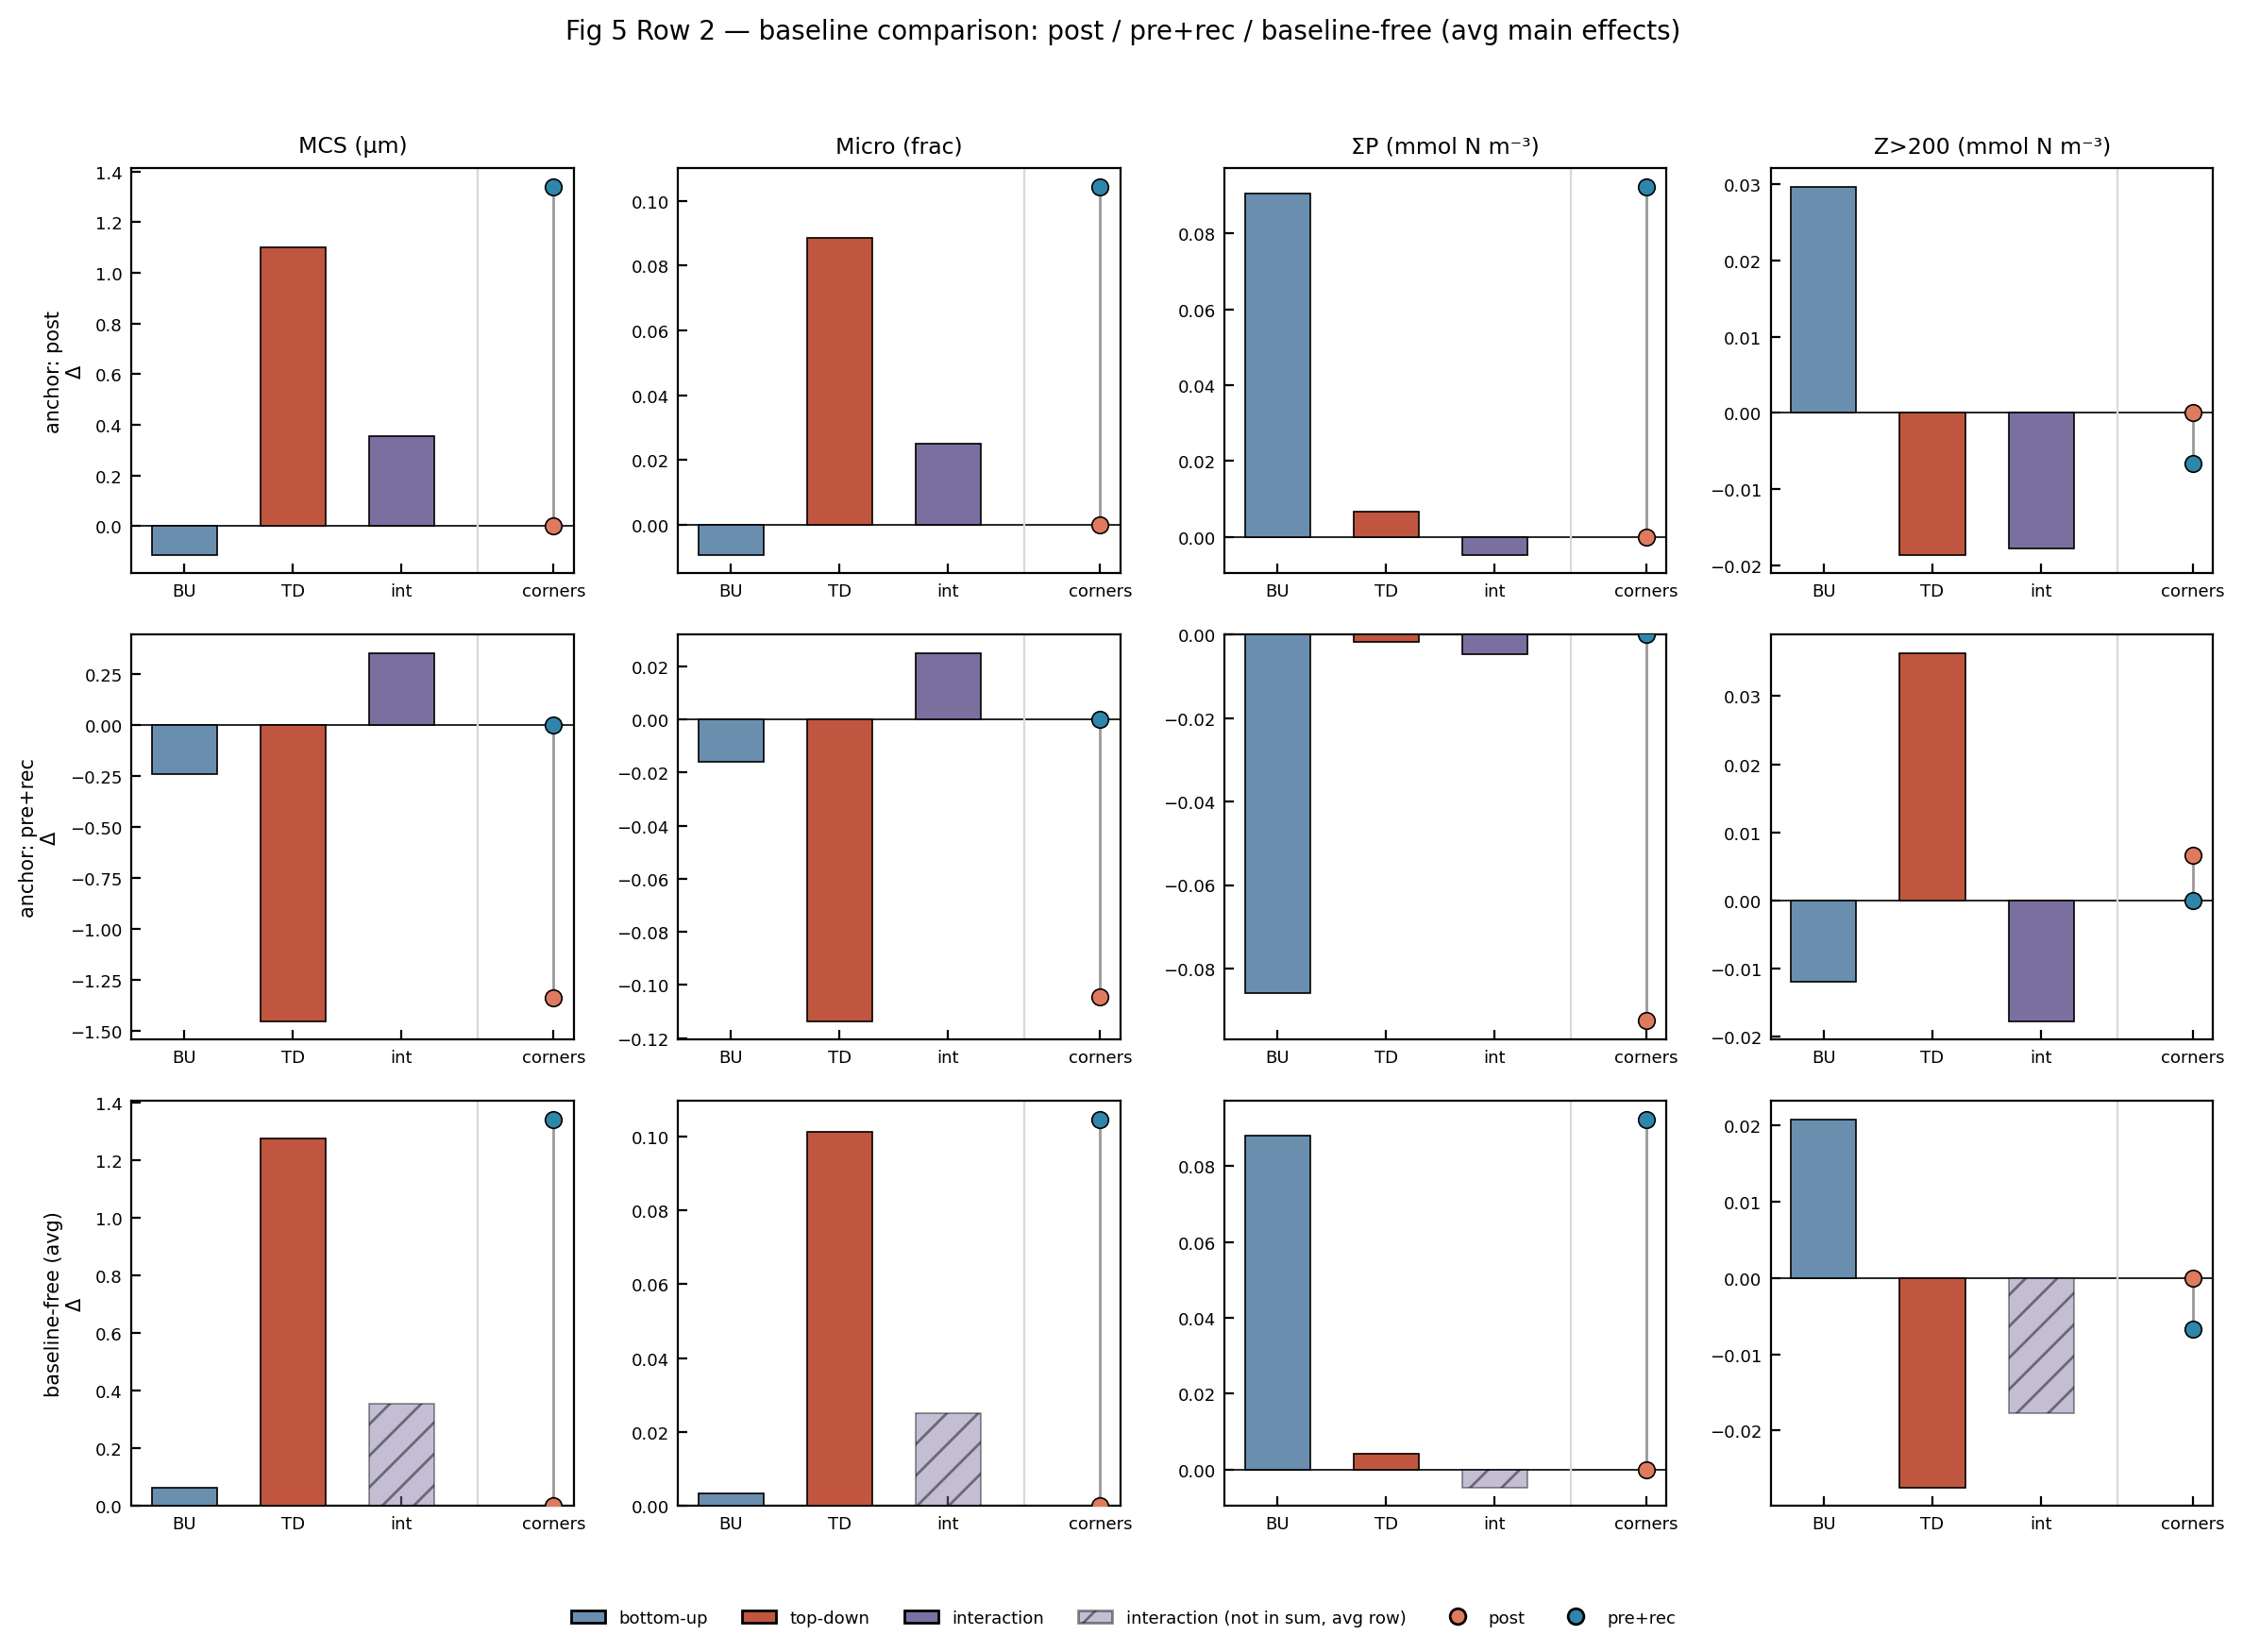


MCS: post 2.332  cf-A 2.218  cf-B 3.432  pre+rec 3.672 µm
  anchor: post         BU -0.1141  TD +1.0995  int +0.3548   net +1.3401 (BU+TD+int=net)
  anchor: pre+rec      BU -0.2406  TD -1.4542  int +0.3548   net -1.3401 (BU+TD+int=net)
  baseline-free (avg)  BU +0.0632  TD +1.2769  int +0.3548   net +1.3401 (BU+TD=net; int sep)

Micro: post 0.151  cf-A 0.142  cf-B 0.240  pre+rec 0.255 frac
  anchor: post         BU -0.0092  TD +0.0886  int +0.0251   net +0.1044 (BU+TD+int=net)
  anchor: pre+rec      BU -0.0158  TD -0.1137  int +0.0251   net -0.1044 (BU+TD+int=net)
  baseline-free (avg)  BU +0.0033  TD +0.1011  int +0.0251   net +0.1044 (BU+TD=net; int sep)

ΣP: post 0.399  cf-A 0.490  cf-B 0.406  pre+rec 0.492 mmol N m⁻³
  anchor: post         BU +0.0905  TD +0.0066  int -0.0047   net +0.0924 (BU+TD+int=net)
  anchor: pre+rec      BU -0.0858  TD -0.0019  int -0.0047   net -0.0924 (BU+TD+int=net)
  baseline-free (avg)  BU +0.0882  TD +0.0042  int -0.0047   net +0.0924 (BU+TD=net; int s

In [27]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

NC = 'results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc'
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
ds = xr.open_dataset(NC)
METRICS = [('MCS','traj_mcs','µm'), ('Micro','traj_micro','frac'),
           ('ΣP','traj_sumP','mmol N m⁻³'), ('Z>200','traj_Z200','mmol N m⁻³')]
A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5
COL = {'BU':'#6A8EAE','TD':'#C0563F','int':'#7B6FA0'}; C_POST, C_PRE = '#E07A5F', '#2E86AB'
W = 1; av, rv = ds[A_NAME].values, ds[R_NAME].values

def corner(tk, a, rf):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    return float(ds[tk].isel({A_NAME: slice(max(i-W,0), i+W+1),
                              R_NAME: slice(max(j-W,0), j+W+1)}).median(D_NAME).mean())

def decomp(treat, M00, M10, M01, M11):
    intf = M11 - M10 - M01 + M00                       # interaction (invariant)
    if treat == 'post':
        return [M10-M00, M01-M00, intf], [1,1,1], (0.0, M11-M00)
    if treat == 'prerec':
        return [M01-M11, M10-M11, intf], [1,1,1], (M00-M11, 0.0)
    return [(M10-M00+M11-M01)/2, (M01-M00+M11-M10)/2, intf], [1,1,0], (0.0, M11-M00)  # avg: int not in sum

TREAT = [('anchor: post','post'), ('anchor: pre+rec','prerec'), ('baseline-free (avg)','avg')]
fig, axes = plt.subplots(3, 4, figsize=(12, 8.6), squeeze=False)
DEC = {}
for ri, (rlab, treat) in enumerate(TREAT):
    for ci, (label, tk, unit) in enumerate(METRICS):
        ax = axes[ri][ci]
        M00, M10, M01, M11 = corner(tk,A0,RL), corner(tk,A1,RL), corner(tk,A0,RH), corner(tk,A1,RH)
        vals, insum, (dpost, dpre) = decomp(treat, M00, M10, M01, M11)
        DEC[(treat,label)] = (vals, insum)
        for x, (v, ins, ck) in enumerate(zip(vals, insum, ['BU','TD','int'])):
            ax.bar(x, v, 0.6, color=COL[ck], edgecolor='k', lw=0.6,
                   alpha=1.0 if ins else 0.45, hatch=None if ins else '//', zorder=3)
        ax.axhline(0, color='k', lw=0.6); ax.axvline(2.7, color='0.85', lw=0.8)
        ax.plot([3.4,3.4], [dpost,dpre], color='0.6', lw=1.0, zorder=2)
        ax.scatter([3.4],[dpost], s=40, color=C_POST, edgecolor='k', lw=0.6, zorder=5)
        ax.scatter([3.4],[dpre],  s=40, color=C_PRE,  edgecolor='k', lw=0.6, zorder=5)
        ax.set_xticks([0,1,2,3.4]); ax.set_xticklabels(['BU','TD','int','corners'], fontsize=6)
        ax.tick_params(direction='in', labelsize=6.5)
        if ri == 0: ax.set_title(f'{label} ({unit})', fontsize=8.5)
        if ci == 0: ax.set_ylabel(f'{rlab}\nΔ', fontsize=7.5)
fig.legend(handles=[Patch(fc=COL['BU'],ec='k',label='bottom-up'), Patch(fc=COL['TD'],ec='k',label='top-down'),
                    Patch(fc=COL['int'],ec='k',label='interaction'),
                    Patch(fc=COL['int'],ec='k',alpha=0.45,hatch='//',label='interaction (not in sum, avg row)'),
                    Line2D([],[],marker='o',ls='',mfc=C_POST,mec='k',label='post'),
                    Line2D([],[],marker='o',ls='',mfc=C_PRE,mec='k',label='pre+rec')],
           loc='lower center', ncol=6, fontsize=6.5, frameon=False, bbox_to_anchor=(0.5,-0.02))
fig.suptitle('Fig 5 Row 2 — baseline comparison: post / pre+rec / baseline-free (avg main effects)', fontsize=10)
fig.tight_layout(rect=(0,0.03,1,0.96)); plt.show()

# ---- diagnostics ----
for label, tk, unit in METRICS:
    M00, M10, M01, M11 = corner(tk,A0,RL), corner(tk,A1,RL), corner(tk,A0,RH), corner(tk,A1,RH)
    print(f"\n{label}: post {M00:.3f}  cf-A {M10:.3f}  cf-B {M01:.3f}  pre+rec {M11:.3f} {unit}")
    for rlab, treat in TREAT:
        vals, insum, _ = decomp(treat, M00, M10, M01, M11)
        s = sum(v for v, k in zip(vals, insum) if k)
        note = '(BU+TD=net; int sep)' if treat == 'avg' else '(BU+TD+int=net)'
        print(f"  {rlab:20s} BU {vals[0]:+.4f}  TD {vals[1]:+.4f}  int {vals[2]:+.4f}   net {s:+.4f} {note}")

In [28]:
# ---- shared setup ----
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
ds = xr.open_dataset('results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc')
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
METRICS = [('MCS','traj_mcs','µm'), ('Micro','traj_micro','frac'),
           ('ΣP','traj_sumP','mmol N m⁻³'), ('Z>200','traj_Z200','mmol N m⁻³')]
A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5; W = 1
COL = {'BU':'#6A8EAE','TD':'#C0563F','int':'#7B6FA0'}; C_POST, C_PRE = '#E07A5F', '#2E86AB'
av, rv = ds[A_NAME].values, ds[R_NAME].values
def corner(tk, a, rf):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    return float(ds[tk].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)}).median(D_NAME).mean())
corners = {lab: dict(M00=corner(tk,A0,RL), M10=corner(tk,A1,RL), M01=corner(tk,A0,RH), M11=corner(tk,A1,RH), unit=u)
           for lab, tk, u in METRICS}
labels = [m[0] for m in METRICS]

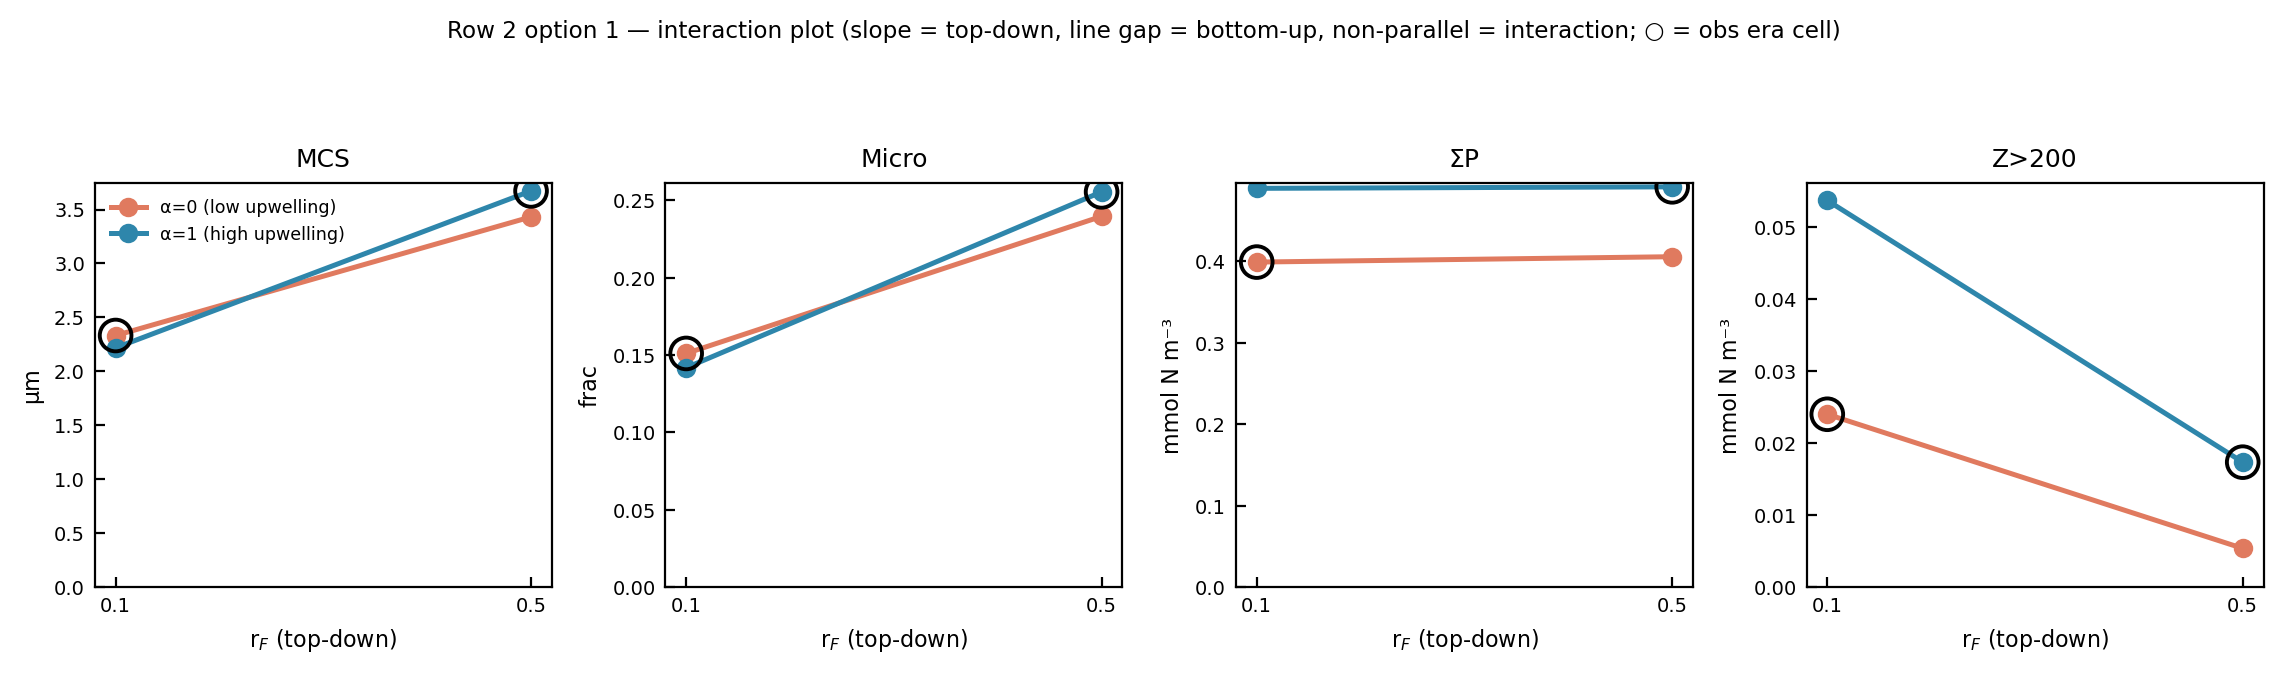

In [29]:
# ---- Option 1: interaction plot (absolute axis — clear scale, all 4 corners) ----
fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.4))
for ax, (label, tk, unit) in zip(axes, METRICS):
    c = corners[label]; RF = [0.1, 0.5]
    ax.plot(RF, [c['M00'], c['M01']], '-o', color=C_POST, lw=1.8, ms=6, label='α=0 (low upwelling)')
    ax.plot(RF, [c['M10'], c['M11']], '-o', color=C_PRE,  lw=1.8, ms=6, label='α=1 (high upwelling)')
    ax.scatter([0.1],[c['M00']], s=130, facecolor='none', edgecolor='k', lw=1.4, zorder=5)  # obs post
    ax.scatter([0.5],[c['M11']], s=130, facecolor='none', edgecolor='k', lw=1.4, zorder=5)  # obs pre+rec
    ax.set_xticks(RF); ax.set_xlabel('r$_F$ (top-down)', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(label, fontsize=9); ax.set_ylim(bottom=0); ax.tick_params(direction='in', labelsize=7)
axes[0].legend(fontsize=6.3, frameon=False)
fig.suptitle('Row 2 option 1 — interaction plot (slope = top-down, line gap = bottom-up, non-parallel = interaction; ○ = obs era cell)', fontsize=8.3)
fig.tight_layout(rect=(0,0,1,0.92)); plt.show()

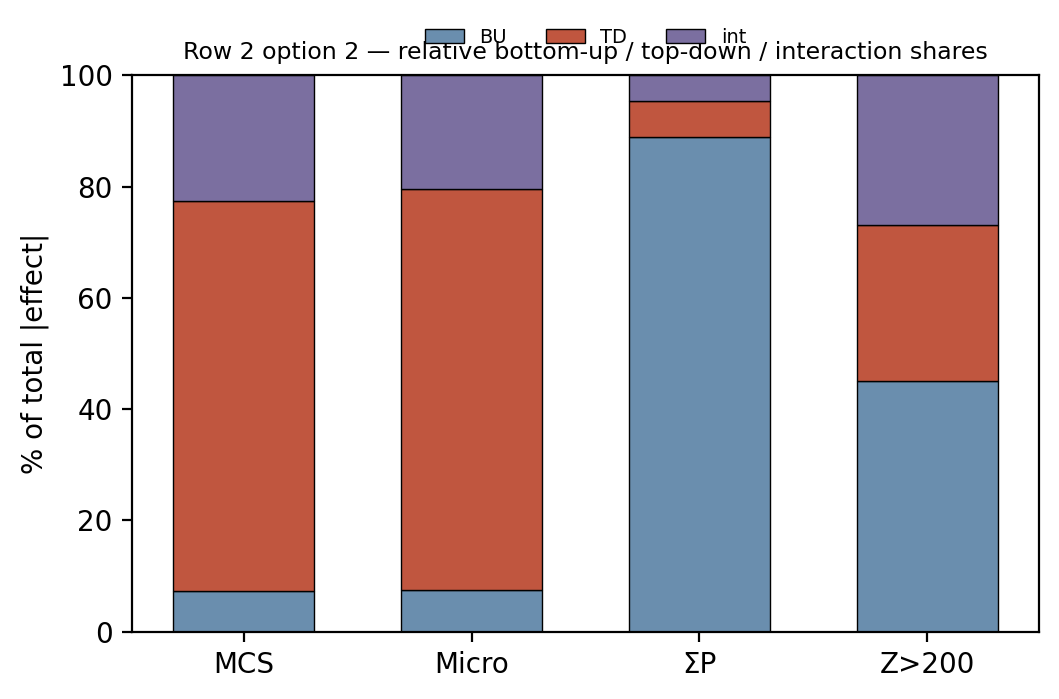

In [30]:
# ---- Option 2: relative shares (100%-normalised |BU|/|TD|/|int|; cross-metric, no units) ----
x = np.arange(4); fig, ax = plt.subplots(figsize=(5.4, 3.6)); bot = np.zeros(4)
for k in ['BU','TD','int']:
    sh = []
    for lab in labels:
        c = corners[lab]; BU = c['M10']-c['M00']; TD = c['M01']-c['M00']; IT = c['M11']-c['M10']-c['M01']+c['M00']
        t = abs(BU)+abs(TD)+abs(IT); sh.append(100*{'BU':abs(BU),'TD':abs(TD),'int':abs(IT)}[k]/t)
    ax.bar(x, sh, 0.62, bottom=bot, color=COL[k], edgecolor='k', lw=0.5, label=k); bot += np.array(sh)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('% of total |effect|'); ax.set_ylim(0, 100)
ax.legend(fontsize=7, frameon=False, ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.02))
ax.set_title('Row 2 option 2 — relative bottom-up / top-down / interaction shares', fontsize=8.5)
fig.tight_layout(); plt.show()

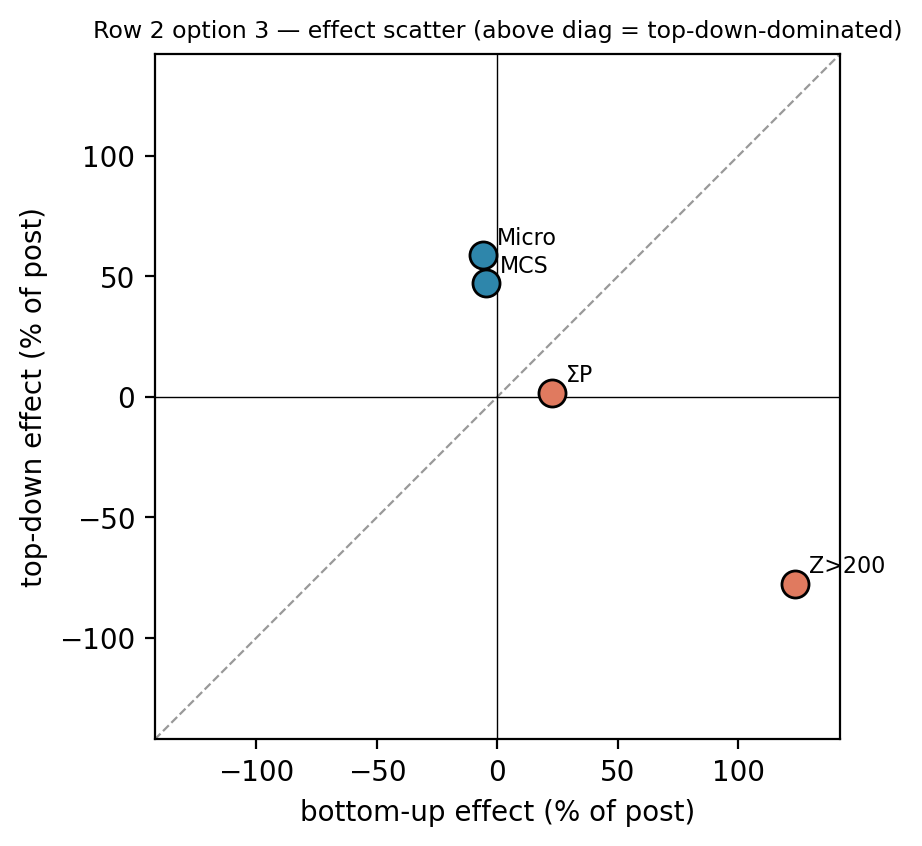

In [31]:
# ---- Option 3: bottom-up vs top-down effect scatter (one point per metric) ----
fig, ax = plt.subplots(figsize=(4.6, 4.6)); pts = {}
for lab in labels:
    c = corners[lab]; M00 = c['M00']
    BU = 100*(c['M10']-M00)/M00; TD = 100*(c['M01']-M00)/M00; pts[lab] = (BU, TD)
    ax.scatter(BU, TD, s=95, color=(C_PRE if abs(TD) > abs(BU) else C_POST), edgecolor='k', zorder=3)
    ax.annotate(lab, (BU, TD), xytext=(5, 4), textcoords='offset points', fontsize=8)
lim = 1.15*max(max(abs(v) for v in p) for p in pts.values())
ax.plot([-lim, lim], [-lim, lim], '--', color='0.6', lw=0.8)  # equal-impact diagonal
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('bottom-up effect (% of post)'); ax.set_ylabel('top-down effect (% of post)')
ax.set_title('Row 2 option 3 — effect scatter (above diag = top-down-dominated)', fontsize=8.5)
ax.set_aspect('equal'); fig.tight_layout(); plt.show()

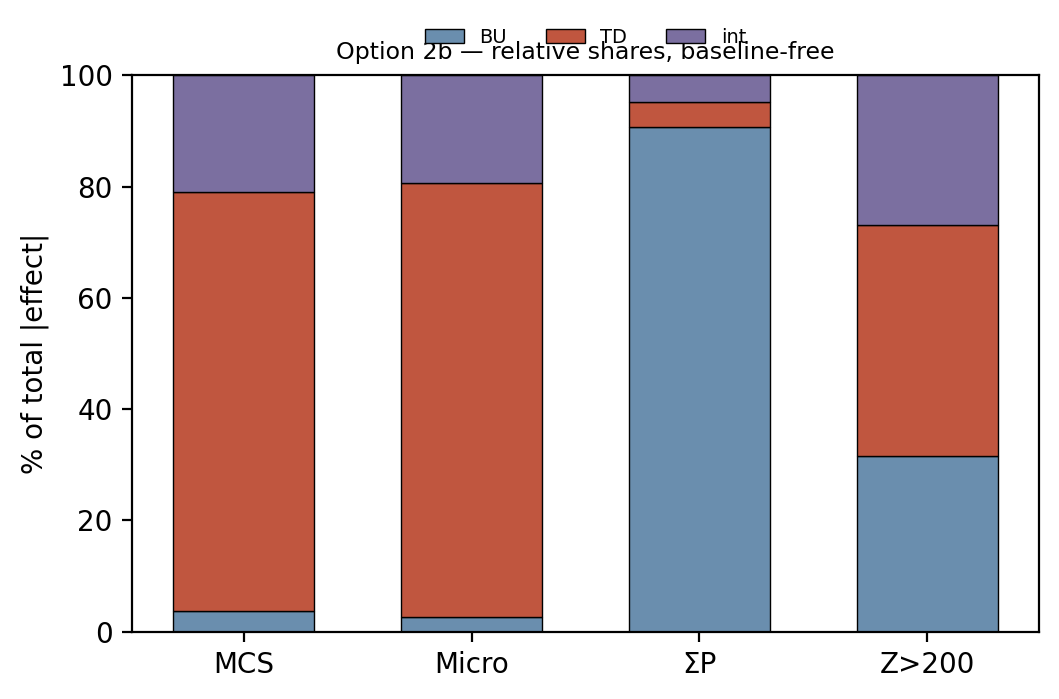

In [32]:
# ---- Option 2b: relative shares, BASELINE-FREE (averaged main effects) ----
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
def eff_avg(c):
    return ((c['M10']-c['M00']+c['M11']-c['M01'])/2,        # bottom-up (avg)
            (c['M01']-c['M00']+c['M11']-c['M10'])/2,        # top-down (avg)
            c['M11']-c['M10']-c['M01']+c['M00'])            # interaction
x = np.arange(4); fig, ax = plt.subplots(figsize=(5.4, 3.6)); bot = np.zeros(4)
for ki, k in enumerate(['BU','TD','int']):
    sh = []
    for lab in labels:
        e = eff_avg(corners[lab]); t = sum(abs(v) for v in e); sh.append(100*abs(e[ki])/t)
    ax.bar(x, sh, 0.62, bottom=bot, color=COL[k], edgecolor='k', lw=0.5, label=k); bot += np.array(sh)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('% of total |effect|'); ax.set_ylim(0, 100)
ax.legend(fontsize=7, frameon=False, ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.02))
ax.set_title('Option 2b — relative shares, baseline-free', fontsize=8.5)
fig.tight_layout(); plt.show()

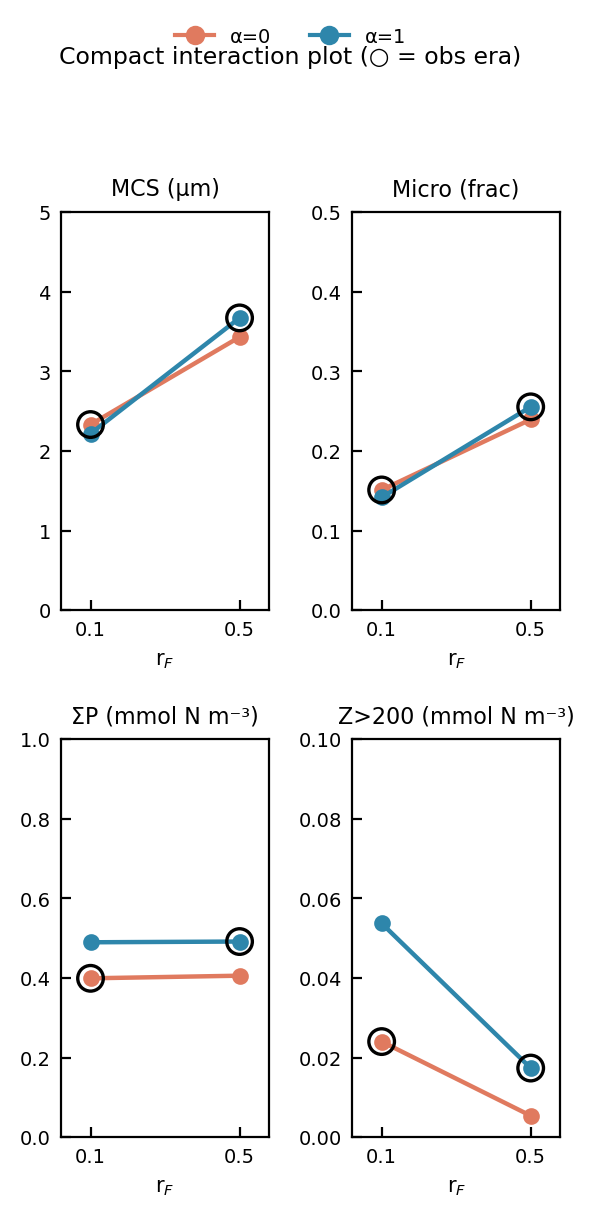

In [40]:
# ---- Compact interaction plot (2x2 instead of 1x4) ----
fig, axes = plt.subplots(2, 2, figsize=(3, 6))
for ax, (label, tk, unit) in zip(axes.ravel(), METRICS):
    c = corners[label]; RF = [0.1, 0.5]
    ax.plot(RF, [c['M00'], c['M01']], '-o', color=C_POST, lw=1.6, ms=5)
    ax.plot(RF, [c['M10'], c['M11']], '-o', color=C_PRE,  lw=1.6, ms=5)
    ax.scatter([0.1],[c['M00']], s=85, facecolor='none', edgecolor='k', lw=1.2, zorder=5)
    ax.scatter([0.5],[c['M11']], s=85, facecolor='none', edgecolor='k', lw=1.2, zorder=5)
    ax.set_xticks(RF); ax.set_xlim(0.02, 0.58); ax.set_ylim(bottom=0)
    ax.set_title(f'{label} ({unit})', fontsize=8); ax.set_xlabel('r$_F$', fontsize=7.5)
    ax.tick_params(direction='in', labelsize=7)

axes[0,0].set_ylim(0,5)

axes[0,1].set_ylim(0,0.5)

axes[1,0].set_ylim(0,1)

axes[1,1].set_ylim(0,0.1)

fig.legend(handles=[plt.Line2D([],[],marker='o',color=C_POST,label='α=0'),
                    plt.Line2D([],[],marker='o',color=C_PRE,label='α=1')],
           loc='upper center', ncol=2, fontsize=7, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Compact interaction plot (○ = obs era)', fontsize=8.5, y=0.99)
fig.tight_layout(rect=(0,0,1,0.95)); plt.show()

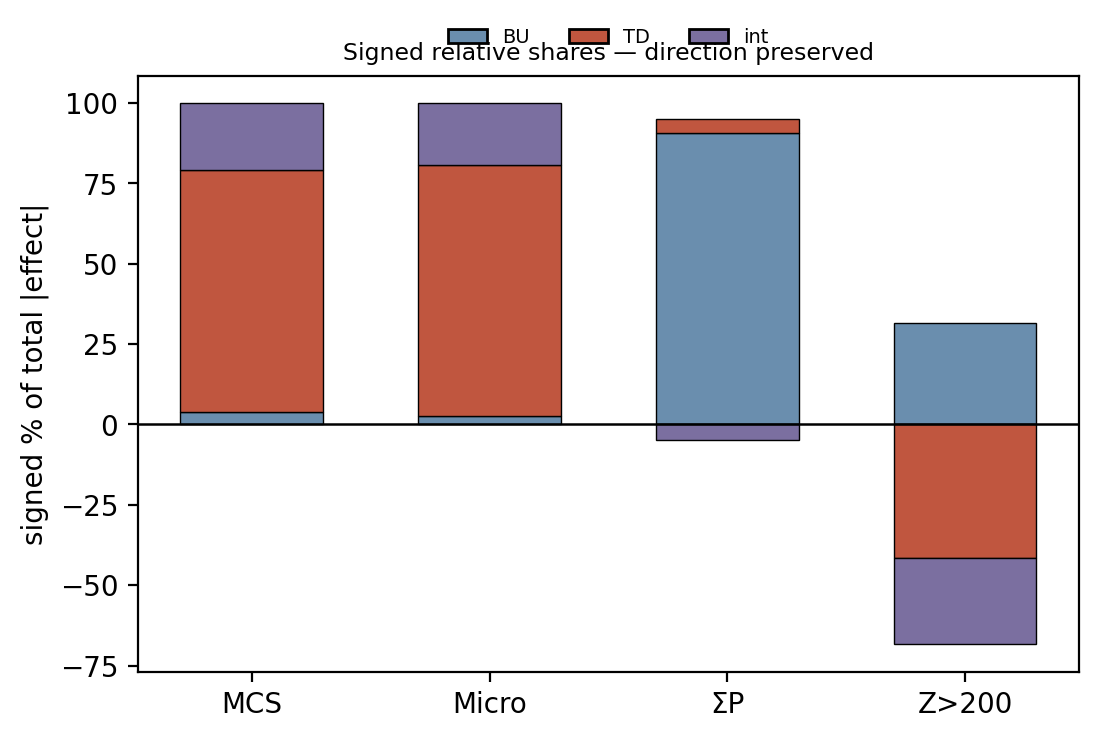

In [34]:
# ---- New option: SIGNED relative shares (up = raises metric, down = lowers) — keeps direction ----
x = np.arange(4); fig, ax = plt.subplots(figsize=(5.6, 3.8))
for xi, lab in enumerate(labels):
    e = dict(zip(['BU','TD','int'], eff_avg(corners[lab]))); t = sum(abs(v) for v in e.values())
    pos = neg = 0.0
    for k in ['BU','TD','int']:
        v = 100*e[k]/t
        ax.bar(xi, v, 0.6, bottom=(pos if v >= 0 else neg), color=COL[k], edgecolor='k', lw=0.5)
        if v >= 0: pos += v
        else: neg += v
ax.axhline(0, color='k', lw=0.9); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('signed % of total |effect|')
ax.legend(handles=[Patch(fc=COL[k],ec='k',label=k) for k in ['BU','TD','int']],
          fontsize=7, frameon=False, ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.02))
ax.set_title('Signed relative shares — direction preserved', fontsize=8.5)
fig.tight_layout(); plt.show()

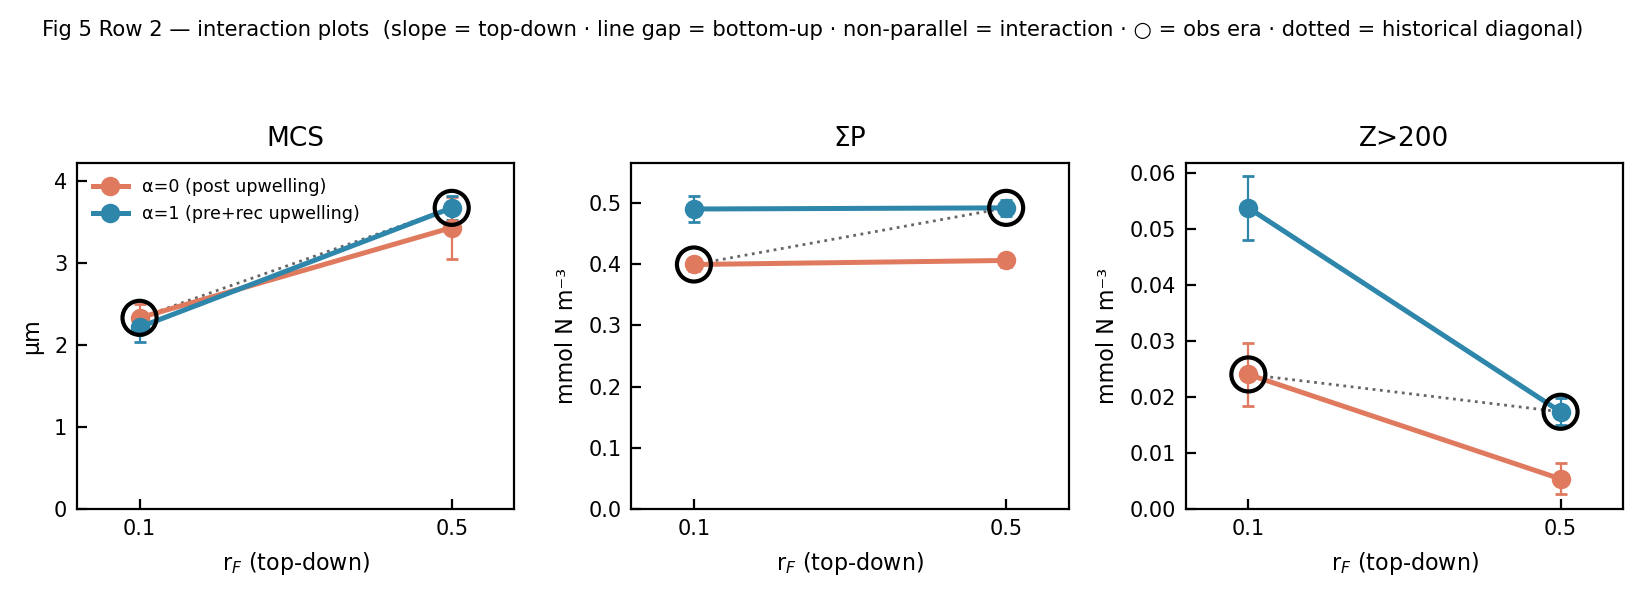

In [41]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
ds = xr.open_dataset('results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc')
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
PANELS = [('MCS','traj_mcs','µm'), ('ΣP','traj_sumP','mmol N m⁻³'), ('Z>200','traj_Z200','mmol N m⁻³')]
A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5; W = 1
SHOW_SD, SHOW_DIAG = True, True
C_POST, C_PRE = '#E07A5F', '#2E86AB'
av, rv = ds[A_NAME].values, ds[R_NAME].values
def corner(tk, a, rf):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    b = ds[tk].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)}).median(D_NAME).values
    return float(np.mean(b)), float(np.std(b))

fig, axes = plt.subplots(1, 3, figsize=(8.4, 3.0))
for ax, (label, tk, unit) in zip(axes, PANELS):
    (M00,e00),(M10,e10),(M01,e01),(M11,e11) = corner(tk,A0,RL), corner(tk,A1,RL), corner(tk,A0,RH), corner(tk,A1,RH)
    RF = [0.1, 0.5]
    ax.plot(RF, [M00,M01], '-o', color=C_POST, lw=1.8, ms=6, zorder=3, label='α=0 (post upwelling)')
    ax.plot(RF, [M10,M11], '-o', color=C_PRE,  lw=1.8, ms=6, zorder=3, label='α=1 (pre+rec upwelling)')
    if SHOW_SD:
        ax.errorbar(RF, [M00,M01], yerr=[e00,e01], fmt='none', ecolor=C_POST, elinewidth=0.8, capsize=2, zorder=2)
        ax.errorbar(RF, [M10,M11], yerr=[e10,e11], fmt='none', ecolor=C_PRE,  elinewidth=0.8, capsize=2, zorder=2)
    ax.scatter([0.1],[M00], s=150, facecolor='none', edgecolor='k', lw=1.5, zorder=5)   # obs post
    ax.scatter([0.5],[M11], s=150, facecolor='none', edgecolor='k', lw=1.5, zorder=5)   # obs pre+rec
    if SHOW_DIAG:
        ax.plot([0.1,0.5], [M00,M11], ls=':', color='0.4', lw=1.0, zorder=1)            # historical diagonal
    ax.set_xticks(RF); ax.set_xlim(0.02, 0.58); ax.set_ylim(0, 1.15*max(M00,M10,M01,M11))
    ax.set_xlabel('r$_F$ (top-down)', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(label, fontsize=9.5); ax.tick_params(direction='in', labelsize=7.5)
axes[0].legend(fontsize=6.3, frameon=False, loc='upper left')
fig.suptitle('Fig 5 Row 2 — interaction plots  (slope = top-down · line gap = bottom-up · non-parallel = interaction · ○ = obs era · dotted = historical diagonal)', fontsize=7.6)
fig.tight_layout(rect=(0,0,1,0.94)); plt.show()

/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_4467/1280853857.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0,0,1,0.95)); plt.show()


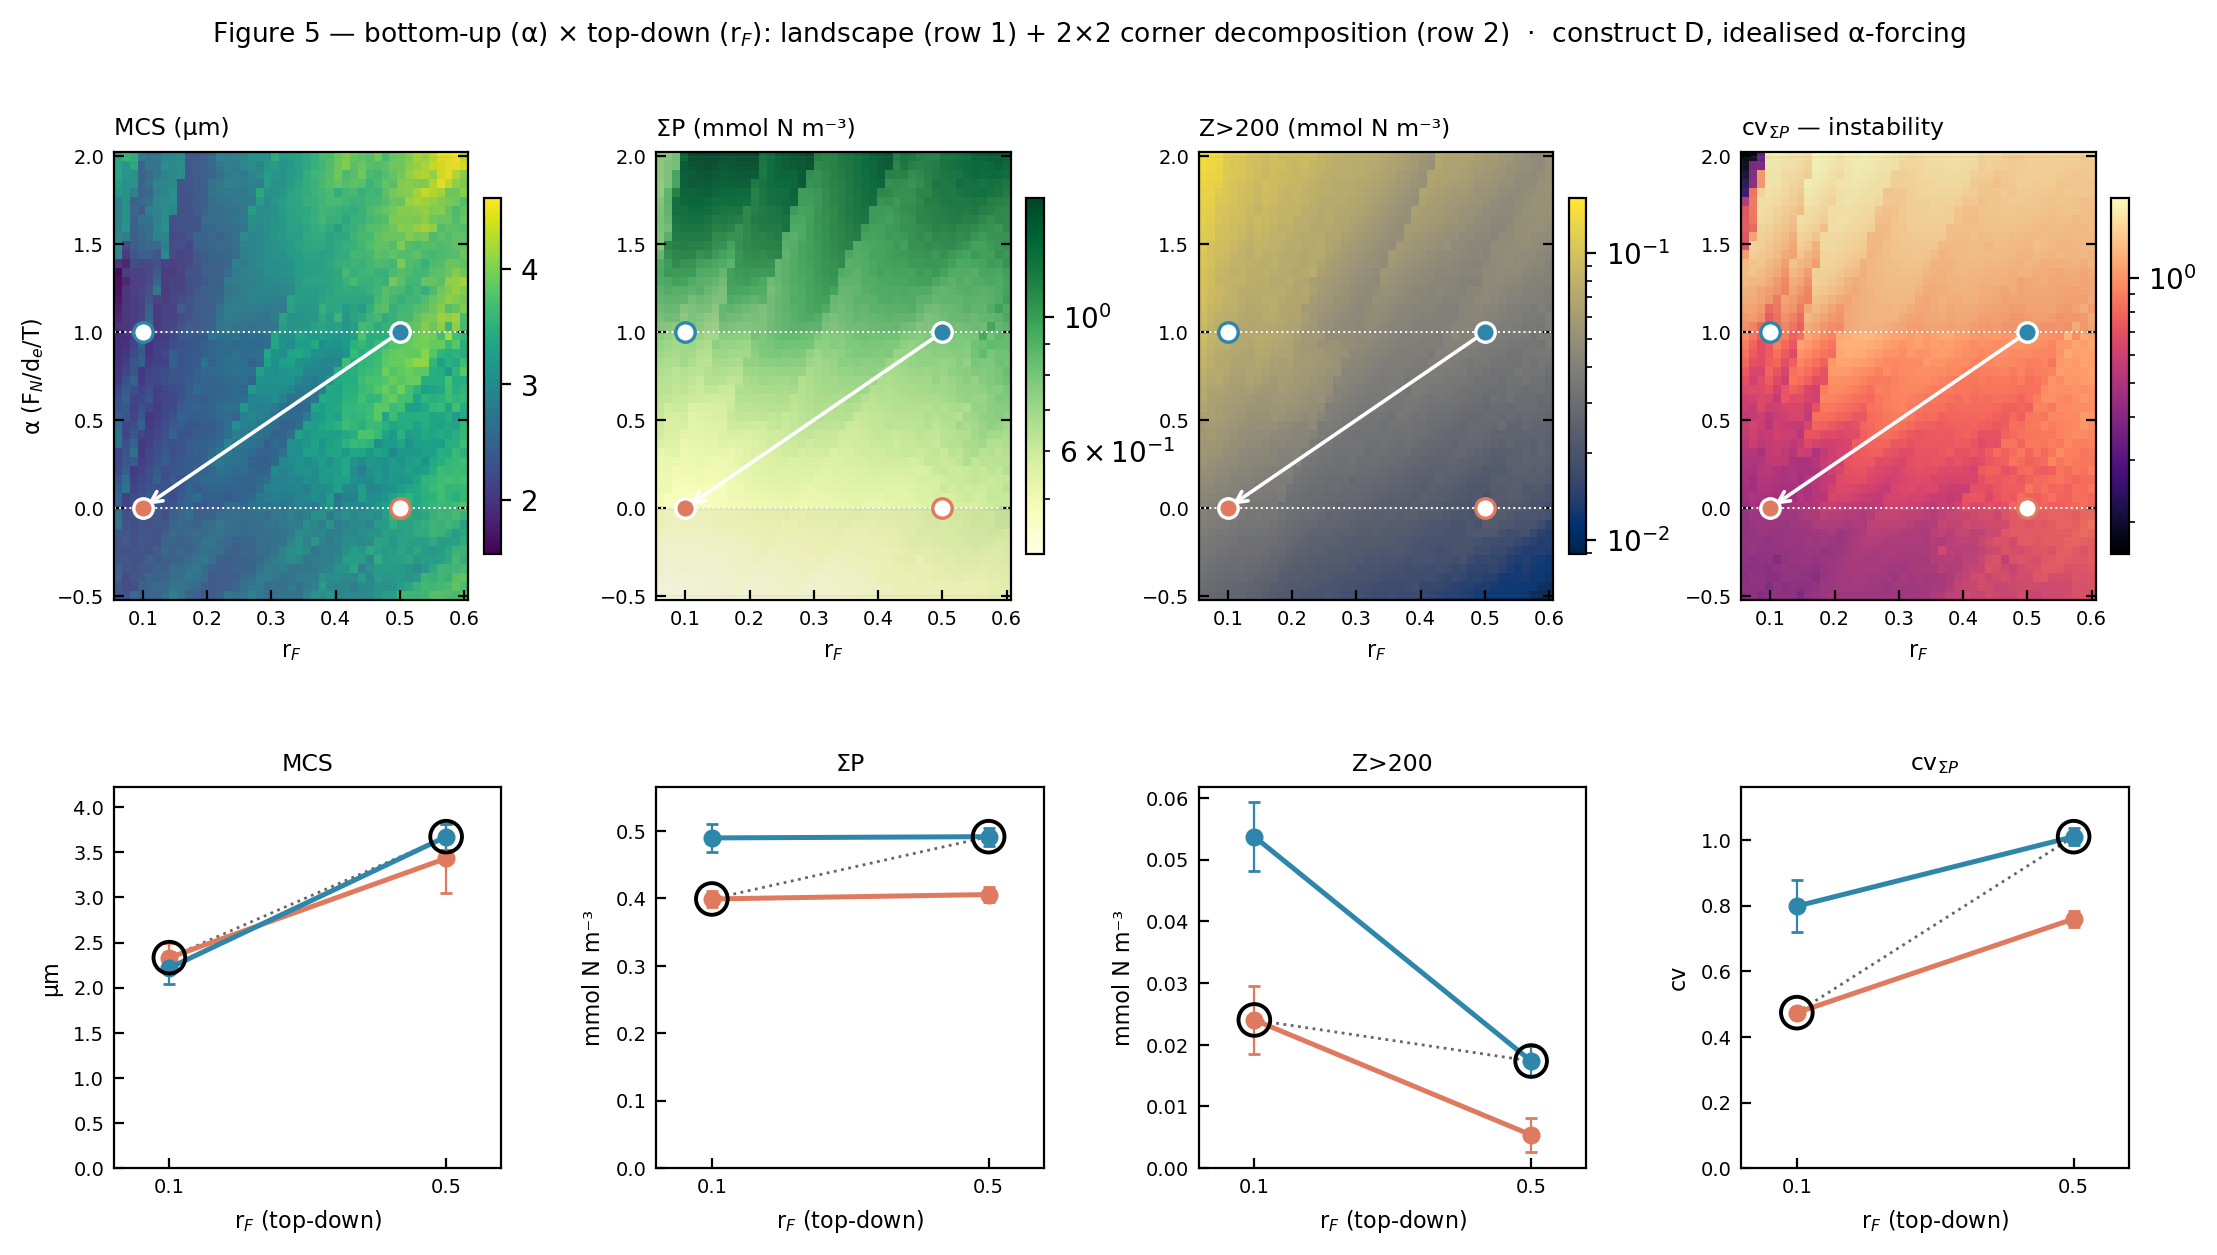

In [47]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm

ds = xr.open_dataset('results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc')
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
RF_MIN = 0.05; A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.5; W = 1
C_POST, C_PRE = '#E07A5F', '#2E86AB'
dsf = ds.sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = dsf[A_NAME].values, dsf[R_NAME].values
av, rv = ds[A_NAME].values, ds[R_NAME].values
def surf(k): return dsf[k].transpose(A_NAME, R_NAME).values
def corner(key, a, rf, mode):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[key].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)})
    vals = (blk.median(D_NAME) if mode == 'traj' else blk).values
    return float(np.mean(vals)), float(np.std(vals))

#HEAT = [('mcs_med','MCS (µm)','viridis',False), ('sumP','ΣP (mmol N m⁻³)','YlGn',False),
#        ('Z200','Z>200 (mmol N m⁻³)','cividis',False), ('cv_sumP','cv$_{ΣP}$ — instability','magma',True)]

HEAT = [('mcs_med','MCS (µm)','viridis',False), ('sumP','ΣP (mmol N m⁻³)','YlGn',True),
        ('Z200','Z>200 (mmol N m⁻³)','cividis',True), ('cv_sumP','cv$_{ΣP}$ — instability','magma',True)]
PANELS = [('MCS','traj_mcs','µm','traj'), ('ΣP','traj_sumP','mmol N m⁻³','traj'),
          ('Z>200','traj_Z200','mmol N m⁻³','traj'), ('cv$_{ΣP}$','cv_sumP','cv','scalar')]
OPS = [(1.0,0.5,C_PRE,True), (0.0,0.1,C_POST,True), (1.0,0.1,C_PRE,False), (0.0,0.5,C_POST,False)]
def heat_overlay(ax):
    ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10); ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0,1): ax.axhline(y, color='white', lw=0.7, ls=':')
    ax.annotate('', xy=(0.1,0.0), xytext=(0.5,1.0), arrowprops=dict(arrowstyle='->', lw=1.3, color='white'), zorder=6)
    for a, rf, col, filled in OPS:
        ax.plot(rf, a, 'o', ms=7, color=col, mfc=(col if filled else 'white'), mec=('white' if filled else col), mew=1.2, zorder=7)

fig = plt.figure(figsize=(13, 6.6))
gs = GridSpec(2, 4, figure=fig, height_ratios=[1.0, 0.85], hspace=0.45, wspace=0.40)
for ci, (key, label, cmap, logf) in enumerate(HEAT):
    ax = fig.add_subplot(gs[0, ci]); s = surf(key)
    norm = LogNorm(vmin=max(np.nanmin(s),1e-3), vmax=np.nanmax(s)) if logf else None
    pc = ax.pcolormesh(R_F, alpha, s, shading='nearest', cmap=cmap, norm=norm)
    heat_overlay(ax); ax.set_title(label, fontsize=8.5, loc='left'); ax.set_xlabel('r$_F$', fontsize=8)
    if ci == 0: ax.set_ylabel(r'α (F$_N$/d$_e$/T)', fontsize=8)
    ax.tick_params(direction='in', labelsize=7, right=True, top=False)
    fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
    
for ci, (label, key, unit, mode) in enumerate(PANELS):
    ax = fig.add_subplot(gs[1, ci])
    (M00,e00),(M10,e10),(M01,e01),(M11,e11) = (corner(key,A0,RL,mode), corner(key,A1,RL,mode),
                                               corner(key,A0,RH,mode), corner(key,A1,RH,mode))
    RF = [0.1, 0.5]
    ax.plot(RF, [M00,M01], '-o', color=C_POST, lw=1.8, ms=5.5, zorder=3)
    ax.plot(RF, [M10,M11], '-o', color=C_PRE,  lw=1.8, ms=5.5, zorder=3)
    ax.errorbar(RF, [M00,M01], yerr=[e00,e01], fmt='none', ecolor=C_POST, elinewidth=0.8, capsize=2, zorder=2)
    ax.errorbar(RF, [M10,M11], yerr=[e10,e11], fmt='none', ecolor=C_PRE,  elinewidth=0.8, capsize=2, zorder=2)
    ax.scatter([0.1],[M00], s=130, facecolor='none', edgecolor='k', lw=1.4, zorder=5)
    ax.scatter([0.5],[M11], s=130, facecolor='none', edgecolor='k', lw=1.4, zorder=5)
    ax.plot([0.1,0.5], [M00,M11], ls=':', color='0.4', lw=1.0, zorder=1)
    ax.set_xticks(RF); ax.set_xlim(0.02,0.58); ax.set_ylim(0, 1.15*max(M00,M10,M01,M11))
    ax.set_xlabel('r$_F$ (top-down)', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(label, fontsize=8.5); ax.tick_params(direction='in', labelsize=7)
    
fig.suptitle('Figure 5 — bottom-up (α) × top-down (r$_F$): landscape (row 1) + 2×2 corner decomposition (row 2)  ·  construct D, idealised α-forcing', fontsize=9.5)
fig.tight_layout(rect=(0,0,1,0.95)); plt.show()

In [13]:
# ---- shared setup for the Row 2 catalogue ----
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle
import xarray as xr

NC = 'results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc'
A_NAME, R_NAME = 'alpha', 'rF'
ds = xr.open_dataset(NC)

# four corners of the 2x2 (col=era-colour encodes α; rF sets fish level)
CORNERS = {'post':    dict(a=0.0, rF=0.1, kind='era', col='#E07A5F'),   # M00 low-up / low-fish
           'cf-A':    dict(a=1.0, rF=0.1, kind='cf',  col='#2E86AB'),   # M10 high-up / low-fish
           'cf-B':    dict(a=0.0, rF=0.5, kind='cf',  col='#E07A5F'),   # M01 low-up / high-fish
           'pre+rec': dict(a=1.0, rF=0.5, kind='era', col='#2E86AB')}   # M11 high-up / high-fish
METRICS = [('MCS', 'traj_mcs', 'µm'), ('Micro', 'traj_micro', 'frac'),
           ('ΣP', 'traj_sumP', 'mmol N m⁻³'), ('Z>200', 'traj_Z200', 'mmol N m⁻³')]

def samples(key, a, rF):
    v = ds[key].sel({A_NAME: a, R_NAME: rF}, method='nearest').values
    return v[np.isfinite(v)]
STAT = {}
for cl, c in CORNERS.items():
    for label, key, _ in METRICS:
        v = samples(key, c['a'], c['rF'])
        STAT[(cl, label)] = dict(med=np.median(v), lo=np.percentile(v, 10), hi=np.percentile(v, 90))
def M(label):                                   # the four 2x2 medians
    return (STAT[('post',label)]['med'], STAT[('cf-A',label)]['med'],
            STAT[('cf-B',label)]['med'], STAT[('pre+rec',label)]['med'])   # M00, M10, M01, M11
print("corner medians (snapped):")
for cl, c in CORNERS.items():
    snap = ds['mcs_med'].sel({A_NAME: c['a'], R_NAME: c['rF']}, method='nearest')
    print(f"  {cl:8s} α={float(snap[A_NAME]):+.2f} rF={float(snap[R_NAME]):.2f}  " +
          "  ".join(f"{lab} {STAT[(cl,lab)]['med']:.3f}" for lab,_,_ in METRICS))

corner medians (snapped):
  post     α=+0.01 rF=0.10  MCS 2.221  Micro 0.143  ΣP 0.402  Z>200 0.026
  cf-A     α=+0.98 rF=0.10  MCS 2.469  Micro 0.167  ΣP 0.499  Z>200 0.053
  cf-B     α=+0.01 rF=0.50  MCS 3.001  Micro 0.194  ΣP 0.396  Z>200 0.010
  pre+rec  α=+0.98 rF=0.50  MCS 3.596  Micro 0.243  ΣP 0.486  Z>200 0.016


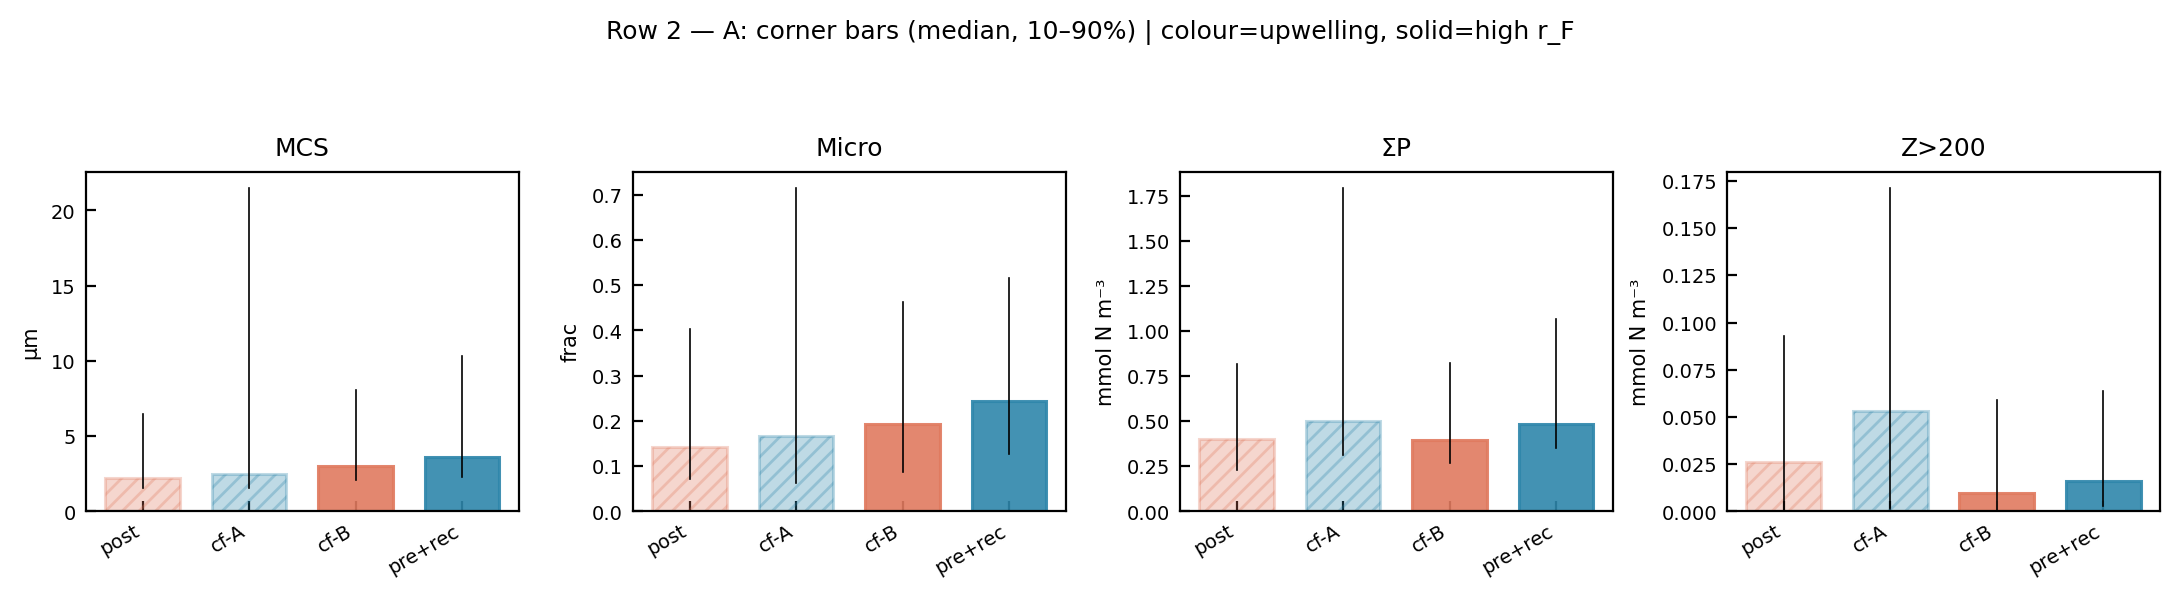

In [14]:
# ---- Option A: grouped corner bars (colour = upwelling α; solid = high r_F, hatched = low r_F) ----
fig, axes = plt.subplots(1, len(METRICS), figsize=(11, 3.0))
order = ['post', 'cf-A', 'cf-B', 'pre+rec']
for ax, (label, key, unit) in zip(axes, METRICS):
    for x, cl in enumerate(order):
        c = CORNERS[cl]; s = STAT[(cl, label)]; high = c['rF'] > 0.3
        ax.bar(x, s['med'], 0.7, color=c['col'], alpha=0.9 if high else 0.30,
               edgecolor=c['col'], linewidth=1.1, hatch=None if high else '////', zorder=2)
        ax.plot([x, x], [s['lo'], s['hi']], color='k', lw=0.6, zorder=4)
    ax.set_xticks(range(4)); ax.set_xticklabels(order, fontsize=7, rotation=30, ha='right')
    ax.set_title(label, fontsize=9); ax.set_ylabel(unit, fontsize=7.5)
    ax.set_ylim(bottom=0); ax.tick_params(direction='in', labelsize=7)
fig.suptitle('Row 2 — A: corner bars (median, 10–90%) | colour=upwelling, solid=high r_F', fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

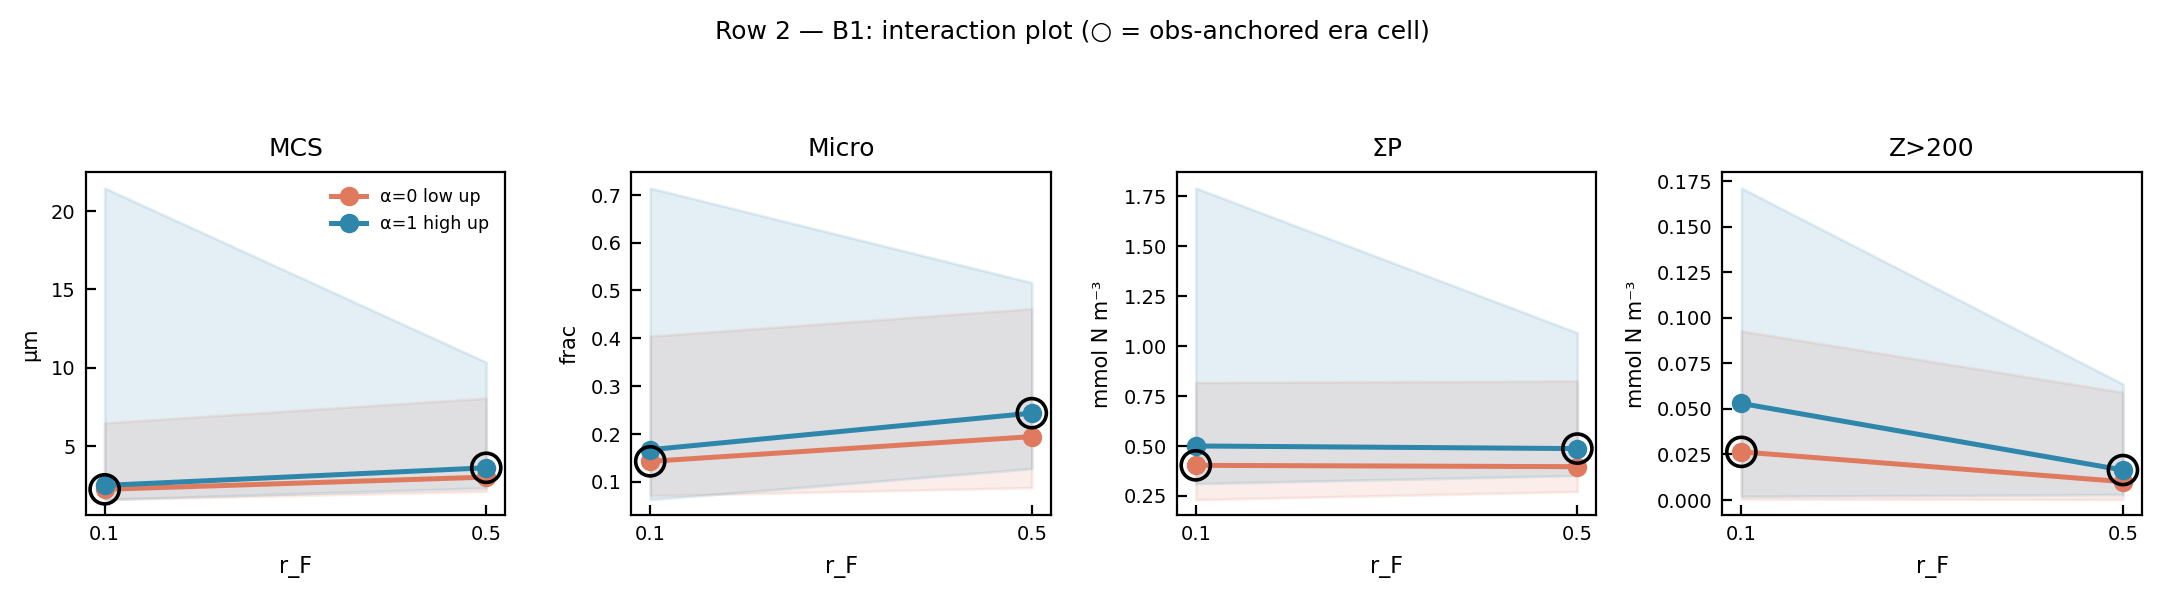

In [15]:
# ---- Option B1: interaction plot (parallel ⇒ additive; diverging ⇒ synergy) ----
fig, axes = plt.subplots(1, len(METRICS), figsize=(11, 3.0)); RF = [0.1, 0.5]
for ax, (label, key, unit) in zip(axes, METRICS):
    for a_lv, col, nm in [(0.0, '#E07A5F', 'α=0 low up'), (1.0, '#2E86AB', 'α=1 high up')]:
        md = [np.median(samples(key, a_lv, rf)) for rf in RF]
        lo = [np.percentile(samples(key, a_lv, rf), 10) for rf in RF]
        hi = [np.percentile(samples(key, a_lv, rf), 90) for rf in RF]
        ax.plot(RF, md, '-o', color=col, lw=1.8, ms=6, zorder=4, label=nm)
        ax.fill_between(RF, lo, hi, color=col, alpha=0.13, zorder=2)
    ax.scatter([0.1], [np.median(samples(key, 0.0, 0.1))], s=110, facecolor='none', edgecolor='k', lw=1.3, zorder=6)
    ax.scatter([0.5], [np.median(samples(key, 1.0, 0.5))], s=110, facecolor='none', edgecolor='k', lw=1.3, zorder=6)
    ax.set_xticks(RF); ax.set_xlabel('r_F', fontsize=8); ax.set_title(label, fontsize=9)
    ax.set_ylabel(unit, fontsize=7.5); ax.tick_params(direction='in', labelsize=7)
axes[0].legend(fontsize=6.3, frameon=False)
fig.suptitle('Row 2 — B1: interaction plot (○ = obs-anchored era cell)', fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

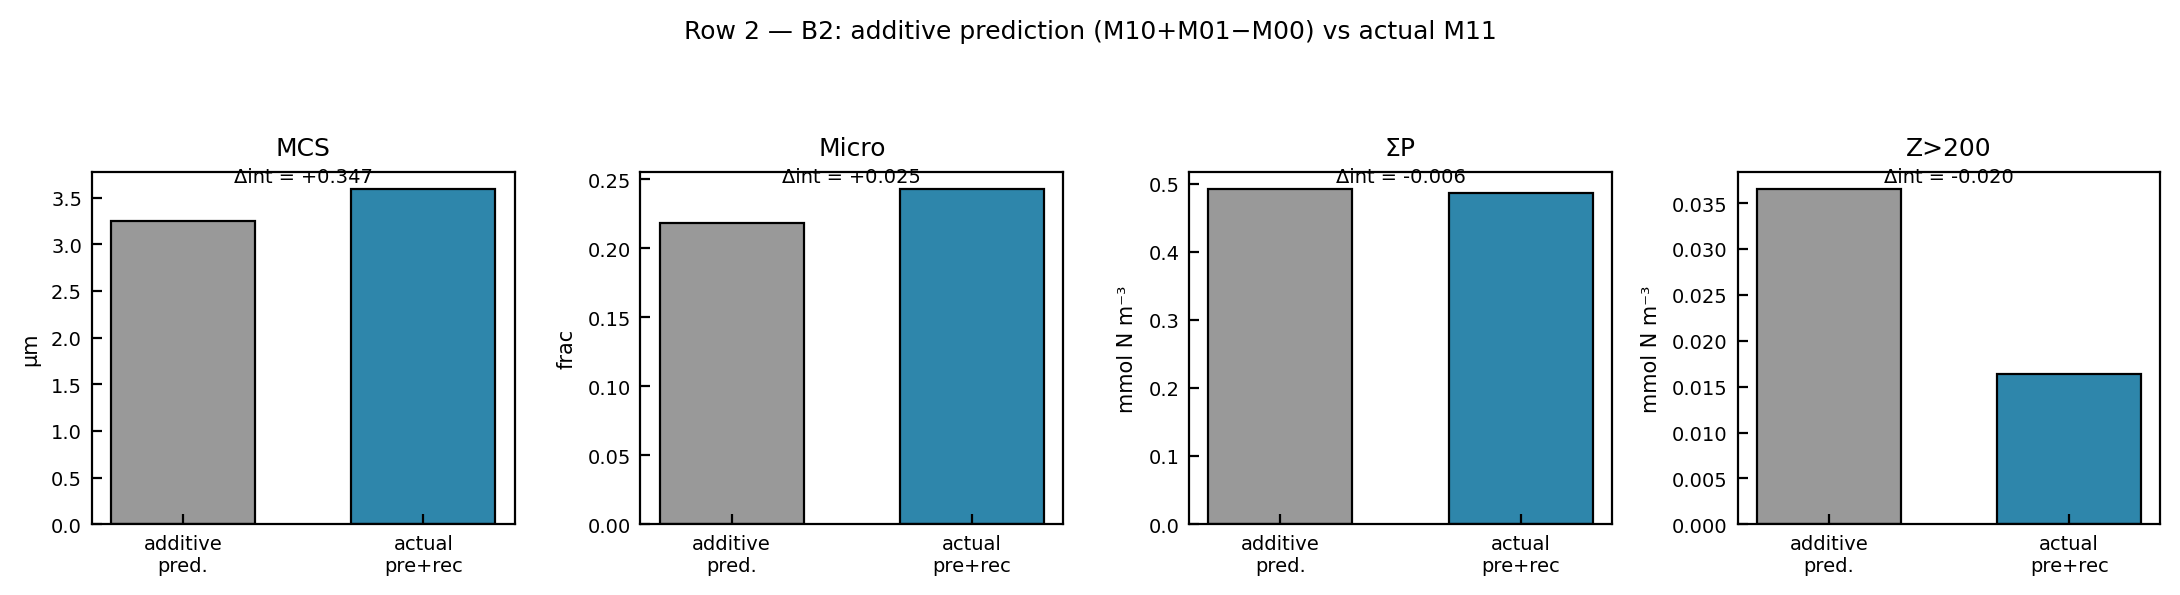

In [16]:
# ---- Option B2: additive prediction vs actual (gap = interaction) ----
fig, axes = plt.subplots(1, len(METRICS), figsize=(11, 3.0))
for ax, (label, key, unit) in zip(axes, METRICS):
    M00, M10, M01, M11 = M(label); add = M10 + M01 - M00
    ax.bar([0, 1], [add, M11], 0.6, color=['0.6', '#2E86AB'], edgecolor='k', lw=0.8)
    ax.annotate(f"Δint = {M11-add:+.3f}", xy=(1, M11), xytext=(0.5, max(add, M11)*1.02),
                ha='center', fontsize=7, color='k')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['additive\npred.', 'actual\npre+rec'], fontsize=6.5)
    ax.set_title(label, fontsize=9); ax.set_ylabel(unit, fontsize=7.5)
    ax.set_ylim(bottom=0); ax.tick_params(direction='in', labelsize=7)
fig.suptitle('Row 2 — B2: additive prediction (M10+M01−M00) vs actual M11', fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

=== C: decomposition of post→pre+rec shift ===
  MCS   : bottom-up +0.249  top-down +0.780  interaction +0.347  total +1.375
  Micro : bottom-up +0.024  top-down +0.052  interaction +0.025  total +0.101
  ΣP    : bottom-up +0.097  top-down -0.007  interaction -0.006  total +0.084
  Z>200 : bottom-up +0.027  top-down -0.016  interaction -0.020  total -0.010


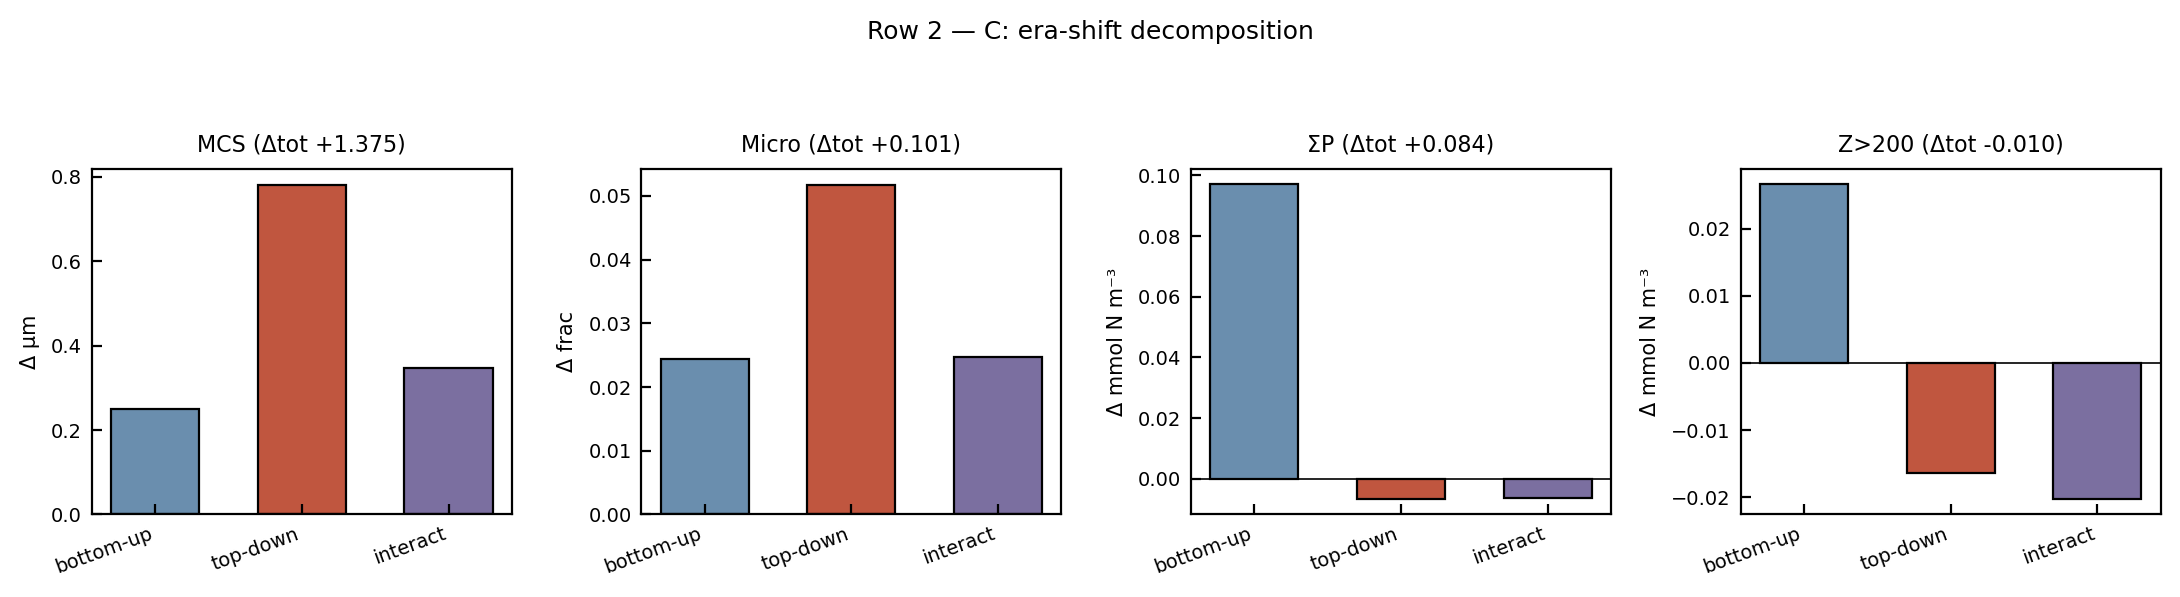

In [17]:
# ---- Option C: era-shift decomposition (bottom-up + top-down + interaction = total) ----
fig, axes = plt.subplots(1, len(METRICS), figsize=(11, 3.0))
print("=== C: decomposition of post→pre+rec shift ===")
for ax, (label, key, unit) in zip(axes, METRICS):
    M00, M10, M01, M11 = M(label)
    dBU, dTD, dINT = M10 - M00, M01 - M00, M11 - M10 - M01 + M00
    ax.bar(range(3), [dBU, dTD, dINT], 0.6, color=['#6A8EAE', '#C0563F', '#7B6FA0'], edgecolor='k', lw=0.8)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_xticks(range(3)); ax.set_xticklabels(['bottom-up', 'top-down', 'interact'], fontsize=6.5, rotation=20, ha='right')
    ax.set_title(f"{label} (Δtot {M11-M00:+.3f})", fontsize=8); ax.set_ylabel(f'Δ {unit}', fontsize=7.5)
    ax.tick_params(direction='in', labelsize=7)
    print(f"  {label:6s}: bottom-up {dBU:+.3f}  top-down {dTD:+.3f}  interaction {dINT:+.3f}  total {M11-M00:+.3f}")
fig.suptitle('Row 2 — C: era-shift decomposition', fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

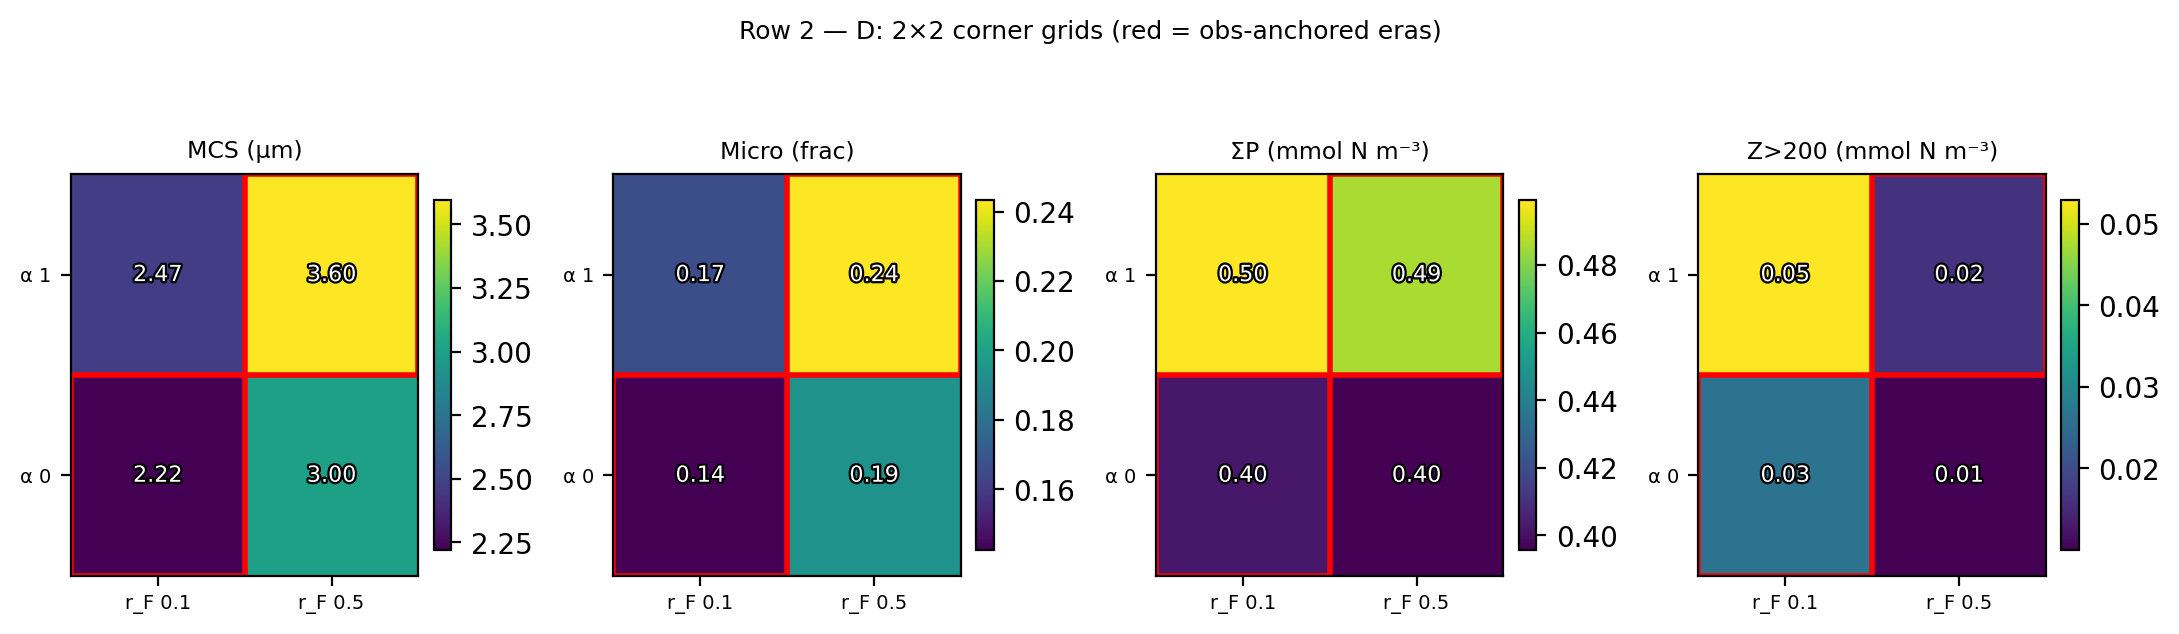

In [18]:
# ---- Option D: literal 2×2 corner grids (red box = obs-anchored diagonal) ----
fig, axes = plt.subplots(1, len(METRICS), figsize=(11, 3.2))
for ax, (label, key, unit) in zip(axes, METRICS):
    M00, M10, M01, M11 = M(label)
    grid = np.array([[M00, M01], [M10, M11]])           # rows: α0/α1 ; cols: rF0.1/rF0.5
    im = ax.imshow(grid, origin='lower', cmap='viridis', aspect='auto')
    for (i, j), val in np.ndenumerate(grid):
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white', fontsize=8,
                path_effects=[pe.withStroke(linewidth=1.6, foreground='k')])
    for (i, j) in [(0, 0), (1, 1)]:
        ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='red', lw=2))
    ax.set_xticks([0, 1]); ax.set_xticklabels(['r_F 0.1', 'r_F 0.5'], fontsize=7)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['α 0', 'α 1'], fontsize=7)
    ax.set_title(f"{label} ({unit})", fontsize=8.5)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Row 2 — D: 2×2 corner grids (red = obs-anchored eras)', fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

In [9]:
# ---- shared setup (run once) ----
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import xarray as xr

NC = 'results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc'
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
ds = xr.open_dataset(NC)

ERAS = {'post':    dict(alpha=0.0, rF=0.1, col='#E07A5F'),
        'pre+rec': dict(alpha=1.0, rF=0.5, col='#2E86AB')}
RF_LEVELS = {'post r_F=0.1': 0.1, 'pre+rec r_F=0.5': 0.5}

T_K = 20901 + np.arange(ds.sizes[D_NAME])             # absolute model time of each tail sample
def _interp(post, pre, a): return ds.attrs[post] + a*(ds.attrs[pre] - ds.attrs[post])
def forcing(name, a, t=T_K):                          # 'FN' peaks (+cos); 'T','de' anti-phase (-cos)
    m   = _interp(f'forcing_{name}_mean_post', f'forcing_{name}_mean_pre', a)
    amp = _interp(f'forcing_{name}_amp_post',  f'forcing_{name}_amp_pre',  a)
    sign = +1 if name == 'FN' else -1
    return m + sign*amp*np.cos(2*np.pi*(t - ds.attrs['forcing_phase_day'])/365.0)

UM_TICKS = [1, 2, 5, 10, 20]
def _style(ax): ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
def cell_traj(key, a, rf): return ds[key].sel({A_NAME: a, R_NAME: rf}, method='nearest')
print("loaded", NC, "| day[0,-1]=", int(ds[D_NAME].values[0]), int(ds[D_NAME].values[-1]),
      "| t_k[0,-1]=", int(T_K[0]), int(T_K[-1]))

loaded results/fig5_alpha_sinusoidal_50x50_2026-06-26.nc | day[0,-1]= 0 999 | t_k[0,-1]= 20901 21900


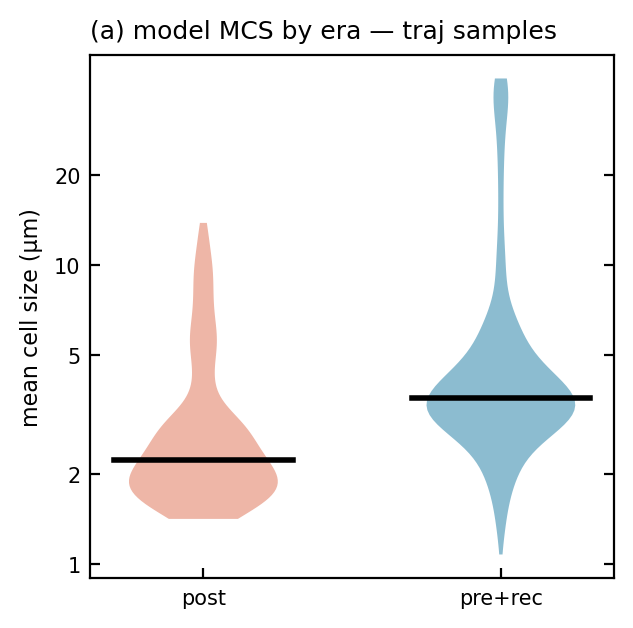

=== (a) MCS by era ===
  post     (α+0.01, rF0.10): median 2.22 µm  IQR [1.78, 3.06]  n=1000
  pre+rec  (α+0.98, rF0.50): median 3.60 µm  IQR [2.99, 4.71]  n=1000
  pre+rec / post median ratio: 1.62x


In [10]:
# ---- (a) MCS by era — trajectory samples ----
fig, ax = plt.subplots(figsize=(3.4, 3.4))
data, labels, cols, rows = [], [], [], []
for name, e in ERAS.items():
    da = cell_traj('traj_mcs', e['alpha'], e['rF']); v = da.values; v = v[np.isfinite(v) & (v > 0)]
    lv = np.log10(v); data.append(lv); labels.append(name); cols.append(e['col'])
    rows.append((name, da[A_NAME].item(), da[R_NAME].item(), np.median(v),
                 np.percentile(v, 25), np.percentile(v, 75), v.size))
parts = ax.violinplot(data, showextrema=False)
for b, c in zip(parts['bodies'], cols): b.set_facecolor(c); b.set_alpha(0.55); b.set_edgecolor('none')
for i, lv in enumerate(data): ax.plot([i+0.7, i+1.3], [np.median(lv)]*2, color='k', lw=2, zorder=5)
ax.set_xticks([1, 2]); ax.set_xticklabels(labels, fontsize=8)
ax.set_yticks([np.log10(u) for u in UM_TICKS]); ax.set_yticklabels(UM_TICKS)
ax.set_ylabel('mean cell size (µm)', fontsize=8)
ax.set_title('(a) model MCS by era — traj samples', fontsize=9, loc='left')
ax.set_box_aspect(1); _style(ax); plt.show()
print("=== (a) MCS by era ===")
for name, a, rf, md, q1, q3, n in rows:
    print(f"  {name:8s} (α{a:+.2f}, rF{rf:.2f}): median {md:.2f} µm  IQR [{q1:.2f}, {q3:.2f}]  n={n}")
print(f"  pre+rec / post median ratio: {rows[1][3]/rows[0][3]:.2f}x")

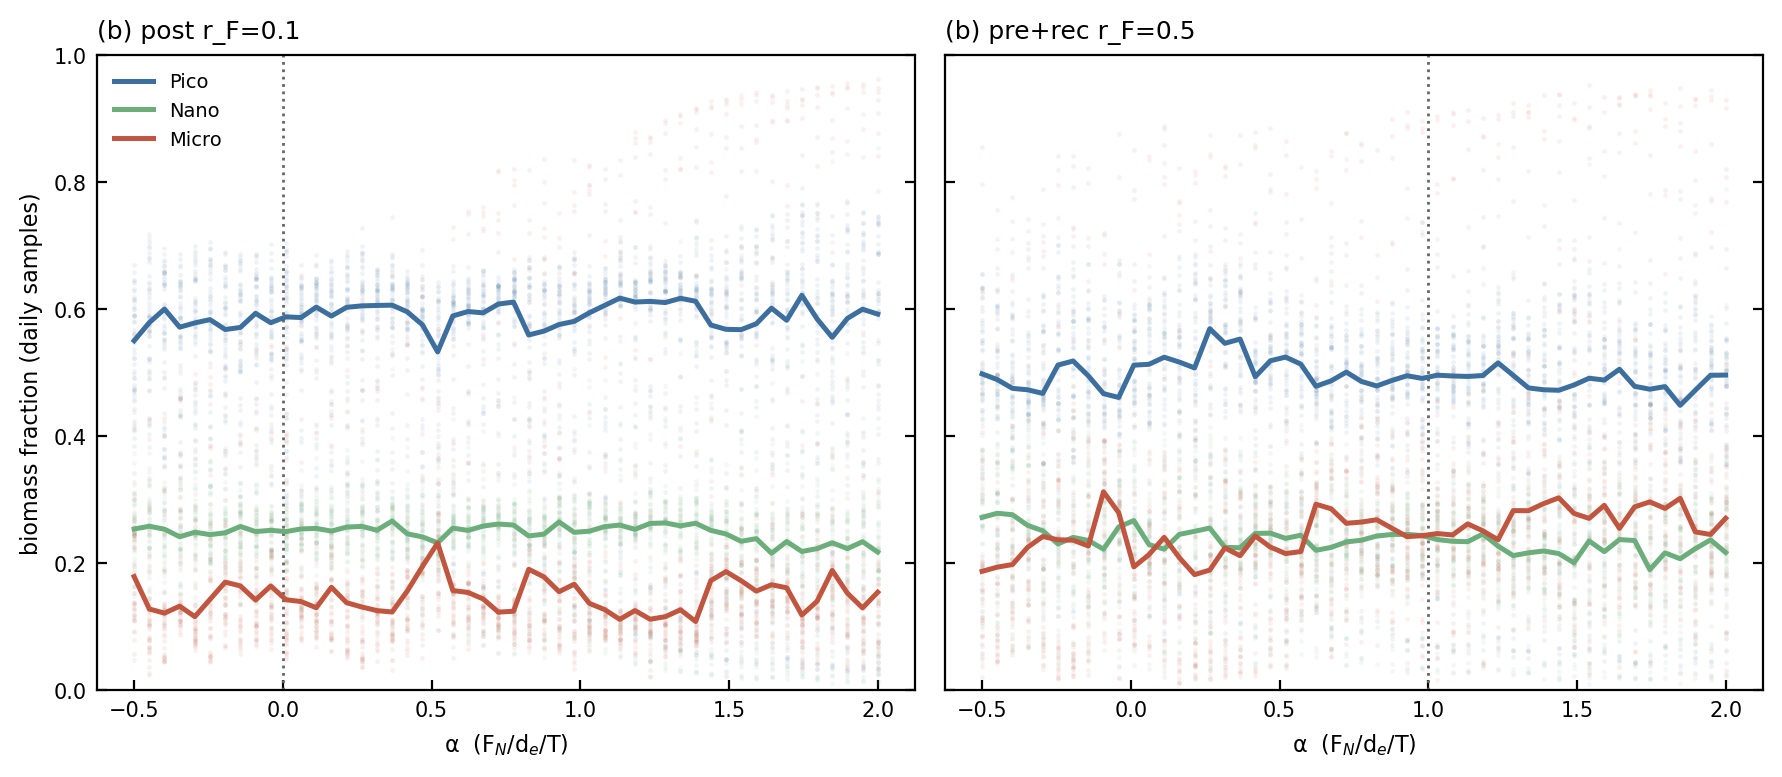

=== (b) composition vs α (per-α sample medians) ===
  post r_F=0.1 (rF≈0.10): micro>pico from α≈None
     α=+0.01: pico 0.59  nano 0.25  micro 0.14
     α=+0.98: pico 0.58  nano 0.25  micro 0.17
  pre+rec r_F=0.5 (rF≈0.50): micro>pico from α≈None
     α=+0.01: pico 0.51  nano 0.27  micro 0.19
     α=+0.98: pico 0.49  nano 0.24  micro 0.24


In [11]:
# ---- (b) composition vs α, one panel per r_F — trajectory samples ----
COL = {'Pico': '#3C6E9E', 'Nano': '#6BAE7B', 'Micro': '#C0563F'}
SUB = 20                                              # subsample days for the scatter cloud
alpha = ds[A_NAME].values
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.0), sharey=True)
for ax, (lab, rf) in zip(axes, RF_LEVELS.items()):
    dsr = ds.sel({R_NAME: rf}, method='nearest')
    p, n, m = dsr['traj_pico'].values, dsr['traj_nano'].values, dsr['traj_micro'].values  # (alpha, day)
    tot = p + n + m; safe = tot > 0
    fr = {c: np.where(safe, x/np.where(safe, tot, 1), np.nan) for c, x in (('Pico',p),('Nano',n),('Micro',m))}
    for cls in ('Pico', 'Nano', 'Micro'):
        f = fr[cls]; xs = np.repeat(alpha, f[:, ::SUB].shape[1])
        ax.scatter(xs, f[:, ::SUB].ravel(), s=3, color=COL[cls], alpha=0.08, lw=0, zorder=2)
        ax.plot(alpha, np.nanmedian(f, axis=1), color=COL[cls], lw=1.8, zorder=4, label=cls)
    ax.axvline(0.0 if rf < 0.3 else 1.0, color='0.4', ls=':', lw=1.0)   # era α on this r_F slice
    ax.set_xlabel('α  (F$_N$/d$_e$/T)', fontsize=8); ax.set_ylim(0, 1)
    ax.set_title(f'(b) {lab}', fontsize=9, loc='left'); _style(ax)
axes[0].set_ylabel('biomass fraction (daily samples)', fontsize=8)
axes[0].legend(frameon=False, fontsize=7, loc='upper left'); fig.tight_layout(); plt.show()
print("=== (b) composition vs α (per-α sample medians) ===")
for lab, rf in RF_LEVELS.items():
    dsr = ds.sel({R_NAME: rf}, method='nearest')
    p, n, m = dsr['traj_pico'].values, dsr['traj_nano'].values, dsr['traj_micro'].values
    tot = p + n + m; mi, pi = np.nanmedian(m/tot, 1), np.nanmedian(p/tot, 1)
    cross = alpha[np.argmax(mi > pi)] if np.any(mi > pi) else None
    print(f"  {lab} (rF≈{float(dsr[R_NAME]):.2f}): micro>pico from α≈{cross}")
    for av in (0.0, 1.0):
        i = int(np.argmin(np.abs(alpha - av)))
        print(f"     α={alpha[i]:+.2f}: pico {pi[i]:.2f}  nano {np.nanmedian((n/tot)[i]):.2f}  micro {mi[i]:.2f}")

=== (c) MCS vs T (traj samples) ===
  post     (α+0.01): T [22.8, 26.9]°C  MCS [1.42, 13.85]µm  slope -0.070 log10µm/°C  r=-0.42
  pre+rec  (α+0.98): T [22.4, 26.1]°C  MCS [1.08, 42.16]µm  slope -0.071 log10µm/°C  r=-0.29


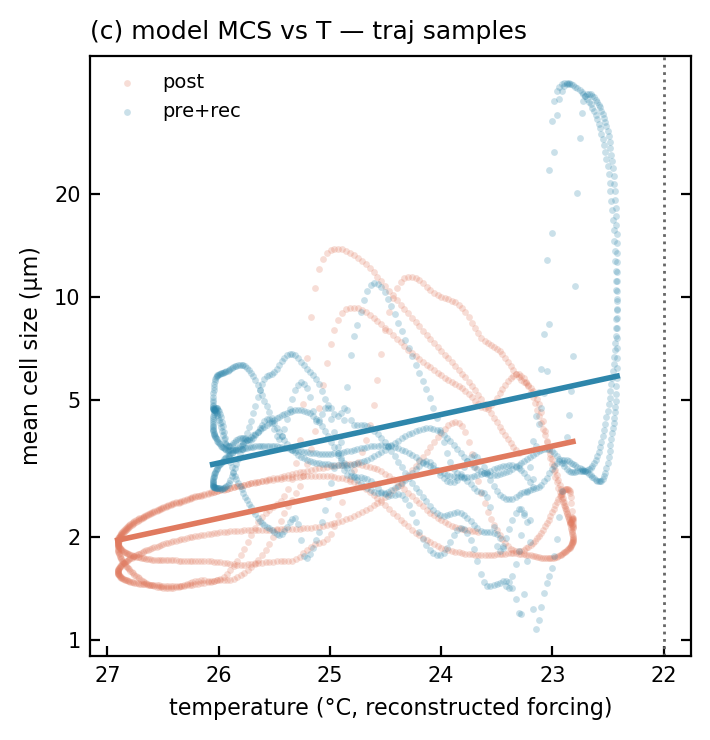

  matched-T (24°C) MCS: post 3.13  pre+rec 4.54  ratio 1.45x  (obs ANCOVA level-shift ≈ 1.73x)


In [12]:
# ---- (c) MCS vs temperature — trajectory samples ----
fig, ax = plt.subplots(figsize=(3.9, 3.9)); fits = {}
print("=== (c) MCS vs T (traj samples) ===")
for name, e in ERAS.items():
    da = cell_traj('traj_mcs', e['alpha'], e['rF']); a_snap = da[A_NAME].item()
    Tk = forcing('T', a_snap); mcs = da.values; ok = np.isfinite(mcs) & (mcs > 0)
    ax.scatter(Tk[ok], mcs[ok], s=6, color=e['col'], alpha=0.25, lw=0, zorder=3, label=name)
    b = np.polyfit(Tk[ok], np.log10(mcs[ok]), 1); fits[name] = b
    xx = np.linspace(Tk[ok].min(), Tk[ok].max(), 50); ax.plot(xx, 10**np.polyval(b, xx), color=e['col'], lw=2, zorder=4)
    r = np.corrcoef(Tk[ok], np.log10(mcs[ok]))[0, 1]
    print(f"  {name:8s} (α{a_snap:+.2f}): T [{Tk[ok].min():.1f}, {Tk[ok].max():.1f}]°C  "
          f"MCS [{mcs[ok].min():.2f}, {mcs[ok].max():.2f}]µm  slope {b[0]:+.3f} log10µm/°C  r={r:+.2f}")
ax.set_yscale('log'); ax.set_yticks(UM_TICKS); ax.set_yticklabels(UM_TICKS)
ax.yaxis.set_minor_locator(plt.NullLocator()); ax.invert_xaxis()         # upwelling (cool) to the right
ax.axvline(22.0, color='0.4', ls=':', lw=1.0)
ax.set_xlabel('temperature (°C, reconstructed forcing)', fontsize=8)
ax.set_ylabel('mean cell size (µm)', fontsize=8)
ax.set_title('(c) model MCS vs T — traj samples', fontsize=9, loc='left')
ax.set_box_aspect(1); _style(ax); ax.legend(frameon=False, fontsize=7, loc='upper left'); plt.show()
Tm = 24.0; pr = {nm: 10**np.polyval(b, Tm) for nm, b in fits.items()}
print(f"  matched-T ({Tm:.0f}°C) MCS: post {pr['post']:.2f}  pre+rec {pr['pre+rec']:.2f}  "
      f"ratio {pr['pre+rec']/pr['post']:.2f}x  (obs ANCOVA level-shift ≈ 1.73x)")

Composition stats across the (F_N × r_F) plane:
  Pico   mean = 0.481   max = 0.648   (at F_N=0.10, r_F=0.59)
  Nano   mean = 0.257   max = 0.507   (at F_N=0.10, r_F=0.15)
  Micro  mean = 0.262   max = 0.411   (at F_N=0.58, r_F=0.00)

argmax distribution (which class wins each cell, by fraction):
  Pico : 2487/2500  (99.5%)
  Nano :   10/2500  (0.4%)
  Micro:    3/2500  (0.1%)

Dominance margin (max − 2nd): min=0.000  median=0.183  max=0.311
  cells with margin > 0.10: 2260/2500  (90.4%)
  cells with margin > 0.20: 1044/2500  (41.8%)
  cells with margin > 0.30: 48/2500  (1.9%)


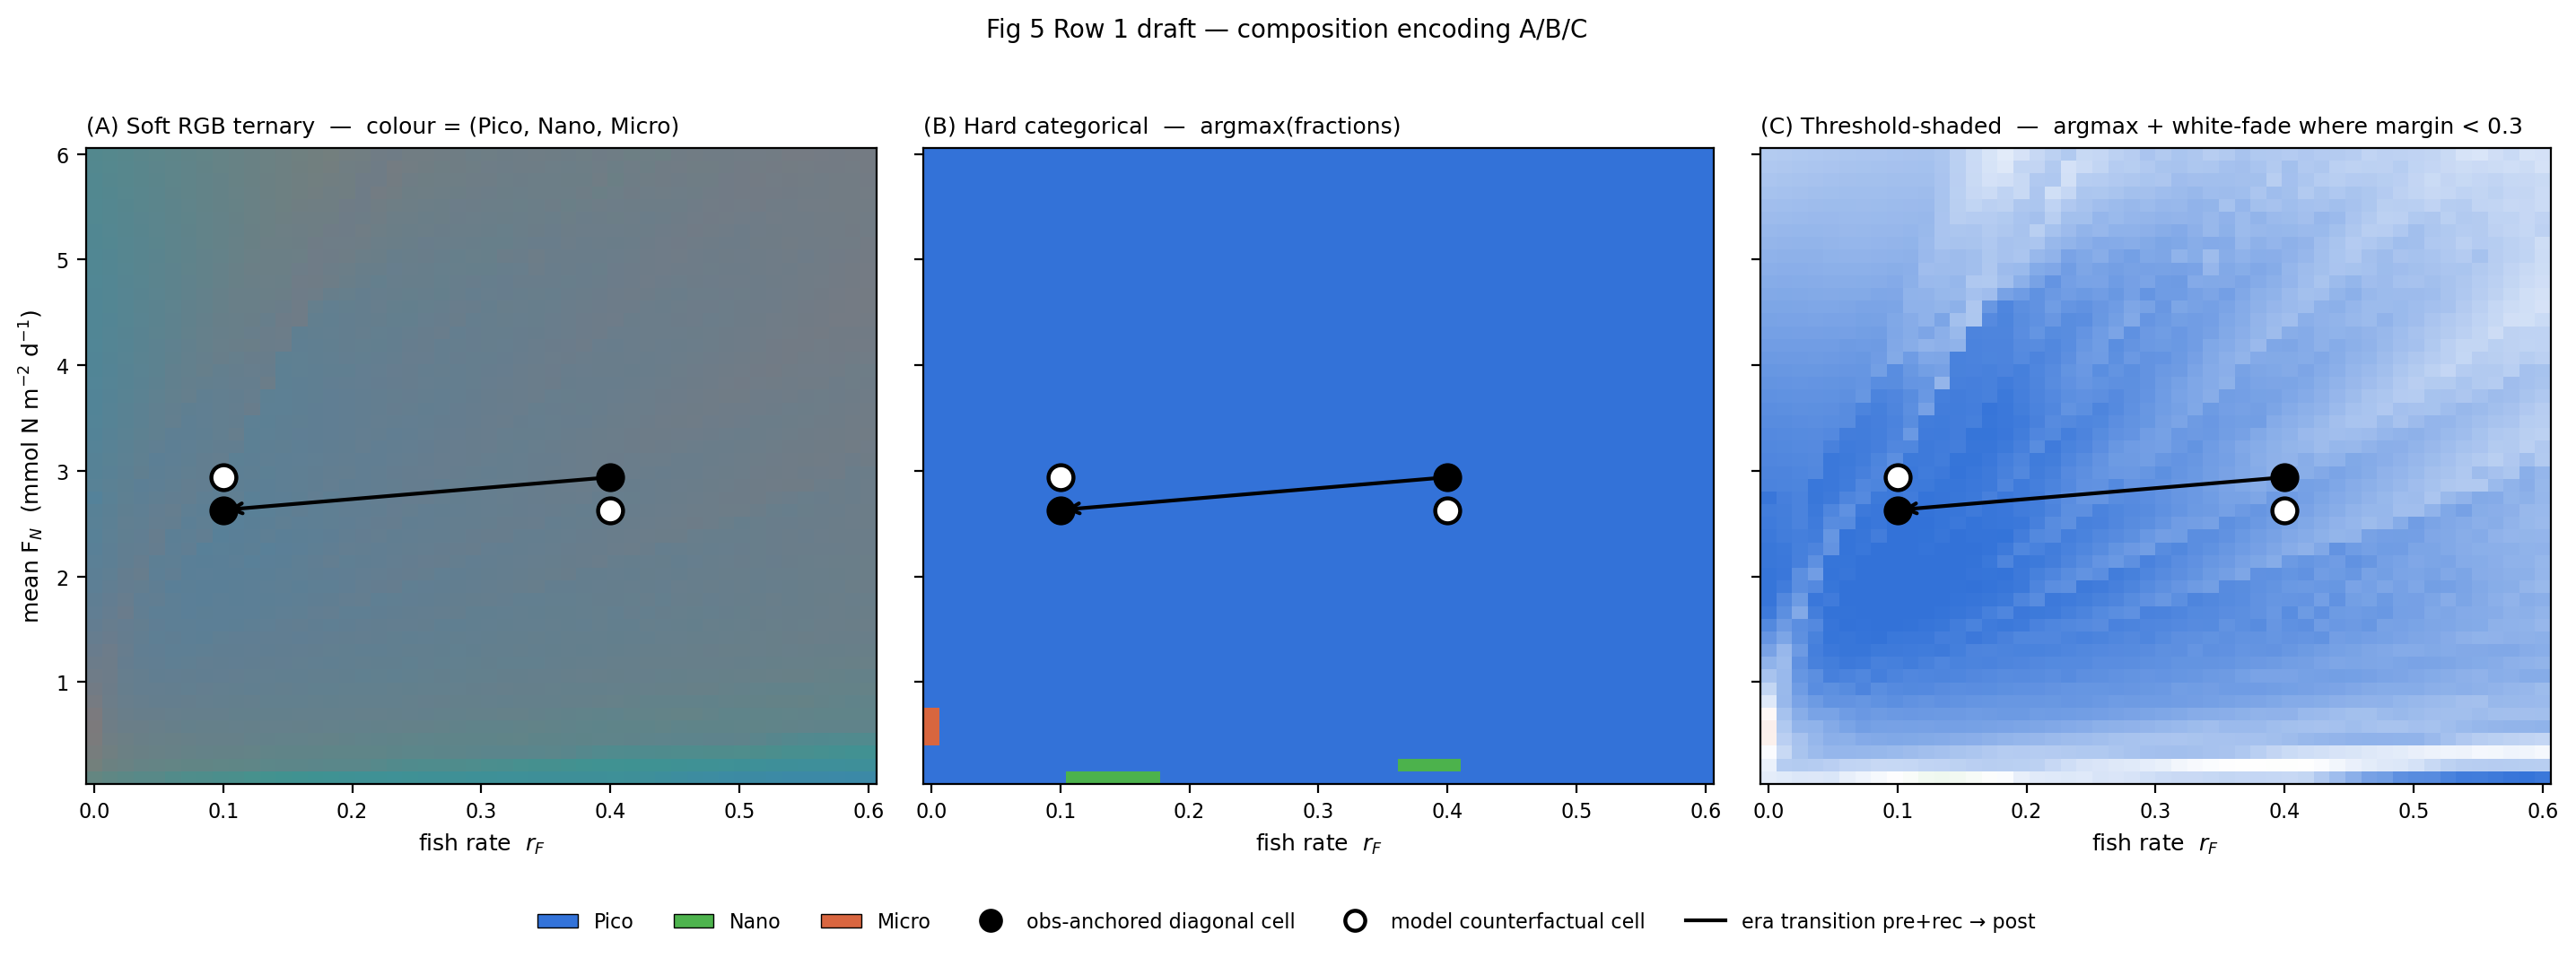

In [4]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import xarray as xr
from matplotlib.patches import Patch

ds = xr.open_dataset('results/fig5_seasonal_scan_50x50_2026-06-25.nc')
mean_FN = ds['mean_FN'].values
R_F     = ds['rF'].values
pico    = ds['pico'].values
nano    = ds['nano'].values
micro   = ds['micro'].values

# Stack into (FN, rF, 3) and normalise (defensive — fractions should already sum to 1)
fr = np.stack([pico, nano, micro], axis=-1)
s = fr.sum(-1, keepdims=True)
fr = np.where(s > 0, fr / s, np.nan)

# Class colours — Pico cool, Nano green, Micro warm (diatom-ish)
COLOURS = {'Pico':  np.array([0.20, 0.45, 0.85]),    # blue
           'Nano':  np.array([0.30, 0.70, 0.30]),    # green
           'Micro': np.array([0.85, 0.40, 0.25])}    # warm
CLASS_ORDER = ['Pico', 'Nano', 'Micro']
C = np.stack([COLOURS[c] for c in CLASS_ORDER])      # (3, 3) — class × RGB

# === diagnostics — surface stats =========================================
print("Composition stats across the (F_N × r_F) plane:")
for k, name in enumerate(CLASS_ORDER):
    arr = (pico, nano, micro)[k]
    i_max, j_max = np.unravel_index(np.nanargmax(arr), arr.shape)
    print(f"  {name:5s}  mean = {np.nanmean(arr):.3f}   max = {np.nanmax(arr):.3f}"
          f"   (at F_N={mean_FN[i_max]:.2f}, r_F={R_F[j_max]:.2f})")

argmax_cls = np.argmax(fr, axis=-1)
print("\nargmax distribution (which class wins each cell, by fraction):")
for k, name in enumerate(CLASS_ORDER):
    n = int((argmax_cls == k).sum())
    print(f"  {name:5s}: {n:4d}/{argmax_cls.size}  ({100*n/argmax_cls.size:.1f}%)")

sorted_fr = np.sort(fr, axis=-1)[..., ::-1]
margin = sorted_fr[..., 0] - sorted_fr[..., 1]
print(f"\nDominance margin (max − 2nd): "
      f"min={np.nanmin(margin):.3f}  median={np.nanmedian(margin):.3f}  max={np.nanmax(margin):.3f}")
for t in (0.10, 0.20, 0.30):
    print(f"  cells with margin > {t:.2f}: "
          f"{int((margin > t).sum())}/{margin.size}  ({100*(margin>t).sum()/margin.size:.1f}%)")

# === build the three encodings ===========================================
# Encoding A — SOFT RGB TERNARY: cell colour = (Pico, Nano, Micro) @ class colours
soft_rgb = np.tensordot(fr, C, axes=([2], [0]))             # (FN, rF, 3)
soft_rgb = np.clip(soft_rgb, 0, 1)

# Encoding B — HARD CATEGORICAL: argmax → class colour
hard_rgb = C[argmax_cls]                                    # (FN, rF, 3)

# Encoding C — THRESHOLD-SHADED: argmax colour blended toward white by (1 - margin)
M_REF = 0.30                                                # margin at which colour goes full-saturation
blend = np.clip(margin / M_REF, 0, 1)                       # 0 = washed white, 1 = saturated class colour
white  = np.ones(3)
thr_rgb = C[argmax_cls] * blend[..., None] + white[None, None, :] * (1 - blend[..., None])

# Era operating points (using the interim (0.4, 0.1) pickle pair Benny's rebuilding)
OPS = [
    ('pre+rec',           2.94, 0.4, True),    # filled = obs-anchored diagonal
    ('post',              2.63, 0.1, True),    # filled = obs-anchored diagonal
    ('pre with post r_F', 2.94, 0.1, False),   # open = counterfactual
    ('post with pre r_F', 2.63, 0.4, False),   # open = counterfactual
]

def _draw_markers(ax):
    for lbl, fn, rf, filled in OPS:
        ax.plot(rf, fn, 'o', ms=10,
                mfc='white' if not filled else 'black',
                mec='black', mew=1.6, zorder=5)
    # transition arrow pre+rec -> post (the historical era trajectory)
    ax.annotate('', xy=(0.1, 2.63), xytext=(0.4, 2.94),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'), zorder=6)

# === plot — 1×3 grid, one encoding per panel =============================
fig, axes = plt.subplots(1, 3, figsize=(14.5, 5.2), sharey=True)

extent = (R_F[0] - 0.5*(R_F[1]-R_F[0]),   R_F[-1] + 0.5*(R_F[1]-R_F[0]),
          mean_FN[0] - 0.5*(mean_FN[1]-mean_FN[0]),
          mean_FN[-1] + 0.5*(mean_FN[1]-mean_FN[0]))

for ax, surf, title in [
    (axes[0], soft_rgb, '(A) Soft RGB ternary  —  colour = (Pico, Nano, Micro)'),
    (axes[1], hard_rgb, '(B) Hard categorical  —  argmax(fractions)'),
    (axes[2], thr_rgb,  f'(C) Threshold-shaded  —  argmax + white-fade where margin < {M_REF}'),
]:
    ax.imshow(surf, origin='lower', extent=extent, aspect='auto', interpolation='nearest')
    _draw_markers(ax)
    ax.set_xlabel('fish rate  $r_F$', fontsize=9)
    ax.set_title(title, fontsize=9, loc='left')
    ax.tick_params(labelsize=8)
axes[0].set_ylabel(r'mean F$_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=9)

# class-colour legend (shared)
legend_handles = [Patch(facecolor=COLOURS[c], edgecolor='k', lw=0.5, label=c) for c in CLASS_ORDER]
legend_handles += [
    plt.Line2D([], [], marker='o', color='black', mfc='black', mec='black', mew=1.6, ms=8, ls='',
               label='obs-anchored diagonal cell'),
    plt.Line2D([], [], marker='o', color='black', mfc='white', mec='black', mew=1.6, ms=8, ls='',
               label='model counterfactual cell'),
    plt.Line2D([], [], color='black', lw=1.5, label='era transition pre+rec → post'),
]
fig.legend(handles=legend_handles, fontsize=8, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
fig.suptitle('Fig 5 Row 1 draft — composition encoding A/B/C', fontsize=10)
fig.tight_layout(rect=(0, 0.05, 1, 0.96))
plt.show()

era             metric    mean     min     max  amp(½range)   peak month
pre+recovery    F_N       3.06    1.10    5.39         2.14            2
pre+recovery    d_e      42.09   28.33   53.84        12.75           10
pre+recovery    T        24.22   22.63   26.26         1.81           11

post            F_N       2.20    0.74    4.14         1.70            2
post            d_e      47.63   35.40   55.47        10.04           10
post            T        24.87   22.85   26.95         2.05           11

Pre/post comparisons:
  F_N mean ratio (pre/post): 1.39
  F_N peak ratio (pre/post): 1.30
  F_N amplitude (pre):       2.14
  F_N amplitude (post):      1.70
  F_N amplitude ratio:       1.26


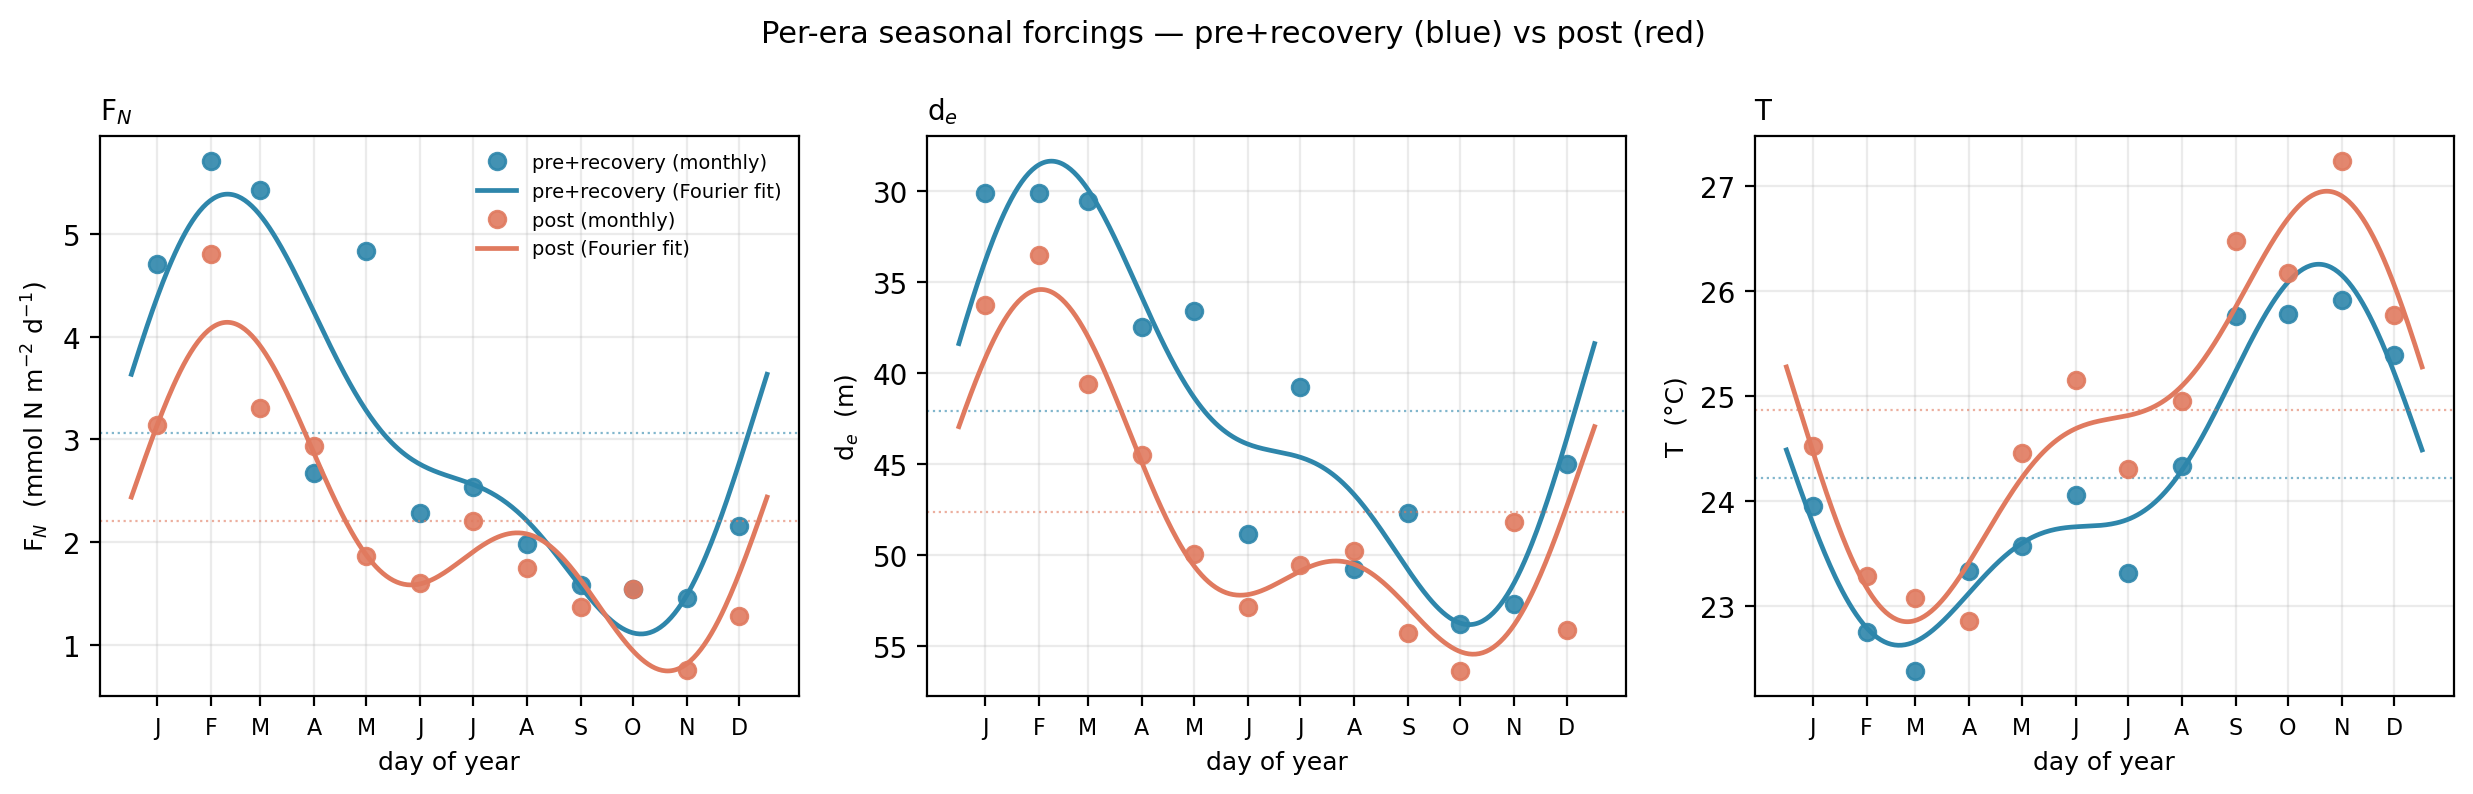

In [5]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _build_fourier_func

forc = ssh.build_forcings(['pre+recovery', 'post'])
ERA_COL = {'pre+recovery': '#2E86AB', 'post': '#E07A5F'}
months = np.arange(1, 13)
mid_doy = ssh._MEDGES.cumsum() - ssh._MEDGES / 2   # mid-month days; if this errors, use np.array([15,46,...])
# safer: just use sequential month-centre days (≈ mid-month DOYs)
mid_doy = np.array([15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349])

# build smooth Fourier-fit traces (same as what the model integrates)
t_smooth = np.linspace(0, 365, 365)
def fourier_smooth(monthly, n=2):
    f = _build_fourier_func(monthly, period=365.0, n_harmonics=n)
    return f(t_smooth)

# === diagnostics: means, peaks, amplitudes ==============================
print(f"{'era':<14}  {'metric':<6}  {'mean':>6}  {'min':>6}  {'max':>6}  {'amp(½range)':>11}  "
      f"{'peak month':>11}")
for era, dat in forc.items():
    for key, lbl in [('fn', 'F_N'), ('de', 'd_e'), ('t', 'T')]:
        arr = dat[key]
        # Use Fourier-smoothed trace for the "what the model sees"
        smooth = fourier_smooth(arr)
        m = float(np.mean(smooth))
        lo, hi = float(np.min(smooth)), float(np.max(smooth))
        amp = (hi - lo) / 2
        peak_mo = months[np.argmax([smooth[(int(d)-1) % 365] for d in mid_doy])]
        print(f"{era:<14}  {lbl:<6}  {m:6.2f}  {lo:6.2f}  {hi:6.2f}  {amp:11.2f}  {peak_mo:>11}")
    print()
print("Pre/post comparisons:")
fn_pre, fn_post = forc['pre+recovery']['fn'], forc['post']['fn']
fn_pre_smooth, fn_post_smooth = fourier_smooth(fn_pre), fourier_smooth(fn_post)
print(f"  F_N mean ratio (pre/post): {fn_pre.mean()/fn_post.mean():.2f}")
print(f"  F_N peak ratio (pre/post): {fn_pre_smooth.max()/fn_post_smooth.max():.2f}")
print(f"  F_N amplitude (pre):       {(fn_pre_smooth.max() - fn_pre_smooth.min())/2:.2f}")
print(f"  F_N amplitude (post):      {(fn_post_smooth.max() - fn_post_smooth.min())/2:.2f}")
print(f"  F_N amplitude ratio:       {((fn_pre_smooth.max() - fn_pre_smooth.min())/(fn_post_smooth.max() - fn_post_smooth.min())):.2f}")

# === plot — 3 panels: F_N, d_e, T =======================================
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))
for ax, (key, lbl, units, invert_y) in zip(axes, [
    ('fn', r'F$_N$',  'mmol N m$^{-2}$ d$^{-1}$', False),
    ('de', r'd$_e$',  'm',                         True),
    ('t',  'T',       '°C',                        False),
]):
    for era, dat in forc.items():
        col = ERA_COL[era]
        ax.plot(mid_doy, dat[key], 'o', color=col, ms=6, alpha=0.9, label=f'{era} (monthly)')
        ax.plot(t_smooth, fourier_smooth(dat[key]), '-', color=col, lw=1.7,
                label=f'{era} (Fourier fit)')
        # horizontal mean line
        ax.axhline(np.mean(fourier_smooth(dat[key])), ls=':', lw=0.8, color=col, alpha=0.6)
    ax.set_xlabel('day of year', fontsize=9)
    ax.set_ylabel(f"{lbl}  ({units})", fontsize=9)
    ax.set_title(lbl, fontsize=10, loc='left')
    ax.set_xticks([15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349])
    ax.set_xticklabels(list('JFMAMJJASOND'), fontsize=8)
    if invert_y: ax.invert_yaxis()
    ax.grid(True, alpha=0.25)

axes[0].legend(fontsize=7, frameon=False, loc='best')
fig.suptitle('Per-era seasonal forcings — pre+recovery (blue) vs post (red)', fontsize=11)
fig.tight_layout()
plt.show()

     α   F_N mean   F_N peak   F_N amp   d_e mean   d_e min   T mean    J=F_N/d_e     J peak
----------------------------------------------------------------------------------------------------
 -0.50       1.77       3.52      1.52      50.41     38.83    25.19       0.0378     0.0899  
  0.00       2.20       4.14      1.70      47.63     35.40    24.87       0.0503     0.1165   ← post   
  0.50       2.63       4.77      1.91      44.86     31.90    24.55       0.0650     0.1491  
  1.00       3.06       5.39      2.14      42.09     28.33    24.22       0.0827     0.1902   ← pre+rec
  1.50       3.49       6.01      2.41      39.32     24.70    23.90       0.1045     0.2434  
  2.00       3.92       6.64      2.69      36.55     21.00    23.58       0.1321     0.3158  


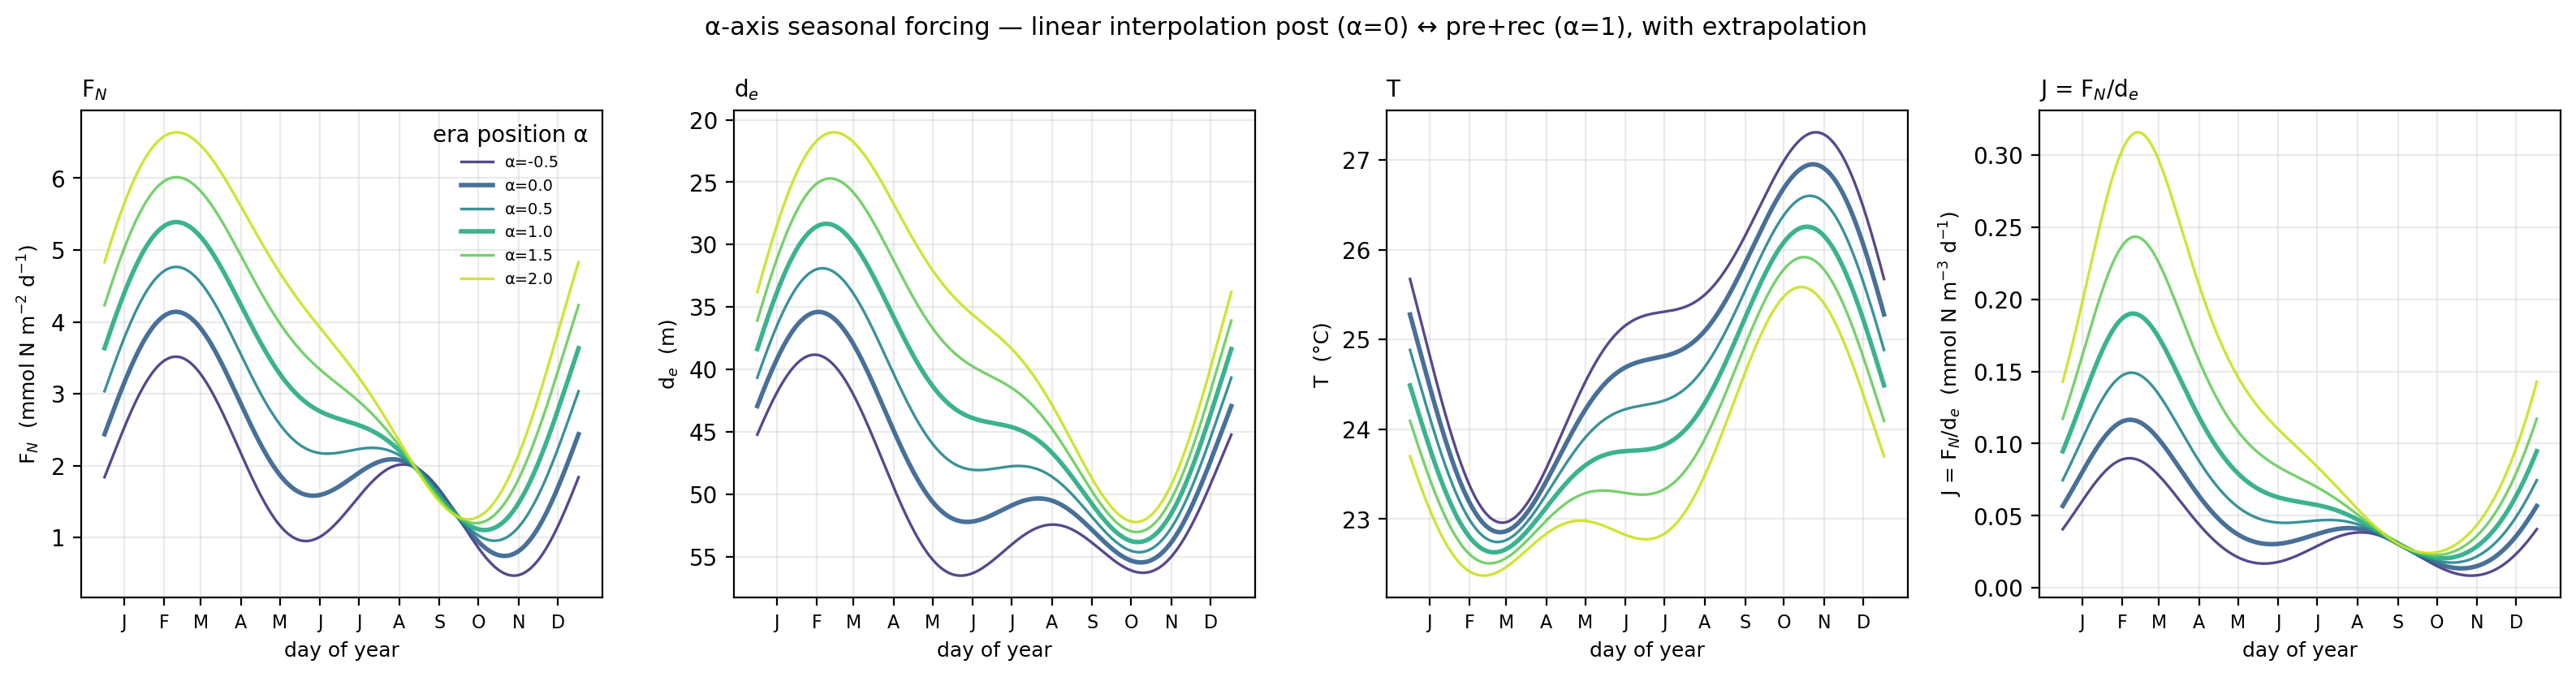

In [6]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _build_fourier_func

forc = ssh.build_forcings(['pre+recovery', 'post'])

# α values to show — span the proposed scan range
ALPHAS = np.array([-0.5, 0.0, 0.5, 1.0, 1.5, 2.0])
COLORS = plt.cm.viridis(np.linspace(0.15, 0.92, len(ALPHAS)))
mid_doy = np.array([15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349])
t_smooth = np.linspace(0, 365, 365)

def forcing_at_alpha(forc_pre, forc_post, alpha):
    """Linear era-position interpolation: α=0 → post, α=1 → pre+rec, extrapolates outside."""
    return {key: forc_post[key] + alpha * (forc_pre[key] - forc_post[key])
            for key in ('fn', 'de', 't')}

def fourier_smooth(monthly, n=2):
    f = _build_fourier_func(monthly, period=365.0, n_harmonics=n)
    return f(t_smooth)

# === diagnostic table — what the model sees at each α ===================
print(f"{'α':>6}  {'F_N mean':>9}  {'F_N peak':>9}  {'F_N amp':>8}  "
      f"{'d_e mean':>9}  {'d_e min':>8}  {'T mean':>7}  "
      f"{'J=F_N/d_e':>11}  {'J peak':>9}")
print("-" * 100)
for alpha in ALPHAS:
    f = forcing_at_alpha(forc['pre+recovery'], forc['post'], alpha)
    fn = fourier_smooth(f['fn'])
    de = fourier_smooth(f['de'])
    tt = fourier_smooth(f['t'])
    j  = fn / de
    tag = ' ← post   ' if abs(alpha-0.0) < 1e-6 else (' ← pre+rec' if abs(alpha-1.0) < 1e-6 else '')
    print(f"{alpha:>6.2f}  {fn.mean():9.2f}  {fn.max():9.2f}  "
          f"{(fn.max()-fn.min())/2:8.2f}  "
          f"{de.mean():9.2f}  {de.min():8.2f}  {tt.mean():7.2f}  "
          f"{j.mean():11.4f}  {j.max():9.4f}  {tag}")

# === plot: F_N, d_e, T, J(=F_N/d_e) per α ===============================
fig, axes = plt.subplots(1, 4, figsize=(16.0, 4.2))
for ax, (key, lbl, units, invert_y, derived) in zip(axes, [
    ('fn', r'F$_N$',           'mmol N m$^{-2}$ d$^{-1}$', False, None),
    ('de', r'd$_e$',           'm',                         True,  None),
    ('t',  'T',                '°C',                        False, None),
    (None, r'J = F$_N$/d$_e$', 'mmol N m$^{-3}$ d$^{-1}$',  False, 'supply'),
]):
    for alpha, color in zip(ALPHAS, COLORS):
        f = forcing_at_alpha(forc['pre+recovery'], forc['post'], alpha)
        if derived == 'supply':
            y = fourier_smooth(f['fn']) / fourier_smooth(f['de'])
        else:
            y = fourier_smooth(f[key])
        lw = 2.0 if abs(alpha) < 1e-6 or abs(alpha - 1) < 1e-6 else 1.2
        ax.plot(t_smooth, y, '-', color=color, lw=lw, alpha=0.9, label=f'α={alpha:.1f}')
    ax.set_xlabel('day of year', fontsize=9)
    ax.set_ylabel(f'{lbl}  ({units})', fontsize=9)
    ax.set_title(lbl, fontsize=10, loc='left')
    ax.set_xticks([15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349])
    ax.set_xticklabels(list('JFMAMJJASOND'), fontsize=8)
    if invert_y: ax.invert_yaxis()
    ax.grid(True, alpha=0.25)
axes[0].legend(fontsize=7, frameon=False, loc='upper right', title='era position α')

fig.suptitle('α-axis seasonal forcing — linear interpolation post (α=0) ↔ pre+rec (α=1), with extrapolation',
             fontsize=11)
fig.tight_layout()
plt.show()

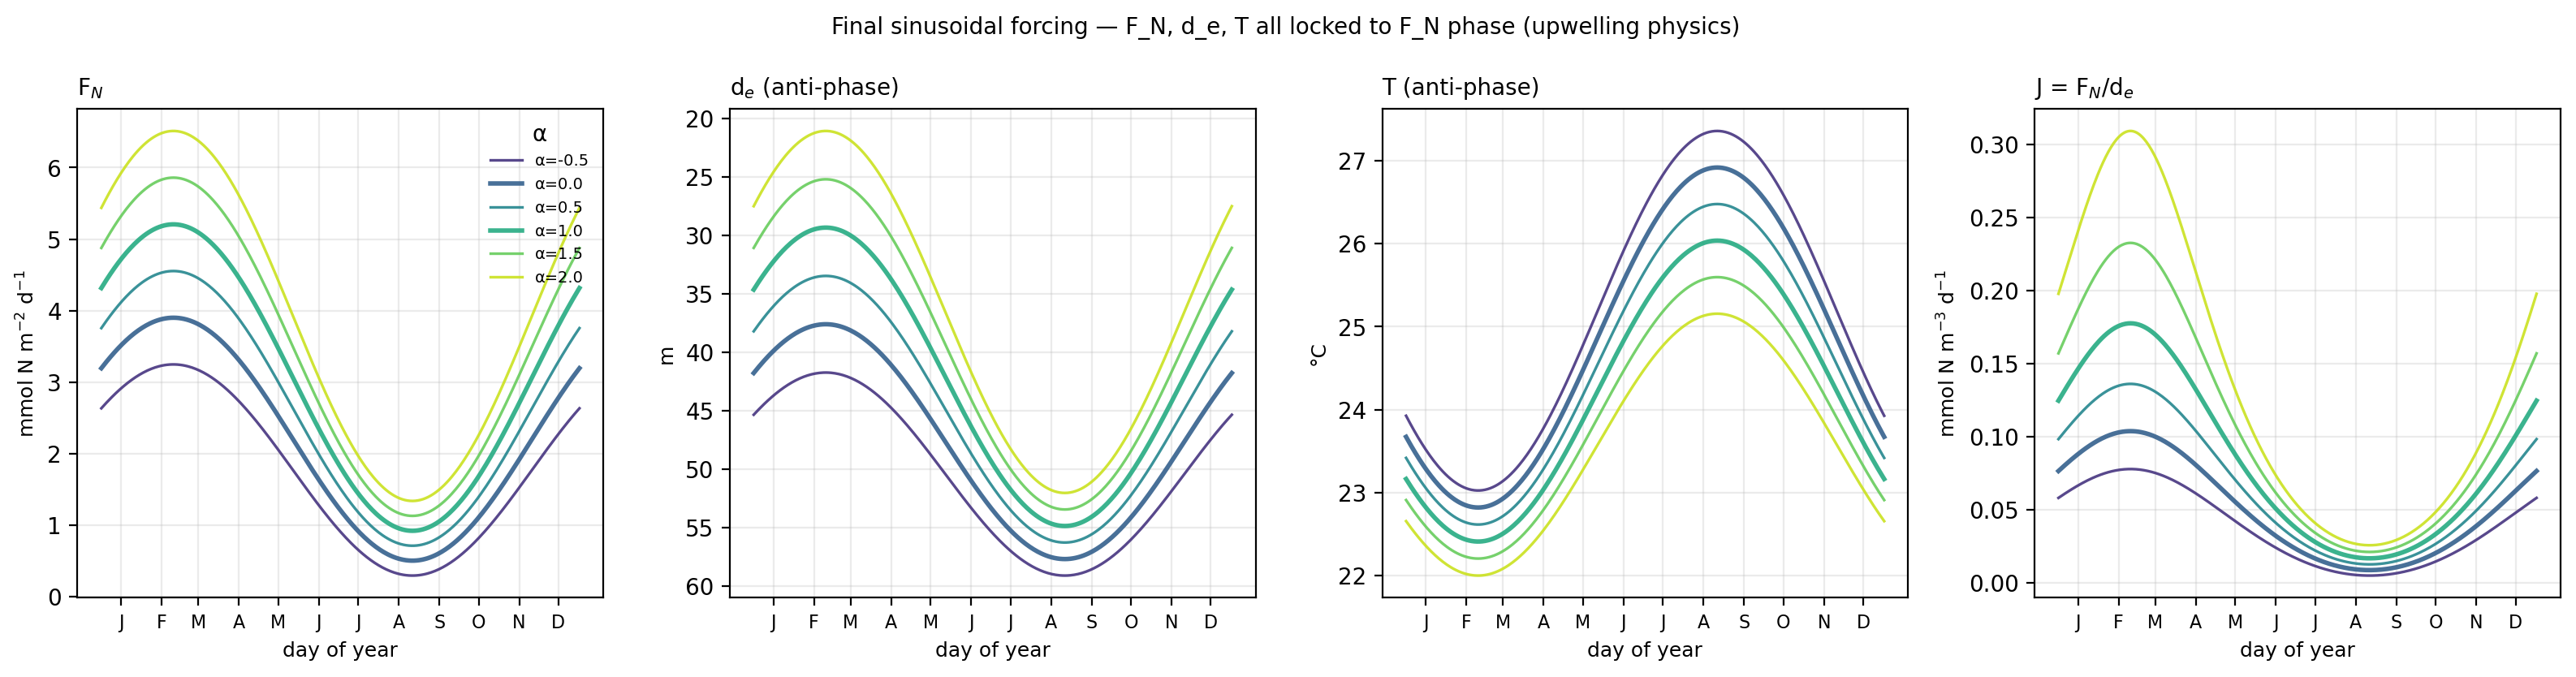

Sinusoidal parameters (linear interp post → pre+rec, all phase-locked to F_N peak):
  F_N: mean 2.20 → 3.06   amp 1.70 → 2.14
  d_e: mean 47.63 → 42.09   amp 10.04 → 12.75
  T:   mean 24.87 → 24.22    amp 2.05 → 1.81  (cool at upwelling)
  F_N peak day: 55 (Feb upwelling); d_e shallow + T cool at same phase

Note: this T phasing differs from raw obs (obs T peaks Nov from solar) — chosen for abstract upwelling physics; deviation noted in caption.


In [8]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import seasonal_scan_harness as ssh
from baseline_r0_seasonal_comps import _build_fourier_func

forc = ssh.build_forcings(['pre+recovery', 'post'])
t_smooth = np.linspace(0, 365, 365)
def fourier_smooth(monthly, n=2):
    return _build_fourier_func(monthly, period=365.0, n_harmonics=n)(t_smooth)
def characterise(monthly):
    s = fourier_smooth(monthly)
    return float(s.mean()), float((s.max()-s.min())/2), int(np.argmax(s))

# Per-era characteristics
POST_FN_M, POST_FN_A, POST_FN_PHI = characterise(forc['post']['fn'])
PRE_FN_M,  PRE_FN_A,  PRE_FN_PHI  = characterise(forc['pre+recovery']['fn'])
POST_DE_M, POST_DE_A, _           = characterise(forc['post']['de'])
PRE_DE_M,  PRE_DE_A,  _           = characterise(forc['pre+recovery']['de'])
POST_T_M,  POST_T_A,  _           = characterise(forc['post']['t'])
PRE_T_M,   PRE_T_A,   _           = characterise(forc['pre+recovery']['t'])
PHI = POST_FN_PHI    # all forcings phase-locked to F_N peak

def sinusoidal_alpha(alpha):
    """All three forcings sinusoidal, anti-phase locked to F_N peak (upwelling physics).
    Linear interp of mean+amp between post (α=0) and pre+rec (α=1)."""
    fn_m = POST_FN_M + alpha * (PRE_FN_M - POST_FN_M)
    fn_a = POST_FN_A + alpha * (PRE_FN_A - POST_FN_A)
    de_m = POST_DE_M + alpha * (PRE_DE_M - POST_DE_M)
    de_a = POST_DE_A + alpha * (PRE_DE_A - POST_DE_A)
    t_m  = POST_T_M  + alpha * (PRE_T_M  - POST_T_M)
    t_a  = POST_T_A  + alpha * (PRE_T_A  - POST_T_A)
    cos_t = np.cos(2*np.pi*(t_smooth - PHI)/365)
    fn = np.maximum(fn_m + fn_a * cos_t, 0.01)
    de = np.maximum(de_m - de_a * cos_t, 5.0)         # in-phase opposition (shallow at upwelling)
    tt = t_m - t_a * cos_t                             # anti-phase (cool at upwelling)
    return fn, de, tt

# Viz at six α values
ALPHAS = [-0.5, 0.0, 0.5, 1.0, 1.5, 2.0]
COLORS = plt.cm.viridis(np.linspace(0.15, 0.92, len(ALPHAS)))

fig, axes = plt.subplots(1, 4, figsize=(16.0, 4.2))
for alpha, color in zip(ALPHAS, COLORS):
    fn, de, tt = sinusoidal_alpha(alpha)
    j = fn / de
    lw = 2.0 if abs(alpha) < 1e-6 or abs(alpha-1) < 1e-6 else 1.2
    for ax, y in zip(axes, [fn, de, tt, j]):
        ax.plot(t_smooth, y, color=color, lw=lw, alpha=0.9, label=f'α={alpha:.1f}')
axes[1].invert_yaxis()
for ax, ttl, ylbl in zip(axes, [r'F$_N$', r'd$_e$ (anti-phase)', 'T (anti-phase)', r'J = F$_N$/d$_e$'],
                              ['mmol N m$^{-2}$ d$^{-1}$', 'm', '°C', 'mmol N m$^{-3}$ d$^{-1}$']):
    ax.set_title(ttl, fontsize=10, loc='left'); ax.set_ylabel(ylbl, fontsize=9)
    ax.set_xlabel('day of year', fontsize=9)
    ax.set_xticks([15,46,74,105,135,166,196,227,258,288,319,349])
    ax.set_xticklabels(list('JFMAMJJASOND'), fontsize=8)
    ax.grid(True, alpha=0.25)
axes[0].legend(fontsize=7, frameon=False, loc='upper right', title='α')
fig.suptitle('Final sinusoidal forcing — F_N, d_e, T all locked to F_N phase (upwelling physics)',
             fontsize=10)
fig.tight_layout(); plt.show()

print("Sinusoidal parameters (linear interp post → pre+rec, all phase-locked to F_N peak):")
print(f"  F_N: mean {POST_FN_M:.2f} → {PRE_FN_M:.2f}   amp {POST_FN_A:.2f} → {PRE_FN_A:.2f}")
print(f"  d_e: mean {POST_DE_M:.2f} → {PRE_DE_M:.2f}   amp {POST_DE_A:.2f} → {PRE_DE_A:.2f}")
print(f"  T:   mean {POST_T_M:.2f} → {PRE_T_M:.2f}    amp {POST_T_A:.2f} → {PRE_T_A:.2f}  (cool at upwelling)")
print(f"  F_N peak day: {PHI} (Feb upwelling); d_e shallow + T cool at same phase")
print(f"\nNote: this T phasing differs from raw obs (obs T peaks Nov from solar) — chosen for abstract "
      f"upwelling physics; deviation noted in caption.")

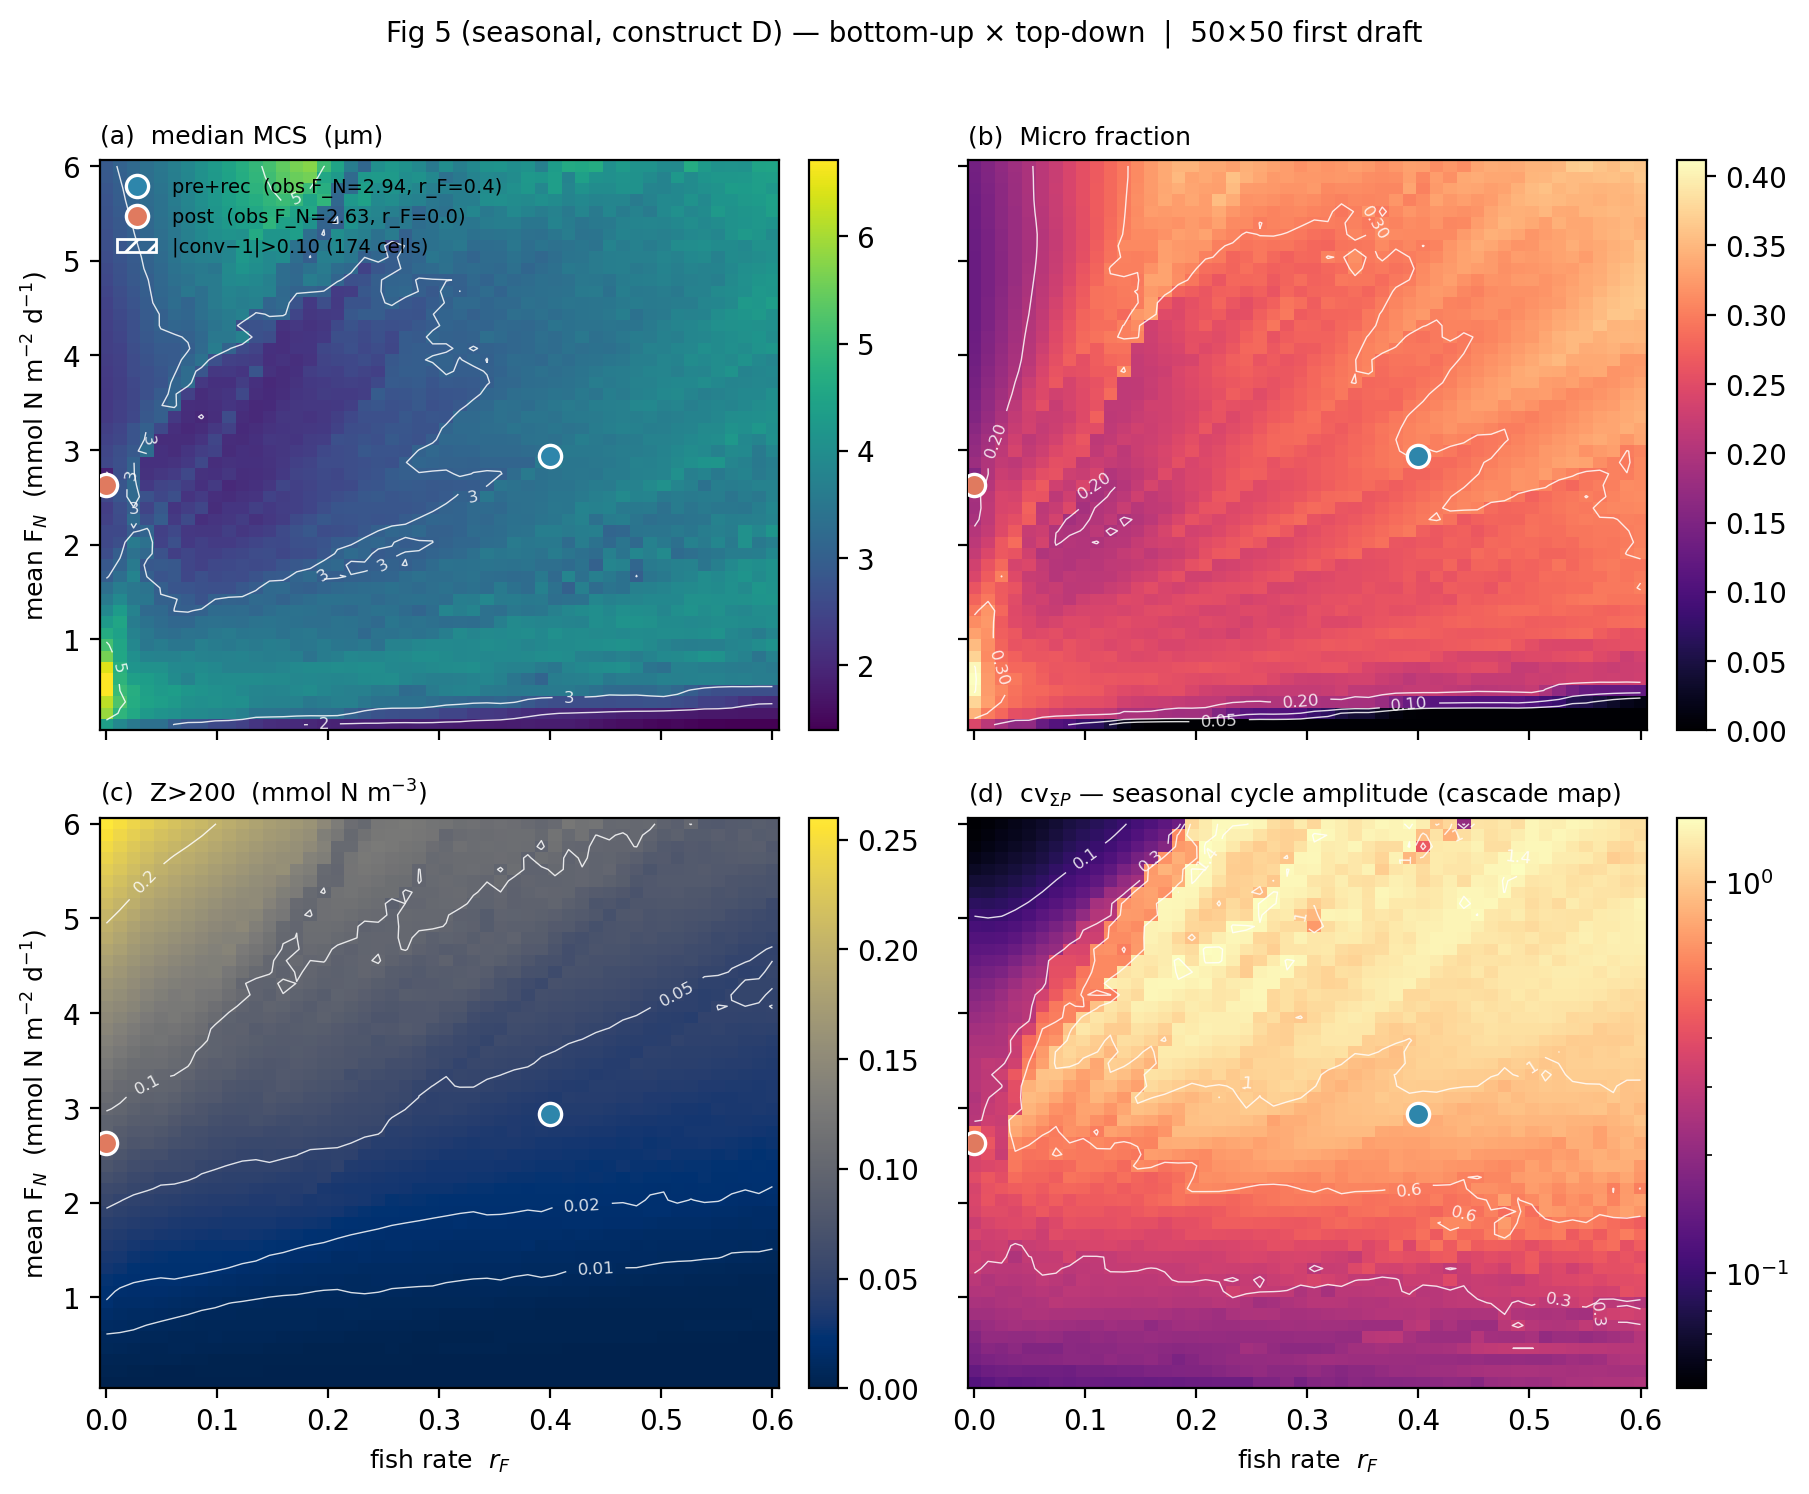


=== Operating-point values (nearest grid) ===

pre+rec  ≈  (F_N=2.99, r_F=0.40):
   MCS_med  =  3.51 µm
   MCS_mean =  5.89 µm
   Pico     = 0.48
   Nano     = 0.23
   Micro    = 0.30
   ΣP       =  0.71 mmol N m⁻³
   Z>200    = 0.0386 mmol N m⁻³
   Z>500    = 0.0077 mmol N m⁻³
   N        = 1.254 mmol N m⁻³
   cv_sumP  = 0.926
   |conv−1| = 0.000 (drift)

post  ≈  (F_N=2.63, r_F=0.00):
   MCS_med  =  2.46 µm
   MCS_mean =  3.06 µm
   Pico     = 0.55
   Nano     = 0.27
   Micro    = 0.18
   ΣP       =  0.54 mmol N m⁻³
   Z>200    = 0.0865 mmol N m⁻³
   Z>500    = 0.0336 mmol N m⁻³
   N        = 1.478 mmol N m⁻³
   cv_sumP  = 0.366
   |conv−1| = 0.001 (drift)

=== Pre/Post ratios (model vs obs) ===
  mcs_med :  model 1.42   obs 2.34
  micro   :  model 1.61   obs 2.33
  Z200    :  model 0.45   obs 0.66

=== Surface summary ===
  MCS_med  range: 1.39–6.71 µm
  cv_sumP  range: 0.051–1.458
  Z>200    range: 0.0000–0.2598
  Micro    range: 0.00–0.41
  cells with cv_sumP > 1.0 (high-cycle re

In [3]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

ds = xr.open_dataset('results/fig5_seasonal_scan_50x50_2026-06-25.nc')
mean_FN = ds['mean_FN'].values
R_F     = ds['rF'].values

# convergence mask (interannual drift flag) — for hatching
nonconv = np.abs(ds['mcs_conv'].values - 1.0) > 0.10

OPS = [('pre+rec', 2.94, 0.4, '#2E86AB'),
       ('post',    2.63, 0.0, '#E07A5F')]

panels = [
    ('(a)  median MCS  (µm)',            ds['mcs_med'].values, 'viridis',
     [2, 3, 5, 8, 12],                   '%g',   None),
    ('(b)  Micro fraction',              ds['micro'].values,   'magma',
     [0.05, 0.10, 0.20, 0.30, 0.40],     '%.2f', None),
    ('(c)  Z>200  (mmol N m$^{-3}$)',    ds['Z200'].values,    'cividis',
     [0.01, 0.02, 0.05, 0.10, 0.20],     '%.2g', None),
    ('(d)  cv$_{\\Sigma P}$ — seasonal cycle amplitude (cascade map)',
                                         ds['cv_sumP'].values, 'magma',
     [0.10, 0.30, 0.60, 1.00, 1.40],     '%.2g',
     LogNorm(vmin=max(float(np.nanmin(ds['cv_sumP'].values)), 1e-3),
             vmax=float(np.nanmax(ds['cv_sumP'].values)))),
]

fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.6), sharex=True, sharey=True)
for ax, (title, surf, cmap, lvls, fmt, norm) in zip(axes.flat, panels):
    pc = ax.pcolormesh(R_F, mean_FN, surf, shading='nearest', cmap=cmap, norm=norm)
    cs = ax.contour(R_F, mean_FN, surf, levels=lvls, colors='white', linewidths=0.5, alpha=0.85)
    ax.clabel(cs, fontsize=6, fmt=fmt)
    # hatch non-converged cells
    ax.pcolor(R_F, mean_FN, np.where(nonconv, 1, np.nan), shading='nearest',
              hatch='///', alpha=0, edgecolor='white', linewidth=0.0)
    for lbl, fn, rf, col in OPS:
        ax.plot(rf, fn, 'o', ms=8, color=col, mec='white', mew=1.2, label=lbl, zorder=5)
    ax.set_title(title, fontsize=9, loc='left')
    fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)

# legend with the hatching marker once
nonconv_patch = Patch(facecolor='none', edgecolor='white', hatch='///',
                      label=f'|conv−1|>0.10 ({int(nonconv.sum())} cells)')
axes[0,0].legend(handles=[
    plt.Line2D([0],[0], marker='o', ms=8, color='#2E86AB', mec='white', mew=1.2,
               linestyle='', label='pre+rec  (obs F_N=2.94, r_F=0.4)'),
    plt.Line2D([0],[0], marker='o', ms=8, color='#E07A5F', mec='white', mew=1.2,
               linestyle='', label='post  (obs F_N=2.63, r_F=0.0)'),
    nonconv_patch,
], fontsize=7, frameon=False, loc='upper left')

for ax in axes[1,:]: ax.set_xlabel('fish rate  $r_F$', fontsize=9)
for ax in axes[:,0]: ax.set_ylabel(r'mean F$_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=9)
fig.suptitle('Fig 5 (seasonal, construct D) — bottom-up × top-down  |  50×50 first draft',
             fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

# === numerical read-off ===========================================
def _near(a, v): return int(np.argmin(np.abs(a - v)))
print("\n=== Operating-point values (nearest grid) ===")
metrics = [('MCS_med', 'mcs_med', '%5.2f µm'),
           ('MCS_mean','mcs_mean','%5.2f µm'),
           ('Pico',    'pico',    '%.2f'),
           ('Nano',    'nano',    '%.2f'),
           ('Micro',   'micro',   '%.2f'),
           ('ΣP',      'sumP',    '%5.2f mmol N m⁻³'),
           ('Z>200',   'Z200',    '%.4f mmol N m⁻³'),
           ('Z>500',   'Z500',    '%.4f mmol N m⁻³'),
           ('N',       'N',       '%.3f mmol N m⁻³'),
           ('cv_sumP', 'cv_sumP', '%.3f'),
           ('|conv−1|','mcs_conv','%.3f (drift)')]
for lbl, fn, rf, _ in OPS:
    i, j = _near(mean_FN, fn), _near(R_F, rf)
    print(f"\n{lbl}  ≈  (F_N={mean_FN[i]:.2f}, r_F={R_F[j]:.2f}):")
    for label, key, fmt in metrics:
        v = float(ds[key].values[i, j])
        if key == 'mcs_conv': v = abs(v - 1.0)
        print(f"   {label:8s} = " + (fmt % v))

print("\n=== Pre/Post ratios (model vs obs) ===")
i_pre, j_pre = _near(mean_FN, 2.94), _near(R_F, 0.4)
i_pos, j_pos = _near(mean_FN, 2.63), _near(R_F, 0.0)
obs_ratios = dict(mcs_med=7.66/3.28, micro=0.42/0.18, Z200=0.057/0.087)
for key, obs in obs_ratios.items():
    mdl = float(ds[key].values[i_pre, j_pre] / max(ds[key].values[i_pos, j_pos], 1e-12))
    print(f"  {key:8s}:  model {mdl:.2f}   obs {obs:.2f}")

print(f"\n=== Surface summary ===")
print(f"  MCS_med  range: {float(ds['mcs_med'].min()):.2f}–{float(ds['mcs_med'].max()):.2f} µm")
print(f"  cv_sumP  range: {float(ds['cv_sumP'].min()):.3f}–{float(ds['cv_sumP'].max()):.3f}")
print(f"  Z>200    range: {float(ds['Z200'].min()):.4f}–{float(ds['Z200'].max()):.4f}")
print(f"  Micro    range: {float(ds['micro'].min()):.2f}–{float(ds['micro'].max()):.2f}")
print(f"  cells with cv_sumP > 1.0 (high-cycle regime):  "
      f"{int((ds['cv_sumP'] > 1.0).sum())}/{int(ds['cv_sumP'].size)}")
print(f"  cells flagged non-converged (|conv-1|>0.10):   {int(nonconv.sum())}/{int(nonconv.size)}")

In [2]:
import numpy as np

# Four corners of the 2×2 experiment (F_N × fish)
# Diagonals = obs-anchored, off-diagonals = model-supplied counterfactuals
CORNERS = {
    'pre/on  (obs)':      (2.94, 0.4),   # historical pre+rec, fish present
    'pre/off (counter)':  (2.94, 0.0),   # pre F_N, no fish
    'post/on (counter)':  (2.63, 0.4),   # post F_N, fish present
    'post/off (obs)':     (2.63, 0.0),   # historical post, fish absent
}

def _near(a, v): return int(np.argmin(np.abs(a - v)))
def _cell(corner, var):
    fn, rf = CORNERS[corner]
    i, j = _near(ds['mean_FN'].values, fn), _near(ds['rF'].values, rf)
    return float(ds[var].values[i, j])

print("=" * 90)
print("Fig 5 — the 2×2 experiment: F_N × fish at era operating points")
print("=" * 90)
print(f"{'cell':<22}{'F_N':>7}{'r_F':>6}   "
      f"{'MCS_mn':>8}{'MCS_md':>8}{'Micro':>7}{'Z>200':>9}{'cv_ΣP':>8}{'ΣP':>7}")
for cn in CORNERS:
    fn, rf = CORNERS[cn]
    print(f"{cn:<22}{fn:>7.2f}{rf:>6.2f}   "
          f"{_cell(cn,'mcs_mean'):>8.2f}{_cell(cn,'mcs_med'):>8.2f}"
          f"{_cell(cn,'micro'):>7.2f}{_cell(cn,'Z200'):>9.4f}"
          f"{_cell(cn,'cv_sumP'):>8.2f}{_cell(cn,'sumP'):>7.2f}")

# Two-way decomposition
print("\n" + "=" * 90)
print("Symmetric main effects — average of the two 'reach the other diagonal' paths")
print("=" * 90)

OBS = {'mcs_mean': (7.66, 3.28), 'mcs_med': (None, None),
       'micro': (0.42, 0.18), 'Z200': (0.057, 0.087)}

for var, lbl in [('mcs_mean', 'MCS_mean (µm)'),
                 ('mcs_med',  'MCS_med  (µm)'),
                 ('micro',    'Micro fraction'),
                 ('Z200',     'Z>200 (mmol N m⁻³)')]:
    A = _cell('pre/on  (obs)',     var)
    B = _cell('pre/off (counter)', var)
    C = _cell('post/on (counter)', var)
    D = _cell('post/off (obs)',    var)
    total      = A - D                       # full pre→post shift in model
    top_at_pre = A - B                       # fish on→off, holding F_N at pre
    bot_at_off = B - D                       # F_N pre→post, holding fish off
    top_at_post= C - D                       # fish on→off, holding F_N at post
    bot_at_on  = A - C                       # F_N pre→post, holding fish on
    top_main   = 0.5*(top_at_pre + top_at_post)
    bot_main   = 0.5*(bot_at_on  + bot_at_off)
    interact   = total - top_main - bot_main
    obs_total  = (OBS[var][0] - OBS[var][1]) if OBS[var][0] is not None else None

    print(f"\n{lbl}")
    print(f"  cells:  A(pre/on)={A:.3f}  B(pre/off)={B:.3f}  "
          f"C(post/on)={C:.3f}  D(post/off)={D:.3f}")
    print(f"  total Δ (model)  = A − D = {total:+.3f}"
          + (f"   |   obs Δ = {obs_total:+.3f}" if obs_total is not None else ""))
    print(f"  top-down @ pre   = A − B = {top_at_pre:+.3f}     "
          f"top-down @ post  = C − D = {top_at_post:+.3f}")
    print(f"  bottom-up @ off  = B − D = {bot_at_off:+.3f}     "
          f"bottom-up @ on   = A − C = {bot_at_on:+.3f}")
    print(f"  main effects     : top-down = {top_main:+.3f}   "
          f"bottom-up = {bot_main:+.3f}   interaction = {interact:+.3f}")
    if abs(total) > 1e-9:
        print(f"  share of total Δ : top-down = {top_main/total*100:+5.0f}%   "
              f"bottom-up = {bot_main/total*100:+5.0f}%   "
              f"interaction = {interact/total*100:+5.0f}%")

# Counterfactual readings (what nature didn't sample)
print("\n" + "=" * 90)
print("Counterfactual readings — what nature didn't sample")
print("=" * 90)
print("Q1: 'If pre had no fish, what would MCS have looked like?'")
print(f"   pre/off MCS_mean = {_cell('pre/off (counter)', 'mcs_mean'):.2f} µm   "
      f"(historical pre+rec MCS_mean = {_cell('pre/on  (obs)', 'mcs_mean'):.2f},  "
      f"historical post MCS_mean = {_cell('post/off (obs)', 'mcs_mean'):.2f})")
print("   → does pre WITHOUT fish look more like the pre or the post end-member?")
print()
print("Q2: 'If post still had sardines, what would MCS have looked like?'")
print(f"   post/on MCS_mean = {_cell('post/on (counter)', 'mcs_mean'):.2f} µm   "
      f"(same anchors as above)")
print("   → does post WITH fish look more like the pre or the post end-member?")

# Same for Z>200 — the cleanest top-down signature
print()
print("Same logic, Z>200 (the obs's cleanest top-down signature, p=0.000):")
print(f"   pre WITHOUT fish: Z>200 = {_cell('pre/off (counter)', 'Z200'):.4f}   "
      f"(obs pre = {OBS['Z200'][0]:.3f}, obs post = {OBS['Z200'][1]:.3f})")
print(f"   post WITH fish:  Z>200 = {_cell('post/on (counter)', 'Z200'):.4f}")

Fig 5 — the 2×2 experiment: F_N × fish at era operating points
cell                      F_N   r_F     MCS_mn  MCS_md  Micro    Z>200   cv_ΣP     ΣP
pre/on  (obs)            2.94  0.40       5.89    3.51   0.30   0.0386    0.93   0.71
pre/off (counter)        2.94  0.00       2.80    2.50   0.17   0.1011    0.27   0.55
post/on (counter)        2.63  0.40       5.29    3.43   0.28   0.0308    0.75   0.63
post/off (obs)           2.63  0.00       3.06    2.46   0.18   0.0865    0.37   0.54

Symmetric main effects — average of the two 'reach the other diagonal' paths

MCS_mean (µm)
  cells:  A(pre/on)=5.886  B(pre/off)=2.803  C(post/on)=5.294  D(post/off)=3.057
  total Δ (model)  = A − D = +2.829   |   obs Δ = +4.380
  top-down @ pre   = A − B = +3.083     top-down @ post  = C − D = +2.237
  bottom-up @ off  = B − D = -0.255     bottom-up @ on   = A − C = +0.592
  main effects     : top-down = +2.660   bottom-up = +0.169   interaction = -0.000
  share of total Δ : top-down =   +94%   bott

In [ ]:
# RUNNING THE SCAN

In [3]:
import warnings, time as _t, numpy as np
import seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
warnings.filterwarnings('ignore', message='Instability event')
warnings.filterwarnings('ignore', message='solve_ivp')

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
mean_FN_target = np.linspace(0.1, 6.0, 50)
FN_SCALE = mean_FN_target / base['fn'].mean()
R_F      = np.linspace(0.0, 0.6, 50)
print(f"mean F_N: {mean_FN_target[0]:.2f}–{mean_FN_target[-1]:.2f}  (Δ={mean_FN_target[1]-mean_FN_target[0]:.3f}, n={len(mean_FN_target)})")
print(f"r_F:      {R_F[0]:.3f}–{R_F[-1]:.3f}  (Δ={R_F[1]-R_F[0]:.4f}, n={len(R_F)})")
print(f"tasks:    {len(mean_FN_target)*len(R_F)}\n")
print(f"SEASONAL_SOLVER_KWARGS: {ssh.SEASONAL_SOLVER_KWARGS}")
print(f"(expect tight: atol=1e-9, rtol=1e-6, max_step=1.0, floor=-1e-3)\n")

spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}

combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn']*fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO),)
          for fs, rf in combos]

shape = (len(FN_SCALE), len(R_F))
def _e(): return np.full(shape, np.nan)
MCS_med, MCS_mn = _e(), _e()
PICO, NANO, MICRO = _e(), _e(), _e()
SUMP, SUMZ, Z200, Z500 = _e(), _e(), _e(), _e()
NMEAN, PP, EXPORT = _e(), _e(), _e()
CVSP, CVSZ, CONV = _e(), _e(), _e()
MINP, MINZ = _e(), _e()
HASN = np.zeros(shape, dtype=bool)

def on_result(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if not item['ok']: return
    m = item['result']
    MCS_med[i,j] = m.get('mcs_med', np.nan); MCS_mn[i,j] = m.get('mcs', np.nan)
    PICO[i,j]  = m.get('pico', np.nan);  NANO[i,j] = m.get('nano', np.nan)
    MICRO[i,j] = m.get('micro', np.nan)
    SUMP[i,j]  = m.get('sumP', np.nan);  SUMZ[i,j] = m.get('sumZ', np.nan)
    Z200[i,j]  = m.get('Z200', np.nan);  Z500[i,j] = m.get('Z500', np.nan)
    NMEAN[i,j] = m.get('N', np.nan)
    PP[i,j]    = m.get('PP', np.nan);    EXPORT[i,j] = m.get('Export', np.nan)
    CVSP[i,j]  = m.get('cv_sumP', np.nan); CVSZ[i,j] = m.get('cv_sumZ', np.nan)
    CONV[i,j]  = m.get('mcs_conv', np.nan)
    MINP[i,j]  = m.get('minP', np.nan);  MINZ[i,j] = m.get('minZ', np.nan)
    HASN[i,j]  = bool(m.get('has_nan', False))

t0 = _t.perf_counter()
run_parallel_tasks(ssh._seasonal_worker, tasks,
                   processes=12,                                # see sizing rule
                   maxtasksperchild=1,                          # ← scipy#10070 fix
                   on_result=on_result, tally_flags=['has_nan'],
                   label='fig5_seasonal_50x50')
wall = (_t.perf_counter() - t0) / 60
print(f"\nwall: {wall:.1f} min\n")

print(f"trips:           {int(HASN.sum())}/{HASN.size}")
print(f"|conv-1| > 0.10: {int(np.nansum(np.abs(CONV-1) > 0.10))}/{HASN.size}")
print(f"MCS_med range:   {np.nanmin(MCS_med):.2f} – {np.nanmax(MCS_med):.2f} µm")
print(f"cv_sumP range:   {np.nanmin(CVSP):.3f} – {np.nanmax(CVSP):.3f}")
print(f"Z>200 range:     {np.nanmin(Z200):.4f} – {np.nanmax(Z200):.4f}")
print(f"Micro range:     {np.nanmin(MICRO):.2f} – {np.nanmax(MICRO):.2f}")

import xarray as xr, os
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_seasonal_scan_50x50_2026-06-25.nc')
ds = xr.Dataset(
    data_vars={
        'mcs_med': (('FN_scale','rF'), MCS_med), 'mcs_mean': (('FN_scale','rF'), MCS_mn),
        'pico':    (('FN_scale','rF'), PICO),    'nano':    (('FN_scale','rF'), NANO),
        'micro':   (('FN_scale','rF'), MICRO),
        'sumP':    (('FN_scale','rF'), SUMP),    'sumZ':    (('FN_scale','rF'), SUMZ),
        'Z200':    (('FN_scale','rF'), Z200),    'Z500':    (('FN_scale','rF'), Z500),
        'N':       (('FN_scale','rF'), NMEAN),
        'PP':      (('FN_scale','rF'), PP),      'Export':  (('FN_scale','rF'), EXPORT),
        'cv_sumP': (('FN_scale','rF'), CVSP),    'cv_sumZ': (('FN_scale','rF'), CVSZ),
        'mcs_conv':(('FN_scale','rF'), CONV),
        'minP':    (('FN_scale','rF'), MINP),    'minZ':    (('FN_scale','rF'), MINZ),
        'has_nan': (('FN_scale','rF'), HASN.astype(np.int8)),
        'mean_FN': (('FN_scale',), mean_FN_target),
    },
    coords={'FN_scale': FN_SCALE, 'rF': R_F},
    attrs=dict(
        construct='maranon_ward (Marañón 2013 μ + Ward 2012 K_s)',
        grazing='Dutkiewicz 2020 Type III + omnivory',
        GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
        forcing='seasonal pre+recovery (d_e and T from obs monthly climatology)',
        years=40, spinup=10,
        solver='tight RK45 (atol=1e-9, rtol=1e-6, max_step=1.0)',
        memory='maxtasksperchild=1 (scipy#10070 worker recycling)',
        FN_axis='linspace(0.1, 6.0, 50) mean F_N',
        rF_axis='linspace(0.0, 0.6, 50)',
        created='2026-06-25',
    ),
)
ds.to_netcdf(nc_path)
print(f"\nsaved: {nc_path} ({os.path.getsize(nc_path)/1e3:.1f} KB)")

mean F_N: 0.10–6.00  (Δ=0.120, n=50)
r_F:      0.000–0.600  (Δ=0.0122, n=50)
tasks:    2500

SEASONAL_SOLVER_KWARGS: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}
(expect tight: atol=1e-9, rtol=1e-6, max_step=1.0, floor=-1e-3)

--- run_parallel_tasks: 2500 tasks, 12 workers (fig5_seasonal_50x50) ---
     1/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 1636.3m
     2/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 853.2m
     3/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 569.1m
     4/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 427.6m
     5/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 343.2m
     6/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 286.2m
     7/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 245.8m
     8/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 215.1m
     9/2500 fig5_seasonal_50x50 | err=0 has_nan=0 | 0.7m ETA 191.3m
    10/2500 fig5_seasonal_50x

In [7]:
clim, r = ssh.run_one(spec, {**base, 'fn': base['fn']*1.7}, fish_rate=0.0,
                      years=20, spinup=2, mP=0.0015, m_Z=0.1,
                      grazing=GRZ, iv_overrides=IVO,
                      solver_kwargs=SK, return_traj=True)
# look at the last ~365 d before NaN
t = r['t']; ok = ~np.isnan(r['sumP']); t_end = t[ok][-1]
mask = (t >= t_end - 365) & ok
print('crash time (d):', t_end, '  N_min:', np.nanmin(r['N'][mask]),
      '  Z>200 peak:', np.nanmax(r['Z200'][mask]),
      '  minP floor:', np.nanmin(r['minP'][mask]),
      '  sumP peak:', np.nanmax(r['sumP'][mask]))

crash time (d): 7299.999999999999   N_min: 4.748295227268713   Z>200 peak: 0.24331038294059887   minP floor: 0.0   sumP peak: 0.8139728458175906


In [ ]:
import warnings, time, numpy as np, seasonal_scan_harness as ssh
warnings.filterwarnings('ignore', message='Instability event')

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}
TRIP = dict(construct=spec, forcing={**base, 'fn': base['fn'] * 0.617},
            fish_rate=0.6, years=20, spinup=2,
            mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO, return_traj=True)

def _try(label, sk):
    t0 = time.perf_counter()
    clim, r = ssh.run_one(**TRIP, solver_kwargs=sk)
    dt = time.perf_counter() - t0
    t = r['t']; sp = r['sumP']; ok = ~np.isnan(sp)
    last_ok = t[ok][-1] if ok.any() else np.nan
    print(f"{label:20s} | wall {dt:5.1f}s | last finite t={last_ok:7.1f} d "
          f"({last_ok/365:5.2f} yr) | has_nan={clim['has_nan']} | "
          f"minP={np.nanmin(r['minP']):+.2e}  minZ={np.nanmin(r['minZ']):+.2e} | "
          f"sumP last={sp[ok][-1] if ok.any() else np.nan:.3f}")
    return clim, r

c_rk, r_rk = _try('RK45 (default)',  {'instability_neg_threshold': -1e-3})
c_bdf, r_bdf = _try('BDF, rtol=1e-4', {'method': 'BDF', 'rtol': 1e-4, 'atol': 1e-6,
                                        'instability_neg_threshold': -1e-3})
c_bdf2, r_bdf2 = _try('BDF, tight',   {'method': 'BDF', 'rtol': 1e-6, 'atol': 1e-9,
                                        'instability_neg_threshold': -1e-3})

In [9]:
import warnings, numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks

# Capture the trip warning text instead of silencing it
TRIPS = []
def _trip_capturing_warner(message, category, filename, lineno, file=None, line=None):
    msg = str(message)
    if 'Instability event' in msg:
        TRIPS.append(msg)
warnings.showwarning = _trip_capturing_warner

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}
SK = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': -3e-2}

FN_SCALE = np.linspace(0.4, 1.7, 7)
R_F      = np.linspace(0.0, 0.6, 7)
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan); CONV = MCS.copy(); TRIPLOC = {}
trip_log = []   # (fs, rf, trip_msg_or_None)
def on_result(item, done, n):
    k = item['index']
    i, j = divmod(k, len(R_F))
    fs, rf = combos[k]
    if item['ok']:
        m = item['result']
        MCS[i, j]  = m.get('mcs_med', np.nan)
        CONV[i, j] = m.get('mcs_conv', np.nan)
        if m.get('has_nan'):
            # `TRIPS` is appended to in arrival order, not submission order, so we tag this
            # cell as tripped without claiming a specific message-text match
            TRIPLOC[(i, j)] = (float(fs), float(rf), float(m.get('nan_frac', np.nan)))
            trip_log.append((float(fs), float(rf), m.get('nan_frac', np.nan)))

run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None, on_result=on_result,
                   tally_flags=['has_nan'], label='fig5')

# Diagnostic summary
trip_cells = sorted(TRIPLOC.items(), key=lambda kv: (kv[1][0], kv[1][1]))
print(f"\nTrips: {len(trip_cells)} / {MCS.size}")
for (i, j), (fs, rf, frac) in trip_cells:
    print(f"  cell (i={i}, j={j}) | F_N×{fs:.3f} (mean {base['fn'].mean()*fs:.2f}) "
          f"| r_F={rf:.2f} | nan_frac={frac:.2f}")
print(f"\nRaw trip messages captured ({len(TRIPS)}):")
for m in TRIPS[:10]:
    # extract the "P[15] = -0.0527" / "Z[19] = ..." style locator
    import re
    loc = re.search(r'on\s+([PZ])\[(\d+)\]\s*=\s*([\-\d\.e]+)', m)
    t   = re.search(r't=([\d\.e\+\-]+)', m)
    print(f"  t={t.group(1) if t else '?':>10s}  class={loc.group(1)+'['+loc.group(2)+']' if loc else '?':>8s}  value={loc.group(3) if loc else '?'}")

--- run_parallel_tasks: 49 tasks, 7 workers (fig5) ---
   1/49 fig5 | err=0 has_nan=0 | 0.3m ETA 13.0m
   2/49 fig5 | err=0 has_nan=0 | 0.3m ETA 6.5m
   3/49 fig5 | err=0 has_nan=0 | 0.3m ETA 4.3m
   4/49 fig5 | err=0 has_nan=0 | 0.3m ETA 3.2m
   5/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.5m
   6/49 fig5 | err=0 has_nan=0 | 0.3m ETA 2.0m
   7/49 fig5 | err=0 has_nan=0 | 0.3m ETA 1.7m
   8/49 fig5 | err=0 has_nan=0 | 0.4m ETA 2.3m
   9/49 fig5 | err=0 has_nan=0 | 0.5m ETA 2.2m
  10/49 fig5 | err=0 has_nan=0 | 0.5m ETA 2.1m
  11/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.9m
  12/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.7m
  13/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.5m
  14/49 fig5 | err=0 has_nan=0 | 0.5m ETA 1.4m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1639 on P[15] = -0.0544. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  15/49 fig5 | err=0 has_nan=1 | 0.6m ETA 1.3m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2786 on P[15] = -0.0349. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  16/49 fig5 | err=0 has_nan=2 | 0.6m ETA 1.2m


...

  44/49 fig5 | err=0 has_nan=18 | 1.4m ETA 0.2m
  45/49 fig5 | err=0 has_nan=19 | 1.4m ETA 0.1m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2760 on Z[19] = -0.03. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  46/49 fig5 | err=0 has_nan=20 | 1.4m ETA 0.1m
  47/49 fig5 | err=0 has_nan=20 | 1.5m ETA 0.1m
  48/49 fig5 | err=0 has_nan=20 | 1.5m ETA 0.0m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=7100 on P[18] = -0.05. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  49/49 fig5 | err=0 has_nan=21 | 1.5m ETA 0.0m
--- fig5 done: 49/49 ok, 0 errored, has_nan=21 | 1.5m ---

Trips: 21 / 49
  cell (i=2, j=3) | F_N×0.833 (mean 2.56) | r_F=0.30 | nan_frac=1.00
  cell (i=2, j=5) | F_N×0.833 (mean 2.56) | r_F=0.50 | nan_frac=1.00
  cell (i=2, j=6) | F_N×0.833 (mean 2.56) | r_F=0.60 | nan_frac=0.84
  cell (i=3, j=4) | F_N×1.050 (mean 3.23) | r_F=0.40 | nan_frac=1.00
  cell (i=3, j=6) | F_N×1.050 (mean 3.23) | r_F=0.60 | nan_frac=0.88
  cell (i=4, j=1) | F_N×1.267 (mean 3.89) | r_F=0.10 | nan_frac=1.00
  cell (i=4, j=2) | F_N×1.267 (mean 3.89) | r_F=0.20 | nan_frac=0.49
  cell (i=4, j=3) | F_N×1.267 (mean 3.89) | r_F=0.30 | nan_frac=0.14
  cell (i=4, j=4) | F_N×1.267 (mean 3.89) | r_F=0.40 | nan_frac=0.88
  cell (i=4, j=5) | F_N×1.267 (mean 3.89) | r_F=0.50 | nan_frac=1.00
  cell (i=5, j=1) | F_N×1.483 (mean 4.56) | r_F=0.10 | nan_frac=0.95
  cell (i=5, j=2) | F_N×1.483 (mean 4.56) | r_F=0.20 | nan_frac=1.00
  cell (i=5, j=3) | F_N×1.483 (mean 4.56) | r_F=0.

In [10]:
SK_NO_FLOOR = {**ssh.SEASONAL_SOLVER_KWARGS, 'instability_neg_threshold': float('-inf')}

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan)
CONV = MCS.copy(); MINP = MCS.copy(); MINZ = MCS.copy(); CVSP = MCS.copy(); HASN = MCS.copy()

def on_result_diag(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if item['ok']:
        m = item['result']
        MCS[i,j]  = m.get('mcs_med', np.nan)
        CONV[i,j] = m.get('mcs_conv', np.nan)
        MINP[i,j] = m.get('minP', np.nan)
        MINZ[i,j] = m.get('minZ', np.nan)
        CVSP[i,j] = m.get('cv_sumP', np.nan)
        HASN[i,j] = float(bool(m.get('has_nan', False)))

tasks_nf = [(dict(**{**t[0], 'solver_kwargs': SK_NO_FLOOR}),) for t in tasks]
run_parallel_tasks(ssh._seasonal_worker, tasks_nf, processes=None,
                   on_result=on_result_diag, tally_flags=['has_nan'], label='fig5_nofloor')

# Categorise
import pandas as pd
prev_trips = set(TRIPLOC.keys())               # cells that tripped under -3e-2 floor
rows = []
for (i, j) in prev_trips:
    mp, mz, cv, cn, nan = MINP[i,j], MINZ[i,j], CVSP[i,j], CONV[i,j], HASN[i,j]
    fs, rf = combos[i*len(R_F)+j]
    # category rules
    if nan or not np.isfinite(MCS[i,j]):
        cat = '2: blew up'
    elif min(mp, mz) > -3e-2:
        cat = '1: clean (negs within current floor)'
    elif min(mp, mz) > -0.15 and abs(cn - 1) < 0.3:
        cat = '1: small scar, climatology sane'
    elif abs(cn - 1) >= 0.3 or cv > 1.0:
        cat = '3: nonconvergent / wild'
    else:
        cat = '?: needs eyeball'
    rows.append(dict(i=i, j=j, FN=fs*base['fn'].mean(), rF=rf,
                     mcs=MCS[i,j], minP=mp, minZ=mz, cv_sumP=cv, conv=cn, cat=cat))
df = pd.DataFrame(rows).sort_values(['FN', 'rF'])
print(df.to_string(index=False))
print('\nCategory counts:')
print(df['cat'].value_counts().to_string())

--- run_parallel_tasks: 49 tasks, 7 workers (fig5_nofloor) ---
   1/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 13.5m
   2/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 7.2m
   3/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 4.9m
   4/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 3.6m
   5/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.9m
   6/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.3m
   7/49 fig5_nofloor | err=0 has_nan=0 | 0.3m ETA 2.0m
   8/49 fig5_nofloor | err=0 has_nan=0 | 0.5m ETA 2.8m
   9/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.5m
  10/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.3m
  11/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 2.1m
  12/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.9m
  13/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.7m
  14/49 fig5_nofloor | err=0 has_nan=0 | 0.6m ETA 1.5m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1761 on P[18] = 1.03e+50 (plus 1 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  15/49 fig5_nofloor | err=0 has_nan=1 | 0.7m ETA 1.5m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=3741 on P[19] = 1.67e+50 (plus 3 other violating entries). Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  16/49 fig5_nofloor | err=0 has_nan=2 | 0.7m ETA 1.4m
  17/49 fig5_nofloor | err=0 has_nan=2 | 0.8m ETA 1.4m
  18/49 fig5_nofloor | err=0 has_nan=2 | 0.8m ETA 1.4m
  19/49 fig5_nofloor | err=0 has_nan=3 | 0.8m ETA 1.3m
  20/49 fig5_nofloor | err=0 has_nan=3 | 0.8m ETA 1.2m
  21/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  22/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  23/49 fig5_nofloor | err=0 has_nan=3 | 0.9m ETA 1.1m
  24/49 fig5_nofloor | err=0 has_nan=3 | 1.0m ETA 1.1m
  25/49 fig5_nofloor | err=0 has_nan=3 | 1.1m ETA 1.0m


...

  47/49 fig5_nofloor | err=0 has_nan=19 | 3.7m ETA 0.2m


/Users/aoop/mambaforge/envs/MS3_3/lib/python3.14/site-packages/scipy/integrate/_ivp/base.py:24: UserWarning: solve_ivp has used 640000 RHS evaluations after 63.5% of the time span — at this rate the run will use ~1.0e+06 total RHS calls. The integration may take a long time. Consider Ctrl-C and restarting with solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems). If you are already on stiff_ivp and nfev is still projecting high, the model is not classically stiff — try solver='solve_ivp' (RK45 default) instead. (This warning fires once per process.)
  return np.asarray(fun(t, y), dtype=dtype)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 1165376 RHS evaluations for 2521 output points (462/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian

  48/49 fig5_nofloor | err=0 has_nan=20 | 9.7m ETA 0.2m


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 1362218 RHS evaluations for 9274 output points (147/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may not for oscillatory predator-prey models), or loosening tolerances via solver_kwargs={'atol': 1e-6, 'rtol': 1e-4}. (This warning fires once per process.)
  self.solver.solve(self.model, time_step)


  49/49 fig5_nofloor | err=0 has_nan=21 | 11.2m ETA 0.0m
--- fig5_nofloor done: 49/49 ok, 0 errored, has_nan=21 | 11.2m ---
 i  j       FN  rF      mcs      minP          minZ  cv_sumP     conv                                  cat
 2  3 2.561264 0.3      NaN       NaN           NaN      NaN      NaN                           2: blew up
 2  5 2.561264 0.5      NaN       NaN           NaN      NaN      NaN                           2: blew up
 2  6 2.561264 0.6      NaN       NaN           NaN      NaN      NaN                           2: blew up
 3  4 3.227192 0.4 3.417513 -0.000002 -9.968582e-13 1.059457 1.013633 1: clean (negs within current floor)
 3  6 3.227192 0.6      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  1 3.893121 0.1      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  2 3.893121 0.2      NaN       NaN           NaN      NaN      NaN                           2: blew up
 4  3 3.893121 0.3  

In [11]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, xso
import parscan_utils_extended as pue
import seasonal_scan_harness as ssh
from baseline_r0_setups import (
    model_baseline, make_baseline_input_vars, SLIM_OUTPUT_VARS,
    IVP_SOLVER_KWARGS, phyto_esd, zoo_esd,
)

# --- construct: same overrides as the seasonal Fig 4 / Fig 5 work ---
spec = ssh.allometry('maranon_ward')          # Marañón μ + Ward K_s
mu_max_arr, ks_arr = spec['mu_max'], spec['halfsat']

# --- SS operating point: pre+rec era markers, decoupled forcing ---
FN0, RF0, DE0, T0 = 2.94, 0.4, 50.0, 20.0     # T0 = T_REF -> Q10 = 1 (no T effect)

iv = make_baseline_input_vars(
    fish_rate=RF0, FN=FN0, de=DE0, T=T0,
    mu_max=mu_max_arr, halfsat=ks_arr,
    mP=0.0015, m_Z=0.1,
)
iv['Grazing']['KsZ']       = 0.23
iv['Grazing']['sigma_log'] = 0.20
iv['GrazingRouter']['gge'] = 0.31

T_END = 5000.0
time_ax = np.arange(0.0, T_END, 1.0)
setup = xso.setup(solver='solve_ivp', model=model_baseline, time=time_ax,
                  input_vars=iv, output_vars=SLIM_OUTPUT_VARS,
                  solver_kwargs=IVP_SOLVER_KWARGS)
import time as _t
t0 = _t.perf_counter()
out = pue.run_single_point(model_baseline, setup, {})
print(f"wall {_t.perf_counter()-t0:.1f} s\n")

# --- diagnostics over the last 1000 d ---
P = out['Phytoplankton__biomass'].transpose('phyto', 'time').values
Z = out['Zooplankton__biomass'].transpose('zoo',   'time').values
N = out['Nutrient__value'].values
t = out['time'].values
ok_mask = ~np.isnan(P[0])
t_last = t[ok_mask][-1]
tail = (t >  t_last - 1000) & ok_mask
last100 = (t >  t_last - 100)  & ok_mask
prev100 = (t >  t_last - 200) & (t <= t_last - 100) & ok_mask

W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
bins = W @ P; sb = bins.sum(0)
fr = np.divide(bins, sb, out=np.full_like(bins, np.nan), where=sb > 0)
mcs   = 10 ** (np.log10(GEOM) @ fr)
sumP  = P.sum(0); sumZ = Z.sum(0)
Z200  = Z[zoo_esd > 200].sum(0); Z500 = Z[zoo_esd > 500].sum(0)

def stat(x): return np.nanmean(x[tail]), np.nanstd(x[tail])
m_mcs, s_mcs = stat(mcs); m_sP, s_sP = stat(sumP); m_sZ, s_sZ = stat(sumZ)
m_N, s_N = stat(N); m_Z200, _ = stat(Z200); m_Z500, _ = stat(Z500)
m_pico, m_nano, m_micro = [np.nanmean(fr[k, tail]) for k in (0, 1, 2)]
conv = np.nanmean(mcs[last100]) / max(np.nanmean(mcs[prev100]), 1e-12)
minP_tail = float(np.nanmin(P[:, tail])); minZ_tail = float(np.nanmin(Z[:, tail]))

print(f"Run reached t = {t_last:.0f} d (target {T_END:.0f}). "
      f"has_nan = {bool(np.isnan(P).any())}\n")
print(f"Tail mean ± SD over last 1000 d:")
print(f"  mcs        = {m_mcs:6.3f} ± {s_mcs:.3f}  µm")
print(f"  Pico/Nano/Micro fractions = {m_pico:.2f} / {m_nano:.2f} / {m_micro:.2f}")
print(f"  ΣP         = {m_sP:6.3f} ± {s_sP:.3f}  mmol N m⁻³")
print(f"  ΣZ         = {m_sZ:6.3f} ± {s_sZ:.3f}  mmol N m⁻³")
print(f"  Z>200      = {m_Z200:.4f}     Z>500 = {m_Z500:.4e}  mmol N m⁻³")
print(f"  N          = {m_N:6.3f} ± {s_N:.3f}  mmol N m⁻³")
print(f"\nPhysical-ness / convergence:")
print(f"  minP over tail = {minP_tail:+.2e}  (want ≥ 0)")
print(f"  minZ over tail = {minZ_tail:+.2e}  (want ≥ 0)")
print(f"  mcs last100 / prev100 = {conv:.4f}  (want ~1.000)")
print(f"\nObs targets at the pre+rec operating point (for comparison):")
print(f"  obs MCS (pre+rec)  ≈ 7.66 µm   |  Micro ≈ 0.42  |  Z>200 ≈ 0.057  mmol N m⁻³")

wall 2.5 s

Run reached t = 4877 d (target 5000). has_nan = True

Tail mean ± SD over last 1000 d:
  mcs        =  4.285 ± 0.167  µm
  Pico/Nano/Micro fractions = 0.47 / 0.24 / 0.30
  ΣP         =  0.650 ± 0.006  mmol N m⁻³
  ΣZ         =  0.232 ± 0.000  mmol N m⁻³
  Z>200      = 0.0255     Z>500 = 1.8050e-04  mmol N m⁻³
  N          =  0.748 ± 0.004  mmol N m⁻³

Physical-ness / convergence:
  minP over tail = +0.00e+00  (want ≥ 0)
  minZ over tail = -4.05e-05  (want ≥ 0)
  mcs last100 / prev100 = 0.9769  (want ~1.000)

Obs targets at the pre+rec operating point (for comparison):
  obs MCS (pre+rec)  ≈ 7.66 µm   |  Micro ≈ 0.42  |  Z>200 ≈ 0.057  mmol N m⁻³


In [4]:
%config InlineBackend.figure_format = 'retina'
import time as _t
import numpy as np
from xso.parscans import run_xso_parscan
import seasonal_scan_harness as ssh
from baseline_r0_setups import phyto_esd

# --- axes ---
FN_VALUES = np.linspace(0.5, 6.0, 14)            # mmol N m-2 d-1
RF_VALUES = np.linspace(0.0, 0.6, 7)
DE0, T0   = 50.0, 20.0                            # decoupled forcing (T = T_REF)

# --- construct: Marañón+Ward growth + construct-D scalars ---
spec = ssh.allometry('maranon_ward')
fixed = {
    # decoupled forcing
    'Inflow__de':             DE0,
    'Temperature__value':     T0,
    # growth (Marañón μ + Ward K_s)
    'Growth__mu_max':         spec['mu_max'],
    'Growth__halfsat':        spec['halfsat'],
    # construct-D scalars (same as Fig 4 model + seasonal scan)
    'PhytoMortality__rate':   0.0015,
    'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ':           0.23,
    'Grazing__sigma_log':     0.20,
    'GrazingRouter__gge':     0.31,
}

t0 = _t.perf_counter()
scan = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim_tight',
    param_name='Inflow__FN',         param_values=FN_VALUES,
    param_name2='FishGrazing__rate', param_values2=RF_VALUES,
    fixed_overrides=fixed,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall: {(_t.perf_counter()-t0)/60:.1f} min\n")

# --- summary: list scan variables, check shape, sanity-print MCS surface ---
print("scan variables:", list(scan.data_vars))
print("scan dims     :", dict(scan.sizes))

# Try common reduction names — `avg_tail_stats` emits scalars per cell;
# adjust the keys below if the actual variable names differ.
def _take(name):
    return scan[name].values if name in scan.data_vars else None

print("\nQuick MCS surface preview (rows = F_N ↑, cols = r_F →):")
mcs = None
for k in ('mcs', 'mcs_mean', 'MCS', 'mcs_tail'):
    v = _take(k)
    if v is not None and v.shape == (len(FN_VALUES), len(RF_VALUES)):
        mcs = v; print(f"  using '{k}'"); break

if mcs is not None:
    print('       ' + '  '.join(f'r_F={rf:.2f}' for rf in RF_VALUES))
    for i, FN in enumerate(FN_VALUES):
        row = '  '.join(f'{mcs[i,j]:7.2f}' if np.isfinite(mcs[i,j]) else '    nan'
                        for j in range(len(RF_VALUES)))
        print(f'{FN:5.2f}   {row}')
    print(f"\nMCS  min={np.nanmin(mcs):.2f}  max={np.nanmax(mcs):.2f}  µm")
    print(f"finite cells: {int(np.sum(np.isfinite(mcs)))}/{mcs.size}")
else:
    print("  → no mcs-like variable found in scan output; print data_vars + ",
          "head/tail of one variable so we can resolve names.")
    for k in list(scan.data_vars)[:6]:
        print(f"  {k}: shape={scan[k].shape}  dims={scan[k].dims}")

# Flag non-converged cells if cv_sumP / tail_has_nan / similar are present
for diag in ('cv_sumP', 'cv_sumZ', 'cv_N', 'tail_has_nan'):
    if diag in scan.data_vars:
        v = scan[diag].values
        if v.dtype == bool or v.dtype == object:
            print(f"{diag}: True in {int(np.sum(v == True))}/{v.size} cells")
        else:
            print(f"{diag}: min={np.nanmin(v):.3g}  max={np.nanmax(v):.3g}  "
                  f"(>0.10 in {int(np.nansum(v > 0.10))} cells)")

PROGRESS: Completed 14/14 outer points. (Inflow__FN = 6.0).

2D Scan complete. Total Time taken: 277.95486 seconds.

wall: 4.6 min

scan variables: ['DetritusSink__sinking_value', 'Detritus__value', 'Growth__uptake_value', 'Nutrient__value', 'Phytoplankton__biomass', 'Time__time_input', 'Zooplankton__biomass', 'Core__solver_kwargs', 'Core__solver_type', 'DetritusRemin__detritus', 'DetritusRemin__k_remin', 'DetritusRemin__nutrient', 'DetritusSink__de', 'DetritusSink__detritus', 'DetritusSink__w_sink', 'Detritus__value_init', 'Detritus__value_label', 'FishGrazing__kernel_P', 'FishGrazing__kernel_Z', 'FishGrazing__phyto', 'FishGrazing__zoo', 'GrazingRouter__assimilated_consumer', 'GrazingRouter__egested_detritus', 'GrazingRouter__excreted_nutrient', 'GrazingRouter__frac_D', 'GrazingRouter__frac_export', 'GrazingRouter__grazed_phyto', 'GrazingRouter__grazed_zoo', 'Grazing__Imax', 'Grazing__consumer', 'Grazing__phyto_esd', 'Grazing__q10', 'Grazing__resource', 'Grazing__t_ref', 'Grazing__tem

Derived surfaces  (nFN x nRF):
  MCS    min=2.22  max=6.67  µm
  ΣP     min=0.31  max=0.99  mmol N m⁻³
  ΣZ     min=0.06  max=0.46  mmol N m⁻³
  Micro  min=0.03  max=0.41
  Z>200  min=0.0000  max=0.2070  mmol N m⁻³
  Z>500  min=0.0000e+00  max=8.9003e-02  mmol N m⁻³
  N      min=0.06    max=8.59    mmol N m⁻³


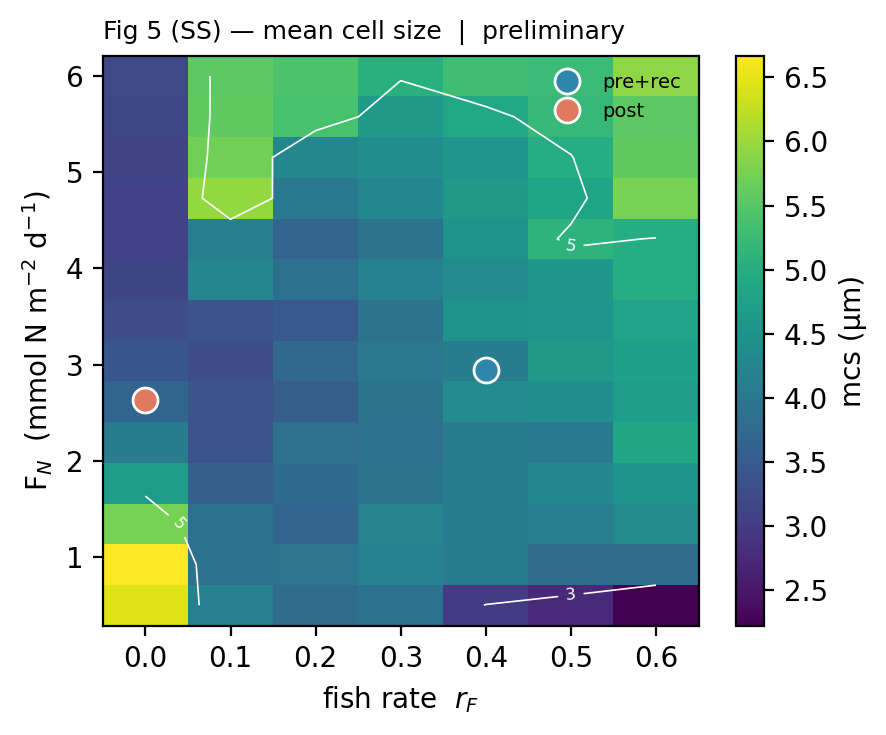


Monotonicity check:
  dMCS/dF_N > 0 in 54/91 edges (if mostly true → MCS rises with F_N)
  dMCS/dr_F > 0 in 58/84 edges (if mostly true → fish increases MCS)

Operating points (nearest grid):
  pre+rec ≈ (3.04, 0.40): MCS=4.05 µm  Micro=0.28  Z>200=0.025
  post     ≈ (2.62, 0.00): MCS=3.66 µm  Micro=0.26  Z>200=0.055
  pre/post MCS ratio: 1.11  (obs ≈ 7.66/3.28 = 2.33)


In [5]:
import numpy as np, matplotlib.pyplot as plt
import parscan_utils_extended as pue
from baseline_r0_setups import phyto_esd, zoo_esd

# --- derive MCS and the other surfaces from tail-averaged state ---
# dims in scan are (FishGrazing__rate, Inflow__FN, time=1, [phyto|zoo])
P = scan['Phytoplankton__biomass'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate', 'phyto').values
Z = scan['Zooplankton__biomass'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate', 'zoo').values
N = scan['Nutrient__value'].squeeze('time').transpose('Inflow__FN', 'FishGrazing__rate').values
nFN, nRF = P.shape[:2]

W    = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)

bins = np.einsum('kp,ijp->ijk', W, P)               # (nFN, nRF, 3 Sieburth bins)
sb   = bins.sum(-1)                                  # ΣP-binned per cell
fr   = np.where(sb[..., None] > 0, bins / sb[..., None], np.nan)
MCS  = 10 ** (fr @ np.log10(GEOM))                  # (nFN, nRF)
PICO, NANO, MICRO = fr[..., 0], fr[..., 1], fr[..., 2]
SUMP = P.sum(-1)
SUMZ = Z.sum(-1)
Z200 = Z[..., zoo_esd > 200].sum(-1)
Z500 = Z[..., zoo_esd > 500].sum(-1)

print("Derived surfaces  (nFN x nRF):")
print(f"  MCS    min={np.nanmin(MCS):.2f}  max={np.nanmax(MCS):.2f}  µm")
print(f"  ΣP     min={np.nanmin(SUMP):.2f}  max={np.nanmax(SUMP):.2f}  mmol N m⁻³")
print(f"  ΣZ     min={np.nanmin(SUMZ):.2f}  max={np.nanmax(SUMZ):.2f}  mmol N m⁻³")
print(f"  Micro  min={np.nanmin(MICRO):.2f}  max={np.nanmax(MICRO):.2f}")
print(f"  Z>200  min={np.nanmin(Z200):.4f}  max={np.nanmax(Z200):.4f}  mmol N m⁻³")
print(f"  Z>500  min={np.nanmin(Z500):.4e}  max={np.nanmax(Z500):.4e}  mmol N m⁻³")
print(f"  N      min={np.nanmin(N):.2f}    max={np.nanmax(N):.2f}    mmol N m⁻³")

# --- quick-look MCS pcolormesh ---
fig, ax = plt.subplots(figsize=(4.6, 3.8))
pc = ax.pcolormesh(RF_VALUES, FN_VALUES, MCS, shading='nearest', cmap='viridis')
cs = ax.contour(RF_VALUES, FN_VALUES, MCS, levels=[2, 3, 5, 8, 12, 20],
                colors='white', linewidths=0.6)
ax.clabel(cs, fontsize=6, fmt='%g')
ax.plot(0.4, 2.94, 'o', ms=9, color='#2E86AB', mec='white', label='pre+rec')
ax.plot(0.0, 2.63, 'o', ms=9, color='#E07A5F', mec='white', label='post')
ax.set_xlabel('fish rate  $r_F$')
ax.set_ylabel(r'F$_N$  (mmol N m$^{-2}$ d$^{-1}$)')
ax.set_title('Fig 5 (SS) — mean cell size  |  preliminary', fontsize=9, loc='left')
fig.colorbar(pc, label='mcs (µm)')
ax.legend(fontsize=7, frameon=False, loc='upper right')
fig.tight_layout(); plt.show()

# --- sanity-check: monotonic in F_N? in r_F? cross-term curvature? ---
def _slope(arr, axis):
    return np.diff(arr, axis=axis)
dFN = _slope(MCS, axis=0)        # MCS change as F_N rises (along rows)
drF = _slope(MCS, axis=1)        # MCS change as r_F rises (along cols)
print(f"\nMonotonicity check:")
print(f"  dMCS/dF_N > 0 in {int(np.sum(dFN > 0))}/{dFN.size} edges "
      f"(if mostly true → MCS rises with F_N)")
print(f"  dMCS/dr_F > 0 in {int(np.sum(drF > 0))}/{drF.size} edges "
      f"(if mostly true → fish increases MCS)")
print(f"\nOperating points (nearest grid):")
i_pre, j_pre = int(np.argmin(np.abs(FN_VALUES - 2.94))), int(np.argmin(np.abs(RF_VALUES - 0.4)))
i_pos, j_pos = int(np.argmin(np.abs(FN_VALUES - 2.63))), int(np.argmin(np.abs(RF_VALUES - 0.0)))
print(f"  pre+rec ≈ ({FN_VALUES[i_pre]:.2f}, {RF_VALUES[j_pre]:.2f}): "
      f"MCS={MCS[i_pre,j_pre]:.2f} µm  Micro={MICRO[i_pre,j_pre]:.2f}  "
      f"Z>200={Z200[i_pre,j_pre]:.3f}")
print(f"  post     ≈ ({FN_VALUES[i_pos]:.2f}, {RF_VALUES[j_pos]:.2f}): "
      f"MCS={MCS[i_pos,j_pos]:.2f} µm  Micro={MICRO[i_pos,j_pos]:.2f}  "
      f"Z>200={Z200[i_pos,j_pos]:.3f}")
print(f"  pre/post MCS ratio: {MCS[i_pre,j_pre]/MCS[i_pos,j_pos]:.2f}  "
      f"(obs ≈ 7.66/3.28 = 2.33)")

In [6]:
import time as _t, numpy as np
from xso.parscans import run_xso_parscan

t0 = _t.perf_counter()
scan_loose = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',          # <-- default IVP_SOLVER_KWARGS
    param_name='Inflow__FN',         param_values=FN_VALUES,
    param_name2='FishGrazing__rate', param_values2=RF_VALUES,
    fixed_overrides=fixed,                            # reuse the same dict
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall (loose): {(_t.perf_counter()-t0)/60:.1f} min   "
      f"(tight was 4.6 min)\n")

# --- side-by-side: which cells differ? ---
P_loose = scan_loose['Phytoplankton__biomass'].squeeze('time').transpose(
    'Inflow__FN', 'FishGrazing__rate', 'phyto').values
nan_loose  = scan_loose['tail_has_nan'].transpose('Inflow__FN', 'FishGrazing__rate').values
nan_tight  = scan['tail_has_nan'].transpose('Inflow__FN', 'FishGrazing__rate').values
cv_loose   = scan_loose['cv_sumP'].transpose('Inflow__FN', 'FishGrazing__rate').values
cv_tight   = scan['cv_sumP'].transpose('Inflow__FN', 'FishGrazing__rate').values

print("Trip count (tail_has_nan = True):")
print(f"  loose: {int(np.sum(nan_loose != 0))} / {nan_loose.size}")
print(f"  tight: {int(np.sum(nan_tight != 0))} / {nan_tight.size}")
print(f"\ncv_sumP (realised stability):")
print(f"  loose: max={np.nanmax(cv_loose):.4f}  >0.10 in {int(np.sum(cv_loose > 0.10))} cells")
print(f"  tight: max={np.nanmax(cv_tight):.4f}  >0.10 in {int(np.sum(cv_tight > 0.10))} cells")

# Compute MCS on both for direct comparison
W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
def _mcs(P):
    b = np.einsum('kp,ijp->ijk', W, P); s = b.sum(-1)
    f = np.where(s[..., None] > 0, b / s[..., None], np.nan)
    return 10 ** (f @ np.log10(GEOM))

MCS_loose = _mcs(P_loose)
MCS_tight = _mcs(P)        # P from the previous (tight) scan, still in scope
diff = MCS_loose - MCS_tight
print(f"\nMCS_loose vs MCS_tight:")
print(f"  |Δ| max  = {np.nanmax(np.abs(diff)):.4f} µm")
print(f"  |Δ| mean = {np.nanmean(np.abs(diff)):.4f} µm")
print(f"  cells with |Δ| > 0.05 µm: {int(np.nansum(np.abs(diff) > 0.05))} / {diff.size}")
print(f"\nTrip cells in loose (i, j, F_N, r_F):")
trips_ij = np.argwhere(nan_loose != 0)
for i, j in trips_ij:
    print(f"  ({i:2d}, {j}) | F_N={FN_VALUES[i]:.2f}  r_F={RF_VALUES[j]:.2f}")

PROGRESS: Completed 14/14 outer points. (Inflow__FN = 6.0).

2D Scan complete. Total Time taken: 57.92632 seconds.

wall (loose): 1.0 min   (tight was 4.6 min)

Trip count (tail_has_nan = True):
  loose: 14 / 98
  tight: 0 / 98

cv_sumP (realised stability):
  loose: max=0.0215  >0.10 in 0 cells
  tight: max=0.0216  >0.10 in 0 cells

MCS_loose vs MCS_tight:
  |Δ| max  = 0.2284 µm
  |Δ| mean = 0.0074 µm
  cells with |Δ| > 0.05 µm: 2 / 98

Trip cells in loose (i, j, F_N, r_F):
  ( 6, 4) | F_N=3.04  r_F=0.40
  ( 7, 4) | F_N=3.46  r_F=0.40
  ( 7, 5) | F_N=3.46  r_F=0.50
  ( 8, 5) | F_N=3.88  r_F=0.50
  ( 8, 6) | F_N=3.88  r_F=0.60
  ( 9, 5) | F_N=4.31  r_F=0.50
  ( 9, 6) | F_N=4.31  r_F=0.60
  (10, 5) | F_N=4.73  r_F=0.50
  (10, 6) | F_N=4.73  r_F=0.60
  (11, 5) | F_N=5.15  r_F=0.50
  (11, 6) | F_N=5.15  r_F=0.60
  (12, 5) | F_N=5.58  r_F=0.50
  (12, 6) | F_N=5.58  r_F=0.60
  (13, 6) | F_N=6.00  r_F=0.60


In [7]:
import warnings, numpy as np, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
warnings.filterwarnings('ignore', message='Instability event')
warnings.filterwarnings('ignore', message='solve_ivp')   # nfev projections

base = ssh.build_forcings(['pre+recovery'])['pre+recovery']
spec = ssh.allometry('maranon_ward')
GRZ  = {'KsZ': 0.23, 'sigma_log': 0.2}
IVO  = {'GrazingRouter': {'gge': 0.31}}

# TIGHT solver_kwargs (mirror what worked at SS); default neg floor (-1e-3)
SK_TIGHT = {'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-6,
            'max_step': 1.0, 'instability_neg_threshold': -1e-3}

FN_SCALE = np.linspace(0.4, 1.7, 7)
R_F      = np.linspace(0.0, 0.6, 7)
combos = [(fs, rf) for fs in FN_SCALE for rf in R_F]
tasks  = [(dict(construct=spec, forcing={**base, 'fn': base['fn'] * fs}, fish_rate=float(rf),
                years=40, spinup=10, mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                solver_kwargs=SK_TIGHT),) for fs, rf in combos]

MCS = np.full((len(FN_SCALE), len(R_F)), np.nan)
CONV = MCS.copy(); MINP = MCS.copy(); MINZ = MCS.copy(); CVSP = MCS.copy()
TRIPLOC_T = {}
def on_result(item, done, n):
    k = item['index']; i, j = divmod(k, len(R_F))
    if not item['ok']:
        return
    m = item['result']
    MCS[i,j]  = m.get('mcs_med', np.nan)
    CONV[i,j] = m.get('mcs_conv', np.nan)
    MINP[i,j] = m.get('minP', np.nan)
    MINZ[i,j] = m.get('minZ', np.nan)
    CVSP[i,j] = m.get('cv_sumP', np.nan)
    if m.get('has_nan'):
        fs, rf = combos[k]
        TRIPLOC_T[(i, j)] = (float(fs), float(rf), float(m.get('nan_frac', np.nan)))

run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None,
                   on_result=on_result, tally_flags=['has_nan'], label='fig5_seasonal_tight')

# --- diagnostics ---
n_trip = len(TRIPLOC_T)
n_tot  = MCS.size
print(f"\n--- TIGHT seasonal: trips {n_trip}/{n_tot}  (loose baseline was 21/49) ---\n")
if TRIPLOC_T:
    print("Trip cells still firing under tight tols:")
    for (i, j), (fs, rf, frac) in sorted(TRIPLOC_T.items(), key=lambda kv: (kv[1][0], kv[1][1])):
        print(f"  ({i:2d}, {j}) | F_N×{fs:.3f} (mean {base['fn'].mean()*fs:.2f}) "
              f"| r_F={rf:.2f} | nan_frac={frac:.2f}")
else:
    print("All cells completed without NaN-termination.")

# Stability picture of the converged cells
print(f"\ncv_sumP: max={np.nanmax(CVSP):.3f}  >0.10 in {int(np.nansum(CVSP > 0.10))} cells")
print(f"|conv-1|: max={np.nanmax(np.abs(CONV-1)):.3f}  >0.05 in {int(np.nansum(np.abs(CONV-1) > 0.05))} cells")
print(f"minP: min={np.nanmin(MINP):+.2e}  ({int(np.nansum(MINP < -1e-3))} cells < -1e-3)")
print(f"minZ: min={np.nanmin(MINZ):+.2e}  ({int(np.nansum(MINZ < -1e-3))} cells < -1e-3)")

--- run_parallel_tasks: 49 tasks, 7 workers (fig5_seasonal_tight) ---
   1/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.8m ETA 40.4m
   2/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 20.2m
   3/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 13.6m
   4/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 10.0m
   5/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 7.8m
   6/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 6.4m
   7/49 fig5_seasonal_tight | err=0 has_nan=0 | 0.9m ETA 5.3m
   8/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.6m ETA 8.4m
   9/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 7.4m
  10/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 6.5m
  11/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 5.7m
  12/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 5.2m
  13/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.7m ETA 4.7m
  14/49 fig5_seasonal_tight | err=0 has_nan=0 | 1.9m ETA 4.8m
  15/49 fig5_seasonal_tight | err=0 has_nan=0 | 2.4m ETA 5

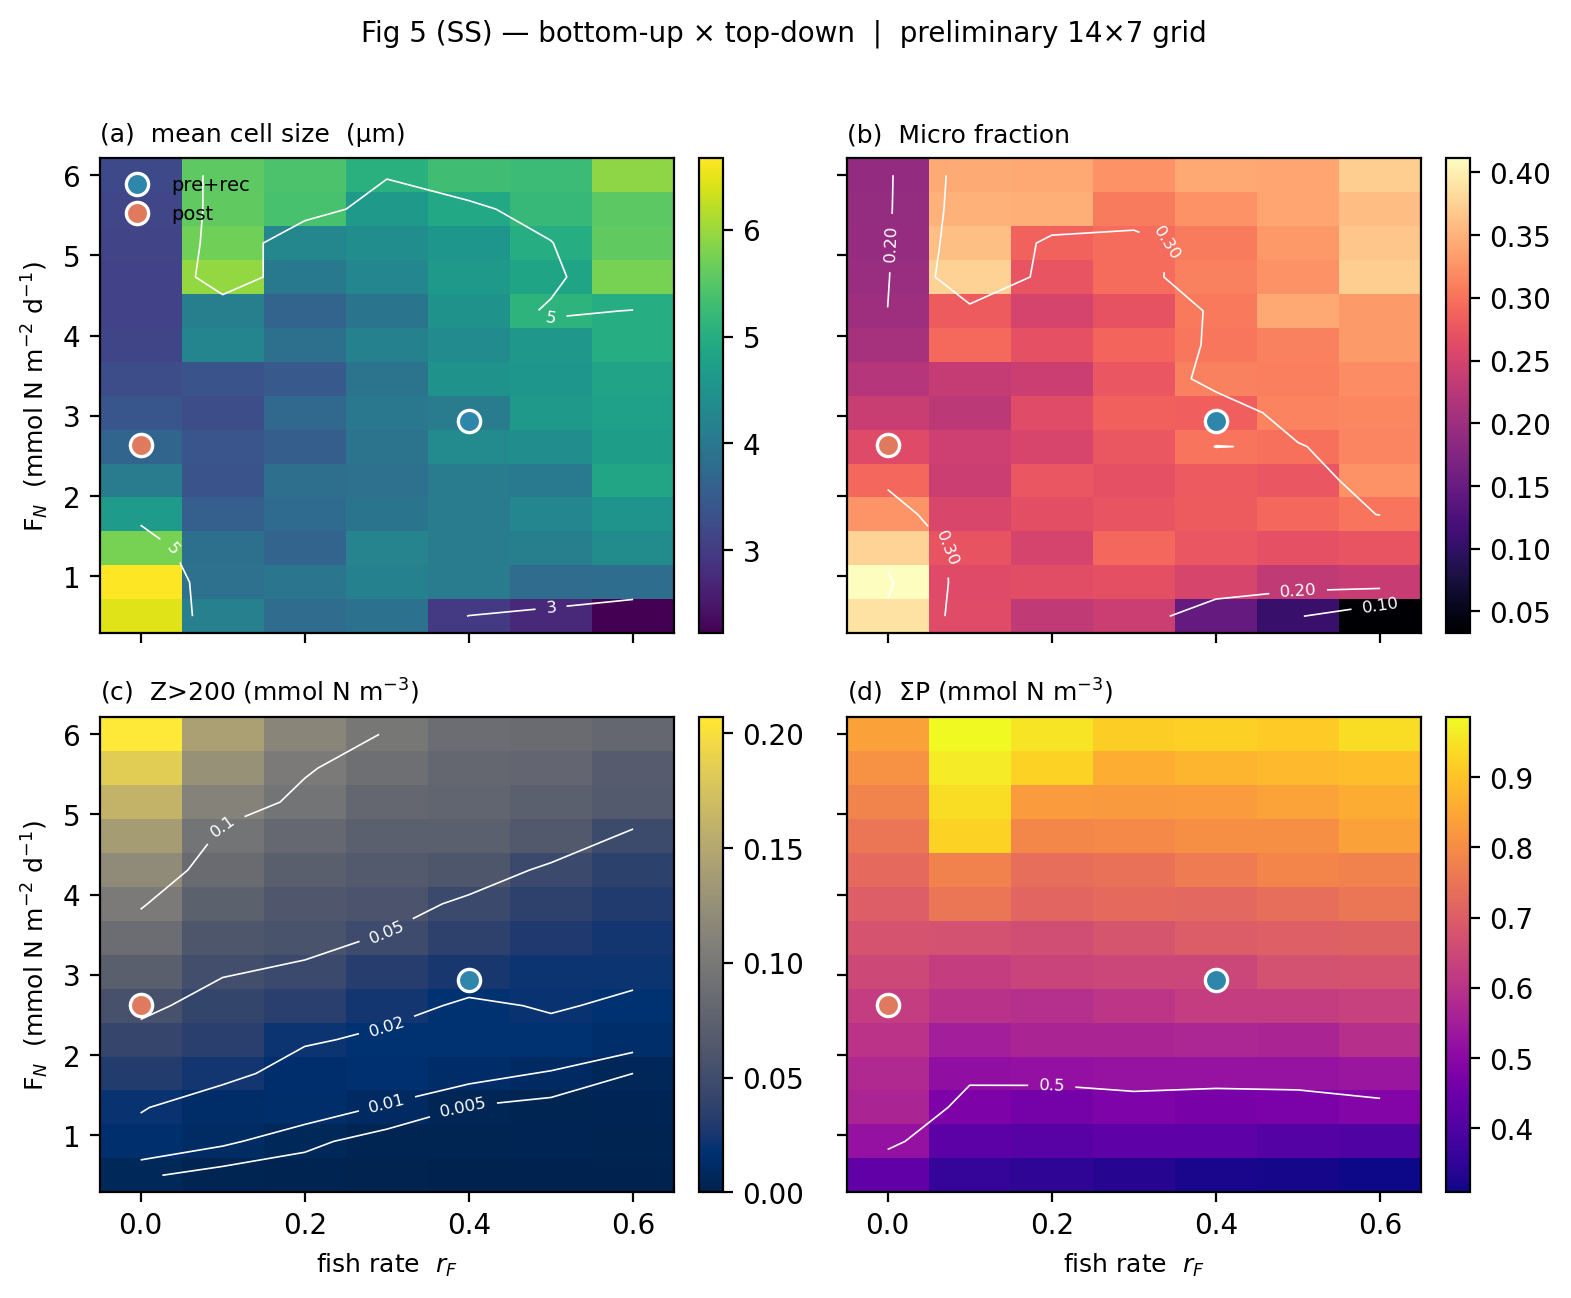

Operating points (nearest grid):
  pre+rec  ≈ (F_N=3.04, r_F=0.40): MCS=4.05 µm  Micro=0.28  Z>200=0.025  ΣP=0.65
  post     ≈ (F_N=2.62, r_F=0.00): MCS=3.66 µm  Micro=0.26  Z>200=0.055  ΣP=0.63

Monotonicity (positive-slope edge count):
  MCS   : dF_N>0 in  54/ 91  |  dr_F>0 in  58/ 84
  Micro : dF_N>0 in  52/ 91  |  dr_F>0 in  53/ 84
  Z>200 : dF_N>0 in  90/ 91  |  dr_F>0 in   9/ 84
  ΣP    : dF_N>0 in  91/ 91  |  dr_F>0 in  48/ 84


In [9]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
import parscan_utils_extended as pue
from baseline_r0_setups import phyto_esd, zoo_esd
from matplotlib.colors import LogNorm

# --- derive surfaces from the existing `scan` (tight SS) ---
P = scan['Phytoplankton__biomass'].squeeze('time').transpose('Inflow__FN','FishGrazing__rate','phyto').values
Z = scan['Zooplankton__biomass'].squeeze('time').transpose('Inflow__FN','FishGrazing__rate','zoo').values
N = scan['Nutrient__value'].squeeze('time').transpose('Inflow__FN','FishGrazing__rate').values
W = pue.compute_sieburth_weights(phyto_esd)
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
bins = np.einsum('kp,ijp->ijk', W, P); sb = bins.sum(-1)
fr = np.where(sb[...,None]>0, bins/sb[...,None], np.nan)
MCS   = 10**(fr @ np.log10(GEOM))
MICRO = fr[...,2]
SUMP  = P.sum(-1); SUMZ = Z.sum(-1)
Z200  = Z[..., zoo_esd>200].sum(-1)

OPS = [('pre+rec', 2.94, 0.4, '#2E86AB'), ('post', 2.63, 0.0, '#E07A5F')]

fig, axes = plt.subplots(2, 2, figsize=(8.0, 6.6), sharex=True, sharey=True)
panels = [
    ('(a)  mean cell size  (µm)',  MCS,  'viridis',  [2,3,5,8,12,20], '%g',  None),
    ('(b)  Micro fraction',        MICRO,'magma',    [0.1,0.2,0.3,0.4,0.5,0.6], '%.2f', None),
    ('(c)  Z>200 (mmol N m$^{-3}$)', Z200,'cividis', [0.005,0.01,0.02,0.05,0.1], '%.3g', None),
    ('(d)  ΣP (mmol N m$^{-3}$)',  SUMP, 'plasma',   [0.2,0.5,1.0,2.0,4.0],  '%.2g', None),
]
for ax, (title, surf, cmap, lvls, fmt, norm) in zip(axes.flat, panels):
    pc = ax.pcolormesh(RF_VALUES, FN_VALUES, surf, shading='nearest', cmap=cmap, norm=norm)
    cs = ax.contour(RF_VALUES, FN_VALUES, surf, levels=lvls, colors='white', linewidths=0.6)
    ax.clabel(cs, fontsize=6, fmt=fmt)
    for lbl, fn, rf, col in OPS:
        ax.plot(rf, fn, 'o', ms=8, color=col, mec='white', mew=1.2, label=lbl)
    ax.set_title(title, fontsize=9, loc='left')
    fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
axes[0,0].legend(fontsize=7, frameon=False, loc='upper left')
for ax in axes[1,:]: ax.set_xlabel('fish rate  $r_F$', fontsize=9)
for ax in axes[:,0]: ax.set_ylabel(r'F$_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=9)
fig.suptitle('Fig 5 (SS) — bottom-up × top-down  |  preliminary 14×7 grid', fontsize=10)
fig.tight_layout(rect=(0,0,1,0.97)); plt.show()

# --- read-off: operating-point numbers + monotonicity ---
print("Operating points (nearest grid):")
for lbl, fn, rf, _ in OPS:
    i, j = int(np.argmin(np.abs(FN_VALUES - fn))), int(np.argmin(np.abs(RF_VALUES - rf)))
    print(f"  {lbl:8s} ≈ (F_N={FN_VALUES[i]:.2f}, r_F={RF_VALUES[j]:.2f}): "
          f"MCS={MCS[i,j]:.2f} µm  Micro={MICRO[i,j]:.2f}  Z>200={Z200[i,j]:.3f}  ΣP={SUMP[i,j]:.2f}")
def _mono(a, ax): return int(np.sum(np.diff(a, axis=ax) > 0))
print(f"\nMonotonicity (positive-slope edge count):")
for name, surf in [('MCS', MCS), ('Micro', MICRO), ('Z>200', Z200), ('ΣP', SUMP)]:
    print(f"  {name:6s}: dF_N>0 in {_mono(surf,0):3d}/{(surf.shape[0]-1)*surf.shape[1]:3d}  |  "
          f"dr_F>0 in {_mono(surf,1):3d}/{surf.shape[0]*(surf.shape[1]-1):3d}")

In [3]:
import time as _t, numpy as np, os
from xso.parscans import run_xso_parscan
import seasonal_scan_harness as ssh

FN_HI = np.linspace(0.5, 6.0, 50)
RF_HI = np.linspace(0.0, 0.6, 50)
spec  = ssh.allometry('maranon_ward')
fixed_hi = {
    'Inflow__de': 50.0, 'Temperature__value': 20.0,
    'Growth__mu_max': spec['mu_max'], 'Growth__halfsat': spec['halfsat'],
    'PhytoMortality__rate': 0.0015, 'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ': 0.23, 'Grazing__sigma_log': 0.20, 'GrazingRouter__gge': 0.31,
}

t0 = _t.perf_counter()
scan_hi = run_xso_parscan(
    model_file_name='baseline_r0_setups', model_name='model_baseline',
    model_setup_name='setup_baseline_slim_tight',
    param_name='Inflow__FN',         param_values=FN_HI,
    param_name2='FishGrazing__rate', param_values2=RF_HI,
    fixed_overrides=fixed_hi,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,
)
print(f"\nwall: {(_t.perf_counter()-t0)/60:.1f} min")

# Save to netCDF — figure can be re-rendered from this without re-running
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_ss_scan_28x13_2026-06-24.nc')
# arrays in fixed_overrides are stored as object dtype in xarray; drop those
# from the saved dataset (they're recoverable from the construct spec, and
# netCDF doesn't serialize them cleanly)
to_save = scan_hi.drop_vars([v for v in scan_hi.data_vars
                              if scan_hi[v].dtype == object])
to_save.attrs.update(dict(
    construct='maranon_ward',
    GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
    de=50.0, T=20.0, forcing='SS, decoupled (T=T_REF, de=DE_DEFAULT)',
    solver='setup_baseline_slim_tight (atol=1e-9, rtol=1e-6, max_step=1.0)',
    created='2026-06-24',
))
to_save.to_netcdf(nc_path)
print(f"saved: {nc_path}  ({os.path.getsize(nc_path)/1e6:.1f} MB)")
print(f"  reload with: scan_hi = xarray.open_dataset('{nc_path}')")
print(f"  trips: {int(scan_hi['tail_has_nan'].sum().item())}/{scan_hi['tail_has_nan'].size}")
print(f"  cv_sumP max: {float(scan_hi['cv_sumP'].max().item()):.4f}")

PROGRESS: Completed 14/50 outer points. (Inflow__FN = 1.9591836734693877).


Process SpawnPoolWorker-6:
Process SpawnPoolWorker-7:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-5:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-3:


KeyboardInterrupt: 

In [11]:
import warnings, numpy as np, time as _t
import seasonal_scan_harness as ssh
warnings.filterwarnings('ignore', message='Instability event')

# pick the cell that was running hardest under RK45-tight
i_hi, j_hi = np.unravel_index(np.nanargmax(CVSP), CVSP.shape)
fs_hi, rf_hi = float(FN_SCALE[i_hi]), float(R_F[j_hi])
mean_fn_hi = base['fn'].mean() * fs_hi
mcs_rk45 = MCS[i_hi, j_hi]; cv_rk45 = CVSP[i_hi, j_hi]; conv_rk45 = CONV[i_hi, j_hi]
print(f"Target cell (max cv_sumP under RK45-tight):")
print(f"  (i, j) = ({i_hi}, {j_hi})  | F_N×{fs_hi:.3f} (mean {mean_fn_hi:.2f})  r_F={rf_hi:.2f}")
print(f"  RK45-tight: mcs_med={mcs_rk45:.3f} µm  cv_sumP={cv_rk45:.3f}  conv={conv_rk45:.4f}\n")

SK_DOP = {'method': 'DOP853', 'atol': 1e-9, 'rtol': 1e-6,
          'max_step': 1.0, 'instability_neg_threshold': -1e-3}
spec = ssh.allometry('maranon_ward')
GRZ, IVO = {'KsZ': 0.23, 'sigma_log': 0.2}, {'GrazingRouter': {'gge': 0.31}}

t0 = _t.perf_counter()
clim_dop = ssh.run_one(construct=spec,
                       forcing={**base, 'fn': base['fn'] * fs_hi},
                       fish_rate=rf_hi, years=40, spinup=10,
                       mP=0.0015, m_Z=0.1, grazing=GRZ, iv_overrides=IVO,
                       solver_kwargs=SK_DOP)
wall = _t.perf_counter() - t0
print(f"DOP853 wall: {wall:.1f} s\n")

mcs_dop  = clim_dop.get('mcs_med', np.nan)
cv_dop   = clim_dop.get('cv_sumP', np.nan)
conv_dop = clim_dop.get('mcs_conv', np.nan)
minP_dop = clim_dop.get('minP', np.nan)
print(f"DOP853:    mcs_med={mcs_dop:.3f} µm  cv_sumP={cv_dop:.3f}  conv={conv_dop:.4f}  "
      f"has_nan={clim_dop.get('has_nan')}  minP={minP_dop:+.2e}")
print(f"\nΔ vs RK45-tight:")
print(f"  Δmcs    = {mcs_dop - mcs_rk45:+.4f} µm  ({abs(mcs_dop-mcs_rk45)/max(mcs_rk45,1e-12)*100:.2f} %)")
print(f"  Δcv_sumP = {cv_dop - cv_rk45:+.4f}   ({abs(cv_dop-cv_rk45)/max(cv_rk45,1e-12)*100:.2f} %)")
print(f"  Δconv   = {conv_dop - conv_rk45:+.4f}")

Target cell (max cv_sumP under RK45-tight):
  (i, j) = (6, 2)  | F_N×1.700 (mean 5.22)  r_F=0.20
  RK45-tight: mcs_med=3.704 µm  cv_sumP=1.380  conv=0.8656

DOP853 wall: 67.0 s

DOP853:    mcs_med=nan µm  cv_sumP=nan  conv=nan  has_nan=True  minP=+nan

Δ vs RK45-tight:
  Δmcs    = +nan µm  (nan %)
  Δcv_sumP = +nan   (nan %)
  Δconv   = +nan


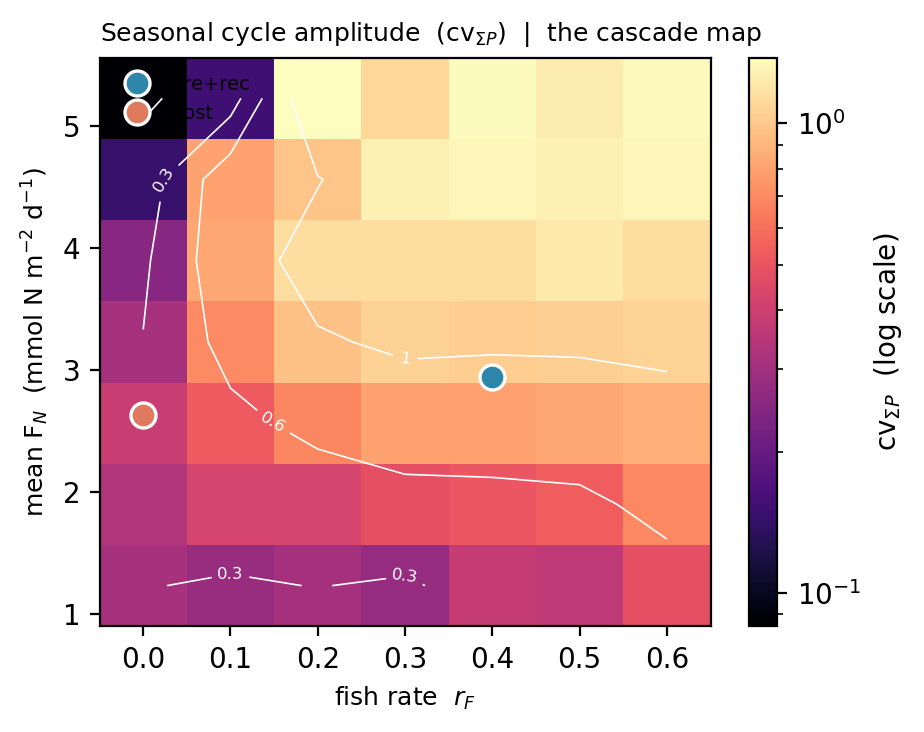

cv_sumP at the era operating points (nearest grid):
  pre+rec  ≈ (F_N=3.23, r_F=0.40): cv_sumP=1.038  mcs_med=4.07 µm
  post     ≈ (F_N=2.56, r_F=0.00): cv_sumP=0.390  mcs_med=5.75 µm

cv_sumP range across the plane: 0.085 – 1.380
highest-cv cell: (F_N=5.22, r_F=0.20)  cv=1.380

Correlation of cv_sumP with mcs_med across the plane:


ValueError: operands could not be broadcast together with shapes (7,7) (14,7) 

In [12]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mean_FN = base['fn'].mean() * FN_SCALE

fig, ax = plt.subplots(figsize=(4.8, 3.8))
pc = ax.pcolormesh(R_F, mean_FN, CVSP, shading='nearest', cmap='magma',
                   norm=LogNorm(vmin=max(np.nanmin(CVSP), 1e-3), vmax=np.nanmax(CVSP)))
cs = ax.contour(R_F, mean_FN, CVSP, levels=[0.05, 0.1, 0.3, 0.6, 1.0],
                colors='white', linewidths=0.6)
ax.clabel(cs, fontsize=6, fmt='%.2g')

# era operating points
ax.plot(0.4, 2.94, 'o', ms=9, color='#2E86AB', mec='white', mew=1.2, label='pre+rec')
ax.plot(0.0, 2.63, 'o', ms=9, color='#E07A5F', mec='white', mew=1.2, label='post')

ax.set_xlabel('fish rate  $r_F$', fontsize=9)
ax.set_ylabel(r'mean F$_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=9)
ax.set_title('Seasonal cycle amplitude  (cv$_{\\Sigma P}$)  |  the cascade map',
             fontsize=9, loc='left')
ax.legend(fontsize=7, frameon=False, loc='upper left')
cb = fig.colorbar(pc, label=r'cv$_{\Sigma P}$  (log scale)')
fig.tight_layout(); plt.show()

# numerical read-off
print("cv_sumP at the era operating points (nearest grid):")
for lbl, fn, rf in [('pre+rec', 2.94, 0.4), ('post', 2.63, 0.0)]:
    i = int(np.argmin(np.abs(mean_FN - fn)))
    j = int(np.argmin(np.abs(R_F - rf)))
    print(f"  {lbl:8s} ≈ (F_N={mean_FN[i]:.2f}, r_F={R_F[j]:.2f}): "
          f"cv_sumP={CVSP[i,j]:.3f}  mcs_med={MCS[i,j]:.2f} µm")
print(f"\ncv_sumP range across the plane: {np.nanmin(CVSP):.3f} – {np.nanmax(CVSP):.3f}")
print(f"highest-cv cell: (F_N={mean_FN[i_hi]:.2f}, r_F={R_F[j_hi]:.2f})  cv={CVSP[i_hi,j_hi]:.3f}")
print(f"\nCorrelation of cv_sumP with mcs_med across the plane:")
ok = np.isfinite(CVSP) & np.isfinite(MCS)
r = np.corrcoef(CVSP[ok], MCS[ok])[0,1]
print(f"  r = {r:+.3f}  (positive → bigger cycles ↔ bigger time-mean cells, the cascade-as-amplitude reading)")

Marañón peak: P[19] s = 5.79 µm (μ_max = 0.830 d⁻¹)

default    wall 47.6s  reached t = 19995 d
all-Pico   wall 49.8s  reached t = 19995 d
all-peak   wall 48.0s  reached t = 19995 d


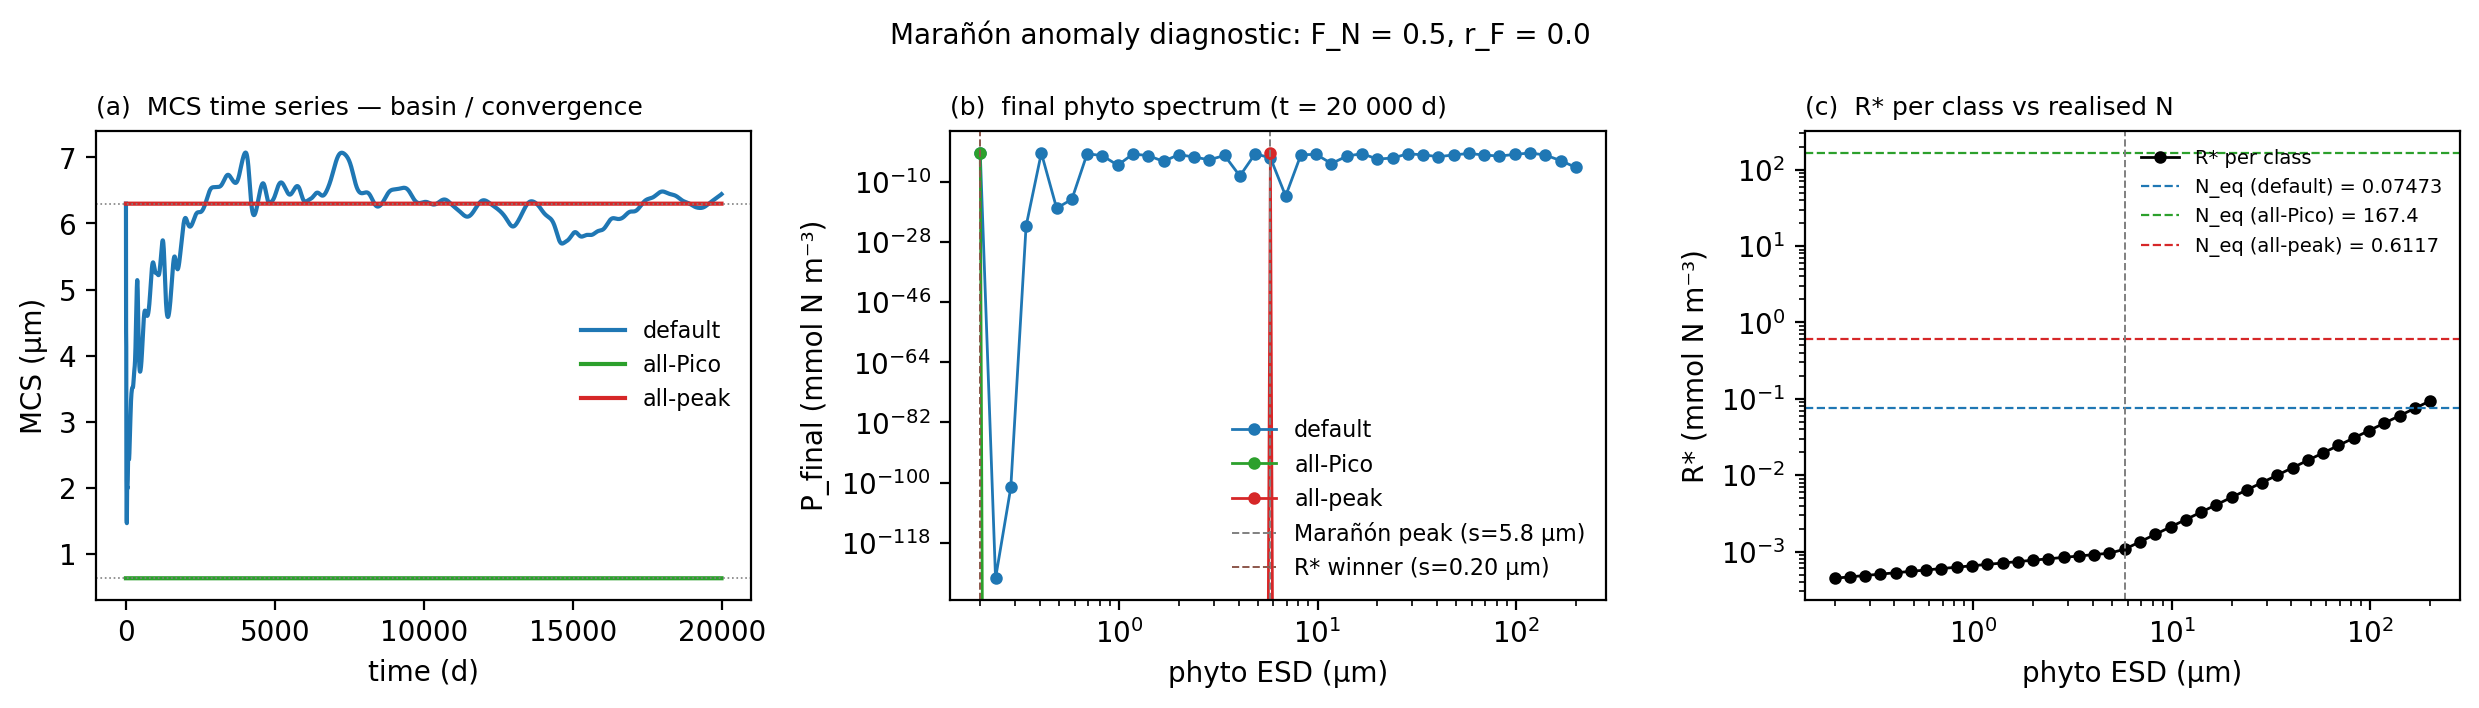


Theoretical R* winner: P[0]  s = 0.20 µm  R* = 4.4682e-04
R* at Marañón peak  P[19]: 1.0730e-03

default   : MCS_final =  6.44 µm  |  dominant = P[0] s= 0.20 µm  |  P_dom = 0.0518  |  N_eq = 0.0747
all-Pico  : MCS_final =  0.63 µm  |  dominant = P[0] s= 0.20 µm  |  P_dom = 0.0305  |  N_eq = 167.4273
all-peak  : MCS_final =  6.30 µm  |  dominant = P[19] s= 5.79 µm  |  P_dom = 0.0571  |  N_eq = 0.6117

--- verdict ---
MCS spread across ICs = 5.81 µm → MULTIPLE BASINS confirmed.
→ The (F_N=0.5, r_F=0) cell has at least two attractors; default IC
  lands in the peak-class basin; tiny r_F flips it. Manuscript-relevant.


In [13]:
%config InlineBackend.figure_format = 'retina'
import time as _t
import numpy as np, matplotlib.pyplot as plt
import xso
import parscan_utils_extended as pue
import seasonal_scan_harness as ssh
from baseline_r0_setups import (
    model_baseline, make_baseline_input_vars, SLIM_OUTPUT_VARS,
    phyto_esd, phyto_init,
)

# --- anomaly cell: lowest F_N + zero fish ---
FN0, RF0, DE0, T0 = 0.5, 0.0, 50.0, 20.0
spec = ssh.allometry('maranon_ward')
mu_max_arr, ks_arr = spec['mu_max'], spec['halfsat']
P_total_init = float(np.sum(phyto_init))
i_peak = int(np.argmax(mu_max_arr))   # Marañón peak class
print(f"Marañón peak: P[{i_peak}] s = {phyto_esd[i_peak]:.2f} µm "
      f"(μ_max = {mu_max_arr[i_peak]:.3f} d⁻¹)\n")

# --- three initial conditions ---
ic_default = phyto_init.copy()
ic_all_pico = np.zeros_like(phyto_init); ic_all_pico[0]     = P_total_init
ic_all_peak = np.zeros_like(phyto_init); ic_all_peak[i_peak] = P_total_init
ic_variants = {'default':   ic_default,
               'all-Pico':  ic_all_pico,
               'all-peak':  ic_all_peak}

# --- long IVP, 20000 d, tight tols, coarsened t_eval (5-d) ---
T_END   = 20000.0
time_ax = np.arange(0.0, T_END, 5.0)
SK = {'method': 'RK45', 'atol': 1e-9, 'rtol': 1e-6,
      'max_step': 1.0, 'instability_neg_threshold': -1e-3}

results = {}
for label, ic in ic_variants.items():
    iv = make_baseline_input_vars(
        fish_rate=RF0, FN=FN0, de=DE0, T=T0,
        mu_max=mu_max_arr, halfsat=ks_arr, mP=0.0015, m_Z=0.1,
    )
    iv['Phytoplankton']['biomass_init'] = ic
    iv['Grazing']['KsZ']       = 0.23
    iv['Grazing']['sigma_log'] = 0.20
    iv['GrazingRouter']['gge'] = 0.31
    setup = xso.setup(solver='solve_ivp', model=model_baseline, time=time_ax,
                      input_vars=iv, output_vars=SLIM_OUTPUT_VARS, solver_kwargs=SK)
    t0 = _t.perf_counter()
    out = pue.run_single_point(model_baseline, setup, {})
    print(f"{label:10s} wall {_t.perf_counter()-t0:.1f}s  "
          f"reached t = {out['time'].values[-1]:.0f} d")
    results[label] = out

# --- derived series ---
GEOM = np.asarray(pue.CARIACO_PHYTO_BIN_GEOMEANS, float)
W    = pue.compute_sieburth_weights(phyto_esd)

# --- theoretical R* per class (at T_REF, Q10 factor = 1) ---
mP = 0.0015
R_star = mP * ks_arr / np.maximum(mu_max_arr - mP, 1e-12)
i_R_winner = int(np.argmin(R_star))

# --- 3-panel diagnostic plot ---
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
colors = {'default': 'C0', 'all-Pico': 'C2', 'all-peak': 'C3'}

for label, out in results.items():
    P = out['Phytoplankton__biomass'].transpose('phyto', 'time').values
    t = out['time'].values
    bins = W @ P; sb = bins.sum(0)
    fr = np.divide(bins, sb, out=np.full_like(bins, np.nan), where=sb > 0)
    mcs = 10 ** (np.log10(GEOM) @ fr)
    axes[0].plot(t, mcs, lw=1.5, color=colors[label], label=label)
    # final spectrum
    axes[1].plot(phyto_esd, P[:, -1], 'o-', ms=3.5, lw=1.0,
                 color=colors[label], label=label)

axes[0].set_xlabel('time (d)'); axes[0].set_ylabel('MCS (µm)')
axes[0].set_title('(a)  MCS time series — basin / convergence', fontsize=9, loc='left')
axes[0].axhline(0.63, color='0.5', ls=':', lw=0.6); axes[0].axhline(6.3, color='0.5', ls=':', lw=0.6)
axes[0].legend(fontsize=8, frameon=False)

axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('phyto ESD (µm)'); axes[1].set_ylabel('P_final (mmol N m⁻³)')
axes[1].set_title('(b)  final phyto spectrum (t = 20 000 d)', fontsize=9, loc='left')
axes[1].axvline(phyto_esd[i_peak], color='0.5', ls='--', lw=0.7,
                label=f'Marañón peak (s={phyto_esd[i_peak]:.1f} µm)')
axes[1].axvline(phyto_esd[i_R_winner], color='C5', ls='--', lw=0.7,
                label=f'R* winner (s={phyto_esd[i_R_winner]:.2f} µm)')
axes[1].legend(fontsize=8, frameon=False)

axes[2].plot(phyto_esd, R_star, 'o-', ms=3.5, lw=1.0, color='k', label='R* per class')
for label, out in results.items():
    N_eq = float(out['Nutrient__value'].values[-1])
    axes[2].axhline(N_eq, color=colors[label], ls='--', lw=0.8,
                    label=f'N_eq ({label}) = {N_eq:.4g}')
axes[2].set_xscale('log'); axes[2].set_yscale('log')
axes[2].set_xlabel('phyto ESD (µm)'); axes[2].set_ylabel('R* (mmol N m⁻³)')
axes[2].set_title('(c)  R* per class vs realised N', fontsize=9, loc='left')
axes[2].axvline(phyto_esd[i_peak], color='0.5', ls='--', lw=0.7)
axes[2].legend(fontsize=7, frameon=False)

fig.suptitle(f'Marañón anomaly diagnostic: F_N = {FN0}, r_F = {RF0}', fontsize=10)
fig.tight_layout(); plt.show()

# --- numeric read-off + verdict ---
print(f"\nTheoretical R* winner: P[{i_R_winner}]  s = {phyto_esd[i_R_winner]:.2f} µm  "
      f"R* = {R_star[i_R_winner]:.4e}")
print(f"R* at Marañón peak  P[{i_peak}]: {R_star[i_peak]:.4e}\n")
mcs_finals = {}
for label, out in results.items():
    P_final = out['Phytoplankton__biomass'].transpose('phyto', 'time').values[:, -1]
    N_eq    = float(out['Nutrient__value'].values[-1])
    i_dom   = int(np.argmax(P_final))
    bins    = W @ P_final.reshape(-1, 1)
    fr      = bins / max(bins.sum(), 1e-12)
    mcs_f   = float(10 ** (np.log10(GEOM) @ fr.flatten()))
    mcs_finals[label] = mcs_f
    print(f"{label:10s}: MCS_final = {mcs_f:5.2f} µm  |  dominant = P[{i_dom}] "
          f"s={phyto_esd[i_dom]:5.2f} µm  |  P_dom = {P_final[i_dom]:.4f}  |  N_eq = {N_eq:.4f}")

print("\n--- verdict ---")
spread = max(mcs_finals.values()) - min(mcs_finals.values())
if spread > 0.5:
    print(f"MCS spread across ICs = {spread:.2f} µm → MULTIPLE BASINS confirmed.")
    print("→ The (F_N=0.5, r_F=0) cell has at least two attractors; default IC")
    print("  lands in the peak-class basin; tiny r_F flips it. Manuscript-relevant.")
else:
    print(f"MCS spread across ICs = {spread:.2f} µm → SINGLE ATTRACTOR.")
    print("→ All ICs converge to the same state. Either Marañón unimodal μ truly")
    print("  selects the peak class at low N (check whether realised N stays above")
    print("  the R*-winner's break-even on (c)), or 20000 d is still too short.")

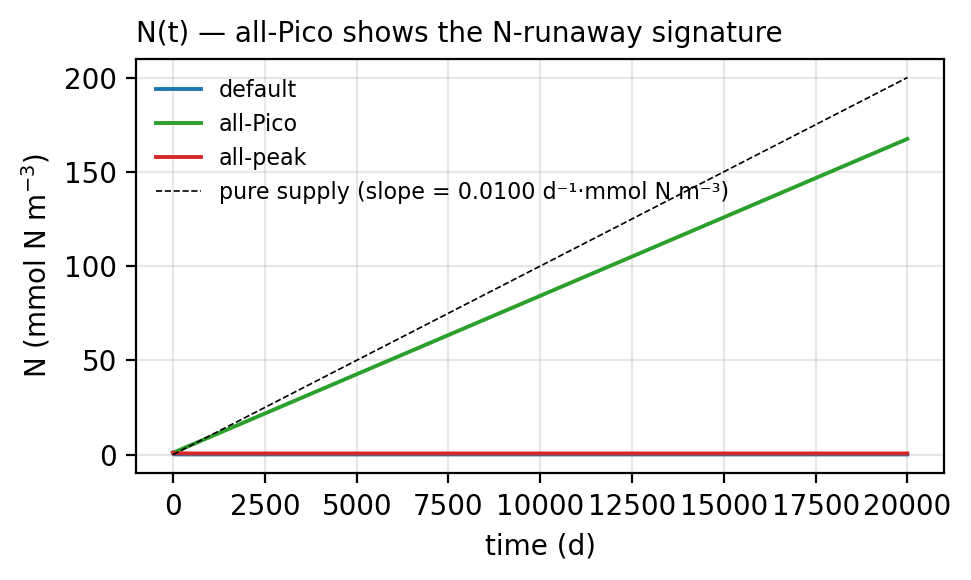

N final values: default=0.075, all-Pico=167.427, all-peak=0.612
Pure-supply N(t=20000) would be: 200.000


In [14]:
fig, ax = plt.subplots(figsize=(5, 3))
for label, out in results.items():
    ax.plot(out['time'].values, out['Nutrient__value'].values, lw=1.4,
            color={'default':'C0','all-Pico':'C2','all-peak':'C3'}[label], label=label)
ax.set_xlabel('time (d)'); ax.set_ylabel('N (mmol N m$^{-3}$)')
ax.set_title('N(t) — all-Pico shows the N-runaway signature', fontsize=10, loc='left')
# annotate the supply rate
supply = 0.5 / 50.0    # F_N / d_e
ax.plot([0, 20000], [0, supply*20000], 'k--', lw=0.6,
        label=f'pure supply (slope = {supply:.4f} d⁻¹·mmol N m⁻³)')
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"N final values: default={results['default']['Nutrient__value'].values[-1]:.3f}, "
      f"all-Pico={results['all-Pico']['Nutrient__value'].values[-1]:.3f}, "
      f"all-peak={results['all-peak']['Nutrient__value'].values[-1]:.3f}")
print(f"Pure-supply N(t=20000) would be: {supply*20000:.3f}")

In [ ]:
import time as _t, numpy as np, os
import xarray as xr
from xso.parscans import run_xso_parscan
import seasonal_scan_harness as ssh

# --- high-res axes; F_N extended down to 0.1 to capture low-N anomaly ---
FN_HI = np.linspace(0.1, 6.0, 50)
RF_HI = np.linspace(0.0, 0.6, 50)
print(f"axes: F_N {FN_HI[0]:.2f}–{FN_HI[-1]:.2f} (Δ={FN_HI[1]-FN_HI[0]:.3f}, n={len(FN_HI)})  |  "
      f"r_F {RF_HI[0]:.2f}–{RF_HI[-1]:.2f} (Δ={RF_HI[1]-RF_HI[0]:.4f}, n={len(RF_HI)})")
print(f"cells: {len(FN_HI)*len(RF_HI)} = 2500\n")

# --- construct overrides (same as the 14×7 preview + smoke test) ---
spec = ssh.allometry('maranon_ward')
fixed_hi = {
    'Inflow__de':             50.0,
    'Temperature__value':     20.0,
    'Growth__mu_max':         spec['mu_max'],
    'Growth__halfsat':        spec['halfsat'],
    'PhytoMortality__rate':   0.0015,
    'ZooQuadMortality__rate': 0.1,
    'Grazing__KsZ':           0.23,
    'Grazing__sigma_log':     0.20,
    'GrazingRouter__gge':     0.31,
}

# --- run ---
t0 = _t.perf_counter()
scan_hi = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim_tight',
    param_name='Inflow__FN',         param_values=FN_HI,
    param_name2='FishGrazing__rate', param_values2=RF_HI,
    fixed_overrides=fixed_hi,
    postprocess_name='avg_tail_stats',
    postprocess_kwargs={'avg_window': 1000},
    processes=7,        # Mac Studio: bump to physical core count if desired
)
wall = (_t.perf_counter() - t0) / 60
print(f"\nwall: {wall:.1f} min")

# --- summary ---
n_trip = int(scan_hi['tail_has_nan'].sum().item())
cv_max = float(scan_hi['cv_sumP'].max().item())
n_size = int(scan_hi['cv_sumP'].size)
print(f"trips: {n_trip}/{n_size}  |  cv_sumP max: {cv_max:.4f}  "
      f"(>0.10 in {int((scan_hi['cv_sumP'] > 0.10).sum().item())} cells)")

# --- save to netCDF; drop object-dtype vars (the constant arrays from fixed_overrides) ---
out_dir = 'results'; os.makedirs(out_dir, exist_ok=True)
nc_path = os.path.join(out_dir, 'fig5_ss_scan_50x50_2026-06-24.nc')
to_save = scan_hi.drop_vars([v for v in scan_hi.data_vars if scan_hi[v].dtype == object])
to_save.attrs.update(dict(
    construct='maranon_ward',
    GGE=0.31, mP=0.0015, m_Z=0.1, KsZ=0.23, sigma_log=0.2,
    de=50.0, T=20.0,
    forcing='SS, decoupled (T = T_REF = 20°C → Q10 factor = 1; de = 50 m)',
    solver='setup_baseline_slim_tight (RK45, atol=1e-9, rtol=1e-6, max_step=1.0)',
    FN_range='linear 0.1–6.0, 50 pts (extended down to 0.1 to portrait low-N anomaly)',
    rF_range='linear 0.0–0.6, 50 pts',
    created='2026-06-24',
    notes='2500-cell SS map for Fig 5; see project_solver_tolerances.md and the '
          '"Cycle-Boundary Approach" entry in Ideas and Findings.md for the solver '
          'and dynamical-regime context.',
))
to_save.to_netcdf(nc_path)
size_mb = os.path.getsize(nc_path) / 1e6
print(f"\nsaved: {nc_path}  ({size_mb:.1f} MB)")
print(f"reload later with: scan_hi = xr.open_dataset('{nc_path}')")